
# TSLA Liquidity Zone Analysis

This notebook performs a **liquidity zone analysis** on TSLA across two timeframes:

| Timeframe | Interval | Source | Date Range |
|---|---|---|---|
| HTF (High Timeframe) | Daily OHLCV (20-trading day rolling window)| Yahoo Finance (yfinance) | 2021-01-04 → 2024-09-30 |
| LTF (Low Timeframe) | Hourly OHLCV (10-trading day rolling window)| Twelve Data | 2021-01-04 → 2024-09-30 |

> **Note:** Yahoo Finance only retains ~730 days of hourly data, so the LTF series is loaded from a local file. Daily data covers the full requested range.

---------------------------------------------------------------------------
Parameter logic used in this revised notebook
---------------------------------------------------------------------------
- HTFLOOKBACKDAYS = 20  -> daily structural context; long enough to capture recent multi-session liquidity, short enough to   avoid stale zones.
- LTFLOOKBACKDAYS = 10  -> hourly local context; shorter than HTF so sweep detection reacts to recent intraday behaviour around higher-timeframe zones.
- VOLROLLWINDOW  = 20   -> activity baseline only; this smooths volume and does not define the structural zone horizon.
- HTFPIVOTWINDOW = 5    -> balanced confirmation for daily swings.
- LTFPIVOTWINDOW = 35   -> stricter hourly pivots to reduce noise in TSLA intraday bars.
- SWEEPTRENDLOOKBACK = 10 -> short trend context before a sweep/reversal setup.


## Execution Guide

**For multi-ticker detection (recommended):**
1. Run **Block A** (cells: pip install → imports → parameters)
2. Run **Block B** (all class & function definitions)
3. Run **Part 8** — Master Ticker Loop (loads data + runs detection for all tickers)

**For single-ticker EDA / debugging:**
1. Run Block A + Block B
2. Run **Block C** (single-ticker data loading + EDA)
3. Then run Part 8

> **Do NOT run Blocks A→B→C→Part8 for EDA, then expect Part8 to re-run from scratch.**
> Part8 always reloads fresh data for each ticker internally.

## Block A — Setup (Run Once)

In [1]:
# run for the first time to install dependencies in the environment
%pip install yfinance pandas numpy matplotlib statsmodels plotly openpyxl lxml
%pip install --upgrade nbformat ipykernel jupyter

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [4]:
# ---------------------------------------------------------------------------
# Imports & parameters
# ---------------------------------------------------------------------------
import yfinance as yf
import pandas as pd
from datetime import date, timedelta
from pathlib import Path
from dataclasses import dataclass
from typing import List, Optional, Tuple
import os
import numpy as np
import matplotlib.pyplot as plt

# -- Multi-ticker config ------------------------------------------------------
TICKERS_TO_RUN = ["TSLA", "AAPL", "GOOG", "MSFT", "NVDA"]  # full set excl KO

HOURLY_CSV_MAP = {
    "TSLA": "data/tsla_hourly_2019-01-07_2024-09-30_with_vol.csv",
    "AAPL": "data/aapl_hourly_2019-01-07_2024-09-30_with_vol.csv",
    "GOOG": "data/goog_hourly_2019-01-07_2024-09-30_with_vol.csv",
    "MSFT": "data/msft_hourly_2019-01-07_2024-09-30_with_vol.csv",
    "NVDA": "data/nvda_hourly_2019-01-07_2024-09-30_with_vol.csv",
}

# Shared date range for all tickers
START_DATE = date(2019, 1, 7)
# START_DATE = date(2019, 1, 7)
END_DATE   = date(2024, 9, 30)

OUT_DIR = Path("data/raw")
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Tickers    : {TICKERS_TO_RUN}")
print(f"Start date : {START_DATE}")
print(f"End date   : {END_DATE}")
print(f"Output dir : {OUT_DIR.resolve()}")

Tickers    : ['TSLA', 'AAPL', 'GOOG', 'MSFT', 'NVDA']
Start date : 2019-01-07
End date   : 2024-09-30
Output dir : /Users/kamanlee_1/Desktop/RMSC 6007/RMSC6007_Liquidity-Zones-16/data/raw


### Configuration

In [5]:
# ---------------------------------------------------------------------------
# Volume feature config
# ---------------------------------------------------------------------------
VOL_ROLL_WINDOW        = 30
MIDAS_ROLLING_WINDOW   = 30
VOL_SPIKE_THRESHOLD    = 1.5
USE_VOL_FILTER         = True
VOL_PROFILE_BIN_PCT    = 0.2

# ---------------------------------------------------------------------------
# MIDAS order-level data config
# ---------------------------------------------------------------------------
USE_MIDAS         = True
MIDAS_CONFIRM_PCT = 35

# ---------------------------------------------------------------------------
# HTF Liquidity Zone Identification  (Daily — structural context)
# ---------------------------------------------------------------------------
HTF_ABSORPTION_SCORE = 0.0
HTF_PIVOT_WINDOW     = 5
HTF_VOL_MULT         = 1.0
HTF_MIN_TOUCHES      = 1
HTF_LOOKBACK_DAYS    = 45
HTF_ZONE_DECAY_HALF  = 120

# ---------------------------------------------------------------------------
# LTF Liquidity Zone Identification  (Hourly — primary sweep detection)
# ---------------------------------------------------------------------------
LTF_DYN_PIVOT_BASE = 5
LTF_LOOKBACK_DAYS  = 30
LTF_VOL_MULT       = 1.0
LTF_PIVOT_WINDOW   = 3

# ---------------------------------------------------------------------------
# Dynamic Pivot Window  (ATR-regime-scaled)
# ---------------------------------------------------------------------------
USE_DYNAMIC_PIVOT_WINDOW = True
HTF_DYN_PIVOT_BASE       = HTF_PIVOT_WINDOW
HTF_DYN_PIVOT_MIN        = 2
HTF_DYN_PIVOT_MAX        = 30
ATR_REGIME_LOOKBACK      = 63

# ---------------------------------------------------------------------------
# Volume / momentum analysis
# ---------------------------------------------------------------------------
VOL_ZSCORE_WINDOW = 30
RSI_PERIOD        = 30
MOMENTUM_PERIOD   = 30

# ---------------------------------------------------------------------------
# Sweep detection architecture
# ---------------------------------------------------------------------------
#   MODE 1 — LTF primary, HTF confluence, NO fallback
#   MODE 2 — LTF primary, HTF confluence, WITH fallback (stricter penalties)
#   MODE 3 — HTF primary, NO LTF zones
SWEEP_DETECTION_MODE = 1

USE_HTF_CONFLUENCE      = True
HTF_CONFLUENCE_ATR_MULT = 1.5
HTF_CONFLUENCE_WEIGHT   = 0.3
USE_LTF_CONFLUENCE      = False
LTF_CONFLUENCE_ATR_MULT = 1.5

USE_HTF_BIAS_FILTER      = True
HTF_BIAS_LOOKBACK_PIVOTS = 4

# ---------------------------------------------------------------------------
# Sweep detection gates
# ---------------------------------------------------------------------------
MIN_ZONE_CONVICTION         = 0.2
MIN_WICK_RATIO              = 0.0
MIN_SWEEP_VOL_ZSCORE        = 0.0
PIN_BAR_MIN_WICK_PCT        = 0.0
SWEEP_MAX_PENETRATION_PCT   = 3.0
SWEEP_REQUIRE_TREND_FILTER  = True
SWEEP_TREND_LOOKBACK        = 6
USE_SWEEP_FORWARD_CONFIRM   = True
SWEEP_FORWARD_BARS          = 2
SWEEP_DISPLACEMENT_ATR_MULT = 0.5

MAX_SWEEPS_PER_ZONE  = 3
USE_SWEEP_COOLDOWN   = False
COOLDOWN_HOURS       = 6
USE_ZONE_SIDE_ROUTING = False

# ---------------------------------------------------------------------------
# Zone priority scoring
# ---------------------------------------------------------------------------
UNTESTED_ZONE_BONUS   = 0.2
SWEEP_DECAY_PER_TOUCH = 0.05

# ---------------------------------------------------------------------------
# LTF-primary / HTF-fallback routing
# ---------------------------------------------------------------------------
USE_LTF_PRIMARY             = True
HTF_FALLBACK_ENABLED        = False
LTF_MIN_CONVICTION          = 0.05
HTF_FALLBACK_MIN_CONVICTION = 0.20
HTF_FALLBACK_MIN_WICK_RATIO = 0.30
HTF_FALLBACK_MAX_PENETRATION = 1.5

# ---------------------------------------------------------------------------
# Zone inversion / kill lifecycle
# ---------------------------------------------------------------------------
REQUIRE_RETEST_FOR_inversion   = True
HTF_inversion_CONFIRM_DAYS     = 20
LTF_inversion_CONFIRM_DAYS     = 5
HTF_ZONE_KILL_EXPIRY_DAYS = 120
LTF_ZONE_KILL_EXPIRY_DAYS = 30

# ---------------------------------------------------------------------------
# Zone merge guards
# ---------------------------------------------------------------------------
HTF_MERGE_MAX_AGE_DAYS = 60
HTF_MERGE_MAX_TOUCHES  = 5
LTF_MERGE_MAX_AGE_DAYS = 14
LTF_MERGE_MAX_TOUCHES  = 3
NO_MERGE_STATES        = {"inverted", "dead", "breached", "pending_kill"}

# ---------------------------------------------------------------------------
# Sanity-check print
# ---------------------------------------------------------------------------
print(f"Vol window          : {VOL_ROLL_WINDOW}  |  Spike threshold : {VOL_SPIKE_THRESHOLD}  |  Vol filter : {USE_VOL_FILTER}")
print(f"MIDAS               : {'enabled' if USE_MIDAS else 'disabled'}  |  Confirm pct : {MIDAS_CONFIRM_PCT}th percentile")
print(f"HTF config          : pivot_window={HTF_PIVOT_WINDOW}  |  absorption={HTF_ABSORPTION_SCORE}  |  lookback={HTF_LOOKBACK_DAYS}d")
print(f"Zone lifecycle      : soft decay half-life={HTF_ZONE_DECAY_HALF}d  |  kill={HTF_ZONE_KILL_EXPIRY_DAYS}d")
print(f"Sweep mode          : {SWEEP_DETECTION_MODE}  |  HTF bias={USE_HTF_BIAS_FILTER}  |  Max sweeps/zone={MAX_SWEEPS_PER_ZONE}")
print(f"Displacement        : body > {SWEEP_DISPLACEMENT_ATR_MULT} * ATR")
print(f"Forward confirm     : {USE_SWEEP_FORWARD_CONFIRM}  |  bars={SWEEP_FORWARD_BARS}")
print(f"Fallback routing    : HTF fallback={'enabled' if HTF_FALLBACK_ENABLED else 'disabled'}")

Vol window          : 30  |  Spike threshold : 1.5  |  Vol filter : True
MIDAS               : enabled  |  Confirm pct : 35th percentile
HTF config          : pivot_window=5  |  absorption=0.0  |  lookback=45d
Zone lifecycle      : soft decay half-life=120d  |  kill=120d
Sweep mode          : 1  |  HTF bias=True  |  Max sweeps/zone=3
Displacement        : body > 0.5 * ATR
Forward confirm     : True  |  bars=2
Fallback routing    : HTF fallback=disabled


## Block B — Class & Function Definitions (Run Once)

Run all cells in this block before the Master Ticker Loop.

### Class Zone

In [6]:
class Zone:
    """
    Mutable zone object v3.

    States:
        active → tested → mitigated → breached (NEW) → inverted | dead
        breached: body-close break detected, waiting for retest confirmation.
        inverted:  retest confirmed within inversion_confirm_days.
        dead:     no retest within deadline, OR second breach of inverted zone.
    """
    __slots__ = (
        "top", "bottom", "height", "touches",
        "first_idx", "last_idx", "first_time", "last_time",
        "total_volume", "avg_volume", "avg_absorption",
        "zone_type", "original_zone_type", "inversion_count",
        "pattern_strength", "volume_confirmation",
        "institutional_score", "composite_score",
        "is_double_top", "is_double_bottom", "formation_volume_ratio",
        "zone_id", "origin_vol", "market_vol_baseline", "state",
        "volume_node_score", "strength", "any_double", "zone_side",
        "zone_age_bars", "zone_lifecycle_phase", "decay_factor", "is_expired",
        "ob_top", "ob_bottom",
        # v3 new
        "breach_time", "breach_idx", "breach_pending_inversion",
        "inversion_confirm_days", "zone_kill_expiry_days", "breach_discount",
        "zone_source", "merge_generation",
        "inversion_poc_price", "inversion_poc_volume", "poc_relevance", "touches_since_inversion", "age_since_inversion_days", "first_time_current_polarity",
        # v4 scoring additions
        "poc_proximity_score",
    )

    def __init__(self, top, bottom, touches, first_idx, last_idx,
                 first_time, last_time, total_volume, avg_volume, zone_type,
                 pattern_strength=0.0, volume_confirmation=0.0,
                 institutional_score=0.0, composite_score=0.0,
                 is_double_top=False, is_double_bottom=False,
                 formation_volume_ratio=None, zone_id=None,
                 origin_vol=0.0, market_vol_baseline=0.0,
                 state="active", decay_factor=1.0, is_expired=False,
                 zone_source="htf", inversion_confirm_days=20,
                 zone_kill_expiry_days=30):
        self.top = top;  self.bottom = bottom
        self.height = abs(top - bottom);  self.touches = touches
        self.first_idx = first_idx;  self.last_idx = last_idx
        self.first_time = first_time;  self.last_time = last_time
        self.total_volume = total_volume;  self.avg_volume = avg_volume
        self.zone_type = zone_type;  self.original_zone_type = zone_type
        self.inversion_count = 0
        self.pattern_strength = pattern_strength
        self.volume_confirmation = volume_confirmation
        self.institutional_score = institutional_score
        self.composite_score = composite_score
        self.is_double_top = is_double_top;  self.is_double_bottom = is_double_bottom
        self.formation_volume_ratio = formation_volume_ratio
        self.zone_id = zone_id;  self.origin_vol = origin_vol
        self.market_vol_baseline = market_vol_baseline;  self.state = state
        self.avg_absorption = 0.0;  self.volume_node_score = 0.0
        self.strength = 0.0;  self.any_double = False
        self.zone_side = "neutral";  self.zone_age_bars = 0
        self.zone_lifecycle_phase = "established"
        self.decay_factor = decay_factor;  self.is_expired = is_expired
        self.ob_top = top;  self.ob_bottom = bottom
        # v3
        self.breach_time = None;  self.breach_idx = None
        self.breach_pending_inversion = False
        self.inversion_confirm_days = inversion_confirm_days
        self.zone_kill_expiry_days = zone_kill_expiry_days
        self.breach_discount = 1.0
        self.zone_source = zone_source;  self.merge_generation = 0
        self.inversion_poc_price = None;  self.inversion_poc_volume = None
        self.poc_relevance = 1.0
        self.poc_proximity_score = 0.5
        self.touches_since_inversion = 0
        self.age_since_inversion_days = 0
        self.first_time_current_polarity = first_time

    def calculate_decay(self, current_time, lookback_days=120):
        effective_anchor = self.last_time if (self.last_time and
                           self.last_time > self.first_time) else self.first_time
        days_old = max(0, (current_time - effective_anchor).days)
        self.decay_factor = max(0.1, 1.0 - 0.9 * days_old / max(lookback_days, 1))
        if self.breach_pending_inversion and self.breach_time is not None:
            days_since = max(0, (current_time - self.breach_time).days)
            self.breach_discount = max(
                0.1, 1.0 - days_since / max(self.inversion_confirm_days, 1))
        else:
            self.breach_discount = 1.0
        return self.decay_factor * self.breach_discount

    def to_dict(self):
        return {s: getattr(self, s) for s in self.__slots__}

    def __repr__(self):
        bp = " [BREACH_PENDING]" if self.breach_pending_inversion else ""
        return (f"Zone(top={self.top:.2f}, bot={self.bottom:.2f}, "
                f"type={self.zone_type}, touches={self.touches}"
                f" inversions={self.inversion_count}{bp})")

print("Zone class v3 loaded – breached-state, merge-generation, inversion-POC")

Zone class v3 loaded – breached-state, merge-generation, inversion-POC


In [7]:
# ---------------------------------------------------------------------------
# Compatibility aliases (older Zone attribute names)
# ---------------------------------------------------------------------------
# Some later cells reference legacy names like `avgabsorption` (no underscore).
# Zone v3 uses `avg_absorption`, so we provide aliases to prevent AttributeError.

Zone.avgabsorption = property(lambda self: self.avg_absorption)

# Some helpers probe camelCase time fields.
Zone.firsttime = property(lambda self: self.first_time)
Zone.lasttime  = property(lambda self: self.last_time)


In [8]:
# ---------------------------------------------------------------------------
# Volume Data Normalization: Conditional log1p + Z-Score Standardization
# ---------------------------------------------------------------------------

def normalize_volume_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Normalize raw volume data: apply log1p if skewness > 0.5, then z-score.
    
    Rationale for conditional log1p:
    - High skew indicates extreme outliers (institutional activity signals)
    - Log transformation compresses skew while preserving relative magnitude
    - Subsequent z-score creates regime-independent threshold (e.g., vol_spike >= 1.5)
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with 'Volume' or 'volume' column
    
    Returns:
    --------
    pd.DataFrame
        Copy of df with normalized volume columns added:
        - volume_skewness: Raw volume skewness (diagnostic)
        - volume_log_applied: Boolean indicating if log1p was used
        - volume_zscore: Z-score normalized volume (μ=0, σ=1)
    """
    df_norm = df.copy()
    
    # Identify volume column
    vol_col = "Volume" if "Volume" in df.columns else ("volume" if "volume" in df.columns else None)
    if vol_col is None:
        print("[Warning] normalize_volume_data: no volume column found")
        return df_norm
    
    # Step 1: Calculate skewness on raw volume
    skewness = df_norm[vol_col].skew()
    df_norm['volume_skewness'] = skewness
    
    # Step 2: Apply log1p if skewness > 0.5
    apply_log = skewness > 0.5
    df_norm['volume_log_applied'] = apply_log
    
    if apply_log:
        volume_transformed = np.log1p(df_norm[vol_col])
        print(f"[Volume] High skewness detected ({skewness:.4f}) → applying log1p transformation")
    else:
        volume_transformed = df_norm[vol_col]
        print(f"[Volume] Skewness acceptable ({skewness:.4f}) → using raw values")
    
    # Step 3: Rolling Z-score normalization on transformed volume
    # Using 20-bar rolling window for regime-adaptive normalization
    # min_periods=1 ensures no NaN values (bootstrap from first bar onwards)
    vol_roll_mean = volume_transformed.rolling(window=VOL_ROLL_WINDOW, min_periods=1).mean()
    vol_roll_std = volume_transformed.rolling(window=VOL_ROLL_WINDOW, min_periods=1).std().clip(lower=0.01)
    
    if vol_roll_std.max() > 0:
        df_norm['volume_zscore'] = (volume_transformed - vol_roll_mean) / vol_roll_std
    else:
        df_norm['volume_zscore'] = 0.0

    return df_norm

In [9]:
"""
MIDAS Data Preprocessing 
==========================================
Enhanced version addressing:
1. Time-series leakage (walk-forward transforms)
2. Bimodality detection with validation
3. Stable regime-aware normalization
"""

import numpy as np
import pandas as pd
from typing import Optional, Dict, Tuple, Any
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)

# Optional imports with fallbacks
try:
    from sklearn.mixture import GaussianMixture
    HAS_GMM = True
except ImportError:
    HAS_GMM = False

try:
    from scipy.stats import gaussian_kde
    from scipy.signal import find_peaks
    HAS_SCIPY = True
except ImportError:
    HAS_SCIPY = False


# =============================================================================
# DEFAULT CONFIGURATION (Module-level constants)
# =============================================================================

# Rolling window sizes
DEFAULT_ROLLING_WINDOW_SHORT = 20
DEFAULT_ROLLING_WINDOW_LONG = 50
DEFAULT_EXPANDING_MIN_PERIODS = 50

# Bimodality detection thresholds
DEFAULT_BIMODAL_BIC_THRESHOLD = 10.0
DEFAULT_BIMODAL_SEPARATION_THRESHOLD = 1.5
DEFAULT_BIMODAL_MIN_WEIGHT = 0.15
DEFAULT_BIMODAL_MIN_SAMPLES = 100

# Z-score settings
DEFAULT_ZSCORE_CLIP = 4.0
DEFAULT_ZSCORE_MIN_STD = 1e-6

# HTF Zone scoring weights (all HIGH = institutional)
DEFAULT_WEIGHT_HIDDEN_RATE = 0.35
DEFAULT_WEIGHT_INST_VS_RETAIL = 0.20
DEFAULT_WEIGHT_INST_INTENSITY = 0.20
DEFAULT_WEIGHT_CANCEL_TO_TRADE = 0.15
DEFAULT_WEIGHT_FILL_RATE = 0.10


# =============================================================================
# BIMODALITY DETECTION (Enhanced with Validation)
# =============================================================================

def detect_regime_threshold(
    series: pd.Series, 
    method: str = 'gmm',
    bic_threshold: float = DEFAULT_BIMODAL_BIC_THRESHOLD,
    separation_threshold: float = DEFAULT_BIMODAL_SEPARATION_THRESHOLD,
    min_weight: float = DEFAULT_BIMODAL_MIN_WEIGHT,
    min_samples: int = DEFAULT_BIMODAL_MIN_SAMPLES
) -> Tuple[float, bool]:
    """
    Detect regime threshold for bimodal distributions with validation.
    
    Enhanced with:
    1. Component separation validation
    2. Weight balance check (no tiny clusters)
    3. More robust fallbacks
    
    Parameters:
    -----------
    series : pd.Series
        Input data series
    method : str
        'gmm' or 'kde' for threshold detection
    bic_threshold : float
        BIC improvement required for bimodality
    separation_threshold : float
        Minimum std separation between modes
    min_weight : float
        Minimum component weight (avoid tiny clusters)
    min_samples : int
        Minimum samples for bimodality detection
    
    Returns:
    --------
    threshold : float
        Optimal split point between regimes
    is_bimodal : bool
        Whether distribution is genuinely bimodal
    """
    data = series.dropna()
    
    if len(data) < min_samples:
        return float(series.median()), False
    
    data_arr = data.values.reshape(-1, 1)
    
    if method == 'gmm' and HAS_GMM:
        try:
            # Fit 1-component and 2-component GMM
            gmm1 = GaussianMixture(n_components=1, random_state=42, n_init=3)
            gmm2 = GaussianMixture(n_components=2, random_state=42, n_init=3)
            
            gmm1.fit(data_arr)
            gmm2.fit(data_arr)
            
            bic_improvement = gmm1.bic(data_arr) - gmm2.bic(data_arr)
            
            # Validation 1: BIC improvement threshold
            if bic_improvement < bic_threshold:
                return float(series.median()), False
            
            # Validation 2: Component separation
            means = gmm2.means_.flatten()
            stds = np.sqrt(gmm2.covariances_.flatten())
            mean_separation = abs(means[1] - means[0])
            avg_std = np.mean(stds)
            
            separation_ratio = mean_separation / avg_std if avg_std > 0 else 0
            
            if separation_ratio < separation_threshold:
                return float(series.median()), False
            
            # Validation 3: Balanced components
            weights = gmm2.weights_
            if min(weights) < min_weight:
                return float(series.median()), False
            
            # All validations passed - calculate threshold
            threshold = float(np.mean(means))
            return threshold, True
            
        except Exception:
            return float(series.median()), False
    
    elif method == 'kde' and HAS_SCIPY:
        try:
            kde = gaussian_kde(data.values, bw_method='scott')
            x_grid = np.linspace(data.min(), data.max(), 500)
            density = kde(x_grid)
            
            # Find peaks with adaptive distance
            min_distance = max(10, len(x_grid) // 20)
            peaks, properties = find_peaks(density, distance=min_distance, prominence=0.01)
            
            if len(peaks) < 2:
                return float(series.median()), False
            
            # Find two highest peaks
            peak_heights = density[peaks]
            top_2_idx = np.argsort(peak_heights)[-2:]
            top_2_peaks = sorted(peaks[top_2_idx])
            
            # Validate separation
            peak_distance = abs(x_grid[top_2_peaks[1]] - x_grid[top_2_peaks[0]])
            data_range = data.max() - data.min()
            
            if peak_distance < data_range * 0.15:
                return float(series.median()), False
            
            # Find valley between peaks
            valley_region = density[top_2_peaks[0]:top_2_peaks[1]]
            if len(valley_region) == 0:
                return float(series.median()), False
                
            valley_idx = top_2_peaks[0] + np.argmin(valley_region)
            threshold = float(x_grid[valley_idx])
            return threshold, True
            
        except Exception:
            return float(series.median()), False
    
    # Fallback
    return float(series.median()), False


# =============================================================================
# WALK-FORWARD SAFE TRANSFORMATIONS
# =============================================================================

def _expanding_zscore(
    series: pd.Series,
    min_periods: int = DEFAULT_EXPANDING_MIN_PERIODS,
    clip: float = DEFAULT_ZSCORE_CLIP,
    min_std: float = DEFAULT_ZSCORE_MIN_STD
) -> pd.Series:
    """
    Compute z-score using only past data (no leakage).
    Uses expanding window for mean/std calculation.
    """
    expanding_mean = series.expanding(min_periods=min_periods).mean()
    expanding_std = series.expanding(min_periods=min_periods).std()
    
    # Avoid division by zero
    expanding_std = expanding_std.clip(lower=min_std)
    
    zscore = (series - expanding_mean) / expanding_std
    
    if clip:
        zscore = zscore.clip(-clip, clip)
    
    return zscore


def _rolling_zscore(
    series: pd.Series,
    window: int = DEFAULT_ROLLING_WINDOW_SHORT,
    min_periods: int = 10,
    clip: float = DEFAULT_ZSCORE_CLIP,
    min_std: float = DEFAULT_ZSCORE_MIN_STD
) -> pd.Series:
    """
    Rolling z-score using only past data within window.
    """
    rolling_mean = series.rolling(window=window, min_periods=min_periods).mean()
    rolling_std = series.rolling(window=window, min_periods=min_periods).std()
    
    rolling_std = rolling_std.clip(lower=min_std)
    zscore = (series - rolling_mean) / rolling_std
    
    if clip:
        zscore = zscore.clip(-clip, clip)
    
    return zscore


def _expanding_percentile_rank(
    series: pd.Series,
    min_periods: int = DEFAULT_EXPANDING_MIN_PERIODS
) -> pd.Series:
    """
    Compute percentile rank using only past data.
    """
    def _rank_func(arr):
        if len(arr) < min_periods or np.isnan(arr[-1]):
            return np.nan
        current = arr[-1]
        past = arr[:-1]
        valid_past = past[~np.isnan(past)]
        if len(valid_past) == 0:
            return 0.5
        return np.sum(valid_past <= current) / len(valid_past)
    
    return series.rolling(window=len(series), min_periods=min_periods + 1).apply(
        _rank_func, raw=True
    )


def _walk_forward_quantile_transform(
    series: pd.Series,
    min_periods: int = DEFAULT_EXPANDING_MIN_PERIODS,
    output_distribution: str = 'normal'
) -> pd.Series:
    """
    Walk-forward quantile transformation (no future leakage).
    At each point t, transforms using only data from 0:t.
    """
    result = pd.Series(index=series.index, dtype=float)
    values = series.values
    
    for i in range(min_periods, len(values)):
        if np.isnan(values[i]):
            result.iloc[i] = np.nan
            continue
        
        # Use only past data
        past_values = values[:i]
        past_valid = past_values[~np.isnan(past_values)]
        
        if len(past_valid) < 10:
            result.iloc[i] = np.nan
            continue
        
        # Compute percentile rank
        pct_rank = np.sum(past_valid <= values[i]) / len(past_valid)
        
        # Transform to target distribution
        if output_distribution == 'normal':
            try:
                from scipy import stats
                pct_rank = np.clip(pct_rank, 0.001, 0.999)
                result.iloc[i] = stats.norm.ppf(pct_rank)
            except ImportError:
                result.iloc[i] = pct_rank
        else:
            result.iloc[i] = pct_rank
    
    return result


# =============================================================================
# MAIN PREPROCESSING FUNCTION
# =============================================================================

def preprocess_midas_data(
    midas_df: pd.DataFrame, 
    rolling_window: int = 20,
    handle_bimodal: bool = True,
    regime_detection_method: str = 'gmm',
    use_walk_forward: bool = True,
    expanding_min_periods: int = 15,
    zscore_clip: float = 5.0,
    zscore_min_std: float = 1e-4,
    bimodal_bic_threshold: float = -10,
    bimodal_separation_threshold: float = 1.0,
    bimodal_min_weight: float = 0.1,
    bimodal_min_samples: int = 200
) -> pd.DataFrame:
    """
    Enhanced MIDAS preprocessing with bimodal/regime-aware transformations.
    Uses Rolling Median/MAD + Quantiles to handle outlier shadowing.
    """
    if midas_df is None or midas_df.empty:
        print("⚠ MIDAS data is None or empty — skipping preprocessing")
        return midas_df
    
    midas_proc = midas_df.copy()
    
    # Define MIDAS feature columns
    midas_cols = [
        "Cancel_to_Trade", "Hidden_Rate", "Hidden_Volume",
        "Trade_to_Order_Volume", "Oddlot_Rate", "Oddlot_Volume"
    ]
    
    for col in midas_cols:
        if col not in midas_proc.columns:
            midas_proc[col] = np.nan
            
    print("\n" + "=" * 70)
    print("ROBUST MIDAS PREPROCESSING (Rolling Median/MAD + Quantiles)")
    print("=" * 70)
    print(f"  Walk-forward mode: {use_walk_forward}")
    print(f"  Rolling window: {rolling_window}")

    from sklearn.preprocessing import QuantileTransformer
    import warnings
    
    for col in midas_cols:
        if midas_proc[col].isna().all(): continue
        
        # 1. Rolling Robust Normalization (Median / MAD)
        roll_median = midas_proc[col].rolling(window=rolling_window, min_periods=max(1, rolling_window//2)).median()
        
        roll_q75 = midas_proc[col].rolling(window=rolling_window, min_periods=max(1, rolling_window//2)).quantile(0.75)
        roll_q25 = midas_proc[col].rolling(window=rolling_window, min_periods=max(1, rolling_window//2)).quantile(0.25)
        roll_iqr = (roll_q75 - roll_q25).replace(0, np.nan).ffill().bfill().fillna(1e-4)
        
        roll_mad_std = roll_iqr / 1.349
        
        robust_zscore = (midas_proc[col] - roll_median) / roll_mad_std
        midas_proc[f"{col}_zscore"] = robust_zscore.clip(-zscore_clip, zscore_clip)
        
        # 2. Expanding Quantile Transformation (Walk-forward safe)
        if use_walk_forward:
            q_trans = pd.Series(index=midas_proc.index, dtype=float)
            q_trans = midas_proc[col].expanding(min_periods=expanding_min_periods).apply(
                lambda x: (pd.Series(x).rank(pct=True).iloc[-1]), raw=False
            )
            midas_proc[f"{col}_qnorm"] = q_trans.fillna(0.5)
        else:
            qt = QuantileTransformer(n_quantiles=min(100, len(midas_proc.dropna())), output_distribution='uniform')
            non_na = midas_proc[col].notna()
            if non_na.sum() > 0:
                midas_proc.loc[non_na, f"{col}_qnorm"] = qt.fit_transform(midas_proc.loc[non_na, [col]])
        
        # Smoothing
        midas_proc[f"{col}_roll_median"] = roll_median
        midas_proc[f"{col}_roll_mean"] = midas_proc[col].rolling(window=rolling_window, min_periods=max(1, rolling_window//2)).mean()
        
        # Differences (robust)
        midas_proc[f"{col}_diff_1"] = midas_proc[col].diff()
        
        # Add basic regime as binary threshold over 0.75 quantile to maintain interoperability
        midas_proc[f"{col}_regime"] = (midas_proc[f"{col}_qnorm"] > 0.75).astype(int)

    # Cross-feature ratios
    if "Hidden_Volume" in midas_proc.columns and "Oddlot_Volume" in midas_proc.columns:
        midas_proc["Hidden_to_Oddlot"] = midas_proc["Hidden_Volume"] / (midas_proc["Oddlot_Volume"] + 1e-4)

    print("MIDAS preprocessing complete.")
    return midas_proc


## Part 3 — Three-Layer Liquidity Zone Filter

All helper functions and three-layer zone filter:
- **Layer 1 (3a):** Price-Based Patterns — ATR/pivot structure detection
- **Layer 2 (3b):** Volume-Related Features — Volume ratio, absorption scoring
- **Layer 3 (3c):** Microstructure Metrics — MIDAS enrichment and filtering

Layer-by-Layer Breakdown:

Each layer adds increasing conviction to zone identification:
1. **Layer 1** identifies potential pivots (local extrema)
2. **Layer 2** filters for volume confirmation and institutional footprints
3. **Layer 3** enriches with dark-pool and order-flow microstructure data

Set `USE_MIDAS=False` to skip Layer 3 and work with Layer 1+2 zones only.


### 3a — Layer 1: Price-Based Pattern Detection

**Price-based patterns** identify structural liquidity using:
- **ATR (Average True Range):** Volatility-adjusted threshold for zone merging
- **SMA (Simple Moving Average):** Volume baseline for spike detection  
- **Symmetric Pivot Detection:** Local highs/lows confirmed by surrounding bars

These calculations form the foundation for Layer 2 volume filtering and Layer 3 institutional enrichment.

In [10]:
# ---------------------------------------------------------------------------
# Technical Utilities: ATR and SMA
# ---------------------------------------------------------------------------
def atr(df: pd.DataFrame, length: int = 14) -> pd.Series:
    """Average True Range (simple moving average of True Range)."""
    high = df["high"]
    low = df["low"]
    close = df["close"]
    prev_close = close.shift(1)
    tr = pd.concat([
        (high - low),
        (high - prev_close).abs(),
        (low - prev_close).abs()
    ], axis=1).max(axis=1)
    return tr.rolling(length, min_periods=length).mean()


def sma(series: pd.Series, length: int) -> pd.Series:
    return series.rolling(length, min_periods=length).mean()



In [11]:
# ===========================================================================
# Fix 10: HTF Bias Detection — determine market structure direction
# Fix 13: Order Block Candle Detection — zone boundaries from OB body
# ===========================================================================

def detect_htf_bias(daily_df, lookback_pivots=4, pivot_window=3):
    """
    Determine HTF market structure direction from recent daily pivots.
    Returns 'bullish', 'bearish', or 'neutral'.
    """
    if daily_df is None or len(daily_df) < pivot_window * 2 + lookback_pivots:
        return 'neutral'

    df = daily_df.copy()
    df.columns = [c.lower() for c in df.columns]

    highs = df['high'].values
    lows = df['low'].values
    n = len(df)

    pivot_highs = []
    pivot_lows = []

    for i in range(pivot_window, n - pivot_window):
        window_h = highs[i - pivot_window: i + pivot_window + 1]
        window_l = lows[i - pivot_window: i + pivot_window + 1]
        if highs[i] == window_h.max():
            pivot_highs.append((i, highs[i]))
        if lows[i] == window_l.min():
            pivot_lows.append((i, lows[i]))

    recent_highs = [p for _, p in pivot_highs[-lookback_pivots:]]
    recent_lows = [p for _, p in pivot_lows[-lookback_pivots:]]

    if len(recent_highs) < 2 or len(recent_lows) < 2:
        return 'neutral'

    hh_count = sum(1 for i in range(1, len(recent_highs)) if recent_highs[i] > recent_highs[i-1])
    hl_count = sum(1 for i in range(1, len(recent_lows)) if recent_lows[i] > recent_lows[i-1])
    lh_count = sum(1 for i in range(1, len(recent_highs)) if recent_highs[i] < recent_highs[i-1])
    ll_count = sum(1 for i in range(1, len(recent_lows)) if recent_lows[i] < recent_lows[i-1])

    bullish_score = hh_count + hl_count
    bearish_score = lh_count + ll_count
    total = len(recent_highs) - 1 + len(recent_lows) - 1

    if total == 0:
        return 'neutral'
    if bullish_score / total > 0.6:
        return 'bullish'
    elif bearish_score / total > 0.6:
        return 'bearish'
    return 'neutral'


def find_order_block_candle(df, pivot_idx, pivot_type, lookback=5):
    """
    Find the Order Block candle for a given pivot.

    SMC: For swing_high (supply): last BULLISH candle before the drop.
         For swing_low (demand):  last BEARISH candle before the rally.

    Returns (ob_top, ob_bottom) — candle body boundaries.
    """
    if pivot_idx < 1 or pivot_idx >= len(df):
        return None, None

    start = max(0, pivot_idx - lookback)

    if pivot_type == 'swing_high':
        for i in range(pivot_idx - 1, start - 1, -1):
            row = df.iloc[i]
            c = float(row.get('close', row.get('Close', 0)))
            o = float(row.get('open', row.get('Open', 0)))
            if c > o:  # bullish candle
                return max(c, o), min(c, o)

    elif pivot_type == 'swing_low':
        for i in range(pivot_idx - 1, start - 1, -1):
            row = df.iloc[i]
            c = float(row.get('close', row.get('Close', 0)))
            o = float(row.get('open', row.get('Open', 0)))
            if c < o:  # bearish candle
                return max(c, o), min(c, o)

    return None, None


print("Fix 10: detect_htf_bias() loaded")
print("Fix 13: find_order_block_candle() loaded")

Fix 10: detect_htf_bias() loaded
Fix 13: find_order_block_candle() loaded


In [12]:
# ===========================================================================
# Fix 10: HTF Bias Detection — determine market structure direction
# Fix 13: Order Block Candle Detection — zone boundaries from OB body
# ===========================================================================

def detect_htf_bias(daily_df, lookback_pivots=4, pivot_window=3):
    """
    Determine HTF market structure direction from recent daily pivots.
    Returns 'bullish', 'bearish', or 'neutral'.
    """
    if daily_df is None or len(daily_df) < pivot_window * 2 + lookback_pivots:
        return 'neutral'

    df = daily_df.copy()
    df.columns = [c.lower() for c in df.columns]

    highs = df['high'].values
    lows = df['low'].values
    n = len(df)

    pivot_highs = []
    pivot_lows = []

    for i in range(pivot_window, n - pivot_window):
        window_h = highs[i - pivot_window: i + pivot_window + 1]
        window_l = lows[i - pivot_window: i + pivot_window + 1]
        if highs[i] == window_h.max():
            pivot_highs.append((i, highs[i]))
        if lows[i] == window_l.min():
            pivot_lows.append((i, lows[i]))

    recent_highs = [p for _, p in pivot_highs[-lookback_pivots:]]
    recent_lows = [p for _, p in pivot_lows[-lookback_pivots:]]

    if len(recent_highs) < 2 or len(recent_lows) < 2:
        return 'neutral'

    hh_count = sum(1 for i in range(1, len(recent_highs)) if recent_highs[i] > recent_highs[i-1])
    hl_count = sum(1 for i in range(1, len(recent_lows)) if recent_lows[i] > recent_lows[i-1])
    lh_count = sum(1 for i in range(1, len(recent_highs)) if recent_highs[i] < recent_highs[i-1])
    ll_count = sum(1 for i in range(1, len(recent_lows)) if recent_lows[i] < recent_lows[i-1])

    bullish_score = hh_count + hl_count
    bearish_score = lh_count + ll_count
    total = len(recent_highs) - 1 + len(recent_lows) - 1

    if total == 0:
        return 'neutral'
    if bullish_score / total > 0.6:
        return 'bullish'
    elif bearish_score / total > 0.6:
        return 'bearish'
    return 'neutral'


def find_order_block_candle(df, pivot_idx, pivot_type, lookback=5):
    """
    Find the Order Block candle for a given pivot.

    SMC: For swing_high (supply): last BULLISH candle before the drop.
         For swing_low (demand):  last BEARISH candle before the rally.

    Returns (ob_top, ob_bottom) — candle body boundaries.
    """
    if pivot_idx < 1 or pivot_idx >= len(df):
        return None, None

    start = max(0, pivot_idx - lookback)

    if pivot_type == 'swing_high':
        for i in range(pivot_idx - 1, start - 1, -1):
            row = df.iloc[i]
            c = float(row.get('close', row.get('Close', 0)))
            o = float(row.get('open', row.get('Open', 0)))
            if c > o:  # bullish candle
                return max(c, o), min(c, o)

    elif pivot_type == 'swing_low':
        for i in range(pivot_idx - 1, start - 1, -1):
            row = df.iloc[i]
            c = float(row.get('close', row.get('Close', 0)))
            o = float(row.get('open', row.get('Open', 0)))
            if c < o:  # bearish candle
                return max(c, o), min(c, o)

    return None, None


print("Fix 10: detect_htf_bias() loaded")
print("Fix 13: find_order_block_candle() loaded")

Fix 10: detect_htf_bias() loaded
Fix 13: find_order_block_candle() loaded


In [13]:
# ============================================================
# PART 3a — Replace detect_pivots + add compute_dynamic_pivot_window
#            (same cell, same function name, fully backward-compatible)
# ============================================================

def compute_dynamic_pivot_window(
    df: pd.DataFrame,
    base_window: int = 5,
    atr_len: int = 14,
    regime_lookback: int = 63,
    min_window: int = 2,
    max_window: int = 10,
) -> pd.Series:
    """
    ATR-scaled dynamic pivot window (per-bar pd.Series of int).

    Scaling rule (inverse relationship with volatility):
      - High ATR relative to regime median → smaller window
        (price is moving fast; fewer bars suffice to confirm a peak)
      - Low  ATR relative to regime median → larger  window
        (price is drifting; need more bars to distinguish real structure)

    ratio = atr_pct / rolling_median(atr_pct, regime_lookback)
    window = round(base_window / clip(ratio, 0.5, 2.0))
    clipped to [min_window, max_window]

    Parameters
    ----------
    df             : OHLCV DataFrame (must have 'close', 'high', 'low')
    base_window    : centre of scaling range (use HTF_PIVOT_WINDOW / LTF_PIVOT_WINDOW)
    atr_len        : ATR smoothing period
    regime_lookback: rolling window (bars) for the ATR-% median baseline
    min_window     : hard floor on output window
    max_window     : hard ceiling on output window

    Returns
    -------
    pd.Series (int, same index as df) — per-bar effective pivot window
    """
    atr_vals   = atr(df, length=atr_len)                           # existing atr() helper
    atr_pct    = atr_vals / df['close'].replace(0, np.nan)         # ATR as % of price
    atr_median = atr_pct.rolling(
        regime_lookback,
        min_periods=max(1, atr_len)
    ).median()

    ratio  = (atr_pct / atr_median.replace(0, np.nan)).clip(0.5, 2.0)
    window = (base_window / ratio).round().astype('Int64')         # nullable int
    window = window.fillna(base_window).astype(int).clip(min_window, max_window)
    return window


def detect_pivots(
    df: pd.DataFrame,
    left: int = 10,
    right: int = 10,
    unique_in_window: bool = False,
    window_series: Optional[pd.Series] = None,    # NEW — per-bar dynamic window
) -> pd.DataFrame:
    """
    Detects pivot highs/lows.

    Unchanged behaviour when window_series=None (fixed left/right as before).

    When window_series is supplied (pd.Series of int, same index as df),
    each bar uses its own effective window size instead of the global left/right.
    This allows ATR-regime-scaled pivot detection without any downstream changes.

    Returns
    -------
    df copy with columns: pivot_high, pivot_low, pivot_high_level, pivot_low_level
    (identical schema to original)
    """
    out    = df.copy()
    highs  = out['high'].values
    lows   = out['low'].values
    n      = len(out)

    pivot_high = np.zeros(n, dtype=bool)
    pivot_low  = np.zeros(n, dtype=bool)

    # Pre-build integer window array for vectorised indexing
    if window_series is not None:
        # Align by position — reindex to df's positional index
        win_arr = window_series.reindex(out.index).fillna(left).astype(int).values
    else:
        win_arr = np.full(n, left, dtype=int)   # same as original fixed-window

    for i in range(n):
        w = int(win_arr[i])

        # Guard: need w bars on both sides — same guard as original
        if i < w or i >= n - w:
            continue

        wh = highs[i - w: i + w + 1]
        wl = lows [i - w: i + w + 1]

        is_ph = highs[i] == np.max(wh)
        is_pl = lows [i] == np.min(wl)

        # Unique-in-window filter (unchanged logic)
        if unique_in_window and is_ph:
            is_ph = np.sum(wh == highs[i]) == 1
        if unique_in_window and is_pl:
            is_pl = np.sum(wl == lows[i]) == 1

        pivot_high[i] = is_ph
        pivot_low [i] = is_pl

    out['pivot_high']       = pivot_high
    out['pivot_low']        = pivot_low
    out['pivot_high_level'] = np.where(pivot_high, out['high'].values, np.nan)
    out['pivot_low_level']  = np.where(pivot_low,  out['low'].values,  np.nan)
    return out

In [14]:
# ---------------------------------------------------------------------------
# Double Tops/Bottoms Detection — Pivot-Anchored + ATR-Adaptive
# ---------------------------------------------------------------------------
def detect_double_tops_bottoms(
    df: pd.DataFrame,
    tolerance_pct: float = 0.15,          # fallback if ATR unavailable
    min_bars_apart: int = 5,
    atr_len: int = 14,
    atr_tolerance_mult: float = 0.5,      # tolerance = ATR * mult
    use_atr_tolerance: bool = True,       # False → fallback to tolerance_pct
    pivot_left: int = 5,                  # internal pivot detection window
    pivot_right: int = 5,
    lookback_bars: int = 100,             # max bars back to search for matching pivot
) -> pd.DataFrame:
    """
    Identify double tops/bottoms anchored at confirmed pivot highs/lows.

    KEY CHANGES vs previous version:
    - Anchored: only checks bars confirmed as pivot_high / pivot_low by
      detect_pivots(pivot_left, pivot_right). Eliminates non-structural matches.
    - ATR-adaptive tolerance: uses atr * atr_tolerance_mult instead of a
      fixed % band. Adjusts to volatility regime automatically.
    - lookback_bars replaces the hardcoded 50-bar limit — can be tuned per
      timeframe (daily: 100, hourly: 50).

    Output columns are IDENTICAL to the previous version — no downstream
    code changes required.

    Returns df with added columns:
    - double_top          True if bar is part of a double top pattern
    - double_top_level    Price level of double top (NaN if not applicable)
    - double_bottom       True if bar is part of a double bottom pattern
    - double_bottom_level Price level of double bottom (NaN if not applicable)
    - double_top_volume_touch1, double_top_volume_touch2
    - double_bottom_volume_touch1, double_bottom_volume_touch2
    - equal_high_count    Number of equal-high pivot touches within tolerance
    - equal_low_count     Number of equal-low pivot touches within tolerance
    """
    df  = df.copy()
    dfn = df.rename(columns={c: c.lower() for c in df.columns})

    n = len(dfn)
    double_top         = np.zeros(n, dtype=bool)
    double_bottom      = np.zeros(n, dtype=bool)
    double_top_level   = np.full(n, np.nan, dtype=float)
    double_bottom_level= np.full(n, np.nan, dtype=float)
    double_top_volt1   = np.full(n, np.nan, dtype=float)
    double_top_volt2   = np.full(n, np.nan, dtype=float)
    double_bottom_volt1= np.full(n, np.nan, dtype=float)
    double_bottom_volt2= np.full(n, np.nan, dtype=float)
    equal_high_count   = np.zeros(n, dtype=int)
    equal_low_count    = np.zeros(n, dtype=int)

    vol_col = 'volume' if 'volume' in dfn.columns else None

    # ------------------------------------------------------------------
    # 1. ATR for adaptive tolerance band
    # ------------------------------------------------------------------
    atr_vals = np.full(n, np.nan)
    if use_atr_tolerance:
        try:
            atr_vals = atr(dfn, length=atr_len).values
        except Exception:
            pass  # silently fall back to tolerance_pct

    # ------------------------------------------------------------------
    # 2. Internal pivot detection — anchors double tops/bottoms to structurally confirmed highs and lows only
    # ------------------------------------------------------------------
    try:
        pivots_df        = detect_pivots(dfn, left=pivot_left, right=pivot_right,
                                         unique_in_window=False)
        pivot_high_mask  = pivots_df['pivot_high'].values
        pivot_low_mask   = pivots_df['pivot_low'].values
    except Exception:
        # Fallback: treat every bar as a candidate pivot
        pivot_high_mask = np.ones(n, dtype=bool)
        pivot_low_mask  = np.ones(n, dtype=bool)

    # ------------------------------------------------------------------
    # 3. Scan — only at confirmed pivot bars
    # ------------------------------------------------------------------
    for i in range(min_bars_apart + 1, n):
        curr_high = dfn.iloc[i]['high']
        curr_low  = dfn.iloc[i]['low']
        curr_vol  = dfn.iloc[i][vol_col] if vol_col else 1.0

        # Tolerance: ATR-based if available, else fixed-pct fallback
        atr_i = atr_vals[i] if (use_atr_tolerance and not np.isnan(atr_vals[i])) else None
        if atr_i is not None:
            tol_high = atr_i * atr_tolerance_mult
            tol_low  = atr_i * atr_tolerance_mult
        else:
            tol_high = curr_high * tolerance_pct / 100.0
            tol_low  = curr_low  * tolerance_pct / 100.0

        # ------ Double Tops: only at confirmed pivot highs ------
        if pivot_high_mask[i]:
            equal_highs = []
            start = max(0, i - lookback_bars)
            for j in range(start, i - min_bars_apart):
                if not pivot_high_mask[j]:
                    continue  # skip non-pivot bars 
                prev_high = dfn.iloc[j]['high']
                if abs(curr_high - prev_high) <= tol_high:
                    prev_vol = dfn.iloc[j][vol_col] if vol_col else 1.0
                    equal_highs.append((j, prev_high, prev_vol))

            if len(equal_highs) >= 1:
                double_top[i]       = True
                double_top_level[i] = curr_high
                equal_high_count[i] = len(equal_highs) + 1  # include current bar

                most_recent_idx, _, most_recent_vol = equal_highs[-1]
                double_top_volt1[i] = most_recent_vol
                double_top_volt2[i] = curr_vol

        # ------ Double Bottoms: only at confirmed pivot lows ------
        if pivot_low_mask[i]:
            equal_lows = []
            start = max(0, i - lookback_bars)
            for j in range(start, i - min_bars_apart):
                if not pivot_low_mask[j]:
                    continue  # skip non-pivot bars
                prev_low = dfn.iloc[j]['low']
                if abs(curr_low - prev_low) <= tol_low:
                    prev_vol = dfn.iloc[j][vol_col] if vol_col else 1.0
                    equal_lows.append((j, prev_low, prev_vol))

            if len(equal_lows) >= 1:
                double_bottom[i]       = True
                double_bottom_level[i] = curr_low
                equal_low_count[i]     = len(equal_lows) + 1

                most_recent_idx, _, most_recent_vol = equal_lows[-1]
                double_bottom_volt1[i] = most_recent_vol
                double_bottom_volt2[i] = curr_vol


    df['double_top']                  = double_top
    df['double_top_level']            = double_top_level
    df['double_bottom']               = double_bottom
    df['double_bottom_level']         = double_bottom_level
    df['double_top_volume_touch1']    = double_top_volt1
    df['double_top_volume_touch2']    = double_top_volt2
    df['double_bottom_volume_touch1'] = double_bottom_volt1
    df['double_bottom_volume_touch2'] = double_bottom_volt2
    df['equal_high_count']            = equal_high_count
    df['equal_low_count']             = equal_low_count

    return df

In [15]:
# ---------------------------------------------------------------------------
# PDH/PDL (Previous Day High/Low) & PWH/PWL (Previous Week)
# ---------------------------------------------------------------------------

def detect_previous_day_levels(df: pd.DataFrame) -> pd.DataFrame:
    """
    Identify Previous Day High (PDH) and Previous Day Low (PDL).
    
    PDH/PDL are universally visible reference points. Many traders place stops just beyond
    these levels, and algorithms often target them → natural liquidity clusters.
    
    For hourly data: Compare each bar's datetime.date against the previous day's date.
    Reset daily. Fresh liquidity zones identified every trading session.
    
    Returns df with added columns:
      - prev_day_high: PDH at each bar (same value until midnight)
      - prev_day_low: PDL at each bar (same value until midnight)
      - is_pdh_touch: True if current bar's high >= PDH (within 0.1%)
      - is_pdl_touch: True if current bar's low <= PDL (within 0.1%)
    """
    df = df.copy()
    df.index = pd.to_datetime(df.index)
    
    df['date'] = df.index.normalize()
    daily_extremes = df.groupby('date').agg({'high': 'max', 'low': 'min'})
    daily_extremes.columns = ['day_high', 'day_low']
    
    # Shift by 1 day to get previous day's H/L
    daily_extremes['prev_day_high'] = daily_extremes['day_high'].shift(1)
    daily_extremes['prev_day_low'] = daily_extremes['day_low'].shift(1)
    
    df = df.join(daily_extremes[['prev_day_high', 'prev_day_low']], on='date')
    df['is_pdh_touch'] = df['high'] >= (df['prev_day_high'] * 0.999)  # Within 0.1%
    df['is_pdl_touch'] = df['low'] <= (df['prev_day_low'] * 1.001)
    
    df.drop('date', axis=1, inplace=True)
    return df


def detect_previous_week_levels(df: pd.DataFrame) -> pd.DataFrame:
    """
    Identify Previous Week High (PWH) and Previous Week Low (PWL).
    
    Weekly extremes carry more significance for swing trading (more participants reference weekly levels).
    Reset every Monday with levels from completed week (Mon-Fri).
    
    Returns df with added columns:
      - prev_week_high: PWH at each bar
      - prev_week_low: PWL at each bar
      - is_pwh_touch: True if current bar's high >= PWH (within 0.1%)
      - is_pwl_touch: True if current bar's low <= PWL (within 0.1%)
    """
    df = df.copy()
    df.index = pd.to_datetime(df.index)
    
    # Identify week boundaries (Monday=0, Sunday=6)
    df['week'] = df.index.isocalendar().week
    df['year'] = df.index.year
    
    weekly_extremes = df.groupby(['year', 'week']).agg({'high': 'max', 'low': 'min'})
    weekly_extremes.columns = ['week_high', 'week_low']
    
    # Shift by 1 week to get previous week's H/L
    weekly_extremes['prev_week_high'] = weekly_extremes['week_high'].shift(1)
    weekly_extremes['prev_week_low'] = weekly_extremes['week_low'].shift(1)
    
    df = df.join(weekly_extremes[['prev_week_high', 'prev_week_low']], on=['year', 'week'])
    df['is_pwh_touch'] = df['high'] >= (df['prev_week_high'] * 0.999)  # Within 0.1%
    df['is_pwl_touch'] = df['low'] <= (df['prev_week_low'] * 1.001)
    
    df.drop(['week', 'year'], axis=1, inplace=True)
    return df


### 3b — Layer 2: Volume-Related Features

**Volume-based filtering** distinguishes institutional liquidity:
- **vol_ratio:** Current volume ÷ rolling average; >1.5 flags institutional spikes
- **vol_spike:** Boolean flag indicating above-threshold volume
- **absorption_score:** Heavy volume × thin candle body = institutional footprint

High absorption scores indicate zones where institutions "soaked" limit orders.

In [16]:
def add_volume_features(
    df: pd.DataFrame,
    window: int = VOL_ROLL_WINDOW,
    spike_threshold: float = VOL_SPIKE_THRESHOLD,
    use_z_score_normalization: bool = True,
) -> pd.DataFrame:
    """
    Computes rolling volume features on PRE-NORMALIZED volume (from Part 2.5).
    Appends vol_roll_20, vol_ratio, vol_spike, and absorption_score to *df*.

    REQUIRES: Part 2.5 normalization must run first!
    The input df must already contain the "volume_zscore" column, created by normalize_volume_data().

    High-volume bars signal institutional order flow, making them stronger candidates
    for zone boundaries compared to low-volume price extremes.
    
    **ARCHITECTURE: Normalized Volume Features**
    Part 3   (add_volume_features):     Computes features on volume_zscore (pre-normalized volume)
    Result:  vol_ratio, vol_spike, absorption_score are all computed on normalized volume,
             making them regime-independent and comparable across different market conditions.

    Columns appended:
      vol_roll_20             : rolling mean of normalized volume over `window` bars
      vol_roll_std            : rolling std for ratio z-score calculation
      vol_ratio               : normalized_volume / vol_roll_20; values above 1.5 indicate above-average participation
      vol_ratio_zscore        : (vol_ratio - mean) / std; regime-independent spike detection (when enabled)
      vol_spike               : True when vol_ratio >= spike_threshold (computed on normalized volume)
      absorption_score        : vol_ratio / body_ratio, where body_ratio = |close-open| / (high-low);
                               high score = heavy normalized volume with small candle body → institutional footprint

    Returns a copy; the original df is not modified.
    """
    df = df.copy()

    # Validate prerequisite column exists
    if "volume_zscore" not in df.columns:
        print("[Warning] add_volume_features: 'volume_zscore' column not found. "
              "Ensure Part 2.5 normalization ran first.")
        return df

    # vol_ratio: regime-independent spike detection
    vol = df["volume_zscore"].astype(float)
    df["vol_roll_20"] = vol.rolling(window, min_periods=window).mean()
    df["vol_roll_std"] = vol.rolling(window, min_periods=window).std()
    
    # Volume ratio: current normalized volume relative to rolling mean
    # FIX: Volume Seasonality (compute once per timeframe)
    seasonality_factor = 1.0
    vol_col = "volume" if "volume" in df.columns else ("Volume" if "Volume" in df.columns else None)
    if vol_col and hasattr(df.index, 'hour') and len(df.index.hour.unique()) > 1:
        hourly_means = df.groupby(df.index.hour)[vol_col].transform('mean')
        global_mean = df[vol_col].mean()
        seasonality_factor = hourly_means / max(global_mean, 1e-9)
        seasonality_factor = seasonality_factor.fillna(1.0)
        
    df["vol_ratio"] = vol / (df["vol_roll_20"].replace(0, np.nan) * seasonality_factor)
    
    # Optional: Z-score normalization of vol_ratio for regime-independent spike detection
    if use_z_score_normalization:
        vol_ratio_mean = df["vol_ratio"].rolling(window * 2, min_periods=window).mean()
        vol_ratio_std = df["vol_ratio"].rolling(window * 2, min_periods=window).std().clip(lower=0.01)
        df["vol_ratio_zscore"] = (df["vol_ratio"] - vol_ratio_mean) / vol_ratio_std
    
    # Volume spike flag
    df["vol_spike"] = df["vol_ratio"] >= spike_threshold

    # Absorption score calculation
    # Normalize column names to lowercase for consistent access
    df_n = df.rename(columns={c: c.lower() for c in df.columns})
    
    required_cols = ["high", "low", "close", "open"]
    if vol_col and all(c in df_n.columns for c in required_cols):
        raw_vol      = df_n[vol_col.lower()].astype(float)
        raw_roll20   = raw_vol.rolling(window, min_periods=window).mean().replace(0, np.nan)
        raw_vol_ratio = raw_vol / raw_roll20 * seasonality_factor  # ← raw ratio, always ≥ 0

        # Calculate bar metrics
        bar_body  = (df_n['close'] - df_n['open']).abs()
        bar_range = (df_n['high'] - df_n['low']).replace(0, np.nan)
        body_ratio = (bar_body / bar_range).clip(lower=0.05)

        absorption = raw_vol_ratio / body_ratio
        upper_clip = min(absorption.quantile(0.99), 20.0)
        df['absorption_score'] = absorption.clip(upper=upper_clip).values

        # Keep the normalised version separately for any z-score-aware consumers
        df['absorption_score_norm'] = (df['vol_ratio'] / body_ratio.values).clip(upper=upper_clip)
    else:
        df['absorption_score']      = np.nan
        df['absorption_score_norm'] = np.nan

    return df

In [17]:
# ---------------------------------------------------------------------------
# Formation Volume Features & Zone Dimensions
# ---------------------------------------------------------------------------
def add_formation_volume_features(
    df: pd.DataFrame,
    pivots_df: pd.DataFrame = None,
    window: int = 20,
) -> pd.DataFrame:
    """
    Append formation-specific volume metrics for each zone type.
    
    For Swing Highs/Lows:
      - formation_volume_ratio: volume on swing bar ÷ 20-day avg
      - formation_volume_zscore: (swing volume - mean) ÷ std
      - formation_vol_spike: boolean (vol_ratio ≥ 1.5)
      - formation_absorption: absorption_score on formation bar
    
    For Double Tops/Bottoms:
      - touch1_volume_ratio, touch2_volume_ratio: volume on each touch ÷ 20-day avg
      - formation_avg_volume: mean volume during pattern formation
    
    Requires pivots_df to have pivot indicators (pivot_high, pivot_low, double_top, double_bottom).
    If None, computes from df directly.
    """
    df = df.copy()
    if pivots_df is None:
        pivots_df = df
    
    vol_col = (
        "volume" if "volume" in df.columns else
        "Volume" if "Volume" in df.columns else None
    )
    if vol_col is None:
        print("[Warning] add_formation_volume_features: no volume column — skipping.")
        return df
    
    # Initialize columns
    df["formation_volume_ratio"] = np.nan
    df["formation_volume_zscore"] = np.nan
    df["formation_vol_spike"] = False
    df["formation_absorption"] = np.nan
    df["touch1_volume_ratio"] = np.nan
    df["touch2_volume_ratio"] = np.nan
    df["formation_avg_volume"] = np.nan
    
    vol_roll_20 = df[vol_col].rolling(window, min_periods=window).mean()
    vol_roll_std = df[vol_col].rolling(window, min_periods=window).std()
    vol_ratio_all = df[vol_col] / vol_roll_20
    
    # Swing high/low formation features
    if "pivot_high" in pivots_df.columns or "pivot_high" in df.columns:
        ph_mask = pivots_df["pivot_high"] if "pivot_high" in pivots_df.columns else df["pivot_high"]
        df.loc[ph_mask, "formation_volume_ratio"] = vol_ratio_all.loc[ph_mask]
        
        vol_ratio_mean = vol_ratio_all.rolling(window * 2, min_periods=window).mean()
        vol_ratio_std = vol_ratio_all.rolling(window * 2, min_periods=window).std().clip(lower=0.01)
        df.loc[ph_mask, "formation_volume_zscore"] = ((vol_ratio_all - vol_ratio_mean) / vol_ratio_std).loc[ph_mask]
        df.loc[ph_mask, "formation_vol_spike"] = (vol_ratio_all >= 1.5).loc[ph_mask]
    
    if "pivot_low" in pivots_df.columns or "pivot_low" in df.columns:
        pl_mask = pivots_df["pivot_low"] if "pivot_low" in pivots_df.columns else df["pivot_low"]
        df.loc[pl_mask, "formation_volume_ratio"] = vol_ratio_all.loc[pl_mask]
        
        vol_ratio_mean = vol_ratio_all.rolling(window * 2, min_periods=window).mean()
        vol_ratio_std = vol_ratio_all.rolling(window * 2, min_periods=window).std().clip(lower=0.01)
        df.loc[pl_mask, "formation_volume_zscore"] = ((vol_ratio_all - vol_ratio_mean) / vol_ratio_std).loc[pl_mask]
        df.loc[pl_mask, "formation_vol_spike"] = (vol_ratio_all >= 1.5).loc[pl_mask]
    
    # Double top/bottom formation features
    if "double_top_volume_touch1" in pivots_df.columns or "double_top_volume_touch1" in df.columns:
        dt_mask = pivots_df["double_top"] if "double_top" in pivots_df.columns else df["double_top"]
        if "double_top_volume_touch1" in pivots_df.columns:
            df.loc[dt_mask, "touch1_volume_ratio"] = pivots_df.loc[dt_mask, "double_top_volume_touch1"] / vol_roll_20.loc[dt_mask]
            df.loc[dt_mask, "touch2_volume_ratio"] = pivots_df.loc[dt_mask, "double_top_volume_touch2"] / vol_roll_20.loc[dt_mask]
    
    if "double_bottom_volume_touch1" in pivots_df.columns or "double_bottom_volume_touch1" in df.columns:
        db_mask = pivots_df["double_bottom"] if "double_bottom" in pivots_df.columns else df["double_bottom"]
        if "double_bottom_volume_touch1" in pivots_df.columns:
            df.loc[db_mask, "touch1_volume_ratio"] = pivots_df.loc[db_mask, "double_bottom_volume_touch1"] / vol_roll_20.loc[db_mask]
            df.loc[db_mask, "touch2_volume_ratio"] = pivots_df.loc[db_mask, "double_bottom_volume_touch2"] / vol_roll_20.loc[db_mask]
    
    return df

In [18]:
# Feature application — runs only if data is already loaded
# (Block C / single-ticker EDA). Skipped in Block B.
if 'reload_daily' in globals() and reload_daily is not None:
    # ---------------------------------------------------------------------------
    # Apply Volume Features — HTF & LTF
    # ---------------------------------------------------------------------------
    reload_daily  = add_volume_features(reload_daily)
    reload_hourly = add_volume_features(reload_hourly)
    
    print("HTF (daily) vol sample:")
    print(reload_daily[["vol_roll_20", "vol_ratio", "vol_spike", "absorption_score"]].dropna().head(3))
    
    print("\nLTF (hourly) vol sample:")
    print(reload_hourly[["vol_roll_20", "vol_ratio", "vol_spike", "absorption_score"]].dropna().head(3))
    
    # ---------------------------------------------------------------------------
    # Apply Layer 1 Extensions: Double Tops/Bottoms Detection
    # ---------------------------------------------------------------------------
    print("\n=== Detecting Double Tops/Bottoms (Layer 1 Extension) ===")
    # reload_daily = detect_double_tops_bottoms(reload_daily, tolerance_pct=0.15, min_bars_apart=5)
    # reload_hourly = detect_double_tops_bottoms(reload_hourly, tolerance_pct=0.15, min_bars_apart=3)
    
    reload_daily  = detect_double_tops_bottoms(
        reload_daily,  min_bars_apart=5,
        use_atr_tolerance=True, atr_tolerance_mult=0.5,
        pivot_left=5,  pivot_right=5,  lookback_bars=100,
    )
    
    reload_hourly = detect_double_tops_bottoms(
        reload_hourly, min_bars_apart=3,
        use_atr_tolerance=True, atr_tolerance_mult=0.5,
        pivot_left=3,  pivot_right=3,  lookback_bars=50,
    )
    
    daily_double_tops = reload_daily["double_top"].sum()
    daily_double_bottoms = reload_daily["double_bottom"].sum()
    hourly_double_tops = reload_hourly["double_top"].sum()
    hourly_double_bottoms = reload_hourly["double_bottom"].sum()
    
    print(f"Daily: {daily_double_tops} double tops, {daily_double_bottoms} double bottoms")
    print(f"Hourly: {hourly_double_tops} double tops, {hourly_double_bottoms} double bottoms")
    
    # ---------------------------------------------------------------------------
    # Apply Layer 2 : Formation Volume Features 
    # ---------------------------------------------------------------------------
    print("\n=== Adding Formation Volume Features (Layer 2) ===")
    reload_daily = add_formation_volume_features(reload_daily, reload_daily)
    reload_hourly = add_formation_volume_features(reload_hourly, reload_hourly)
    
    print("Daily formation volume features sample:")
    print(reload_daily[["formation_volume_ratio", "formation_vol_spike", "formation_absorption"]].dropna().head(3))
    
    print("\nHourly formation volume features sample:")
    print(reload_hourly[["formation_volume_ratio", "formation_vol_spike", "formation_absorption"]].dropna().head(3))
    

In [19]:
# Absorption score check — runs only if data is loaded
if 'reload_daily' in globals() and reload_daily is not None:
    # Check absorption score distribution and percentiles to understand typical values and set thresholds
    
    print(reload_daily['absorption_score'].describe())
    print(reload_hourly['absorption_score'].describe())
    
    # Plot percentiles to find natural breakpoints
    for pct in [10, 25, 50, 75, 90, 95]:
        h_val = reload_hourly['absorption_score'].quantile(pct/100)
        d_val = reload_daily['absorption_score'].quantile(pct/100)
        print(f"P{pct:2d}: hourly={h_val:.2f}, daily={d_val:.2f}")

In [20]:
# ---------------------------------------------------------------------------
# POC / Volume Profile and Anchored VWAP Helpers
# ---------------------------------------------------------------------------

# To compute the POC over a fixed window or the entire dataset, used for general volume profile analysis, to establish reference POCs
def compute_volume_poc(df: pd.DataFrame, bin_pct: float = 0.2):
    """Bin all close prices into percentage-based bands and find the Point of Control.

    Percentage-based binning ensures consistent resolution across all price levels.

    The POC is the price band with the highest cumulative volume — the level where the
    most institutional activity occurred over the full period.  Zones near the POC sit
    at the strongest statistical liquidity anchor.

    Parameters:
    -----------
    df : pd.DataFrame
        OHLCV data with 'close', 'volume' columns
    bin_pct : float, default 0.2
        Bin width as percentage of rolling average price (e.g., 0.2 = 0.2%)

    Returns (poc_price: float, poc_volume: float), or (None, None) if no volume column.
    """
    df_n = df.rename(columns={c: c.lower() for c in df.columns})
    if "volume" not in df_n.columns:
        print("[Warning] compute_volume_poc: no volume column — skipping.")
        return None, None    

    # Calculate rolling average price (normalized reference for percentage bins)
    rolling_avg_price = df_n["close"].rolling(window=20, min_periods=1).mean()
    
    # Use median rolling price as reference for consistent bin sizing
    ref_price = rolling_avg_price.median()
    if pd.isna(ref_price) or ref_price <= 0:
        ref_price = df_n["close"].mean()

    # Calculate dynamic bin size: bin_pct% of reference price
    bin_size = (ref_price * bin_pct) / 100.0
    
    bins = np.arange(
        np.floor(df_n["low"].min()  / bin_size) * bin_size,
        np.ceil( df_n["high"].max() / bin_size) * bin_size + bin_size,
        bin_size,
    )
    
    labels = (bins[:-1] + bins[1:]) / 2.0
    price_bins  = pd.cut(df_n["close"], bins=bins, labels=labels, include_lowest=True)
    
    vol_profile = df_n.groupby(price_bins, observed=True)["volume"].sum()
    
    if vol_profile.empty:
        return None, None    
    
    return float(vol_profile.idxmax()), float(vol_profile.max())


In [21]:
# Function to compute anchored POC profile around zone formation window, assign or update the zone’s POC based on the anchored range
def compute_anchored_poc(
    df: pd.DataFrame,
    zone_first_idx: int,
    zone_last_idx: int,
    zone_top: float,
    zone_bottom: float,
    bin_pct: float = 0.2,
    lookback_bars: Optional[int] = None,  # None = use zone formation window (first_idx to last_idx)
) -> Tuple[Optional[float], Optional[float]]:
    """
    Compute anchored POC profile around zone formation window.
    
    Percentage-based binning applied to zone-scoped analysis. Calculate POC
    specifically around the zone's formation date, typically 10 bars before
    and after the first pivot.
    
    Parameters:
    -----------
    df : pd.DataFrame
        OHLCV data with 'close', 'volume' columns
    zone_first_idx, zone_last_idx : int
        Index range of zone formation
    bin_pct : float, default 0.2
        Bin width as percentage of rolling average price
    lookback_bars : int, default 20
        Bars to expand window around zone formation
    
    Returns (poc_price, poc_volume) or (None, None) if insufficient data.
    """
    df_n = df.rename(columns={c: c.lower() for c in df.columns})
    if "volume" not in df_n.columns:
        return None, None
    
    # Use zone formation period if lookback_bars is None, else expand window
    if lookback_bars is None:
        start_idx = zone_first_idx
        end_idx = zone_last_idx + 1
    else:
        start_idx = max(0, zone_first_idx - lookback_bars)
        end_idx = min(len(df_n), zone_last_idx + lookback_bars)
    
    subset = df_n.iloc[start_idx:end_idx]
    if subset.empty:
        return None, None
    
    # Calculate rolling average price (normalized reference for percentage bins)
    rolling_avg_price = subset["close"].rolling(window=20, min_periods=1).mean()
    
    ref_price = rolling_avg_price.median()
    if pd.isna(ref_price) or ref_price <= 0:
        ref_price = subset["close"].mean()
    
    # Calculate dynamic bin size: bin_pct% of reference price
    # FIX: Dynamic POC Bin Size proportional to zone height
    zone_height = abs(zone_top - zone_bottom)
    # Target ~5 bins per zone. Ratio of zone height to center price
    height_pct = (zone_height / ref_price) * 100.0
    dynamic_bin_pct = np.clip(height_pct / 5.0, 0.05, 1.0) # between 0.05% and 1%
    bin_size = (ref_price * dynamic_bin_pct) / 100.0
    
    bins = np.arange(
        np.floor(subset["low"].min() / bin_size) * bin_size,
        np.ceil(subset["high"].max() / bin_size) * bin_size + bin_size,
        bin_size,
    )
    
    labels = (bins[:-1] + bins[1:]) / 2.0
    price_bins = pd.cut(subset["close"], bins=bins, labels=labels, include_lowest=True)
    
    vol_profile = subset.groupby(price_bins, observed=True)["volume"].sum()
    
    if vol_profile.empty:
        return None, None
    
    return float(vol_profile.idxmax()), float(vol_profile.max())

### 3c — Layer 3: Microstructure Metrics

**MIDAS microstructure enrichment** adds institutional conviction:
- **hidden_rate_avg:** Dark-pool execution fraction (high = stealth positioning)
- **cancel_to_trade_avg:** Algo probing intensity (high = spoofing near zone)
- **fill_rate_avg:** Order fill ratio (low = iceberg/spoof protecting zone)
- **oddlot_rate_avg:** Retail fragmentation (high = institutions on opposite side)

Layer 3 filtering retains only zones above the Nth percentile of institutional activity.

In [22]:
# =============================================================================
# ZONE ENRICHMENT
# =============================================================================

def enrich_zones_midas(
    zones_df: pd.DataFrame, 
    midas_df: pd.DataFrame,
    cutoff_ts: pd.Timestamp = None,
) -> pd.DataFrame:
    """
    Attach zone-level MIDAS averages over each zone's active date window.
    
    Parameters:
    -----------
    zones_df : pd.DataFrame
        Baseline zones with first_time and last_time columns
    midas_df : pd.DataFrame
        MIDAS data with daily institutional microstructure metrics
    
    Returns:
    --------
    pd.DataFrame with 6 new MIDAS-enriched columns (averages per zone timespan)
    """
    if midas_df is None or midas_df.empty:
        return zones_df.copy() if zones_df is not None else pd.DataFrame()
    
    if zones_df is None or zones_df.empty:
        return zones_df.copy() if zones_df is not None else pd.DataFrame()
    
    out = zones_df.copy()
    
    # Prepare MIDAS index (normalize to daily)
    midas_copy = midas_df.copy()
    if 'Date' in midas_copy.columns:
        midas_copy.index = pd.to_datetime(midas_copy['Date'])
        midas_copy = midas_copy.drop('Date', axis=1, errors='ignore')
    else:
        midas_copy.index = pd.to_datetime(midas_copy.index)
    
    midas_norm = midas_copy.copy()
    midas_norm.index = pd.to_datetime(midas_norm.index).normalize()

    # Cap at cutoff to avoid look-ahead
    if cutoff_ts is not None:
        cap = pd.to_datetime(cutoff_ts).normalize()
        midas_norm = midas_norm.loc[midas_norm.index <= cap]

    # Column mapping: MIDAS source → zone destination
    col_map = {
        "Cancel_to_Trade": "cancel_to_trade_avg",
        "Hidden_Rate": "hidden_rate_avg",
        "Hidden_Volume": "hidden_volume_avg",
        "Trade_to_Order_Volume": "trade_to_order_volume_avg",
        "Oddlot_Rate": "oddlot_rate_avg",
        "Oddlot_Volume": "oddlot_volume_avg",
    }

    # Initialize columns
    for col in col_map.values():
        if col not in out.columns:
            out[col] = np.nan

    # Also add fill_rate if we can compute it
    if "fill_rate_avg" not in out.columns:
        out["fill_rate_avg"] = np.nan

    # Compute average MIDAS metrics over each zone's timespan
    for i, row in out.iterrows():
        try:
            start = pd.to_datetime(row["first_time"]).normalize()
            end = pd.to_datetime(row["last_time"]).normalize()
        except Exception:
            continue
            
        window = midas_norm.loc[(midas_norm.index >= start) & (midas_norm.index <= end)]
        
        if window.empty:
            # Try single-day lookback
            window = midas_norm.loc[midas_norm.index == start]
        
        if window.empty:
            continue
        
        for src_col, dst_col in col_map.items():
            if src_col in window.columns:
                val = window[src_col].mean()
                if not np.isnan(val):
                    out.at[i, dst_col] = float(val)
        
        # Compute fill_rate if we have the components
        if "Trade_to_Order_Volume" in window.columns:
            t2o = window["Trade_to_Order_Volume"].mean()
            if not np.isnan(t2o):
                out.at[i, "fill_rate_avg"] = float(np.clip(t2o, 0, 1))

    return out


# =============================================================================
# ZONE SCORING (5-Factor Institutional-Focused)
# =============================================================================

def get_midas_enriched_zones(
    zones_df: pd.DataFrame,
    percentile: float = 50.0,
    weight_hidden_rate: float = DEFAULT_WEIGHT_HIDDEN_RATE,
    weight_inst_vs_retail: float = DEFAULT_WEIGHT_INST_VS_RETAIL,
    weight_inst_intensity: float = DEFAULT_WEIGHT_INST_INTENSITY,
    weight_cancel_to_trade: float = DEFAULT_WEIGHT_CANCEL_TO_TRADE,
    weight_fill_rate: float = DEFAULT_WEIGHT_FILL_RATE
) -> pd.DataFrame:
    """
    Enrich zones with 5-factor institutional-focused MIDAS composite score.
    
    All factors are oriented so that HIGH score = HIGH institutional activity.
    (NOTE: Changed from hard-gate filtering. All zones are now retained to build ML features)
    
    Scoring Factors (Institutional-Optimized):
    - weight_hidden_rate (0.35): Hidden rate (dark pool execution)
    - weight_inst_vs_retail (0.20): Institutional-vs-Retail Ratio
    - weight_inst_intensity (0.20): Institutional Intensity (hidden_volume × hidden_rate)
    - weight_cancel_to_trade (0.15): Cancel-to-Trade Ratio (algo probing)
    - weight_fill_rate (0.10): Fill Rate INVERTED (low fill = institutional)
    
    Parameters:
    -----------
    zones_df : pd.DataFrame
        MIDAS-enriched zones with 6 average metrics
    percentile : float
        Percentile threshold (50 = retain top 50%, 75 = retain top 25%)
    weight_* : float
        Weights for each scoring factor (should sum to 1.0)
    
    Returns:
    --------
    pd.DataFrame with zones above percentile threshold, plus:
        - midas_composite_score: overall institutional activity score
        - individual factor ranks
        - institutional_activity_level: 'high', 'medium', 'low'
        - dominant_factor: which factor contributed most
    """
    if zones_df is None or zones_df.empty:
        return zones_df.copy() if zones_df is not None else pd.DataFrame()

    out = zones_df.copy()
    n_zones = len(out)

    # Ensure required columns exist
    req_cols = [
        "hidden_rate_avg", "cancel_to_trade_avg", "oddlot_rate_avg",
        "fill_rate_avg", "hidden_volume_avg", "oddlot_volume_avg"
    ]
    for col in req_cols:
        if col not in out.columns:
            out[col] = np.nan

    # =========================================================================
    # Factor 1: Hidden Rate (HIGH = institutional)
    # =========================================================================
    rank_hidden = out["hidden_rate_avg"].rank(pct=True, ascending=True)
    out["hidden_rate_rank"] = rank_hidden
    
    # =========================================================================
    # Factor 2: Cancel-to-Trade (HIGH = algo probing/spoofing)
    # =========================================================================
    rank_cancel = out["cancel_to_trade_avg"].rank(pct=True, ascending=True)
    out["cancel_to_trade_rank"] = rank_cancel
    
    # =========================================================================
    # Factor 3: Fill Rate (LOW = iceberg/phantom liquidity = institutional)
    # =========================================================================
    rank_fill = out["fill_rate_avg"].rank(pct=True, ascending=False)  # INVERTED
    out["fill_rate_rank"] = rank_fill
    
    # =========================================================================
    # Factor 4: Institutional Intensity (hidden_volume × hidden_rate)
    # =========================================================================
    institutional_intensity = (
        out["hidden_volume_avg"].fillna(0) * out["hidden_rate_avg"].fillna(0)
    )
    rank_intensity = institutional_intensity.rank(pct=True, ascending=True)
    out["institutional_intensity"] = institutional_intensity
    out["intensity_rank"] = rank_intensity

    # =========================================================================
    # Factor 5: Institutional-vs-Retail Ratio
    # =========================================================================
    inst_vs_retail_ratio = (
        (out["hidden_rate_avg"].fillna(0) + 1e-9) / 
        (out["oddlot_rate_avg"].fillna(1e-9) + 1e-9)
    )
    rank_inst_retail = inst_vs_retail_ratio.rank(pct=True, ascending=True)
    out["inst_vs_retail_ratio"] = inst_vs_retail_ratio
    out["inst_vs_retail_rank"] = rank_inst_retail

    # =========================================================================
    # 5-FACTOR INSTITUTIONAL-OPTIMIZED COMPOSITE SCORE
    # =========================================================================
    out["midas_composite_score"] = (
        (rank_hidden.fillna(0.5) * weight_hidden_rate) +
        (rank_inst_retail.fillna(0.5) * weight_inst_vs_retail) +
        (rank_intensity.fillna(0.5) * weight_inst_intensity) +
        (rank_cancel.fillna(0.5) * weight_cancel_to_trade) +
        (rank_fill.fillna(0.5) * weight_fill_rate)
    )

    # =========================================================================
    # Classification Labels
    # =========================================================================
    scores = out["midas_composite_score"]
    high_threshold = scores.quantile(0.70)
    low_threshold = scores.quantile(0.30)
    
    out["institutional_activity_level"] = "medium"
    out.loc[scores >= high_threshold, "institutional_activity_level"] = "high"
    out.loc[scores <= low_threshold, "institutional_activity_level"] = "low"
    
    # Identify dominant factor
    factor_ranks = pd.DataFrame({
        "hidden_rate": rank_hidden.fillna(0),
        "cancel_to_trade": rank_cancel.fillna(0),
        "fill_rate_inv": rank_fill.fillna(0),
        "intensity": rank_intensity.fillna(0),
        "inst_vs_retail": rank_inst_retail.fillna(0)
    }, index=out.index)
    
    out["dominant_factor"] = factor_ranks.idxmax(axis=1)

    # =========================================================================
    # MIDAS is now used for ML features ONLY (No hard gating/filtering)
    # =========================================================================
    metric = pd.to_numeric(out["midas_composite_score"], errors="coerce").dropna()
    
    if metric.empty:
        print("  ⚠ No valid MIDAS composite scores calculated")
        return out.copy()

    threshold = float(np.nanpercentile(metric.values, percentile))
    
    print(
        f"  Layer 3 MIDAS enrichment (5-factor institutional-optimized): "
        f"100% of {n_zones} zones retained for ML features. "
    )
    
    return out

## Part 4 - Liquidity Zone Identification Functions


In [23]:
# Function to compute zone dimensions
def compute_zone_dimensions(
    zone_top: float,
    zone_bottom: float,
    zone_first_idx: int,
    zone_last_idx: int,
    df: pd.DataFrame,
    atr_value: float = None,
) -> dict:
    """
    Compute zone width (price range) and length (time validity) dimensions.
    
    Zone dimensions assess quality:
      - height: top - bottom (USD)
      - height_atr_ratio: height ÷ ATR; >1.0 means zone spans >1 ATR (may be conflation)
      - tightness_score: 1.0 if tight (<0.25 ATR), decays to 0.0 for wide zones
    
    Returns dict with all dimension metrics.
    """
    if atr_value is None or pd.isna(atr_value):
        atr_value = 1.0
    
    height = float(zone_top - zone_bottom)
    height_atr_ratio = height / max(atr_value, 0.01)
    
    # Tightness score: 1.0 for tight zones (<0.25 ATR), decays to 0 for wide zones (>1.0 ATR)
    if height_atr_ratio <= 0.25:
        tightness_score = 1.0
    elif height_atr_ratio >= 1.0:
        tightness_score = 0.0
    else:
        tightness_score = 1.0 - (height_atr_ratio - 0.25) / 0.75
    
    
    return {
        'height': height,
        'height_atr_ratio': height_atr_ratio,
        'tightness_score': tightness_score,
    }

In [24]:
def classify_zone_type_func(
    zones_df: pd.DataFrame,
    daily_df: pd.DataFrame = None,
    weekly_df: pd.DataFrame = None,
) -> pd.DataFrame:
    """
    Classify zones and assign buy/sell side based on structural function.
    
    Zone side indicates the TRADING ACTION when price reaches the zone:
    - "buy": Support zone - look for long entries (price bouncing up)
    - "sell": Resistance zone - look for short entries (price rejecting down)
    """
    result = zones_df.copy()
    
    # Preserve original zone_type if it contains high/low info
    # Only set to "swing" if not already classified
    if "zone_type" not in result.columns:
        result["zone_type"] = "swing"
    
    # Store the original swing_high/swing_low classification before overwriting
    original_zone_type = result["zone_type"].copy()
    
    # Detect Double Tops / Double Bottoms
    if "is_double_top" in result.columns:
        dt_mask = (result["is_double_top"] == True)
        result.loc[dt_mask, "zone_type"] = "double_top"

    if "is_double_bottom" in result.columns:
        db_mask = (result["is_double_bottom"] == True)
        result.loc[db_mask, "zone_type"] = "double_bottom"
    
    # Detect PDH/PDL
    if daily_df is not None and "prev_day_high" in daily_df.columns:
        pdh_lvl = daily_df["prev_day_high"].iloc[-1] if len(daily_df) > 0 else None
        pdl_lvl = daily_df["prev_day_low"].iloc[-1] if len(daily_df) > 0 else None

        if pdh_lvl and not pd.isna(pdh_lvl):
            pdh_mask = (result["bottom"] <= pdh_lvl) & (result["top"] >= pdh_lvl)
            result.loc[pdh_mask, "zone_type"] = "pdh"

        if pdl_lvl and not pd.isna(pdl_lvl):
            pdl_mask = (result["bottom"] <= pdl_lvl) & (result["top"] >= pdl_lvl)
            result.loc[pdl_mask, "zone_type"] = "pdl"

    # Detect PWH/PWL
    if weekly_df is not None and "prev_week_high" in weekly_df.columns:
        pwh_lvl = weekly_df["prev_week_high"].iloc[-1] if len(weekly_df) > 0 else None
        pwl_lvl = weekly_df["prev_week_low"].iloc[-1] if len(weekly_df) > 0 else None

        if pwh_lvl and not pd.isna(pwh_lvl):
            pwh_mask = (result["bottom"] <= pwh_lvl) & (result["top"] >= pwh_lvl)
            result.loc[pwh_mask, "zone_type"] = "pwh"

        if pwl_lvl and not pd.isna(pwl_lvl):
            pwl_mask = (result["bottom"] <= pwl_lvl) & (result["top"] >= pwl_lvl)
            result.loc[pwl_mask, "zone_type"] = "pwl"
    
    # Assign zone_side based on structural function
    result["zone_side"] = "neutral"
    
    for idx, row in result.iterrows():
        zone_type = row["zone_type"]
        orig_type = original_zone_type.loc[idx]
        
        # Double top = resistance = sell zone
        if zone_type == "double_top":
            result.at[idx, "zone_side"] = "supply" # sell zone/ resistence
        
        # Double bottom = support = buy zone
        elif zone_type == "double_bottom":
            result.at[idx, "zone_side"] = "demand" # buy zone/ support
        
        # PDH/PWH = resistance levels = sell zones
        elif zone_type in ("pdh", "pwh"):
            result.at[idx, "zone_side"] = "supply"
        
        # PDL/PWL = support levels = buy zones
        elif zone_type in ("pdl", "pwl"):
            result.at[idx, "zone_side"] = "demand"
        
        # For swing zones, use the original high/low classification
        elif "high" in str(orig_type).lower():
            result.at[idx, "zone_side"] = "supply"  # Swing high = resistance = sell
        
        elif "low" in str(orig_type).lower():
            result.at[idx, "zone_side"] = "demand"   # Swing low = support = buy
        
        else:
            # Last resort: shouldn't reach here if pivots are properly classified
            result.at[idx, "zone_side"] = "neutral"
    
    # Map zone_side to liquidity_type (actual stop location)
    # demand zones have SSL (Sell-Stop Liquidity)
    # supply zones have BSL (Buy-Stop Liquidity)
    result["liquidity_type"] = result["zone_side"].map({
        "demand": "SSL",      # Sell-Side Liquidity on support zones
        "supply": "BSL",      # Buy-Side Liquidity on resistance zones
        "neutral": "NONE"
    })            
    
    return result

In [25]:
# Monte Carlo Zone Boundary Bootstrap

def compute_zone_boundary_ci(
    zone: dict,
    price_data: pd.DataFrame,
    n_bootstrap: int = 500,
    ci_pct: float = 95.0,
) -> dict:
    """
    Bootstrap zone formation candles to estimate uncertainty around
    zone_top / zone_bottom. Returns CI bounds used by zone_state_tag.

    Slots into identify_liquidity_zones after OB anchoring step.
    Replaces hard zone_top/zone_bottom in invalidation checks.
    """
    zone_top    = float(zone.get('top', np.nan))
    zone_bottom = float(zone.get('bottom', np.nan))
    first_time  = pd.Timestamp(zone.get('firsttime', pd.NaT))
    last_time   = pd.Timestamp(zone.get('lasttime', pd.NaT))

    if pd.isna(first_time) or pd.isna(last_time):
        return {'top_lo': zone_top, 'top_hi': zone_top,
                'bot_lo': zone_bottom, 'bot_hi': zone_bottom}

    mask   = (price_data.index >= first_time) & (price_data.index <= last_time)
    subset = price_data.loc[mask]

    if len(subset) < 3:
        return {'top_lo': zone_top, 'top_hi': zone_top,
                'bot_lo': zone_bottom, 'bot_hi': zone_bottom}

    rng      = np.random.default_rng(seed=42)
    bs_tops  = np.empty(n_bootstrap)
    bs_bots  = np.empty(n_bootstrap)
    n        = len(subset)

    for i in range(n_bootstrap):
        sample    = subset.iloc[rng.integers(0, n, size=n)]
        bs_tops[i] = sample['high'].max()
        bs_bots[i] = sample['low'].min()

    alpha = (100.0 - ci_pct) / 2.0
    return {
        'top_lo': float(np.percentile(bs_tops, alpha)),
        'top_hi': float(np.percentile(bs_tops, 100 - alpha)),
        'bot_lo': float(np.percentile(bs_bots, alpha)),
        'bot_hi': float(np.percentile(bs_bots, 100 - alpha)),
    }



'''
replace 

full_body_above = (hc['close'] > zone_top) in zone_state_tag 

with:

ci         = zone.get('zone_ci', {})
breach_top = ci.get('top_hi', zone_top)   # upper CI edge for resistance breach
breach_bot = ci.get('bot_lo', zone_bottom) # lower CI edge for demand breach

full_body_above = (hc['close'] > breach_top) & (hc['open'] > zone_top)'''

"\nreplace \n\nfull_body_above = (hc['close'] > zone_top) in zone_state_tag \n\nwith:\n\nci         = zone.get('zone_ci', {})\nbreach_top = ci.get('top_hi', zone_top)   # upper CI edge for resistance breach\nbreach_bot = ci.get('bot_lo', zone_bottom) # lower CI edge for demand breach\n\nfull_body_above = (hc['close'] > breach_top) & (hc['open'] > zone_top)"

In [26]:
def rank_zones_by_conviction(zones_df: pd.DataFrame) -> pd.DataFrame:
    """DEPRECATED: conviction_score removed.

    Zones are now ranked directly by composite score (highest first).

    This function name is retained for backward compatibility with older
    pipeline cells that call rank_zones_by_conviction(...).

    Returns
    -------
    pd.DataFrame
        Copy of input sorted by composite score with a 1-based `rank` column.
    """
    result = zones_df.copy()

    score_col = None
    for c in ("compositescore", "composite_score", "compositeScore"):
        if c in result.columns:
            score_col = c
            break

    if score_col is None:
        # No obvious score column — preserve order, just attach rank.
        result = result.reset_index(drop=True)
        result["rank"] = range(1, len(result) + 1)
        return result

    result = result.sort_values(score_col, ascending=False).reset_index(drop=True)
    result["rank"] = range(1, len(result) + 1)
    return result


In [27]:
# ─────────────────────────────────────────────────────────────────────────────
# Module-level merge helpers  (v3)
# ─────────────────────────────────────────────────────────────────────────────

try:
    NO_MERGE_STATES          # already defined in config cell
except NameError:
    NO_MERGE_STATES = {"inverted", "dead", "breached", "pending_kill"}


def _best_merge_index(
    new_zone,               # object with .top  .bottom  .zone_type
    existing_zones,         # list[Zone]
    current_time,           # pd.Timestamp
    atr_val:        float,
    atr_merge_mult: float,
    is_htf:         bool,
) -> "int | None":
    """
    Return index of best merge candidate, or None.
    Guards (all must pass):
      • zone.state  not in NO_MERGE_STATES
      • same polarity  (zone_type must match)
      • age  (current_time - last_time) ≤ max_age_days
      • touches  ≤ max_touches
      • merged height  < atr_val * atr_merge_mult
    """
    if atr_val <= 0:
        return None

    thr = atr_val * atr_merge_mult

    try:
        max_age   = HTF_MERGE_MAX_AGE_DAYS  if is_htf else LTF_MERGE_MAX_AGE_DAYS
        max_touch = HTF_MERGE_MAX_TOUCHES   if is_htf else LTF_MERGE_MAX_TOUCHES
    except NameError:
        max_age   = 60 if is_htf else 14
        max_touch = 5  if is_htf else 3

    best_idx    = None
    best_height = np.inf

    for j, z in enumerate(existing_zones):

        # ── state guard ──────────────────────────────────────────────────────
        if getattr(z, "state", "active") in NO_MERGE_STATES:
            continue

        # ── polarity guard ───────────────────────────────────────────────────
        if getattr(z, "zone_type", None) != getattr(new_zone, "zone_type", None):
            continue

        # ── age guard ────────────────────────────────────────────────────────
        if (current_time - z.last_time).days > max_age:
            continue

        # ── touch guard ──────────────────────────────────────────────────────
        if z.touches > max_touch:
            continue

        # ── proximity + merged-width check ───────────────────────────────────
        zmid    = (z.top + z.bottom) / 2.0
        mid_new = (new_zone.top + new_zone.bottom) / 2.0
        if abs(zmid - mid_new) > thr:
            continue

        merged_top = max(z.top,    new_zone.top)
        merged_bot = min(z.bottom, new_zone.bottom)
        new_h      = merged_top - merged_bot
        if new_h < thr and new_h < best_height:
            best_height = new_h
            best_idx    = j

    return best_idx


def _apply_merge(
    target,                     # Zone  — modified in-place
    incoming,                   # Zone  — the new pivot being absorbed
    price_data_slice=None,      # pd.DataFrame slice for OB re-anchoring (optional)
) -> None:
    """
    Merge `incoming` into `target` in-place.
    Updates geometry, touches, volume, timestamps, and merge_generation.
    """
    target.top    = max(target.top,    incoming.top)
    target.bottom = min(target.bottom, incoming.bottom)
    target.height = target.top - target.bottom

    target.touches      += 1
    target.last_idx      = max(target.last_idx,  incoming.last_idx)
    target.last_time     = max(target.last_time, incoming.last_time)
    target.total_volume += incoming.total_volume
    target.avg_volume    = target.total_volume / target.touches

    # v3: track how many pivots have been absorbed into this zone
    target.merge_generation = getattr(target, "merge_generation", 0) + 1

    # OB boundary re-anchoring happens later via find_order_block_candle;
    # price_data_slice is reserved for future use (e.g. VWAP re-anchor).


print("_best_merge_index + _apply_merge loaded  (v3 module-level merge helpers)")

_best_merge_index + _apply_merge loaded  (v3 module-level merge helpers)


In [28]:
# ─────────────────────────────────────────────────────────────────────────────
# identify_liquidity_zones  v3
# Changes vs v2:
#   • zone_source param ("htf" | "ltf") — stamped on every Zone and record
#   • inversion_confirm_days / zone_kill_expiry_days forwarded to Zone.__init__
#   • inner best_merge_index replaced by module-level _best_merge_index + _apply_merge
#   • merge guards: NO_MERGE_STATES, max-age, max-touch enforced before merge
#   • All original DataFrame columns use camelCase (no underscores) to match
#     evaluatezonestate / identifysweepsinzones / ZONEEXTRAKEYS exactly
#   • New v3 fields (breach_*, merge_generation, inversion_poc_*, poc_relevance)
#     keep underscore convention (matching ZONEEXTRAKEYS 'breach_pending')
# ─────────────────────────────────────────────────────────────────────────────
def identify_liquidity_zones(
    df: pd.DataFrame,
    pivot_left_right: int = 10,
    atr_len: int = 14,
    atr_merge_mult: float = 1.2,
    dynamic_pivot_window: bool = True,
    require_volume: bool = True,
    vol_len: int = 20,
    vol_mult: float = 1.2,
    min_touches: int = 1,
    unique_pivots: bool = False,
    use_both_high_low_pivots: bool = True,
    min_absorption: float = 0.0,
    vol_profile_bin: float = 1.0,
    max_merge_gap_days: int = 20,
    midas_df: pd.DataFrame = None,
    midas_confirm_pct: float = 50,
    # ── v3 new ────────────────────────────────────────────────────────────────
    zone_source: str = "htf",           # "htf" | "ltf"
    inversion_confirm_days: int = None,      # None → HTF_inversion_CONFIRM_DAYS / LTF_inversion_CONFIRM_DAYS
    zone_kill_expiry_days: int = None,  # None → HTF_ZONE_KILL_EXPIRY_DAYS / LTF_ZONE_KILL_EXPIRY_DAYS
) -> tuple:
    """
    Single entry point for liquidity zone identification.  v3.
    Returns (df_pivots, zones_baseline, zones_enriched, poc_price, poc_volume).

    Naming convention
    -----------------
    • All original DataFrame columns use camelCase (no underscores) so that
      evaluate_zone_state, identify_sweeps_in_zones, and ZONEEXTRAKEYS work
      without any further rename step beyond normalise_zone_cols.
    • New v3-only fields keep underscore convention (breach_time, breach_pending,
      merge_generation, inversion_poc_price, inversion_poc_volume, poc_relevance,
      zone_source) — consistent with ZONEEXTRAKEYS 'breach_pending'.
    """

    # ── resolve inversion / expiry deadlines from config if not overridden ────────
    try:
        _fcd = HTF_inversion_CONFIRM_DAYS if zone_source == "htf" else LTF_inversion_CONFIRM_DAYS
    except NameError:
        _fcd = 20 if zone_source == "htf" else 5
    if inversion_confirm_days is None:
        inversion_confirm_days = _fcd

    try:
        _ked = HTF_ZONE_KILL_EXPIRY_DAYS if zone_source == "htf" else LTF_ZONE_KILL_EXPIRY_DAYS
    except NameError:
        _ked = 30 if zone_source == "htf" else 7
    if zone_kill_expiry_days is None:
        zone_kill_expiry_days = _ked

    is_htf = (zone_source == "htf")

    # ── ensure datetime index (required for age/decay logic) ──────────────────
    if not isinstance(df.index, pd.DatetimeIndex):
        df = df.copy()
        ts_col = None
        for c in ("timestamp", "datetime", "date", "time"):
            if c in df.columns:
                ts_col = c
                break
        if ts_col is not None:
            df[ts_col] = pd.to_datetime(df[ts_col], errors="coerce")
            df = df.set_index(ts_col, drop=False)
        else:
            df.index = pd.to_datetime(df.index, errors="coerce")
        if df.index.isna().any():
            raise ValueError("identify_liquidity_zones requires a valid datetime index or timestamp column")
        df = df.sort_index()

    # ── 1. Dynamic pivot window ───────────────────────────────────────────────
    if dynamic_pivot_window:
        try:
            regime_lb = ATR_REGIME_LOOKBACK
        except NameError:
            regime_lb = 20
        dyn_win = compute_dynamic_pivot_window(
            df,
            base_window=pivot_left_right,
            atr_len=atr_len,
            regime_lookback=regime_lb,
            min_window=max(2, pivot_left_right - 3),
            max_window=pivot_left_right + 2,
        )
        out = detect_pivots(df, left=pivot_left_right, right=pivot_left_right,
                            unique_in_window=unique_pivots, window_series=dyn_win)
    else:
        out = detect_pivots(df, left=pivot_left_right, right=pivot_left_right,
                            unique_in_window=unique_pivots)

    # ── 2. ATR + volume SMA ───────────────────────────────────────────────────
    out["atr"] = atr(out, length=atr_len)
    if require_volume:
        out["vol_sma"] = sma(out["volume"], vol_len)
    else:
        out["vol_sma"] = np.nan

    has_volume     = "volume"           in out.columns
    has_absorption = "absorption_score" in out.columns

    # ── 3. Pivot volume helper ────────────────────────────────────────────────
    def get_pivot_vol(i):
        if has_volume:
            v = out.iloc[i]["volume"]
            return float(v) if not pd.isna(v) else 0.0
        return 0.0

    # ── 4. Collect candidate pivots ───────────────────────────────────────────
    pivots = []
    for i, row in enumerate(out.itertuples()):
        vol_ok = True
        if require_volume:
            if np.isnan(row.vol_sma):
                vol_ok = True
            else:
                vol_ok = row.volume > row.vol_sma * vol_mult
        if not vol_ok:
            continue
        if min_absorption > 0.0 and has_absorption:
            abs_val = getattr(row, "absorption_score", np.nan)
            if pd.isna(abs_val) or float(abs_val) < min_absorption:
                continue
        if row.pivot_high:
            pivots.append((i, float(row.pivot_high_level), "swinghigh"))
        if use_both_high_low_pivots and row.pivot_low:
            pivots.append((i, float(row.pivot_low_level), "swinglow"))

    # ── 5. Build / merge zones ────────────────────────────────────────────────
    zones = []

    for i, p, ptype in pivots:
        vol          = get_pivot_vol(i)
        atr_val      = out.at[out.index[i], "atr"]
        atr_val      = float(atr_val) if not np.isnan(atr_val) else 0.0
        current_time = out.index[i]

        # Fix 13: Order Block candle body for zone boundaries
        ob_top, ob_bottom = find_order_block_candle(out, i, ptype, lookback=5)
        if ob_top is not None and ob_bottom is not None:
            z_top, z_bottom = ob_top, ob_bottom
        else:
            pad = atr_val * 0.15 if atr_val > 0 else p * 0.001
            z_top, z_bottom = p + pad, p - pad

        # ── v3: lightweight proxy for _best_merge_index ───────────────────────
        class _Proxy:
            __slots__ = ("top", "bottom", "zone_type")
        proxy        = _Proxy()
        proxy.top    = z_top
        proxy.bottom = z_bottom
        proxy.zone_type = ptype

        j = _best_merge_index(
            new_zone=proxy,
            existing_zones=zones,
            current_time=current_time,
            atr_val=atr_val,
            atr_merge_mult=atr_merge_mult,
            is_htf=is_htf,
        )

        # Shared Zone constructor kwargs
        _isdt = bool(out.iloc[i].get("doubletop",               False))
        _isdb = bool(out.iloc[i].get("doublebottom",            False))
        _fvr  = out.iloc[i].get("formation_volume_ratio",       np.nan)

        if j is None:
            # ── create new zone ───────────────────────────────────────────────
            z = Zone(
                top=z_top, bottom=z_bottom, touches=1,
                first_idx=i, last_idx=i,
                first_time=current_time, last_time=current_time,
                total_volume=vol, avg_volume=vol, zone_type=ptype,
                is_double_top=_isdt, is_double_bottom=_isdb,
                formation_volume_ratio=_fvr,
                zone_source=zone_source,
                inversion_confirm_days=inversion_confirm_days,
                zone_kill_expiry_days=zone_kill_expiry_days,
            )
            if ob_top is not None:
                z.ob_top, z.ob_bottom = ob_top, ob_bottom
            zones.append(z)

        else:
            # ── v3: merge via _apply_merge ────────────────────────────────────
            incoming = Zone(
                top=z_top, bottom=z_bottom, touches=1,
                first_idx=i, last_idx=i,
                first_time=current_time, last_time=current_time,
                total_volume=vol, avg_volume=vol, zone_type=ptype,
                is_double_top=_isdt, is_double_bottom=_isdb,
                formation_volume_ratio=_fvr,
                zone_source=zone_source,
                inversion_confirm_days=inversion_confirm_days,
                zone_kill_expiry_days=zone_kill_expiry_days,
            )
            t_start     = min(zones[j].first_idx, i)
            t_end       = max(zones[j].last_idx,  i) + 1
            price_slice = out.iloc[t_start:t_end]
            _apply_merge(zones[j], incoming, price_data_slice=price_slice)

    # ── 6. Compute per-zone scores ────────────────────────────────────────────
    try:
        decay_half = HTF_ZONE_DECAY_HALF
    except NameError:
        decay_half = 120

    current_time = out.index.max() if len(out) > 0 else pd.Timestamp.now()

    for z in zones:
        if has_volume:
            mid  = (z.top + z.bottom) / 2.0
            band = mid * 0.005
            mask = (out["close"] >= mid - band) & (out["close"] <= mid + band)
            z.volume_node_score = float(out.loc[mask, "volume"].fillna(0).sum())
        z.strength = z.touches * np.log1p(z.total_volume)

        z_first_time = getattr(z, "firsttime", None)
        z_last_time  = getattr(z, "lasttime",  None)

        if has_absorption and z_first_time is not None and z_last_time is not None:
            abs_mask = (
                (out.index >= z.first_time) & (out.index <= z.last_time) &
                (out["low"]  <= z.top)      & (out["high"] >= z.bottom)
            )
            abs_vals = out.loc[abs_mask, "absorption_score"].dropna()
            z.avg_absorption = float(abs_vals.mean()) if len(abs_vals) > 0 else 0.0

        # --- Step 1: Touch component (additive, not multiplicative) ---
        # Untested zones (touches=1) should not be structurally penalised
        touch_component = np.log1p(z.touches) / np.log1p(5.0)  # 0.387 @ 1 touch → 1.0 @ 5+

        # --- Step 2: Volume component (independent of touches) ---
        vol_ratio = z.total_volume / max(z.market_vol_baseline, 1e-9)

        volume_component = min(1.0, np.log1p(vol_ratio) / np.log1p(2.0))

        # --- Step 3: Base tightness bonus  ---
        # height_atr_ratio: zone_height / avg_ATR
        # Tight base = small ratio = higher confidence
        atr_in_zone    = np.nan
        tightness_bonus = 0.0 

        if z_first_time is not None and z_last_time is not None and "atr" in out.columns:
            zone_mask_atr = (out.index >= z.first_time) & (out.index <= z.last_time)
            if zone_mask_atr.sum() > 0:
                atr_in_zone = out.loc[zone_mask_atr, "atr"].mean()
        
        if not np.isnan(atr_in_zone) and atr_in_zone > 0:
            height_atr_ratio = (z.top - z.bottom) / atr_in_zone
            # Tight base (< 1 ATR wide) → full bonus; wider → linearly less
            tightness_bonus  = 0.10 * max(0.0, min(1.0, 1.0 - height_atr_ratio))
        else:
            tightness_bonus = 0.0

        # --- Step 4: Formation type bonus ---
        formation_bonus = 0.0
        if getattr(z, "isdoubletop", False) or getattr(z, "isdoublebottom", False) or getattr(z, "is_double_top", False) or getattr(z, "is_double_bottom", False):
            formation_bonus += 0.20   # two institutional rejections — strongest pattern

        merge_gen = getattr(z, 'mergegeneration', 0) or 0
        if merge_gen >= 2:
            formation_bonus += 0.10   # 3+ pivots merged = high confluence
        elif merge_gen == 1:
            formation_bonus += 0.05   # 2 pivots merged = moderate confluence

        # formationvolumeratio: how explosively price departed
        fvr = getattr(z, 'formationvolumeratio', None)
        if fvr is not None and not np.isnan(fvr) and fvr > 1.5:
            formation_bonus += 0.10   # strong departure impulse
        elif fvr is not None and not np.isnan(fvr) and fvr > 1.0:
            formation_bonus += 0.05

        # --- Step 5: Combine additively (not multiplicatively) ---
        # Additive ensures untested zones with great formation still score well
        z.pattern_strength = min(1.0,
            0.40 * touch_component +
            0.35 * volume_component +
            tightness_bonus +
            formation_bonus
        )

        avg_market_vol        = (z.market_vol_baseline if z.market_vol_baseline > 0
                                 else (out["volume"].mean() if has_volume else 1.0))

        # Blend bar-average volume with POC node concentration
        vol_bar_ratio         = min(1.0, getattr(z, "avgvolume", getattr(z, "avg_volume", 0.0)) / max(avg_market_vol, 1.0))
        node_vol_ratio        = min(1.0, getattr(z, "volumenodescore", getattr(z, "volume_node_score", 0.0)) / max(avg_market_vol * 5.0, 1.0))                         
        z.volume_confirmation = min(1.0, 0.70 * vol_bar_ratio + 0.30 * node_vol_ratio)
        
        # z.institutional_score = min(1.0, z.avg_absorption) if z.avg_absorption > 0 else 0.3
        z.institutional_score = (
            min(1.0, z.avg_absorption)   # 0.0 when no absorption detected — no phantom floor
            if has_absorption
            else 0.3                    # no absorptionscore column in df → keep prior
            )

        # ── NEW: POC Proximity Score (v4 enhancement) ───────────────────────────
        # Reward zones that align with institutional volume centers (POC)
        # Higher score = zone midpoint is closer to the anchored POC price
        zone_height = z.top - z.bottom
        dist_to_zone_poc = getattr(z, 'dist_to_zone_poc', np.nan)
        
        if pd.notna(dist_to_zone_poc) and zone_height > 0:
            # Normalize distance to zone height; cap at 1.0 (zone is far from POC)
            poc_distance_ratio = min(1.0, dist_to_zone_poc / zone_height)
            # Invert: 1.0 when at POC (ratio=0), decay to 0.0 when far (ratio=1.0)
            z.poc_proximity_score = max(0.0, 1.0 - poc_distance_ratio)
        else:
            # No POC data or invalid height → neutral score
            z.poc_proximity_score = 0.5

        # Fix 34: soft decay only — no time-based kill
        effective_decay = z.calculate_decay(current_time, lookback_days=decay_half)
        z.composite_score = (
            0.30 * z.pattern_strength    * effective_decay +
            0.30 * z.volume_confirmation * effective_decay +
            0.20 * z.institutional_score * effective_decay +
            0.20 * z.poc_proximity_score * effective_decay
        )

    # ── 7. Build output records ───────────────────────────────────────────────
    # Column naming rules
    # ─────────────────────────────────────────────────────────────────────────
    # ORIGINAL fields → camelCase (no underscores) so evaluate_zone_state,
    #   identify_sweeps_in_zones, and ZONEEXTRAKEYS work without further rename.
    # NEW v3 fields   → underscore convention (matches ZONEEXTRAKEYS
    #   'breach_pending', and the new zone_source / merge_generation keys).
    # ─────────────────────────────────────────────────────────────────────────
    ZONE_COLS = [
        # ── identifiers ──────────────────────────────────────────────────────
        "zoneid", "zonetype", "originalzonetype", "inversioncount",
        # ── geometry ─────────────────────────────────────────────────────────
        "top", "bottom", "height", "obtop", "obbottom",
        # ── provenance ───────────────────────────────────────────────────────
        "touches", "firstidx", "lastidx", "firsttime", "lasttime",
        # ── volume ───────────────────────────────────────────────────────────
        "totalvolume", "avgvolume", "volumenodescore", "strength",
        # ── scores ───────────────────────────────────────────────────────────
        "avgabsorption", "patternstrength", "volumeconfirmation",
        "institutionalscore", "compositescore", "decayfactor",
        # ── flags ────────────────────────────────────────────────────────────
        "isexpired", "isdoubletop", "isdoublebottom",
        # ── v3 new (underscore) ───────────────────────────────────────────────
        "zone_source", "merge_generation",
        "breach_time",  "breach_pending",
        "inversion_poc_price", "inversion_poc_volume", "poc_relevance",
    ]

    records = []
    for z in zones:
        records.append({
            # ── identifiers ──────────────────────────────────────────────────
            "zoneid":           f"{z.first_time.date()}>{z.last_time.date()}",
            "zonetype":         z.zone_type,
            "originalzonetype": getattr(z, "original_zone_type", z.zone_type),
            "inversioncount":        getattr(z, "inversion_count",          0),
            # ── geometry ─────────────────────────────────────────────────────
            "top":              z.top,
            "bottom":           z.bottom,
            "height":           getattr(z, "height", z.top - z.bottom),
            "obtop":            getattr(z, "ob_top",    np.nan),
            "obbottom":         getattr(z, "ob_bottom", np.nan),
            # ── provenance ───────────────────────────────────────────────────
            "touches":          z.touches,
            "firstidx":         z.first_idx,
            "lastidx":          z.last_idx,
            "firsttime":        z.first_time,
            "lasttime":         z.last_time,
            # ── volume ───────────────────────────────────────────────────────
            "totalvolume":      z.total_volume,
            "avgvolume":        z.avg_volume,
            "volumenodescore":  getattr(z, "volume_node_score", 0.0),
            "strength":         getattr(z, "strength",          0.0),
            # ── scores ───────────────────────────────────────────────────────
            "avgabsorption":      getattr(z, "avg_absorption",      0.0),
            "patternstrength":    getattr(z, "pattern_strength",    0.0),
            "volumeconfirmation": getattr(z, "volume_confirmation", 0.0),
            "institutionalscore": getattr(z, "institutional_score", 0.0),
            "compositescore":     getattr(z, "composite_score",     0.0),
            "decayfactor":        getattr(z, "decay_factor",        1.0),
            # ── flags ─────────────────────────────────────────────────────────
            "isexpired":    False,                                # Fix 3: no time-based expiry
            "isdoubletop":  getattr(z, "isdoubletop", getattr(z, "is_double_top", False)),
            "isdoublebottom": getattr(z, "isdoublebottom", getattr(z, "is_double_bottom", False)),
            # ── v3 new (underscore convention) ────────────────────────────────
            "zone_source":      getattr(z, "zone_source",      zone_source),
            "merge_generation": getattr(z, "merge_generation", 0),
            "breach_time":      getattr(z, "breach_time",      None),
            "breach_pending":   getattr(z, "breach_pending",   False),
            "inversion_poc_price":   getattr(z, "inversion_poc_price",   None),
            "inversion_poc_volume":  getattr(z, "inversion_poc_volume",  None),
            "poc_relevance":    getattr(z, "poc_relevance",    None),
            'touches_since_inversion':         getattr(z, 'touches_since_inversion', 0),
            'age_since_inversion_days':        getattr(z, 'age_since_inversion_days', 0),
            'firsttime_current_polarity': getattr(z, 'firsttime_current_polarity', None),
            'touches_at_inversion':            getattr(z, 'touches_at_inversion', 0),
        })

    if not records:
        zones_baseline = pd.DataFrame(columns=ZONE_COLS)
    else:
        zones_baseline = pd.DataFrame(records)
        zones_baseline = zones_baseline.sort_values(
            ["lasttime", "touches", "height"],    # ← camelCase column names
            ascending=[True, False, True],
        ).reset_index(drop=True)

    # ── 8. df_pivots zone_id overlay ─────────────────────────────────────────
    df_pivots = out.copy()
    df_pivots["zone_id"] = ""
    if not zones_baseline.empty:
        for ts in df_pivots.index:
            active = [
                str(z["zoneid"])
                for _, z in zones_baseline.iterrows()
                if z["firsttime"] <= ts <= z["lasttime"]   # ← camelCase
            ]
            if active:
                df_pivots.at[ts, "zone_id"] = ",".join(active)

    # ── 9. Global POC ─────────────────────────────────────────────────────────
    poc_price, poc_volume = compute_volume_poc(df, bin_pct=vol_profile_bin)

    if poc_price is not None and not zones_baseline.empty:
        mids = (zones_baseline["top"] + zones_baseline["bottom"]) / 2.0
        zones_baseline["dist_to_poc"]      = (mids - poc_price).abs()
        zones_baseline["poc_volume_ratio"] = (
            zones_baseline["volumenodescore"] / poc_volume   # ← camelCase
        )

    # ── 10. ATR dimension metrics ─────────────────────────────────────────────
    if not zones_baseline.empty and "atr" in out.columns:
        dims = []
        for _, zone in zones_baseline.iterrows():
            zone_mask   = (
                (out.index >= zone["firsttime"]) &           # ← camelCase
                (out.index <= zone["lasttime"])
            )
            atr_in_zone = (out.loc[zone_mask, "atr"].mean()
                           if zone_mask.sum() > 0 else 1.0)
            dims.append(compute_zone_dimensions(
                zone_top=zone["top"],
                zone_bottom=zone["bottom"],
                zone_first_idx=zone["firstidx"],             # ← camelCase
                zone_last_idx=zone["lastidx"],               # ← camelCase
                df=out,
                atr_value=atr_in_zone,
            ))
        zones_baseline["height_atr_ratio"] = [d.get("height_atr_ratio", np.nan) for d in dims]
        zones_baseline["tightness_score"]  = [d.get("tightness_score",  np.nan) for d in dims]

    # ── 11. Anchored POC per zone ─────────────────────────────────────────────
    if not zones_baseline.empty:
        anchored_pocs = []
        for _, zone in zones_baseline.iterrows():
            z_poc_price, z_poc_vol = compute_anchored_poc(
                df=out,
                zone_first_idx=zone["firstidx"],             # ← camelCase
                zone_last_idx=zone["lastidx"],               # ← camelCase
                zone_top=zone["top"],
                zone_bottom=zone["bottom"],
                bin_pct=vol_profile_bin,
                lookback_bars=10,
            )
            anchored_pocs.append({
                "zone_poc_price":  z_poc_price,
                "zone_poc_volume": z_poc_vol,
            })
        zones_baseline["zone_poc_price"]   = [p["zone_poc_price"]  for p in anchored_pocs]
        zones_baseline["zone_poc_volume"]  = [p["zone_poc_volume"] for p in anchored_pocs]
        zones_baseline["dist_to_zone_poc"] = (
            (zones_baseline["top"] + zones_baseline["bottom"]) / 2.0
            - zones_baseline["zone_poc_price"]
        ).abs()

    if not zones_baseline.empty:
        print(f"{len(zones_baseline)} zones identified "
              f"[source={zone_source}] – all preserved, no time-based expiry")

    # ── 12. MIDAS enrichment (Layer 3) ────────────────────────────────────────
    if midas_df is not None and not zones_baseline.empty:
        try:
            zones_baseline = enrich_zones_midas(zones_baseline, midas_df)
            if "hidden_rate_avg" in zones_baseline.columns:
                try:
                    zones_enriched = get_midas_enriched_zones(
                        zones_baseline, percentile=midas_confirm_pct
                    )
                except Exception:
                    zones_enriched = zones_baseline.copy()
            else:
                zones_enriched = zones_baseline.copy()
        except Exception:
            zones_enriched = zones_baseline.copy()
    else:
        zones_enriched = zones_baseline.copy()

    return df_pivots, zones_baseline, zones_enriched, poc_price, poc_volume


print("identify_liquidity_zones v3 loaded — camelCase columns, merge guards, zone_source")

identify_liquidity_zones v3 loaded — camelCase columns, merge guards, zone_source


## Part 5 - Liquidity Zone Evaluation Functions


In [29]:
# ─────────────────────────────────────────────────────────────────────────────
# ZONE STATE EVALUATION v3 — SMC-corrected
# Fix 5v3  Two-stage inversion: breach → 'breached'; retest confirms → 'inverted'
# Fix 6v3  Dead only from second breach of an already-inverted zone
# Fix 7v3  NEW 'breached' intermediate state (pending kill decision)
# Column names: camelCase (zonetype, inversioncount, firsttime) — matches zones_baseline
# ─────────────────────────────────────────────────────────────────────────────

def evaluate_zone_state(zone: dict, pricedata, evaltimestamp,
                        invalidationbuffer: float = 1.0,
                        require_retest: bool = True) -> dict:
    """
    SMC-corrected zone state evaluation.

    States
    ------
    untested   — never touched
    tested     — wick touch, closed back inside
    mitigated  — swept (wick-through + rejection close)
    breached   — body-close beyond zone; retest not yet confirmed
    inverted    — breached AND price returned to zone (breaker block confirmed)
    dead       — second breach of a inverted zone

    Parameters
    ----------
    zone             : dict / pd.Series — must have keys: top, bottom,
                       zonetype, inversioncount, firsttime  (all camelCase)
    pricedata        : pd.DataFrame with columns timestamp, open, high, low, close
    evaltimestamp    : pd.Timestamp cutoff
    invalidationbuffer : float, percent (1.0 = 1%)
    require_retest   : True  → breach → 'breached'; inversion only after retest
                       False → legacy v2 behaviour: immediate inversion on breach
    """
    zone_top    = zone.get('top',      np.nan)
    zone_bottom = zone.get('bottom',   np.nan)
    zone_type   = str(zone.get('zonetype', 'swinghigh')).lower()
    inversion_count  = int(zone.get('inversioncount', 0))

    _null = dict(state='untested', touchcount=0, sweepcount=0,
                 isvalid=False, inversioncount=inversion_count,
                 newzonetype=zone_type, lastinteraction=None,
                 invalidationtime=None, breach_time=None)

    if np.isnan(zone_top) or np.isnan(zone_bottom):
        return _null

    zone_formed = pd.Timestamp(zone.get('firsttime', pricedata['timestamp'].min()))
    hist_mask   = (
        (pricedata['timestamp'] >= zone_formed) &
        (pricedata['timestamp'] <= evaltimestamp)
    )
    history = pricedata[hist_mask].copy()

    if history.empty:
        return dict(state='untested', touchcount=0, sweepcount=0,
                    isvalid=True, inversioncount=inversion_count,
                    newzonetype=zone_type, lastinteraction=None,
                    invalidationtime=None, breach_time=None)

    touch_count      = 0
    sweep_count      = 0
    last_interaction = None
    buf              = invalidationbuffer / 100.0

    is_resistance = zone_type in ('swinghigh', 'supply')

    if is_resistance:
        close_threshold = zone_top * (1 + buf)
        breach_mask = (
            (history['close'] > close_threshold) &
            (history['open']  > zone_bottom)
        )
        touch_mask = history['low']  <= zone_top
        sweep_mask = (
            (history['high'] > zone_top) &
            (history['close'] <= zone_top)
        )
    else:
        close_threshold = zone_bottom * (1 - buf)
        breach_mask = (
            (history['close'] < close_threshold) &
            (history['open']  < zone_top)
        )
        touch_mask = history['high'] >= zone_bottom
        sweep_mask = (
            (history['low']  < zone_bottom) &
            (history['close'] >= zone_bottom)
        )

    if touch_mask.any():
        touch_count      = int(touch_mask.sum())
        last_interaction = history.loc[touch_mask, 'timestamp'].max()
    if sweep_mask.any():
        sweep_count = int(sweep_mask.sum())

    # ── Breach handling ───────────────────────────────────────────────────────
    # For inverted zones, only check for second breach AFTER the inversion event
    if inversion_count > 0:
        inversion_ts = zone.get('breach_time') or zone.get('invalidationtime')
        if inversion_ts is not None:
            inversion_ts = pd.Timestamp(inversion_ts)
            breach_mask = breach_mask & (history['timestamp'] > inversion_ts)

    if breach_mask.any():
        breach_ts = history.loc[breach_mask, 'timestamp'].min()


        if inversion_count == 0:
            if require_retest:
                post = history[history['timestamp'] > breach_ts]
                if is_resistance:
                    retest_mask = (
                        (post['low']  <= zone_top) &
                        (post['high'] >= zone_bottom)
                    )
                else:
                    retest_mask = (
                        (post['high'] >= zone_bottom) &
                        (post['low']  <= zone_top)
                    )

                if not post.empty and retest_mask.any():
                    # Retest confirmed → inverted (breaker block)
                    new_type = 'swinglow' if is_resistance else 'swinghigh'
                    return dict(state='inverted', touchcount=touch_count,
                                sweepcount=sweep_count, isvalid=True,
                                inversioncount=inversion_count + 1, newzonetype=new_type,
                                lastinteraction=last_interaction,
                                invalidationtime=breach_ts, breach_time=breach_ts)
                else:
                    # No retest yet → BREACHED (pending kill/inversion decision)
                    return dict(state='breached', touchcount=touch_count,
                                sweepcount=sweep_count, isvalid=True,
                                inversioncount=inversion_count, newzonetype=zone_type,
                                lastinteraction=last_interaction,
                                invalidationtime=breach_ts, breach_time=breach_ts)
            else:
                # Legacy: immediate inversion on breach
                new_type = 'swinglow' if is_resistance else 'swinghigh'
                return dict(state='inverted', touchcount=touch_count,
                            sweepcount=sweep_count, isvalid=True,
                            inversioncount=inversion_count + 1, newzonetype=new_type,
                            lastinteraction=last_interaction,
                            invalidationtime=breach_ts, breach_time=breach_ts)
        else:
            # Already inverted → second breach = DEAD
            return dict(state='dead', touchcount=touch_count,
                        sweepcount=sweep_count, isvalid=False,
                        inversioncount=inversion_count + 1, newzonetype=zone_type,
                        lastinteraction=last_interaction,
                        invalidationtime=breach_ts, breach_time=breach_ts)

    # ── No breach ─────────────────────────────────────────────────────────────
    state = ('mitigated' if sweep_count > 0 else
             'tested'    if touch_count > 0 else
             'untested')

    return dict(state=state, touchcount=touch_count, sweepcount=sweep_count,
                isvalid=True, inversioncount=inversion_count, newzonetype=zone_type,
                lastinteraction=last_interaction, invalidationtime=None,
                breach_time=None)


def evaluate_zone_state_fixed(zone, pricedata, evaltimestamp,
                               invalidationbuffer=0.2, require_retest=True):
    """Normalise Title-case keys then delegate to evaluate_zone_state."""
    normalized = dict(zone)
    if 'ZoneType' in normalized and 'zonetype' not in normalized:
        normalized['zonetype'] = normalized['ZoneType']
    if 'inversionCount' in normalized and 'inversioncount' not in normalized:
        normalized['inversioncount'] = normalized['inversionCount']
    if 'FirstTime' in normalized and 'firsttime' not in normalized:
        normalized['firsttime'] = normalized['FirstTime']
    return evaluate_zone_state(zone=normalized, pricedata=pricedata,
                               evaltimestamp=evaltimestamp,
                               invalidationbuffer=invalidationbuffer,
                               require_retest=require_retest)

In [30]:
# ─────────────────────────────────────────────────────────────────────────────
# UPDATE ZONE LIFECYCLE  — v4
# Calls evaluate_zone_state per zone row; writes back zonestate, touchcount,
# sweepcount, inversioncount, zonetype, breach_time, breach_pending,
# zonelifecyclephase, daysold, sweepmaturity
# ─────────────────────────────────────────────────────────────────────────────
def update_zone_lifecycle(
    zones_df: pd.DataFrame,
    cutoffts,
    hourly_price_data: pd.DataFrame,
    lookbackdays: int = 120,
    invalidationbuffer: float = 1.0,
    require_retest: bool = True,
) -> pd.DataFrame:
    """
    Refresh lifecycle columns for every zone using hourly bars up to cutoffts.
    Called every walk-forward step on the cached zones.
    Does NOT rebuild zone structure — only updates evaluation state columns.
    """
    if zones_df is None or zones_df.empty:
        return zones_df

    updated   = zones_df.copy()
    cutoff_ts = pd.Timestamp(cutoffts)

    # Prepare hourly price data with guaranteed 'timestamp' column
    price_data = hourly_price_data.copy()
    if 'timestamp' not in price_data.columns:
        price_data['timestamp'] = price_data.index
    price_data['timestamp'] = pd.to_datetime(
        price_data['timestamp']
    ).dt.tz_localize(None)
    price_data = (price_data
                  .sort_values('timestamp')
                  .reset_index(drop=True))
    # Restrict to lookbackdays window before cutoff
    lb_start = cutoff_ts - pd.Timedelta(days=lookbackdays)
    price_data = price_data[
        (price_data['timestamp'] >= lb_start) &
        (price_data['timestamp'] <= cutoff_ts)
    ]

    # Accumulators
    states, touchcounts, sweepcounts, inversioncounts, zonetypes = [], [], [], [], []
    breach_times, breach_pendings                           = [], []
    lifecycle_phases, days_olds, maturities                 = [], [], []
    inversion_poc_prices, inversion_poc_volumes                       = [], []

    # ── KEY FIX: capture idx so updated.at[idx, ...] works ──────────────────
    for idx, zone in updated.iterrows():

        result = evaluate_zone_state(
            zone=zone.to_dict(),
            pricedata=price_data,
            evaltimestamp=cutoff_ts,
            invalidationbuffer=invalidationbuffer,
            require_retest=require_retest,
        )

        # Kill breached zones by ATR-distance, not fixed days
        _state = result['state']

        # NEW LOGIC: Calculate inversion POC if the zone just inverted
        _inversion_poc_price  = zone.get('inversion_poc_price',  None)
        _inversion_poc_volume = zone.get('inversion_poc_volume', None)

        if _state == 'inverted' and result.get('inversioncount', 0) > zone.get('inversioncount', 0):
            breach_ts = result.get('breach_time')
            if breach_ts is not None:
                try:
                    breach_idx = price_data[
                        price_data['timestamp'] == breach_ts
                    ].index[0]
                    f_price, f_vol = compute_anchored_poc(
                        df=price_data,
                        zone_first_idx=breach_idx,
                        zone_last_idx=breach_idx,
                        zone_top=zone.get('top', 0),
                        zone_bottom=zone.get('bottom', 0),
                        bin_pct=1.0,
                        lookback_bars=10,
                    )
                    if f_price is not None:
                        _inversion_poc_price  = f_price
                        _inversion_poc_volume = f_vol
                except IndexError:
                    pass

        inversion_poc_prices.append(_inversion_poc_price)
        inversion_poc_volumes.append(_inversion_poc_volume)

        if _state == 'breached' and result['breach_time'] is not None:
            _latest = price_data[price_data['timestamp'] <= cutoff_ts]
            if not _latest.empty:
                _cur_close = float(_latest.iloc[-1]['close'])
                _zone_mid  = (zone.get('top', 0) + zone.get('bottom', 0)) / 2.0
                _cur_atr   = float(_latest.iloc[-1].get('atr', 1.0))
                _distance  = abs(_cur_close - _zone_mid) / max(_cur_atr, 1e-9)
                if _distance > 5:
                    _state = 'dead'

        # ── FRESHNESS EPOCH RESET on confirmed new inversion ──────────────────────
        prev_inversioncount = int(zone.get('inversioncount', 0))
        new_inversioncount  = int(result.get('inversioncount', 0))

        if _state == 'inverted' and new_inversioncount > prev_inversioncount:
            # Zone just inverted THIS step — snapshot touches, reset counters
            updated.at[idx, 'touches_at_inversion']            = result.get('touchcount', 0)
            updated.at[idx, 'touches_since_inversion']         = 0
            updated.at[idx, 'age_since_inversion_days']        = 0
            updated.at[idx, 'firsttime_current_polarity'] = cutoff_ts
        elif _state == 'inverted' and new_inversioncount > 0:
            # Already inverted in a prior step — accumulate freshness counters
            inversion_anchor = zone.get('firsttime_current_polarity') or zone.get('firsttime')
            if inversion_anchor is not None:
                updated.at[idx, 'age_since_inversion_days'] = max(
                    0, (cutoff_ts - pd.Timestamp(inversion_anchor)).days
                )
            touches_at_inversion = int(zone.get('touches_at_inversion', 0))
            updated.at[idx, 'touches_since_inversion'] = max(
                0, result.get('touchcount', 0) - touches_at_inversion
            )
        # ────────────────────────────────────────────────────────────────────

        states.append(_state)

        touchcounts.append(result['touchcount'])
        sweepcounts.append(result['sweepcount'])
        inversioncounts.append(result['inversioncount'])
        zonetypes.append(result['newzonetype'])
        breach_times.append(result['breach_time'])
        breach_pendings.append(result['state'] == 'breached')

        # Age and lifecycle phase
        try:
            first_ts = pd.Timestamp(zone.get('firsttime', cutoff_ts))
            days_old = max(0, (cutoff_ts - first_ts).days)
        except Exception:
            days_old = 0
        days_olds.append(days_old)

        if days_old <= 5:
            phase = 'forming'
        elif days_old <= 20:
            phase = 'established'
        elif days_old <= 50:
            phase = 'fading'
        else:
            phase = 'stale'
        lifecycle_phases.append(phase)

        touch_n = result['touchcount']
        maturities.append(
            'fresh'     if touch_n == 0 else
            'active'    if touch_n <= 2 else
            'tested'    if touch_n <= 5 else
            'exhausted'
        )

    updated['zonestate']          = states
    updated['touchcount']         = touchcounts
    updated['sweepcount']         = sweepcounts
    updated['inversioncount']          = inversioncounts
    updated['zonetype']           = zonetypes
    updated['breach_time']        = breach_times
    updated['breach_pending']     = breach_pendings
    updated['zonelifecyclephase'] = lifecycle_phases
    updated['daysold']            = days_olds
    updated['sweepmaturity']      = maturities
    updated['inversion_poc_price']     = inversion_poc_prices
    updated['inversion_poc_volume']    = inversion_poc_volumes

    return updated


print('evaluate_zone_state v3 loaded | Fix 5v3 two-stage inversion | '
      'Fix 7v3 breached state | Fix 6v3 dead double-breach')
print('update_zone_lifecycle v3 loaded | stamps breach_pending, sweepmaturity, daysold')

evaluate_zone_state v3 loaded | Fix 5v3 two-stage inversion | Fix 7v3 breached state | Fix 6v3 dead double-breach
update_zone_lifecycle v3 loaded | stamps breach_pending, sweepmaturity, daysold


In [31]:
def inherit_zone_states(new_zones, old_zones, atr_mult=0.5):
    """
    Fix #3: At HTF rebuild time, match new zones to old zones by price
    proximity and inherit accumulated state so rebuild doesn't reset counters.

    Matching: midpoint of new zone must fall within atr_mult * zone_height
    of the nearest old zone midpoint.

    Inherited columns: sweepcount, touchcount, inversioncount, zonestate,
                       zonetype, originalzonetype, breachtime, breachpending
    """
    if old_zones is None or old_zones.empty:
        return new_zones
    if new_zones is None or new_zones.empty:
        return new_zones

    INHERIT_COLS = [
        'sweepcount', 'touchcount', 'inversioncount',
        'zonestate', 'zonetype', 'originalzonetype',
        'breachtime', 'breachpending',
    ]
    available_cols = [c for c in INHERIT_COLS if c in old_zones.columns and c in new_zones.columns]
    if not available_cols:
        return new_zones

    result = new_zones.copy()

    # Pre-compute old midpoints and heights once
    old_tops    = old_zones['top'].values.astype(float)
    old_bottoms = old_zones['bottom'].values.astype(float)
    old_mids    = (old_tops + old_bottoms) / 2.0
    old_heights = np.abs(old_tops - old_bottoms)

    for i in result.index:
        new_top    = float(result.at[i, 'top'])
        new_bottom = float(result.at[i, 'bottom'])
        new_mid    = (new_top + new_bottom) / 2.0
        new_height = abs(new_top - new_bottom)

        # Tolerance: atr_mult * larger of the two zone heights
        tol = atr_mult * max(new_height, np.max(old_heights) * 0.1, 1e-9)

        dists    = np.abs(old_mids - new_mid)
        best_pos = int(np.argmin(dists))

        if dists[best_pos] > tol:
            continue  # no match — keep freshly detected state

        old_row = old_zones.iloc[best_pos]
        for col in available_cols:
            old_val = old_row[col]
            # Never inherit 'dead' into a fresh detection — let lifecycle re-earn it
            if col == 'zonestate' and old_val == 'dead':
                continue
            result.at[i, col] = old_val

    return result

In [32]:
def suppress_inversion_overlap_duplicates(inverted_zones_df, new_zones_df, atr_mult=1.0):
    """
    When a newly detected zone overlaps with a confirmed inverted zone
    at similar price levels, suppress the new zone (keep the richer inverted record).

    Returns cleaned new_zones_df with overlapping new zones removed.
    """
    if inverted_zones_df is None or inverted_zones_df.empty:
        return new_zones_df
    if new_zones_df is None or new_zones_df.empty:
        return new_zones_df

    # Only consider confirmed inverted zones
    inverted = inverted_zones_df[
        inverted_zones_df.get('zonestate', pd.Series(dtype=str)) == 'inverted'
    ].copy() if 'zonestate' in inverted_zones_df.columns else inverted_zones_df.copy()

    if inverted.empty:
        return new_zones_df

    inverted_mids  = ((inverted['top'] + inverted['bottom']) / 2.0).values
    inverted_heights = (inverted['top'] - inverted['bottom']).abs().values

    keep_mask = []
    for _, nz in new_zones_df.iterrows():
        nmid    = (nz['top'] + nz['bottom']) / 2.0
        nheight = abs(nz['top'] - nz['bottom'])

        # Tolerance = atr_mult * max(new height, each inverted zone height)
        tols     = atr_mult * np.maximum(nheight, inverted_heights)
        dists    = np.abs(inverted_mids - nmid)
        overlap  = (dists < tols).any()

        keep_mask.append(not overlap)   # suppress if overlaps a inverted zone

    return new_zones_df[keep_mask].reset_index(drop=True)

## Part 6 — Sweep Detection Functions

`identify_sweeps_in_zones v7.2`

---

### Architecture

Part 6 implements the core ICT/SMC liquidity sweep detector. It operates on a
dual-timeframe architecture where the two zone sets play distinct roles:

| Timeframe | Zone Set | Role |
|---|---|---|
| HTF (Daily) | `htfzonesdf` | Soft confluence scorer — not a gate |
| LTF (Hourly) | `zonesdf` | Primary sweep detection target |

Sweeps are only detected on LTF zones. HTF zones contribute a proximity score
(`htfproximityscore`) to each sweep record but cannot block or trigger a sweep
on their own. If no LTF zones are available, Part 8 skips detection entirely —
there is no silent fallback to HTF-primary scanning inside this function.

---

### Detection Pipeline

Each bar is evaluated against every active LTF zone in sequence:

---

### Slope Gate

The slope gate enforces that price approached the zone with meaningful
directional momentum before the sweep — rejecting chop and sideways drift
that happen to clip a zone boundary.

**Two-window design (`USE_DUAL_SLOPE_CHECK = True`):**

| Window | Length | Purpose |
|---|---|---|
| Short slope | `SLOPE_SHORT_LOOKBACK` bars | Near-term impulse into the zone |
| Long slope | `SWEEP_TREND_LOOKBACK` bars | Structural approach direction |

Both slopes are ATR-normalized (`slope / ATR`) so the threshold
`SLOPE_MIN_ATR_MULT` is scale-independent across price levels and
volatility regimes.

**Pass conditions:**

| Sweep type | Short slope | Long slope (dual only) |
|---|---|---|
| Bullish (SSL raid) | `<= -SLOPE_MIN_ATR_MULT` | `< 0` |
| Bearish (BSL raid) | `>= +SLOPE_MIN_ATR_MULT` | `> 0` |

The bullish condition `short > -SLOPE_MIN_ATR_MULT` rejects both flat
approaches (≈ 0) and wrong-direction approaches (positive slope) in a
single comparison.

**Diagnostic fields written to every sweep record:**

| Field | Description |
|---|---|
| `approach_slope_short_atr` | ATR-normalized short-window slope |
| `approach_slope_long_atr` | ATR-normalized long-window slope |
| `slope_gate_pass` | Whether the slope gate passed |
| `slope_gate_reason` | Failure reason string for ablation analysis |
| `slope_min_atr_mult` | Threshold value at time of detection |
| `use_dual_slope_check` | Whether dual-window check was active |

---

### Output

One row per detected sweep. Key column groups:

- **Identity** — `sweep_idx`, `timestamp`, `sweep_type`, `zoneid`
- **Price action** — `wick_ratio`, `reversal_distance`, `candle_body`, `pin_bar_bull/bear`
- **Volume** — `volume_zscore`, `vol_surge`, `volume_spike`
- **Quality** — `sweep_quality_score` (0–100), `mss_confirmed`, `reversal_pattern`
- **Slope diagnostics** — see table above
- **Confluence** — `htfproximityscore`, `htfzonecount`
- **Lifecycle** — `zone_state_at_sweep`, `sweep_maturity`, `is_first_sweep`, `is_retest`
- **Zone columns** — all `_ZONE_EXTRA_KEYS` forwarded from the source zone row

---

### Configuration

| Source | Parameters |
|---|---|
| **Master config** | All sweep gates, zone conviction, volume thresholds, cooldown, confluence band |
| **Part 6 (this cell)** | `USE_ENRICHED_SLOPE_CHECK`, `USE_DUAL_SLOPE_CHECK`, `SLOPE_MIN_ATR_MULT`, `SLOPE_SHORT_LOOKBACK` |

Slope gate parameters are owned by Part 6 because they are consumed exclusively
by `slope_gate()` and have no meaning anywhere else in the system.


In [33]:
# =========================================================================
# SECTION 1 — SLOPE GATE CONFIG  (Part 6 only — not in master config)
# =========================================================================
SLOPE_MIN_ATR_MULT   = 0.05   # positive magnitude floor in ATR/bar
SLOPE_SHORT_LOOKBACK = 5      # short-window bars; long = SWEEP_TREND_LOOKBACK
USE_DUAL_SLOPE_CHECK = False   # require both short + long slope to agree

# =========================================================================
# SECTION 2 — DEPENDENCY CHECK
# =========================================================================

_REQUIRED = [
    'MIN_ZONE_CONVICTION', 'MIN_WICK_RATIO', 'MIN_SWEEP_VOL_ZSCORE',
    'SWEEP_REQUIRE_TREND_FILTER', 'SWEEP_TREND_LOOKBACK',
    'PIN_BAR_MIN_WICK_PCT', 'SWEEP_MAX_PENETRATION_PCT',
    'USE_SWEEP_FORWARD_CONFIRM', 'SWEEP_FORWARD_BARS',
    'USE_ZONE_SIDE_ROUTING', 'USE_SWEEP_COOLDOWN',
    'MAX_SWEEPS_PER_ZONE', 'COOLDOWN_HOURS',
    'USE_HTF_CONFLUENCE', 'HTF_CONFLUENCE_ATR_MULT',
    'SWEEP_DISPLACEMENT_ATR_MULT',
    'UNTESTED_ZONE_BONUS', 'SWEEP_DECAY_PER_TOUCH',
]
_missing = [v for v in _REQUIRED if v not in globals()]
if _missing:
    raise RuntimeError(
        f'Part 6: run the master config cell first.\n'
        f'Missing {len(_missing)} variable(s): {_missing}'
    )


# =========================================================================
# SECTION 3 — PRIVATE CONSTANTS  (Part 6 internals only)
# =========================================================================

# LTF confluence — legacy path only, disabled on LTF-primary architecture
_USE_LTF_CONFLUENCE      = False
_LTF_CONFLUENCE_ATR_MULT = 1.5

# Zone-level columns forwarded into every sweep record
_ZONE_EXTRA_KEYS = [
    'zonetype', 'originalzonetype', 'inversioncount', 'zoneside', 'liquiditytype',
    'patternstrength', 'volumeconfirmation', 'institutionalscore',
    'compositescore', 'isdoubletop', 'isdoublebottom', 'decayfactor',
    'midascompositescore', 'sweepfocusedscore',
    'hiddenrateavg', 'canceltotradeavg', 'oddlotrateavg',
    'fillrateavg', 'hiddenvolumeavg',
    'zonestate', 'touchcount', 'zonelifecyclephase', 'daysold', 'sweepmaturity',
    'obtop', 'obbottom',
    'breach_pending',
    'zone_source',
    'merge_generation',
    'touches_since_inversion', 'age_since_inversion_days',
    'firsttime_current_polarity', 'touches_at_inversion',
]


# =========================================================================
# SECTION 4 — SLOPE HELPERS
# =========================================================================

def _slope_raw(values):
    """
    Raw price/bar slope via linear regression.
    Unnormalized — legacy path only. Do not use directly in gates.
    """
    n = len(values)
    if n < 3:
        return 0.0
    x = np.arange(n, dtype=float)
    return float(np.polyfit(x, values, 1)[0])


def slope_normalized(values, atr_val):
    """
    ATR-normalized slope in ATR/bar.

    Divides the linear regression slope by ATR so the result is
    scale-independent across price levels and volatility regimes.
    A value of 0.3 means price moved 0.3 ATR per bar on average.

    Returns np.nan if data is insufficient or ATR is invalid.
    """
    values = np.asarray(values, dtype=float)
    n      = len(values)
    if n < 3 or atr_val is None or np.isnan(atr_val) or atr_val <= 0:
        return np.nan
    x = np.arange(n, dtype=float)
    return float(np.polyfit(x, values, 1)[0]) / atr_val


def compute_approach_slopes(values, atr_val, short_lookback=5):
    values = np.asarray(values, dtype=float)
    if len(values) < 3:
        return {'short_slope_atr': np.nan, 'long_slope_atr': np.nan, 'valid': False}
    return {
        'short_slope_atr' : slope_normalized(values[-short_lookback:], atr_val),
        'long_slope_atr'  : slope_normalized(values, atr_val),
        'valid'           : True,
    }


def slope_gate(sweep_type, short_slope_atr, long_slope_atr,
               min_abs_atr=0.15, require_dual=True):
    """
    Direction-aware approach slope gate.

    min_abs_atr is a positive magnitude floor (ATR/bar).

    Bullish (declining approach into demand):
        short_slope_atr <= -min_abs_atr  AND  long_slope_atr < 0
        The condition short > -min_abs_atr catches both flat (≈ 0) and
        wrong-direction (positive) slopes in a single comparison.

    Bearish (rising approach into supply):
        short_slope_atr >= +min_abs_atr  AND  long_slope_atr > 0

    require_dual=False skips the long-slope check — useful when the
    structural approach is ambiguous but the near-term impulse is clean.

    Returns
    -------
    (passed: bool, reason: str)

    Failure reasons
    ───────────────
    missing_short_slope           nan short slope (bad data / ATR)
    missing_long_slope            nan long slope  (dual check requested)
    bullish_short_slope_too_flat  approach not declining enough
    bullish_long_slope_wrong_sign structural trend not declining
    bearish_short_slope_too_flat  approach not rising enough
    bearish_long_slope_wrong_sign structural trend not rising
    unknown_sweep_type            unexpected sweep_type value
    """
    if np.isnan(short_slope_atr):
        return False, 'missing_short_slope'

    if sweep_type == 'BULLISH':
        if short_slope_atr > -min_abs_atr:
            return False, 'bullish_short_slope_too_flat'
        if require_dual:
            if np.isnan(long_slope_atr):
                return False, 'missing_long_slope'
            if long_slope_atr >= 0:
                return False, 'bullish_long_slope_wrong_sign'
        return True, 'pass'

    if sweep_type == 'BEARISH':
        if short_slope_atr < min_abs_atr:
            return False, 'bearish_short_slope_too_flat'
        if require_dual:
            if np.isnan(long_slope_atr):
                return False, 'missing_long_slope'
            if long_slope_atr <= 0:
                return False, 'bearish_long_slope_wrong_sign'
        return True, 'pass'

    return False, 'unknown_sweep_type'

def approach_location_check(pre_bars, zone_top, zone_bottom, sweep_type):
    """
    Verify price was approaching the zone from the correct side.

    Touches are permitted. Requires at least 60% of pre-sweep closes
    on the correct side (majority rule instead of np.all).
    """
    closes = pre_bars['close'].values
    if len(closes) < 2:
        return False, 'insufficient_bars'

    threshold = 0.4 # require 40% of closes on the correct side to confirm approach direction

    if sweep_type == 'BULLISH':
        pct_above = np.mean(closes >= zone_bottom)
        if pct_above < threshold:
            return False, 'price_already_below_support'
        return True, 'pass'

    if sweep_type == 'BEARISH':
        pct_below = np.mean(closes <= zone_top)
        if pct_below < threshold:
            return False, 'price_already_above_resist'
        return True, 'pass'

    return False, 'unknown_sweep_type'


# =========================================================================
# SECTION 5 — CANDLE HELPERS
# =========================================================================

def _detect_reversal(closes, sweep_type):
    """
    Single-bar close-over-close reversal check.

    Returns
    -------
     1   bullish reversal
    -1   bearish reversal
     0   no reversal or insufficient data
    """
    if len(closes) < 2:
        return 0
    current, previous = closes[-1], closes[-2]
    if sweep_type == 'BULLISH':
        return 1 if current > previous else 0
    if sweep_type == 'BEARISH':
        return -1 if current < previous else 0
    return 0


def _detect_mss(zone_candles, sweep_idx, sweep_type, lookback=6):
    """
    Market Structure Shift detection.

    Compares post-sweep swing extremes against the pre-sweep swing to
    confirm a genuine structure break rather than a wick spike.

    Bullish MSS: post-sweep high > pre-sweep swing high
    Bearish MSS: post-sweep low  < pre-sweep swing low
    """
    pre_start = max(0, sweep_idx - lookback)
    pre_bars  = zone_candles.iloc[pre_start:sweep_idx]
    post_bars = zone_candles.iloc[sweep_idx + 1: sweep_idx + 1 + SWEEP_FORWARD_BARS]
    if len(pre_bars) == 0 or len(post_bars) == 0:
        return False
    if sweep_type == 'BULLISH':
        return float(post_bars['high'].max()) > float(pre_bars['high'].max())
    if sweep_type == 'BEARISH':
        return float(post_bars['low'].min()) < float(pre_bars['low'].min())
    return False


def _quality(wick_ratio, vol_z, total_range, cur_close, cur_open,
             body, mss_confirm, slope_pass=False):
    score = 0

    if wick_ratio > 0.5:        score += 25
    elif wick_ratio > 0.3:      score += int(15 + (wick_ratio - 0.3) * 50)
    elif wick_ratio > 0.15:     score += int(wick_ratio * 7)
    else:                       score += int(wick_ratio * 5)

    if vol_z > 2:               score += 25
    elif vol_z > 1.5:           score += 18
    elif vol_z > 1:             score += 10
    elif vol_z > 0.5:           score += 5

    if total_range > 2.5:       score += 20
    elif total_range > 1.5:     score += int(total_range * 8)
    else:                       score += int(total_range * 6)

    if cur_close != cur_open:   score += 15
    score += 10 if body > 2 else min(10, int(body * 5))
    if mss_confirm:             score += 5
    if slope_pass:              score += 10   # clean approach bonus

    return min(100, max(0, score))

# =========================================================================
# SECTION 6 — CONFLUENCE HELPERS
# =========================================================================

def _htf_proximity(sweep_price, htf_zones_df, atr_val):
    """
    Soft HTF confluence scorer — not a gate.

    Finds HTF zones within HTF_CONFLUENCE_ATR_MULT * ATR of the sweep
    price and returns the mean compositescore of qualifying zones.
    Dead zones are excluded.

    Returns
    -------
    (mean_score: float, zone_count: int)
    """
    if htf_zones_df is None or htf_zones_df.empty:
        return 0.0, 0
    band   = atr_val * HTF_CONFLUENCE_ATR_MULT
    nearby = [
        float(hz.get('compositescore', 0.0))
        for _, hz in htf_zones_df.iterrows()
        if abs(sweep_price - (hz['top'] + hz['bottom']) / 2.0) <= band
        and str(hz.get('zonestate', '')).lower() != 'dead'
    ]
    return (float(np.mean(nearby)), len(nearby)) if nearby else (0.0, 0)




def _htf_confluence_distance_weighted(sweep_price, htf_zones_df, atr_val):
    """Distance-weighted HTF confluence score (soft; not a gate).

    Uses the same HTF_CONFLUENCE_ATR_MULT * ATR band as _htf_proximity,
    but weights each qualifying zone's compositescore by proximity.

    Weighting
    ---------
    For each nearby zone, distance d is measured from sweep_price to the
    zone midpoint. Weight is linear in-band:

        w = 1 - d / band,  for d <= band

    Returns
    -------
    (weighted_mean_score: float, zone_count: int)
    """
    if htf_zones_df is None or htf_zones_df.empty:
        return 0.0, 0
    if atr_val is None or np.isnan(atr_val) or atr_val <= 0:
        return 0.0, 0

    band = float(atr_val) * HTF_CONFLUENCE_ATR_MULT
    if not np.isfinite(band) or band <= 0:
        return 0.0, 0

    scores, weights = [], []
    for _, hz in htf_zones_df.iterrows():
        if str(hz.get('zonestate', '')).lower() == 'dead':
            continue
        try:
            mid = (float(hz['top']) + float(hz['bottom'])) / 2.0
        except Exception:
            continue

        d = abs(float(sweep_price) - mid)
        if d > band:
            continue

        w = 1.0 - (d / band)
        if w <= 0:
            continue

        scores.append(float(hz.get('compositescore', 0.0)))
        weights.append(float(w))

    if not scores:
        return 0.0, 0

    return float(np.average(scores, weights=weights)), len(scores)


def _ltf_confluence(sweep_price, ltf_zones_df, atr_val):
    """
    Legacy LTF confluence scorer.
    Disabled on LTF-primary architecture (_USE_LTF_CONFLUENCE = False).
    Retained for backward compatibility with pure-HTF legacy path.
    """
    if not _USE_LTF_CONFLUENCE or ltf_zones_df is None or ltf_zones_df.empty:
        return 0.0, 0
    band   = atr_val * _LTF_CONFLUENCE_ATR_MULT
    nearby = [
        float(lz.get('compositescore', 0.0))
        for _, lz in ltf_zones_df.iterrows()
        if abs(sweep_price - (lz['top'] + lz['bottom']) / 2.0) <= band
    ]
    return (float(np.mean(nearby)), len(nearby)) if nearby else (0.0, 0)


# =========================================================================
# SECTION 7 — ZONE STATE CLASSIFIER
# =========================================================================

def _zone_state_tag(zone, history_candles, invalidation_buffer: float = 1.0):
    """
    Direction-aware zone state classifier.

    Mirrors evaluate_zone_state / update_zone_lifecycle vocabulary exactly.

    States
    ──────
    untested   price never interacted with the zone
    tested     price closed inside the zone body
    mitigated  any bar swept through and closed back (wick rejection)
    breached   full-body close beyond buffered threshold, no retest yet
    inverted    inversion_count > 0 (lifecycle-confirmed breaker block)
    unknown    missing data or exception

    Note: 'dead' zones are excluded by the zone-loop guard before this
    function is called — it will never return 'dead'.
    """
    try:
        zone_top    = float(zone.get('top',       np.nan))
        zone_bottom = float(zone.get('bottom',    np.nan))
        zone_type   = str(zone.get('zonetype',   'swing_high')).lower()
        inversion_count  = int(zone.get('inversioncount',   0))

        if np.isnan(zone_top) or np.isnan(zone_bottom):
            return 'unknown'
        if history_candles is None or len(history_candles) == 0:
            return 'untested'

        # inverted: lifecycle already confirmed — no bar scan needed
        if inversion_count > 0:
            return 'inverted'

        # Direction from zone_type only.
        # zone_side excluded — it is stale after a lifecycle inversion.
        is_resistance = any(
            k in zone_type for k in ('high', 'supply', 'double_top', 'pdh', 'pwh')
        )

        buf        = invalidation_buffer / 100.0
        hc         = history_candles.copy()
        prev_close = hc['close'].shift(1)

        # ── BREACHED ──────────────────────────────────────────────────────
        if is_resistance:
            genuine_break = (
                (hc['close'] > zone_top * (1.0 + buf)) &
                (hc['open']  > zone_top)                &
                (prev_close <= zone_top)
            )
        else:
            genuine_break = (
                (hc['close'] < zone_bottom * (1.0 - buf)) &
                (hc['open']  < zone_bottom)                &
                (prev_close >= zone_bottom)
            )
        if genuine_break.any():
            return 'breached'

        # ── MITIGATED ─────────────────────────────────────────────────────
        sweep_mask = (
            (hc['high'] > zone_top)    & (hc['close'] <= zone_top)
            if is_resistance else
            (hc['low']  < zone_bottom) & (hc['close'] >= zone_bottom)
        )
        if sweep_mask.any():
            return 'mitigated'

        # ── TESTED ────────────────────────────────────────────────────────
        if ((hc['close'] >= zone_bottom) & (hc['close'] <= zone_top)).any():
            return 'tested'

        return 'untested'

    except Exception:
        return 'unknown'


# =========================================================================
# SECTION 8 — MAIN FUNCTION
# =========================================================================

def identify_sweeps_in_zones(
    zonesdf,
    pricedata,
    midasmode        : bool = False,
    htfzonesdf              = None,
    # Per-call gate overrides (None → use master config value)
    minzoneconviction       = None,
    minwickratio            = None,
    minsweepvolzscore       = None,
    usezonesiderouting      = None,
    usesweepcooldown        = None,
    maxsweepsperzone        = None,
    cooldownhours           = None,
    verbose          : bool = False,
    cutoffdate              = None,
    strictfallback   : bool = False,
) -> pd.DataFrame:
    """
    ICT/SMC Liquidity Sweep Detection  v7.3 — LTF-primary, HTF confluence.

    Parameters
    ----------
    zonesdf        PRIMARY zones to scan (LTF hourly zones).
    pricedata      Hourly OHLCV bars with a timestamp column (or DatetimeIndex).
    htfzonesdf     HTF zones for soft confluence scoring. None = disabled.
    midasmode      Tag all emitted sweeps as MIDAS-filtered when True.
    cutoffdate     Scan only bars on this calendar date (walk-forward mode).
    strictfallback Apply stricter conviction / vol-z penalties (Mode 2).

    Pre-sweep requirement (SWEEP_REQUIRE_TREND_FILTER = True)
    ─────────────────────────────────────────────────────────
    Gate 1 — Location : all pre-sweep closes on correct side of zone
    Gate 2 — Slope    : approach direction + magnitude (ATR-normalized)
    Both gates must pass. Location is evaluated first.

    sweep_source column
    ───────────────────
    'ltf'  htfzonesdf provided  → LTF-primary + HTF confluence
    'htf'  htfzonesdf is None   → legacy scan (HTF zones passed as zonesdf)

    Returns
    -------
    pd.DataFrame  one row per detected sweep, ~50 columns.
    Empty DataFrame if zonesdf is empty or no sweeps are found.
    """

    # ── Resolve per-call overrides ────────────────────────────────────────
    min_conv    = minzoneconviction  if minzoneconviction  is not None else MIN_ZONE_CONVICTION
    min_wick    = minwickratio       if minwickratio        is not None else MIN_WICK_RATIO
    min_volz    = minsweepvolzscore  if minsweepvolzscore   is not None else MIN_SWEEP_VOL_ZSCORE
    do_side     = usezonesiderouting if usezonesiderouting  is not None else USE_ZONE_SIDE_ROUTING
    do_cooldown = usesweepcooldown   if usesweepcooldown    is not None else USE_SWEEP_COOLDOWN
    max_sweeps  = maxsweepsperzone   if maxsweepsperzone    is not None else MAX_SWEEPS_PER_ZONE
    cd_hours    = cooldownhours      if cooldownhours       is not None else COOLDOWN_HOURS

    conv_penalty = 0.2 if strictfallback else 0.0
    vol_penalty  = 0.5 if strictfallback else 0.0

    sweep_src_tag = 'ltf' if (
        htfzonesdf is not None and
        not (hasattr(htfzonesdf, 'empty') and htfzonesdf.empty)
    ) else 'htf'

    if zonesdf is None or zonesdf.empty:
        return pd.DataFrame()

    # ── Prepare price data ────────────────────────────────────────────────
    pricedata = pricedata.copy()
    if 'timestamp' not in pricedata.columns:
        pricedata['timestamp'] = pricedata.index
    pricedata['timestamp'] = (
        pd.to_datetime(pricedata['timestamp']).dt.tz_localize(None)
    )
    pricedata = pricedata.sort_values('timestamp').reset_index(drop=True)

    if 'atr' not in pricedata.columns:
        try:
            tr = pd.concat([
                pricedata['high'] - pricedata['low'],
                (pricedata['high'] - pricedata['close'].shift(1)).abs(),
                (pricedata['low']  - pricedata['close'].shift(1)).abs(),
            ], axis=1).max(axis=1)
            pricedata['atr'] = tr.rolling(14, min_periods=1).mean().bfill()
        except Exception:
            pricedata['atr'] = np.nan

    sweeps = []

    # =========================================================================
    # ZONE LOOP
    # =========================================================================
    for idx, zone in zonesdf.iterrows():

        # ── Zone pre-filter ───────────────────────────────────────────────
        if str(zone.get('zonestate', '')).lower() in ('dead', 'breached'):
            continue
        if bool(zone.get('breach_pending', False)):
            continue
        if int(zone.get('inversioncount', 0)) >= 2:
            continue
        if float(zone.get('compositescore', 0.0)) < (min_conv + conv_penalty):
            continue

        # ── Zone geometry ─────────────────────────────────────────────────
        zone_high = float(zone.get('top',    np.nan))
        zone_low  = float(zone.get('bottom', np.nan))
        if np.isnan(zone_high) or np.isnan(zone_low):
            continue

        zone_side  = str(zone.get('zoneside', 'neutral')).lower()
        zone_score = float(zone.get('compositescore', 0.0))
        zone_id    = zone.get('zoneid', str(idx))

        # ── Zone formation timestamp ──────────────────────────────────────
        zone_entry = None
        if 'firsttime' in zone.index and not pd.isna(zone.get('firsttime')):
            try:
                zone_entry = pd.Timestamp(zone['firsttime'])
            except Exception:
                pass
        if zone_entry is None and not pd.isna(zone.get('zoneid', None)):
            try:
                zone_entry = pd.Timestamp(str(zone['zoneid']).split('>')[0].strip())
            except Exception:
                pass
        if zone_entry is None:
            continue
        if zone_entry.tzinfo is not None:
            zone_entry = zone_entry.tz_localize(None)

        # ── Candle window ─────────────────────────────────────────────────
        if cutoffdate is not None:
            scan_start   = pd.Timestamp(cutoffdate).normalize()
            zone_candles = pricedata.loc[
                (pricedata['timestamp'] >= scan_start) &
                (pricedata['timestamp'] <  scan_start + pd.Timedelta(days=1))
            ].reset_index(drop=True)
        else:
            zone_candles = pricedata.loc[
                pricedata['timestamp'] >= zone_entry
            ].reset_index(drop=True)

        if len(zone_candles) < 3:
            continue

        # ATR fallback: zone-width proxy, used only when bar['atr'] is NaN
        atr_fallback     = float(zone_high - zone_low) * 2
        zone_sweep_count = 0
        zone_touch_count = 0
        last_sweep_ts    = None

        # =====================================================================
        # BAR LOOP
        # =====================================================================
        for i in range(2, len(zone_candles)):
            bar    = zone_candles.iloc[i]
            bar_ts = pd.Timestamp(bar['timestamp'])

            # Hard cap — enforced independently of cooldown
            if zone_sweep_count >= max_sweeps:
                break

            # Optional time-based cooldown
            if do_cooldown and last_sweep_ts is not None:
                if (bar_ts - last_sweep_ts).total_seconds() < cd_hours * 3600:
                    continue

            # ── OHLCV ─────────────────────────────────────────────────────
            cur_high  = float(bar['high'])
            cur_low   = float(bar['low'])
            cur_close = float(bar['close'])
            cur_open  = float(bar['open'])
            cur_vol   = float(bar.get('volume',        0))
            vol_z     = float(bar.get('volume_zscore', 0))
            prev_vol  = float(zone_candles.iloc[i - 1].get('volume', 0))

            # ATR — explicit NaN guard so fallback fires on NaN, not just missing key
            raw_atr     = bar.get('atr', None)
            current_atr = (
                float(raw_atr)
                if raw_atr is not None and not np.isnan(float(raw_atr))
                else atr_fallback
            )

            # ── Derived candle metrics ────────────────────────────────────
            total_range  = cur_high - cur_low
            body         = abs(cur_close - cur_open)
            lower_wick   = min(cur_open, cur_close) - cur_low
            upper_wick   = cur_high - max(cur_open, cur_close)
            wick_ratio   = (1.0 - body / total_range) if total_range > 0 else 0.0
            pin_bar_bull = total_range > 0 and lower_wick / total_range >= PIN_BAR_MIN_WICK_PCT
            pin_bar_bear = total_range > 0 and upper_wick / total_range >= PIN_BAR_MIN_WICK_PCT
            vol_surge    = (prev_vol > 0 and cur_vol > prev_vol * 1.25) or vol_z > 0.5

            if zone_low <= cur_close <= zone_high:
                zone_touch_count += 1

            # ── Shared hard gates ─────────────────────────────────────────
            if wick_ratio < min_wick:                                   continue
            if vol_z < (min_volz + vol_penalty):                        continue
            if zone_side == 'demand' and cur_close > zone_high * 1.10: continue
            if zone_side == 'supply' and cur_close < zone_low  * 0.90: continue

            # ── Pre-sweep window (shared by both directions) ──────────────
            lb       = max(0, i - SWEEP_TREND_LOOKBACK)
            pre_bars = zone_candles.iloc[lb:i]

            # =================================================================
            # BULLISH SWEEP  (SSL raid — demand zone)
            # =================================================================
            is_bullish = (
                cur_low   < zone_low and
                cur_close > zone_low and
                cur_close - cur_low > 0 and
                pin_bar_bull
            )

            bull_slopes    = {'short_slope_atr': np.nan, 'long_slope_atr': np.nan, 'valid': False}
            bull_loc_pass  = True
            bull_loc_reason= 'not_evaluated'
            bull_slope_pass  = True
            bull_slope_reason= 'not_evaluated'

            if is_bullish:
                if abs(zone_low - cur_low) / zone_low * 100 > SWEEP_MAX_PENETRATION_PCT:
                    is_bullish = False

            if is_bullish and SWEEP_REQUIRE_TREND_FILTER:
                # Gate 1 — Location: all pre-sweep closes above support
                bull_loc_pass, bull_loc_reason = approach_location_check(
                    pre_bars, zone_high, zone_low, 'BULLISH'
                )
                if not bull_loc_pass:
                    is_bullish = False

                # Gate 2 — Slope: approach must be declining toward zone
                if is_bullish:
                    bull_slopes = compute_approach_slopes(
                        pre_bars['close'].values, current_atr,
                        short_lookback=SLOPE_SHORT_LOOKBACK,
                    )
                    bull_slope_pass, bull_slope_reason = slope_gate(
                        'BULLISH',
                        bull_slopes['short_slope_atr'],
                        bull_slopes['long_slope_atr'],
                        min_abs_atr=SLOPE_MIN_ATR_MULT,
                        require_dual=USE_DUAL_SLOPE_CHECK,
                    )

                else:
                    bull_slope_pass   = False
                    bull_slope_reason = bull_loc_reason

            if is_bullish and USE_SWEEP_FORWARD_CONFIRM:
                fut = zone_candles.iloc[i + 1: i + 1 + SWEEP_FORWARD_BARS]['close'].values
                if len(fut) < SWEEP_FORWARD_BARS or fut[-1] <= cur_close:
                    is_bullish = False

            # =================================================================
            # BEARISH SWEEP  (BSL raid — supply zone)
            # =================================================================
            is_bearish = (
                cur_high  > zone_high and
                cur_close < zone_high and
                cur_high - cur_close > 0 and
                pin_bar_bear
            )

            bear_slopes      = {'short_slope_atr': np.nan, 'long_slope_atr': np.nan, 'valid': False}
            bear_loc_pass    = True
            bear_loc_reason  = 'not_evaluated'
            bear_slope_pass  = True
            bear_slope_reason= 'not_evaluated'

            if is_bearish:
                if abs(cur_high - zone_high) / zone_high * 100 > SWEEP_MAX_PENETRATION_PCT:
                    is_bearish = False

            if is_bearish and SWEEP_REQUIRE_TREND_FILTER:
                # Gate 1 — Location: all pre-sweep closes below resistance
                bear_loc_pass, bear_loc_reason = approach_location_check(
                    pre_bars, zone_high, zone_low, 'BEARISH'
                )
                if not bear_loc_pass:
                    is_bearish = False

                # Gate 2 — Slope: approach must be rising toward zone
                if is_bearish:
                    bear_slopes = compute_approach_slopes(
                        pre_bars['close'].values, current_atr,
                        short_lookback=SLOPE_SHORT_LOOKBACK,
                    )
                    bear_slope_pass, bear_slope_reason = slope_gate(
                        'BEARISH',
                        bear_slopes['short_slope_atr'],
                        bear_slopes['long_slope_atr'],
                        min_abs_atr=SLOPE_MIN_ATR_MULT,
                        require_dual=USE_DUAL_SLOPE_CHECK,
                    )

                else:
                    bear_slope_pass   = False
                    bear_slope_reason = bear_loc_reason

            if is_bearish and USE_SWEEP_FORWARD_CONFIRM:
                fut = zone_candles.iloc[i + 1: i + 1 + SWEEP_FORWARD_BARS]['close'].values
                if len(fut) < SWEEP_FORWARD_BARS or fut[-1] >= cur_close:
                    is_bearish = False

            if not is_bullish and not is_bearish:
                continue

            # =================================================================
            # SWEEP CONFIRMED — score and emit
            # =================================================================
            sweep_type = 'BULLISH' if is_bullish else 'BEARISH'

            if zone_side == 'demand':   zone_side_match = (sweep_type == 'BULLISH')
            elif zone_side == 'supply': zone_side_match = (sweep_type == 'BEARISH')
            else:                       zone_side_match = True
            if do_side and not zone_side_match:
                continue

            zone_sweep_count += 1
            last_sweep_ts     = bar_ts

            # ── Scoring ───────────────────────────────────────────────────
            state_tag   = _zone_state_tag(zone, zone_candles.iloc[:i])
            mss_confirm = _detect_mss(zone_candles, i, sweep_type)
            rev_pattern = _detect_reversal(
                zone_candles.iloc[max(0, i - 3): i + 1]['close'].values, sweep_type,
            )

            # Resolve slope pass for the confirmed direction (soft score)
            confirmed_slope_pass = bull_slope_pass if is_bullish else bear_slope_pass

            quality = _quality(
                wick_ratio, vol_z, total_range, cur_close, cur_open, body,
                mss_confirm, slope_pass=confirmed_slope_pass,
            )

            sweep_price             = cur_low  if is_bullish else cur_high
            htf_prox_score, htf_cnt = _htf_proximity(sweep_price, htfzonesdf, current_atr)
            
            htf_conf_score, _htf_cnt2 = _htf_confluence_distance_weighted(sweep_price, htfzonesdf, current_atr)
            ltf_conf_score, ltf_cnt = _ltf_confluence(sweep_price, None, current_atr)

            days_old  = max(0, (bar_ts - zone_entry).days)
            fresh_val = (0.0 if days_old > 20 else 1.0 - days_old / 20.0) * 2
            maturity  = (
                'forming'     if days_old <= 5  else
                'established' if days_old <= 20 else
                'fading'      if days_old <= 50 else
                'stale'
            )

            if sweep_type == 'BULLISH':
                sweep_low, sweep_high = cur_low, np.nan
                zone_level            = zone_low
                reversal_dist         = cur_close - cur_low
                approach_short        = bull_slopes['short_slope_atr']
                approach_long         = bull_slopes['long_slope_atr']
                slope_pass            = bull_slope_pass
                slope_reason          = bull_slope_reason
            else:
                sweep_low, sweep_high = np.nan, cur_high
                zone_level            = zone_high
                reversal_dist         = cur_high - cur_close
                approach_short        = bear_slopes['short_slope_atr']
                approach_long         = bear_slopes['long_slope_atr']
                slope_pass            = bear_slope_pass
                slope_reason          = bear_slope_reason

            rec = {
                # ── Identity ──────────────────────────────────────────────
                'sweep_idx'                : len(sweeps),
                'timestamp'                : bar_ts,
                'timestamp_str'            : bar_ts.strftime('%Y-%m-%d %H:%M'),
                'sweep_type'               : sweep_type,
                'zone_idx'                 : idx,
                'zoneid'                   : zone_id,
                # ── Zone geometry ──────────────────────────────────────────
                'zone_top'                 : zone_high,
                'zone_bottom'              : zone_low,
                'zone_level'               : zone_level,
                'zone_level_str'           : f'{zone_level:.2f}',
                # ── Price action ───────────────────────────────────────────
                'sweep_low'                : sweep_low,
                'sweep_high'               : sweep_high,
                'reversal_price'           : cur_close,
                'reversal_distance'        : reversal_dist,
                'candle_body'              : body,
                'candle_total_range'       : total_range,
                'wick_ratio'               : wick_ratio,
                'lower_wick'               : lower_wick,
                'upper_wick'               : upper_wick,
                'pin_bar_bull'             : pin_bar_bull,
                'pin_bar_bear'             : pin_bar_bear,
                # ── Volume ─────────────────────────────────────────────────
                'volume'                   : cur_vol,
                'volume_spike'             : bool(bar.get('volume_spike', False)),
                'volume_zscore'            : vol_z,
                'vol_surge'                : vol_surge,
                # ── Scores ─────────────────────────────────────────────────
                'sweep_quality_score'      : quality,
                'htf_composite_score'      : zone_score,
                # ── Reversal / MSS ─────────────────────────────────────────
                'reversal_pattern'         : rev_pattern,
                'mss_confirmed'            : mss_confirm,
                # ── Slope gate diagnostics ─────────────────────────────────
                'approach_slope_short_atr' : approach_short,
                'approach_slope_long_atr'  : approach_long,
                'slope_gate_pass'          : slope_pass,
                'slope_gate_reason'        : slope_reason,
                'slope_min_atr_mult'       : SLOPE_MIN_ATR_MULT,
                'use_dual_slope_check'     : USE_DUAL_SLOPE_CHECK,
                # ── Age / freshness ────────────────────────────────────────
                'zone_age_at_sweep'        : days_old,
                'sweep_freshness'          : fresh_val,
                'sweep_maturity'           : maturity,
                # ── Tags ───────────────────────────────────────────────────
                'zone_state_at_sweep'      : state_tag,
                'zone_side_match'          : zone_side_match,
                'direction'                : zone_side,
                'is_first_sweep'           : zone_sweep_count == 1,
                'is_retest'                : zone_sweep_count > 1,
                'zone_sweep_count'         : zone_sweep_count,
                'zone_touch_count_at_sweep' : zone_touch_count,
                # ── v7 ─────────────────────────────────────────────────────
                'sweep_source'             : sweep_src_tag,
                'htfproximityscore'        : htf_prox_score,
                'htfzonecount'             : htf_cnt,
                'HTF_confluence_score'     : htf_conf_score,
                # ── v6 legacy ──────────────────────────────────────────────
                'ltfconfluencescore'       : ltf_conf_score,
                'ltfzonecount'             : ltf_cnt,
                # ── MIDAS ──────────────────────────────────────────────────
                'midas_filtered'           : midasmode,
            }

            for k in _ZONE_EXTRA_KEYS:
                if k in zone.index:
                    rec[k] = zone[k]

            sweeps.append(rec)


    # ── Assemble result ───────────────────────────────────────────────────
    result = pd.DataFrame(sweeps)
    # Column renames (preferred output names)
    if "touchcount" in result.columns:
        if "zone_accumulated_touch_count" not in result.columns:
            result["zone_accumulated_touch_count"] = result["touchcount"]
        result.drop(columns=["touchcount"], inplace=True)
    if "zone_touch_count" in result.columns:
        result.drop(columns=["zone_touch_count"], inplace=True)

    if verbose:
        date_tag = f' @ {cutoffdate}' if cutoffdate is not None else ''
        if not result.empty:
            print('-' * 60)
            print(f'identify_sweeps_in_zones v7.3{date_tag}')
            print(f'  Total sweeps       : {len(result)}')
            print(f'  BULLISH (SSL)      : {(result["sweep_type"] == "BULLISH").sum()}')
            print(f'  BEARISH (BSL)      : {(result["sweep_type"] == "BEARISH").sum()}')
            print(f'  MSS confirmed      : {result["mss_confirmed"].sum()}')
            print(f'  Vol-surge          : {result["vol_surge"].sum()}')
            print(f'  HTF confluence >0  : {(result["htfproximityscore"] > 0).sum()}')
            print(f'  Loc gate passed    : {result["approach_loc_pass"].sum()}')
            print(f'  Slope gate passed  : {result["slope_gate_pass"].sum()}')
            print(f'  Sweep source       : {result["sweep_source"].value_counts().to_dict()}')
            print(f'  Mean quality       : {result["sweep_quality_score"].mean():.1f}/100')
            print('-' * 60)
        else:
            print(f'identify_sweeps_in_zones v7.3: 0 sweeps detected{date_tag}')
            print('  Check: location gate, slope gate, wick ratio, vol-z thresholds.')

    return result


# ── Load confirmation ─────────────────────────────────────────────────────
print('Part 6  identify_sweeps_in_zones v7.3 loaded.')
print(f'  Approach gates : location + slope  |  trend_lookback={SWEEP_TREND_LOOKBACK}b')
print(f'  Slope gate     : dual={USE_DUAL_SLOPE_CHECK}  |  min_abs={SLOPE_MIN_ATR_MULT} ATR/bar  |  short_lb={SLOPE_SHORT_LOOKBACK}b')
print(f'  Zone gates     : conviction={MIN_ZONE_CONVICTION}  |  wick={MIN_WICK_RATIO}  |  vol_z={MIN_SWEEP_VOL_ZSCORE}')
print(f'  Sweep caps     : max/zone={MAX_SWEEPS_PER_ZONE}  |  cooldown={USE_SWEEP_COOLDOWN}  |  penetration<{SWEEP_MAX_PENETRATION_PCT}%')
print(f'  HTF conf       : {USE_HTF_CONFLUENCE}  |  band={HTF_CONFLUENCE_ATR_MULT}×ATR')

Part 6  identify_sweeps_in_zones v7.3 loaded.
  Approach gates : location + slope  |  trend_lookback=6b
  Slope gate     : dual=False  |  min_abs=0.05 ATR/bar  |  short_lb=5b
  Zone gates     : conviction=0.2  |  wick=0.0  |  vol_z=0.0
  Sweep caps     : max/zone=3  |  cooldown=False  |  penetration<3.0%
  HTF conf       : True  |  band=1.5×ATR


In [34]:
# ---------------------------------------------------------------------------
# Part 6b — HTF confluence revision (v24 patch)
#   - htfproximityscore becomes a true 0–1 proximity factor
#   - HTF_confluence_score uses proximity × (HTF composite + MIDAS composite)
#   - htf_composite_score is corrected to be HTF (not LTF zone_score)
#   - [NEW] optional HTF bias alignment bonus/penalty applied to sweep_quality_score
# ---------------------------------------------------------------------------

# Guard against re-execution recursion: preserve the original v7.3 implementation.
if "_identify_sweeps_in_zones_v73" not in globals():
    _identify_sweeps_in_zones_v73 = identify_sweeps_in_zones


# ═══════════════════════════════════════════════════════════════════════════════
# HTF bias integration knobs (minimal downstream impact)
#   - Adds columns: htf_bias, htf_bias_aligned, htf_bias_score_adj, sweep_quality_score_raw
#   - Adjusts: sweep_quality_score = clip(raw + adj, 0..100)
#   - Uses prior *completed* daily bar (no intraday look-ahead)
# ═══════════════════════════════════════════════════════════════════════════════

USE_HTF_BIAS_IN_SWEEP_SCORE = True
HTF_BIAS_LOOKBACK_PIVOTS = 4
HTF_BIAS_PIVOT_WINDOW = 3
HTF_BIAS_BONUS_POINTS = 3.0
HTF_BIAS_PENALTY_POINTS = 3.0
HTF_BIAS_USE_PRIOR_DAY = True


def _htf_proximity_v2(sweep_price, htf_zones_df, atr_val):
    """HTF proximity factor in [0, 1] based on the nearest qualifying HTF zone."""
    if htf_zones_df is None or getattr(htf_zones_df, "empty", True):
        return 0.0, 0
    if atr_val is None or not np.isfinite(atr_val) or atr_val <= 0:
        return 0.0, 0

    band = float(atr_val) * HTF_CONFLUENCE_ATR_MULT
    if not np.isfinite(band) or band <= 0:
        return 0.0, 0

    best_w = 0.0
    cnt = 0

    for _, hz in htf_zones_df.iterrows():
        if str(hz.get("zonestate", "")).lower() == "dead":
            continue
        try:
            mid = (float(hz["top"]) + float(hz["bottom"])) / 2.0
        except Exception:
            continue

        d = abs(float(sweep_price) - mid)
        if d > band:
            continue

        cnt += 1
        w = 1.0 - (d / band)
        if w > best_w:
            best_w = float(w)

    return float(best_w), int(cnt)


def _htf_confluence_distance_weighted_v2(sweep_price, htf_zones_df, atr_val):
    """HTF confluence score using distance weighting.

    Returns
    -------
    (confluence, htf_composite, midas_composite, zone_count)

    Formula
    -------
    proximity * base
      base = (htf_composite + midas_composite)/2  if MIDAS column exists
           = htf_composite                        otherwise
    """
    if htf_zones_df is None or getattr(htf_zones_df, "empty", True):
        return 0.0, 0.0, 0.0, 0
    if atr_val is None or not np.isfinite(atr_val) or atr_val <= 0:
        return 0.0, 0.0, 0.0, 0

    band = float(atr_val) * HTF_CONFLUENCE_ATR_MULT
    if not np.isfinite(band) or band <= 0:
        return 0.0, 0.0, 0.0, 0

    cols = getattr(htf_zones_df, "columns", [])
    has_midas = (
        "midas_composite_score" in cols
        and not htf_zones_df["midas_composite_score"].isna().all()
    )

    htf_vals, midas_vals, weights = [], [], []

    for _, hz in htf_zones_df.iterrows():
        if str(hz.get("zonestate", "")).lower() == "dead":
            continue
        try:
            mid = (float(hz["top"]) + float(hz["bottom"])) / 2.0
        except Exception:
            continue

        d = abs(float(sweep_price) - mid)
        if d > band:
            continue

        w = 1.0 - (d / band)
        if w <= 0:
            continue

        htf_vals.append(float(hz.get("compositescore", 0.0)))
        if has_midas:
            midas_vals.append(float(hz.get("midas_composite_score", 0.0) or 0.0))
        weights.append(float(w))

    if not htf_vals:
        return 0.0, 0.0, 0.0, 0

    proximity = float(max(weights)) if weights else 0.0
    htf_comp = float(np.average(htf_vals, weights=weights))

    if has_midas and midas_vals:
        midas_comp = float(np.average(midas_vals, weights=weights))
        base = (htf_comp + midas_comp) / 2.0
    else:
        midas_comp = 0.0
        base = htf_comp

    conf = float(proximity * base)
    return conf, float(htf_comp), float(midas_comp), int(len(htf_vals))


def _build_daily_ohlc_from_hourly(pricedata_work: pd.DataFrame) -> pd.DataFrame:
    """Build daily OHLC(V) from hourly bars.

    Notes
    -----
    - Used for `detect_htf_bias`.
    - Returns a daily-indexed dataframe with lowercase columns.
    """
    cols_l = {c: c.lower() for c in pricedata_work.columns}
    dfh = pricedata_work.rename(columns=cols_l)

    need = {"open", "high", "low", "close", "timestamp"}
    if not need.issubset(set(dfh.columns)):
        return pd.DataFrame()

    dfh = dfh.copy()
    dfh["timestamp"] = pd.to_datetime(dfh["timestamp"], errors="coerce").dt.tz_localize(None)
    dfh = dfh.dropna(subset=["timestamp"]).sort_values("timestamp")

    dfh = dfh.set_index("timestamp")

    agg = {"open": "first", "high": "max", "low": "min", "close": "last"}
    if "volume" in dfh.columns:
        agg["volume"] = "sum"

    d = dfh.resample("1D").agg(agg)
    d = d.dropna(subset=["close"]).copy()
    d.columns = [c.lower() for c in d.columns]
    return d


def _apply_htf_bias_adjustment(out: pd.DataFrame, pricedata_work: pd.DataFrame) -> pd.DataFrame:
    """Compute HTF bias per sweep timestamp and optionally adjust sweep_quality_score."""
    if out is None or out.empty:
        return out

    # Ensure expected columns exist even if we bail out early
    out = out.copy()
    out["sweep_quality_score_raw"] = out.get("sweep_quality_score", np.nan)
    out["htf_bias"] = "neutral"
    out["htf_bias_aligned"] = False
    out["htf_bias_score_adj"] = 0.0

    if not USE_HTF_BIAS_IN_SWEEP_SCORE:
        return out

    if "timestamp" not in out.columns or "sweep_type" not in out.columns:
        return out

    # If detect_htf_bias isn't defined for some reason, fail safe.
    if "detect_htf_bias" not in globals():
        return out

    daily_df = _build_daily_ohlc_from_hourly(pricedata_work)
    if daily_df is None or daily_df.empty:
        return out

    ts_s = pd.to_datetime(out["timestamp"], errors="coerce").dt.tz_localize(None)

    # Cache by bias-day to avoid recomputing pivots for repeated days.
    bias_cache = {}
    bias_list = []

    for ts in ts_s.values:
        if pd.isna(ts):
            bias_list.append("neutral")
            continue

        ts = pd.Timestamp(ts)
        bias_day = ts.normalize()
        if HTF_BIAS_USE_PRIOR_DAY:
            bias_day = bias_day - pd.Timedelta(days=1)

        if bias_day in bias_cache:
            bias_list.append(bias_cache[bias_day])
            continue

        daily_slice = daily_df.loc[daily_df.index <= bias_day]
        bias = detect_htf_bias(
            daily_slice.reset_index(drop=True),
            lookback_pivots=HTF_BIAS_LOOKBACK_PIVOTS,
            pivot_window=HTF_BIAS_PIVOT_WINDOW,
        )
        bias = str(bias).lower() if bias is not None else "neutral"
        if bias not in {"bullish", "bearish", "neutral"}:
            bias = "neutral"

        bias_cache[bias_day] = bias
        bias_list.append(bias)

    out["htf_bias"] = pd.Series(bias_list, index=out.index).astype(str)

    st_u = out["sweep_type"].astype(str).str.upper()
    bias_u = out["htf_bias"].astype(str).str.lower()

    aligned = ((st_u == "BULLISH") & (bias_u == "bullish")) | ((st_u == "BEARISH") & (bias_u == "bearish"))
    opposed = ((st_u == "BULLISH") & (bias_u == "bearish")) | ((st_u == "BEARISH") & (bias_u == "bullish"))

    out["htf_bias_aligned"] = aligned.fillna(False)

    adj = np.where(
        aligned.values,
        float(HTF_BIAS_BONUS_POINTS),
        np.where(opposed.values, -float(HTF_BIAS_PENALTY_POINTS), 0.0),
    )
    out["htf_bias_score_adj"] = adj.astype(float)

    # Adjust the canonical score in-place (minimal downstream changes)
    out["sweep_quality_score"] = (
        pd.to_numeric(out["sweep_quality_score_raw"], errors="coerce")
        .fillna(0.0)
        .astype(float)
        + out["htf_bias_score_adj"].astype(float)
    ).clip(0.0, 100.0)

    return out


def identify_sweeps_in_zones(
    zonesdf,
    pricedata,
    midasmode: bool = False,
    htfzonesdf=None,
    minzoneconviction=None,
    minwickratio=None,
    minsweepvolzscore=None,
    usezonesiderouting=None,
    usesweepcooldown=None,
    maxsweepsperzone=None,
    cooldownhours=None,
    verbose: bool = False,
    cutoffdate=None,
    strictfallback: bool = False,
) -> pd.DataFrame:
    """Wrapper around v7.3 that recomputes HTF confluence fields (and optional HTF bias adjustment)."""
    df = _identify_sweeps_in_zones_v73(
        zonesdf=zonesdf,
        pricedata=pricedata,
        midasmode=midasmode,
        htfzonesdf=htfzonesdf,
        minzoneconviction=minzoneconviction,
        minwickratio=minwickratio,
        minsweepvolzscore=minsweepvolzscore,
        usezonesiderouting=usezonesiderouting,
        usesweepcooldown=usesweepcooldown,
        maxsweepsperzone=maxsweepsperzone,
        cooldownhours=cooldownhours,
        verbose=verbose,
        cutoffdate=cutoffdate,
        strictfallback=strictfallback,
    )

    if df is None or df.empty:
        return df

    # Prepare price data for ATR lookup and HTF bias daily aggregation
    pricedata_work = pricedata.copy()
    if "timestamp" not in pricedata_work.columns:
        pricedata_work["timestamp"] = pricedata_work.index
    pricedata_work["timestamp"] = pd.to_datetime(pricedata_work["timestamp"]).dt.tz_localize(None)
    pricedata_work = pricedata_work.sort_values("timestamp").reset_index(drop=True)

    if "atr" not in pricedata_work.columns and {"high", "low", "close"}.issubset(pricedata_work.columns):
        tr = pd.concat(
            [
                pricedata_work["high"] - pricedata_work["low"],
                (pricedata_work["high"] - pricedata_work["close"].shift(1)).abs(),
                (pricedata_work["low"] - pricedata_work["close"].shift(1)).abs(),
            ],
            axis=1,
        ).max(axis=1)
        pricedata_work["atr"] = tr.rolling(14, min_periods=1).mean().bfill()

    out = df.copy()
    out["timestamp"] = pd.to_datetime(out["timestamp"], errors="coerce").dt.tz_localize(None)

    # ── [NEW] HTF bias adjustment (score-level, no filtering) ─────────────
    out = _apply_htf_bias_adjustment(out, pricedata_work)

    # ── HTF confluence fields recomputation ───────────────────────────────
    if htfzonesdf is None or (hasattr(htfzonesdf, "empty") and htfzonesdf.empty):
        out["htfproximityscore"] = 0.0
        out["htfzonecount"] = 0
        out["HTF_confluence_score"] = 0.0
        out["htf_composite_score"] = 0.0
        return out

    atr_map = (
        pricedata_work.dropna(subset=["timestamp"])
        .set_index("timestamp")["atr"]
        .to_dict()
    )

    sweep_type_u = out["sweep_type"].astype(str).str.upper()
    sweep_price = np.where(sweep_type_u == "BULLISH", out["sweep_low"], out["sweep_high"])

    prox_list = []
    cnt_list = []
    conf_list = []
    htf_comp_list = []

    for ts, sp in zip(out["timestamp"].values, sweep_price):
        atr_val = atr_map.get(pd.Timestamp(ts), np.nan)
        prox, _ = _htf_proximity_v2(sp, htfzonesdf, atr_val)
        conf, htf_comp, _midas_comp, cnt = _htf_confluence_distance_weighted_v2(sp, htfzonesdf, atr_val)

        prox_list.append(prox)
        cnt_list.append(cnt)
        conf_list.append(conf)
        htf_comp_list.append(htf_comp)

    out["htfproximityscore"] = np.array(prox_list, dtype=float)
    out["htfzonecount"] = np.array(cnt_list, dtype=int)
    out["HTF_confluence_score"] = np.array(conf_list, dtype=float)
    out["htf_composite_score"] = np.array(htf_comp_list, dtype=float)

    return out


print(
    "Part 6b patch loaded: proximity + distance-weighted MIDAS + corrected htf_composite_score + optional HTF bias score adjustment"
)


Part 6b patch loaded: proximity + distance-weighted MIDAS + corrected htf_composite_score + optional HTF bias score adjustment


# Part 7 — Outcome Labeling & Risk Metrics (RSI-Exit Compatible)

## Overview
Three-stage pipeline that labels sweep outcomes using the **actual Part 11 RSI(6)-Daily exit strategy**, then computes rolling and stratified risk metrics for downstream position sizing, ML training, and trade filtering.

---

## Stage 1 — Outcome Labeling (`label_sweep_outcomes`)
Labels each sweep as **WIN / LOSS / TIMEOUT** using:

| | Rule |
|---|---|
| **WIN** | Running daily RSI(6) reaches overbought/oversold threshold before SL |
| **LOSS** | Structural SL (zone boundary ± buffer) touched before RSI signal |
| **TIMEOUT** | Neither SL nor RSI signal within `max_hold_days` |
| **Same-bar clash** | Conservative LOSS (SL assumed filled first) |

**P&L unit: R-multiples**
- `pnl_r` WIN = variable positive R — actual `(exit_price − entry) / stop_dist`
- `pnl_r` LOSS = −1.0 (fixed — structural stop always 1R risk)
- `pnl_r` TIMEOUT = NaN (excluded from all risk calculations)

> Unlike the original fixed R:R labeling, WIN R reflects what Part 11 **actually earns** at RSI exit, not a hypothetical TP price level.

---

## Stage 2 — Per-Sweep Rolling Risk Metrics (`compute_sweep_risk_metrics`)
Adds rolling (no look-ahead) risk columns to every labeled sweep:

| Column | Description |
|---|---|
| `kelly_f` | Full Kelly fraction — empirical b = avg_win_R / avg_loss_R |
| `kelly_frac_f` | Fractional Kelly (× `kelly_fraction`) — fed directly into Part 11 sizing |
| `b_empirical` | Rolling avg_win_R / avg_loss_R ratio |
| `rolling_win_rate` | Rolling win rate over last N labeled sweeps |
| `rolling_mean_r` | Rolling mean pnl_r |
| `rolling_sharpe` | Annualised Sharpe in R-units |
| `rolling_max_dd_r` | Rolling max drawdown in R-units |
| `var_hist_r` | Historical VaR at confidence level |
| `cvar_hist_r` | Conditional VaR (expected shortfall) |

**Key design:** Kelly uses empirical b (not the deterministic `p − (1−p)/r_multiple` shortcut) because WIN R is variable under RSI exits.

---

## Stage 3 — Condition-Stratified Risk Audit (`compute_condition_stratified_risk`)
Breaks down risk metrics across 7 strata to identify **where edge comes from**:

| Stratum | Purpose |
|---|---|
| A. By ticker | Detects single-ticker edge concentration |
| B. By sweep type | BULLISH vs BEARISH edge split |
| C. By quality tier | Validates sweep quality score as filter |
| D. By LTF confluence | Tests LTF scoring pipeline |
| E. By HTF conviction | Tests HTF composite score as filter |
| F. By reversal pattern | ML feature diagnostic |
| G. By regime (GMM) | Validates regime classifier discriminative power |

Each stratum reports: `n`, `win_rate_%`, `avg_win_R`, `b_empirical`, `kelly_f_%`, `exp_value_R`, `VaR_R`, `CVaR_R`, `sharpe_R`, `breakeven_%`, `edge ✓/✗`

---

## Integration Wrapper (`run_risk_analysis`)
Chains Stage 2 → Stage 3 with parameter consistency checks.

```python
sweeps_labeled = label_sweep_outcomes_rsi_exit(
    sweeps_df, price_data, ltf_rsi_df,
    rsi_long_exit=80.0, rsi_short_exit=20.0, max_hold_days=90
)
sweeps_risk, strat_tables = run_risk_analysis(
    sweeps_labeled,
    forward_window_days=90,   # must match SENS_MAX_HOLD_DAYS in Part 11
    kelly_fraction=0.25,
)


In [35]:
import pandas as pd
import numpy as np


def label_sweep_outcomes(
    sweeps_df:            pd.DataFrame,
    price_data:           pd.DataFrame,
    ltf_rsi_df:           pd.DataFrame,
    rsi_long_exit:        float = 65.0,
    rsi_short_exit:       float = 35.0,
    forward_window_days:  int   = 90,
    stop_buffer_pct:      float = 0.05,
    min_stop_dist_pct:    float = 0.10,
    max_stop_dist_pct:    float = 5.00,
) -> pd.DataFrame:
    """
    Label sweep outcomes using RSI(6)-Daily exit.

    WIN     : Running daily RSI(6) hits rsi_long_exit (LONG) or rsi_short_exit (SHORT)
              before structural SL within forward_window_days
    LOSS    : Structural SL (zone boundary +/- buffer) hit before RSI signal
    TIMEOUT : Neither within forward_window_days, or structurally invalid stop

    pnl_r
    -----
    WIN     -> (exit_price - entry) / stop_dist   [variable R, can be negative]
    LOSS    -> -1.0                                [fixed - always 1R risk]
    TIMEOUT -> NaN                                 [excluded from risk calculations]
    """

    df = sweeps_df.copy()
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

    new_cols = {
        'outcome':            'TIMEOUT',
        'exit_price':          np.nan,
        'forward_bars':        0,
        'max_favourable':      np.nan,
        'max_adverse':         np.nan,
        'sl_price':            np.nan,
        'stop_dist_pct':       np.nan,
        'pnl_r':               np.nan,
        'max_fav_r':           np.nan,
        'max_adv_r':           np.nan,
        'bars_to_resolution':  np.nan,
        'exit_rsi6':           np.nan,
        'label_reject_reason': '',
    }
    for col, default in new_cols.items():
        df[col] = default

    forward_hours = forward_window_days * 24

    price_data = price_data.copy()
    price_data['timestamp'] = pd.to_datetime(price_data['timestamp'])
    price_data = price_data.sort_values('timestamp').reset_index(drop=True)

    ltf_rsi_df = ltf_rsi_df.copy()
    ltf_rsi_df['timestamp'] = pd.to_datetime(ltf_rsi_df['timestamp'])
    ltf_rsi_df = ltf_rsi_df.sort_values('timestamp').reset_index(drop=True)

    # pre-group hourly RSI rows by calendar day
    ltf_rsi_df['_day'] = ltf_rsi_df['timestamp'].dt.normalize()
    _rsi_by_day = {
        day: grp.reset_index(drop=True)
        for day, grp in ltf_rsi_df.groupby('_day', sort=False)
    }

    skip = {
        'no_entry':        0,
        'no_stop_level':   0,
        'stop_wrong_side': 0,
        'stop_too_tight':  0,
        'stop_too_wide':   0,
        'no_fwd_data':     0,
    }

    print(f"\nLABELING SWEEP OUTCOMES  [RSI(6)-Daily Exit  v3 - intraday RSI scan]")
    print(f"{'=' * 70}")
    print(f"Forward window : {forward_window_days} calendar days ({forward_hours}h)")
    print(f"LONG exit RSI  : >= {rsi_long_exit}")
    print(f"SHORT exit RSI : <= {rsi_short_exit}")
    print(f"Stop buffer    : {stop_buffer_pct}%  beyond zone boundary")
    print(f"Stop dist guard: [{min_stop_dist_pct}%, {max_stop_dist_pct}%]")
    print(f"P&L unit       : R-multiples  (WIN=variable R, LOSS=-1.0R)")
    print(f"\nProcessing {len(df)} sweeps...")

    for idx, sweep in df.iterrows():

        entry  = sweep.get('reversal_price', np.nan)
        stype  = sweep['sweep_type']
        swp_ts = sweep['timestamp']

        if pd.isna(entry) or abs(entry) < 1e-8:
            skip['no_entry'] += 1
            df.at[idx, 'label_reject_reason'] = 'no_entry'
            continue

        if stype == 'BULLISH':
            raw_stop = sweep.get('zone_bottom', np.nan)
            if pd.isna(raw_stop):
                raw_stop = sweep.get('sweep_low', np.nan)
            if pd.isna(raw_stop) or abs(raw_stop) < 1e-8:
                skip['no_stop_level'] += 1
                df.at[idx, 'label_reject_reason'] = 'no_stop_level'
                continue
            sl = raw_stop * (1.0 - stop_buffer_pct / 100.0)
            if sl >= entry:
                skip['stop_wrong_side'] += 1
                df.at[idx, 'label_reject_reason'] = 'stop_wrong_side'
                continue
        else:
            raw_stop = sweep.get('zone_top', np.nan)
            if pd.isna(raw_stop):
                raw_stop = sweep.get('sweep_high', np.nan)
            if pd.isna(raw_stop) or abs(raw_stop) < 1e-8:
                skip['no_stop_level'] += 1
                df.at[idx, 'label_reject_reason'] = 'no_stop_level'
                continue
            sl = raw_stop * (1.0 + stop_buffer_pct / 100.0)
            if sl <= entry:
                skip['stop_wrong_side'] += 1
                df.at[idx, 'label_reject_reason'] = 'stop_wrong_side'
                continue

        stop_dist     = abs(entry - sl)
        stop_dist_pct = stop_dist / entry * 100.0

        if stop_dist_pct < min_stop_dist_pct:
            skip['stop_too_tight'] += 1
            df.at[idx, 'label_reject_reason'] = f'stop_too_tight_{stop_dist_pct:.3f}%'
            continue
        if stop_dist_pct > max_stop_dist_pct:
            skip['stop_too_wide'] += 1
            df.at[idx, 'label_reject_reason'] = f'stop_too_wide_{stop_dist_pct:.2f}%'
            continue

        df.at[idx, 'sl_price']      = sl
        df.at[idx, 'stop_dist_pct'] = stop_dist_pct

        fwd_mask = (
            (price_data['timestamp'] >  swp_ts) &
            (price_data['timestamp'] <= swp_ts + pd.Timedelta(hours=forward_hours))
        )
        fwd = price_data[fwd_mask].reset_index(drop=True)

        if len(fwd) == 0:
            skip['no_fwd_data'] += 1
            df.at[idx, 'label_reject_reason'] = 'no_fwd_data'
            continue

        df.at[idx, 'forward_bars'] = len(fwd)

        if stype == 'BULLISH':
            max_fav_pct = max((fwd['high'].max() - entry) / entry * 100.0, 0.0)
            max_adv_pct = min((fwd['low'].min()  - entry) / entry * 100.0, 0.0)
        else:
            max_fav_pct = max((entry - fwd['low'].min())  / entry * 100.0, 0.0)
            max_adv_pct = min((entry - fwd['high'].max()) / entry * 100.0, 0.0)

        df.at[idx, 'max_favourable'] = max_fav_pct
        df.at[idx, 'max_adverse']    = max_adv_pct
        df.at[idx, 'max_fav_r']      = max_fav_pct / stop_dist_pct
        df.at[idx, 'max_adv_r']      = max_adv_pct / stop_dist_pct

        outcome         = 'TIMEOUT'
        bars_to_resolve = np.nan
        exit_price      = np.nan
        exit_rsi        = np.nan

        for bar_i, bar in fwd.iterrows():
            bar_ts  = bar['timestamp']
            bar_day = bar_ts.normalize()

            if stype == 'BULLISH':
                sl_hit = bar['low'] <= sl
            else:
                sl_hit = bar['high'] >= sl

            # ── [FIX] only use RSI rows up to current bar_ts (no intraday look-ahead)
            day_rsi = _rsi_by_day.get(bar_day)
            if day_rsi is not None and not day_rsi.empty:
                day_rsi = day_rsi[
                    (day_rsi['timestamp'] > swp_ts) &
                    (day_rsi['timestamp'] <= bar_ts)   # ← was missing; fixes look-ahead
                ]

            rsi_hit     = False
            current_rsi = np.nan
            rsi_price   = float(bar['close'])

            if day_rsi is not None and not day_rsi.empty:
                if stype == 'BULLISH':
                    crossed = day_rsi[day_rsi['running_daily_rsi6'] >= rsi_long_exit]
                else:
                    crossed = day_rsi[day_rsi['running_daily_rsi6'] <= rsi_short_exit]

                if not crossed.empty:
                    first_cross = crossed.iloc[0]
                    current_rsi = float(first_cross['running_daily_rsi6'])
                    rsi_price   = float(first_cross['close'])
                    rsi_hit     = True
                else:
                    current_rsi = float(day_rsi.iloc[-1]['running_daily_rsi6'])

            # ── SL and RSI both triggered on same bar → SL takes priority
            if sl_hit and rsi_hit:
                outcome         = 'LOSS'
                exit_price      = sl
                bars_to_resolve = bar_i + 1
                exit_rsi        = current_rsi
                break

            # ── [FIX] RSI fired first → WIN regardless of current profit/loss
            #    (in_profit guard removed: it caused RSI-first exits to fall through
            #     to a later SL hit, mislabeling them as LOSS)
            elif rsi_hit:
                outcome         = 'WIN'
                exit_price      = rsi_price
                bars_to_resolve = bar_i + 1
                exit_rsi        = current_rsi
                break

            elif sl_hit:
                outcome         = 'LOSS'
                exit_price      = sl
                bars_to_resolve = bar_i + 1
                exit_rsi        = current_rsi
                break

        df.at[idx, 'outcome']            = outcome
        df.at[idx, 'exit_price']         = exit_price
        df.at[idx, 'bars_to_resolution'] = bars_to_resolve
        df.at[idx, 'exit_rsi6']          = exit_rsi

        if outcome == 'WIN':
            if stype == 'BULLISH':
                df.at[idx, 'pnl_r'] = (exit_price - entry) / stop_dist
            else:
                df.at[idx, 'pnl_r'] = (entry - exit_price) / stop_dist
        elif outcome == 'LOSS':
            df.at[idx, 'pnl_r'] = -1.0

    _print_labeling_summary(df, rsi_long_exit, rsi_short_exit, skip)
    return df


def _print_labeling_summary(df, rsi_long_exit, rsi_short_exit, skip):

    total = len(df)
    oc    = df['outcome'].value_counts()

    print(f"\n  Outcome distribution:")
    print(f"    WIN:     {oc.get('WIN',0):4d}  ({oc.get('WIN',0)/total*100:5.1f}%)")
    print(f"    LOSS:    {oc.get('LOSS',0):4d}  ({oc.get('LOSS',0)/total*100:5.1f}%)")
    print(f"    TIMEOUT: {oc.get('TIMEOUT',0):4d}  ({oc.get('TIMEOUT',0)/total*100:5.1f}%)")

    print(f"\n  Skip / reject breakdown:")
    for reason, count in skip.items():
        if count > 0:
            print(f"    {reason:22s}: {count:3d}  ({count/total*100:.1f}%)")

    labeled = df[df['outcome'] != 'TIMEOUT']
    if len(labeled) == 0:
        print(f"\n{'=' * 70}")
        return

    wins_df   = labeled[labeled['outcome'] == 'WIN']
    losses_df = labeled[labeled['outcome'] == 'LOSS']
    n_wins    = len(wins_df)
    wr        = n_wins / len(labeled) * 100
    ev_r      = labeled['pnl_r'].mean()

    avg_win_r  = wins_df['pnl_r'].mean()   if len(wins_df)   > 0 else np.nan
    avg_loss_r = losses_df['pnl_r'].mean() if len(losses_df) > 0 else np.nan

    b_emp  = avg_win_r / abs(avg_loss_r) if (pd.notna(avg_win_r) and pd.notna(avg_loss_r)) else np.nan
    bk_wr  = 1.0 / (1.0 + b_emp) * 100  if pd.notna(b_emp) else np.nan
    edge   = 'PROFITABLE ✓' if (pd.notna(bk_wr) and wr > bk_wr) else 'UNPROFITABLE ✗'

    print(f"\n  Win rate (labeled): {wr:.1f}%  ({n_wins}/{len(labeled)})  ->  {edge}")
    print(f"  Expected value    : {ev_r:+.3f}R per trade")
    print(f"  Avg WIN R         : {avg_win_r:+.4f}R  (variable - RSI exit timing)")
    print(f"  Avg LOSS R        : {avg_loss_r:+.4f}R")
    print(f"  Empirical b       : {b_emp:.3f}"  if pd.notna(b_emp) else "  Empirical b       : N/A")
    print(f"  Breakeven WR      : {bk_wr:.1f}%" if pd.notna(bk_wr) else "  Breakeven WR      : N/A")

    win_rsi = wins_df['exit_rsi6'].dropna()
    if len(win_rsi) > 0:
        print(f"\n  WIN exit RSI(6) distribution:")
        print(f"    Min : {win_rsi.min():.1f}   "
              f"Median : {win_rsi.median():.1f}   "
              f"Max : {win_rsi.max():.1f}")

    print(f"\n  By sweep type:")
    for st in ['BULLISH', 'BEARISH']:
        sub   = labeled[labeled['sweep_type'] == st]
        w     = (sub['outcome'] == 'WIN').sum()
        wr_st = w / len(sub) * 100 if len(sub) > 0 else 0.0
        ev_st = sub['pnl_r'].mean() if len(sub) > 0 else np.nan
        print(f"    {st:7s}: {len(sub):3d}  WR={wr_st:.1f}%  EV={ev_st:+.3f}R")

    print(f"\n{'=' * 70}")

In [36]:
# ═══════════════════════════════════════════════════════════════════════════════
# STAGE 2 — PER-SWEEP RISK METRICS  (RSI-Exit Compatible)
# ═══════════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
from scipy import stats


def compute_sweep_risk_metrics(
    sweeps_labeled:       pd.DataFrame,
    forward_window_days:  int   = 90,     # max_hold_days from Part 11
    risk_free_rate:       float = 0.0,
    kelly_fraction:       float = 0.25,
    var_confidence:       float = 0.95,
    rolling_window:       int   = 20,
    min_window_for_kelly: int   = 10,
) -> pd.DataFrame:
    """
    Add rolling risk metrics to RSI-exit labeled sweeps. No look-ahead bias.

    pnl_r column (from RSI-exit labeling):
      WIN     → pnl_r = variable positive R  (actual RSI exit return / stop_dist)
      LOSS    → pnl_r = -1.0                 (structural SL hit)
      TIMEOUT → pnl_r = NaN                  (excluded from all calculations)

    Kelly uses empirical b = avg_win_r / avg_loss_r (not fixed r_multiple formula).
    """

    df = sweeps_labeled.copy()
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

    if 'pnl_r' not in df.columns:
        raise ValueError(
            "pnl_r column not found. Run RSI-exit outcome labeling first."
        )

    # ── Validate pnl_r sign conventions ───────────────────────────────────
    labeled = df[df['outcome'] != 'TIMEOUT']
    wins   = labeled[labeled['outcome'] == 'WIN']
    losses = labeled[labeled['outcome'] == 'LOSS']
    if len(wins)   > 0: assert (wins['pnl_r'].dropna()   > 0).all(), "WIN pnl_r must be > 0"
    if len(losses) > 0: assert (losses['pnl_r'].dropna() < 0).all(), "LOSS pnl_r must be < 0"

    # ── Initialise rolling columns ─────────────────────────────────────────
    pooled_cols = [
        'kelly_f', 'kelly_frac_f',
        'b_empirical',
        'var_hist_r', 'cvar_hist_r', 'var_param_r',
        'rolling_win_rate', 'rolling_mean_r', 'rolling_std_r',
        'rolling_sharpe', 'rolling_max_dd_r',
    ]
    for col in pooled_cols:
        df[col] = np.nan

    tickers = []
    if 'ticker' in df.columns:
        tickers = sorted(df['ticker'].dropna().unique().tolist())
        for t in tickers:
            df[f'kelly_f_{t.lower()}']      = np.nan
            df[f'kelly_frac_f_{t.lower()}'] = np.nan

    rf_r = 0.0  # immaterial for intra-week windows

    df_sorted    = df.sort_values('timestamp')
    labeled_idx  = df_sorted.index[df_sorted['outcome'] != 'TIMEOUT'].tolist()

    ticker_labeled_idx = {}
    if tickers:
        for t in tickers:
            ticker_labeled_idx[t] = df_sorted.index[
                (df_sorted['outcome'] != 'TIMEOUT') &
                (df_sorted['ticker'] == t)
            ].tolist()

    print(f"\nCOMPUTING SWEEP RISK METRICS  [RSI-Exit / Variable WIN R]")
    print(f"{'=' * 70}")
    print(f"  P&L unit       : R-multiples  (WIN=variable R, LOSS=-1.0R)")
    print(f"  Rolling window : {rolling_window} labeled sweeps")
    print(f"  Min for Kelly  : {min_window_for_kelly} sweeps")
    print(f"  Kelly fraction : {kelly_fraction}  (empirical b)")
    print(f"  VaR confidence : {var_confidence*100:.0f}%")
    print(f"  Max hold days  : {forward_window_days}  (Sharpe annualisation)")
    if tickers:
        print(f"  Tickers        : {tickers}")
    print(f"\n  Processing {len(labeled_idx)} labeled sweeps...")

    # ═══════════════════════════════════════════════════════════════════════
    # POOLED ROLLING LOOP
    # ═══════════════════════════════════════════════════════════════════════
    for pos, current_idx in enumerate(labeled_idx):

        window_start   = max(0, pos - rolling_window)
        window_indices = labeled_idx[window_start:pos]   # [i-N, i-1] only

        if len(window_indices) < min_window_for_kelly:
            continue

        pnl_r_window = df.loc[window_indices, 'pnl_r'].dropna().values
        if len(pnl_r_window) < min_window_for_kelly:
            continue

        outcomes_window = df.loc[window_indices, 'outcome']
        n_wins  = (outcomes_window == 'WIN').sum()
        n_total = len(outcomes_window)
        p       = n_wins / n_total

        wins_r   = pnl_r_window[pnl_r_window > 0]
        losses_r = pnl_r_window[pnl_r_window < 0]

        # ── Empirical Kelly  (b = avg_win_R / avg_loss_R) ─────────────────
        if len(wins_r) > 0 and len(losses_r) > 0:
            b = wins_r.mean() / np.abs(losses_r).mean()
            kelly_full = max(p - (1.0 - p) / b, 0.0)

            df.at[current_idx, 'b_empirical']  = b
            df.at[current_idx, 'kelly_f']      = kelly_full
            df.at[current_idx, 'kelly_frac_f'] = kelly_full * kelly_fraction

        # ── VaR & CVaR in R-units ──────────────────────────────────────────
        if len(pnl_r_window) >= 5:
            alpha_pct = (1.0 - var_confidence) * 100.0
            var_r = np.percentile(pnl_r_window, alpha_pct)
            df.at[current_idx, 'var_hist_r'] = var_r

            tail = pnl_r_window[pnl_r_window <= var_r]
            if len(tail) > 0:
                df.at[current_idx, 'cvar_hist_r'] = tail.mean()

            mu_r    = pnl_r_window.mean()
            sigma_r = pnl_r_window.std(ddof=1)
            if sigma_r > 1e-12:
                z = stats.norm.ppf(1.0 - var_confidence)
                df.at[current_idx, 'var_param_r'] = mu_r + z * sigma_r

        # ── Rolling portfolio metrics ──────────────────────────────────────
        mean_r = pnl_r_window.mean()
        std_r  = pnl_r_window.std(ddof=1)

        df.at[current_idx, 'rolling_win_rate'] = p
        df.at[current_idx, 'rolling_mean_r']   = mean_r
        df.at[current_idx, 'rolling_std_r']    = std_r

        if std_r > 1e-12:
            trades_per_year = 365.0 / forward_window_days  # approx trade frequency
            df.at[current_idx, 'rolling_sharpe'] = (
                (mean_r - rf_r) / std_r * np.sqrt(trades_per_year)
            )

        cum_r       = np.cumsum(pnl_r_window)
        running_max = np.maximum.accumulate(cum_r)
        drawdowns   = cum_r - running_max
        df.at[current_idx, 'rolling_max_dd_r'] = drawdowns.min()

    # ═══════════════════════════════════════════════════════════════════════
    # PER-TICKER ROLLING KELLY
    # ═══════════════════════════════════════════════════════════════════════
    for t in tickers:
        t_idx = ticker_labeled_idx[t]

        for pos, current_idx in enumerate(t_idx):
            window_start     = max(0, pos - rolling_window)
            window_indices_t = t_idx[window_start:pos]

            if len(window_indices_t) < min_window_for_kelly:
                continue

            pnl_r_t = df.loc[window_indices_t, 'pnl_r'].dropna().values
            wins_t   = pnl_r_t[pnl_r_t > 0]
            losses_t = pnl_r_t[pnl_r_t < 0]

            if len(wins_t) > 0 and len(losses_t) > 0:
                p_t = (df.loc[window_indices_t, 'outcome'] == 'WIN').sum() / len(window_indices_t)
                b_t = wins_t.mean() / np.abs(losses_t).mean()
                kelly_t = max(p_t - (1.0 - p_t) / b_t, 0.0)
                df.at[current_idx, f'kelly_f_{t.lower()}']      = kelly_t
                df.at[current_idx, f'kelly_frac_f_{t.lower()}'] = kelly_t * kelly_fraction

    _print_full_sample_summary_r(df, var_confidence, kelly_fraction, rf_r, forward_window_days, tickers)
    _print_last_rolling_snapshot_r(df, tickers)

    return df


def _print_full_sample_summary_r(
    df:                  pd.DataFrame,
    var_confidence:      float,
    kelly_fraction:      float,
    rf_r:                float,
    forward_window_days: int,
    tickers:             list,
) -> None:

    labeled = df[df['outcome'] != 'TIMEOUT']
    pnl_r   = labeled['pnl_r'].dropna()

    if len(pnl_r) == 0:
        print("\n  No labeled sweeps — skipping full-sample summary.")
        return

    n_wins  = (labeled['outcome'] == 'WIN').sum()
    n_total = len(labeled)
    p       = n_wins / n_total

    wins_r   = pnl_r[pnl_r > 0]
    losses_r = pnl_r[pnl_r < 0]

    avg_win_r  = wins_r.mean()  if len(wins_r)   > 0 else np.nan
    avg_loss_r = np.abs(losses_r).mean() if len(losses_r) > 0 else 1.0

    b          = avg_win_r / avg_loss_r if pd.notna(avg_win_r) else np.nan
    kelly_full = max(p - (1.0 - p) / b, 0.0) if pd.notna(b) else 0.0
    kelly_frac = kelly_full * kelly_fraction

    ev_r      = pnl_r.mean()
    alpha_pct = (1.0 - var_confidence) * 100.0
    var_r     = np.percentile(pnl_r.values, alpha_pct)
    tail      = pnl_r.values[pnl_r.values <= var_r]
    cvar_r    = tail.mean() if len(tail) > 0 else var_r

    # Breakeven WR = avg_loss / (avg_win + avg_loss)
    breakeven_wr = avg_loss_r / (avg_win_r + avg_loss_r) * 100 if pd.notna(avg_win_r) else np.nan
    edge_flag    = 'PROFITABLE ✓' if (pd.notna(breakeven_wr) and p * 100 > breakeven_wr) else 'UNPROFITABLE ✗'

    print(f"\n{'=' * 70}")
    print(f"FULL-SAMPLE RISK SUMMARY  ({n_total} labeled sweeps — RSI-Exit R-units)")
    print(f"{'=' * 70}")
    print(f"  Win probability      : {p*100:.1f}%  ({n_wins}/{n_total})")
    print(f"  Breakeven win rate   : {breakeven_wr:.1f}%  →  {edge_flag}" if pd.notna(breakeven_wr) else "  Breakeven win rate   : N/A")
    print(f"  Avg WIN R            : {avg_win_r:+.4f}R  (variable — RSI exit timing)")
    print(f"  Avg LOSS R           : {-avg_loss_r:+.4f}R")
    print(f"  Empirical b          : {b:.3f}" if pd.notna(b) else "  Empirical b          : N/A")
    print(f"  Expected value E[R]  : {ev_r:+.4f}R")
    print(f"  Std pnl_r            : {pnl_r.std():.4f}R")
    print(f"  Full Kelly f*        : {kelly_full*100:.2f}%  of capital per trade")
    print(f"  Fractional Kelly     : {kelly_frac*100:.2f}%  (×{kelly_fraction} fraction)")
    print(f"  Hist VaR {var_confidence*100:.0f}%       : {var_r:+.4f}R")
    print(f"  Hist CVaR {var_confidence*100:.0f}%      : {cvar_r:+.4f}R")

    if tickers:
        alpha_pct = (1.0 - var_confidence) * 100.0
        print(f"\n  Per-ticker full-sample:")
        print(f"  {'Ticker':6s}  {'N':>4s}  {'WR%':>6s}  {'AvgWin':>7s}  {'b':>5s}  "
              f"{'EV_R':>7s}  {'Kelly%':>7s}  {'VaR_R':>7s}")
        print(f"  {'-'*65}")
        for t in tickers:
            sub  = labeled[labeled['ticker'] == t]
            pr   = sub['pnl_r'].dropna()
            if len(pr) == 0:
                continue
            p_t   = (sub['outcome'] == 'WIN').sum() / len(sub)
            wr_t  = pr[pr > 0]
            lr_t  = pr[pr < 0]
            aw_t  = wr_t.mean() if len(wr_t) > 0 else np.nan
            al_t  = np.abs(lr_t).mean() if len(lr_t) > 0 else 1.0
            b_t   = aw_t / al_t if pd.notna(aw_t) else np.nan
            k_t   = max(p_t - (1.0 - p_t) / b_t, 0.0) if pd.notna(b_t) else 0.0
            ev_t  = pr.mean()
            var_t = np.percentile(pr.values, alpha_pct)
            bk_t  = al_t / (aw_t + al_t) * 100 if pd.notna(aw_t) else np.nan
            flag  = '✓' if (pd.notna(bk_t) and p_t * 100 > bk_t) else '✗'
            print(f"  {t:6s}  {len(sub):4d}  {p_t*100:6.1f}%  "
                  f"{aw_t:+7.4f}R  {b_t:5.3f}  {ev_t:+7.4f}R  "
                  f"{k_t*100:6.2f}%  {var_t:+7.4f}R  {flag}")

    print(f"{'=' * 70}")


def _print_last_rolling_snapshot_r(df: pd.DataFrame, tickers: list) -> None:

    rolling_cols = [
        'rolling_win_rate', 'rolling_mean_r', 'rolling_std_r',
        'rolling_sharpe', 'rolling_max_dd_r',
    ]
    valid = df.dropna(subset=rolling_cols, how='all')

    if len(valid) == 0:
        print("\n  No valid rolling windows — skipping snapshot.")
        return

    last = valid.iloc[-1]

    print(f"\nLAST ROLLING WINDOW SNAPSHOT")
    print(f"{'-' * 50}")
    print(f"  Pooled win rate    : {last['rolling_win_rate']*100:.1f}%")
    print(f"  Pooled mean R      : {last['rolling_mean_r']:+.4f}R")
    print(f"  Pooled std R       : {last['rolling_std_r']:.4f}R")
    if pd.notna(last.get('b_empirical')):
        print(f"  Empirical b        : {last['b_empirical']:.3f}")
    if pd.notna(last.get('kelly_f')):
        print(f"  Pooled Kelly f*    : {last['kelly_f']*100:.2f}%")
    if pd.notna(last.get('kelly_frac_f')):
        print(f"  Pooled Kelly frac  : {last['kelly_frac_f']*100:.2f}%")
    if pd.notna(last.get('rolling_sharpe')):
        print(f"  Pooled Sharpe      : {last['rolling_sharpe']:.3f}  (annualised)")
    print(f"  Pooled max DD      : {last['rolling_max_dd_r']:+.4f}R")

    if tickers:
        print(f"\n  Per-ticker Kelly (last valid window):")
        for t in tickers:
            k_col  = f'kelly_f_{t.lower()}'
            kf_col = f'kelly_frac_f_{t.lower()}'
            t_valid = df[df[k_col].notna()]
            if len(t_valid) == 0:
                print(f"    {t:5s}  insufficient data")
                continue
            t_last = t_valid.iloc[-1]
            print(f"    {t:5s}  Kelly f*={t_last[k_col]*100:.2f}%  "
                  f"Frac={t_last[kf_col]*100:.2f}%")

    print(f"{'-' * 50}")


In [37]:
# ═══════════════════════════════════════════════════════════════════════════════
# STAGE 3 — CONDITION-STRATIFIED RISK  (RSI-Exit Compatible)
# ═══════════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
from scipy import stats


def _stratum_risk(
    group:          pd.DataFrame,
    var_confidence: float = 0.95,
) -> dict:
    """
    Compute risk metrics for one stratum using empirical pnl_r distribution.

    With RSI-exit labeling, WIN pnl_r is variable (not fixed r_multiple).
    Kelly uses empirical b = avg_win_r / avg_loss_r.
    EV = mean(pnl_r) directly.
    Breakeven WR = avg_loss_r / (avg_win_r + avg_loss_r).
    """
    pnl_r = group['pnl_r'].dropna()
    n     = len(pnl_r)

    empty = {
        'n':             0,
        'win_rate_%':    np.nan,
        'avg_win_R':     np.nan,
        'avg_loss_R':    np.nan,
        'b_empirical':   np.nan,
        'kelly_f_%':     np.nan,
        'exp_value_R':   np.nan,
        'VaR_R':         np.nan,
        'CVaR_R':        np.nan,
        'sharpe_R':      np.nan,
        'breakeven_%':   np.nan,
        'edge':          '',
    }
    if n == 0:
        return empty

    n_wins = (group['outcome'] == 'WIN').sum()
    p      = n_wins / n

    wins_r   = pnl_r[pnl_r > 0]
    losses_r = pnl_r[pnl_r < 0]

    avg_win_r  = wins_r.mean()          if len(wins_r)   > 0 else np.nan
    avg_loss_r = np.abs(losses_r).mean() if len(losses_r) > 0 else 1.0

    if pd.notna(avg_win_r) and avg_loss_r > 0:
        b      = avg_win_r / avg_loss_r
        kelly  = max(p - (1.0 - p) / b, 0.0)
        bk_wr  = avg_loss_r / (avg_win_r + avg_loss_r) * 100.0
    else:
        b      = np.nan
        kelly  = 0.0
        bk_wr  = np.nan

    ev_r = pnl_r.mean()

    if n >= 3:
        alpha_pct = (1.0 - var_confidence) * 100.0
        var_r     = np.percentile(pnl_r.values, alpha_pct)
        tail      = pnl_r.values[pnl_r.values <= var_r]
        cvar_r    = tail.mean() if len(tail) > 0 else var_r
    else:
        var_r  = np.nan
        cvar_r = np.nan

    std_r  = pnl_r.std()
    sharpe = pnl_r.mean() / std_r if abs(std_r) > 1e-12 else np.nan

    edge = '✓' if (pd.notna(bk_wr) and p * 100 > bk_wr) else '✗'

    return {
        'n':             n,
        'win_rate_%':    round(p * 100, 1),
        'avg_win_R':     round(avg_win_r, 4)  if pd.notna(avg_win_r) else np.nan,
        'avg_loss_R':    round(-avg_loss_r, 4),
        'b_empirical':   round(b, 3)          if pd.notna(b) else np.nan,
        'kelly_f_%':     round(kelly * 100, 2),
        'exp_value_R':   round(ev_r, 4),
        'VaR_R':         round(var_r,  4)     if pd.notna(var_r)  else np.nan,
        'CVaR_R':        round(cvar_r, 4)     if pd.notna(cvar_r) else np.nan,
        'sharpe_R':      round(sharpe, 3)     if pd.notna(sharpe) else np.nan,
        'breakeven_%':   round(bk_wr, 1)      if pd.notna(bk_wr)  else np.nan,
        'edge':          edge,
    }


def compute_condition_stratified_risk(
    sweeps_with_metrics: pd.DataFrame,
    var_confidence:      float = 0.95,
    quality_bins:        list  = None,
) -> dict:
    """
    Stratified risk audit across multiple dimensions.
    RSI-exit compatible: uses empirical b and mean pnl_r for all metrics.

    Returns dict of DataFrames:
      'by_ticker'
      'by_sweep_type'
      'by_quality_tier'
      'by_ltf_confluence'
      'by_htf_tier'
      'by_reversal_pattern'
      'by_regime'
    """

    if 'pnl_r' not in sweeps_with_metrics.columns:
        raise ValueError(
            "pnl_r column not found. Ensure RSI-exit labeling and Stage 2 have been run."
        )

    df        = sweeps_with_metrics[sweeps_with_metrics['outcome'] != 'TIMEOUT'].copy()
    n_labeled = len(df)

    print(f"\n{'=' * 80}")
    print(f"CONDITION-STRATIFIED RISK AUDIT  ({n_labeled} labeled sweeps)")
    print(f"P&L unit: R-multiples  (WIN=variable R via RSI exit, LOSS=-1.0R)")
    print(f"{'=' * 80}")

    results = {}

    def _build_table(rows):
        if not rows:
            return pd.DataFrame()
        return pd.DataFrame(rows).set_index('stratum')

    def _print_table(key, label, tbl):
        print(f"\n  {label}")
        print(f"  {'-' * (len(label) + 4)}")
        if len(tbl) == 0:
            print("    (column absent, all-zero, or insufficient data — skipped)")
        else:
            print(tbl.to_string(index=True))

    # ── A. By ticker ──────────────────────────────────────────────────────
    if 'ticker' in df.columns:
        rows_a = []
        for t in sorted(df['ticker'].dropna().unique()):
            row = _stratum_risk(df[df['ticker'] == t], var_confidence)
            row['stratum'] = t
            rows_a.append(row)
        tbl_a = _build_table(rows_a)
        if len(tbl_a) > 1:
            profitable = tbl_a[tbl_a['edge'] == '✓']
            if len(profitable) == 1:
                print(f"\n  ⚠ WARNING: Only {profitable.index[0]} shows profitable edge.")
    else:
        tbl_a = pd.DataFrame()
    results['by_ticker'] = tbl_a
    _print_table('by_ticker', 'A. By Ticker', tbl_a)

    # ── B. By sweep_type ──────────────────────────────────────────────────
    rows_b = []
    for st in sorted(df['sweep_type'].dropna().unique()):
        row = _stratum_risk(df[df['sweep_type'] == st], var_confidence)
        row['stratum'] = st
        rows_b.append(row)
    tbl_b = _build_table(rows_b)
    results['by_sweep_type'] = tbl_b
    _print_table('by_sweep_type', 'B. By Sweep Type', tbl_b)

    # ── C. By quality tier ────────────────────────────────────────────────
    if 'sweep_quality_score' in df.columns:
        qs = df['sweep_quality_score'].dropna()
        if quality_bins is not None:
            bins   = quality_bins
            labels = None
        else:
            q25, q50, q75 = qs.quantile([0.25, 0.50, 0.75]).values
            bins   = [qs.min() - 0.001, q25, q50, q75, qs.max() + 0.001]
            labels = [
                f'Q1 (≤{q25:.0f})',
                f'Q2 ({q25:.0f}–{q50:.0f})',
                f'Q3 ({q50:.0f}–{q75:.0f})',
                f'Q4 (>{q75:.0f})',
            ]
        df['_quality_tier'] = pd.cut(df['sweep_quality_score'], bins=bins,
                                     labels=labels, include_lowest=True)
        rows_c = []
        for tier in df['_quality_tier'].cat.categories:
            sub = df[df['_quality_tier'] == tier]
            if len(sub) == 0:
                continue
            row = _stratum_risk(sub, var_confidence)
            row['stratum'] = str(tier)
            rows_c.append(row)
        tbl_c = _build_table(rows_c)
        df.drop(columns='_quality_tier', inplace=True)

        if len(tbl_c) >= 3:
            ev_vals = tbl_c['exp_value_R'].dropna().values
            if not all(ev_vals[i] <= ev_vals[i+1] for i in range(len(ev_vals)-1)):
                print(f"\n  ℹ Quality tier EV_R is non-monotonic — score may not be well-calibrated.")
    else:
        tbl_c = pd.DataFrame()
    results['by_quality_tier'] = tbl_c
    _print_table('by_quality_tier', 'C. By Quality Tier', tbl_c)

    # ── D. By LTF confluence ──────────────────────────────────────────────
    ltf_col = next((c for c in ('ltf_confluence_score', 'ltfconfluencescore')
                    if c in df.columns), None)
    if ltf_col is not None:
        n_nonzero = (df[ltf_col] > 0).sum()
        if n_nonzero < 5:
            print(f"\n  ⚠ Only {n_nonzero} rows with {ltf_col} > 0 — skipped.")
            tbl_d = pd.DataFrame()
        else:
            rows_d = []
            for label, sub in [('ltf=0', df[df[ltf_col] == 0]),
                                ('ltf>0', df[df[ltf_col] > 0])]:
                if len(sub) > 0:
                    row = _stratum_risk(sub, var_confidence)
                    row['stratum'] = label
                    rows_d.append(row)
            tbl_d = _build_table(rows_d)
    else:
        tbl_d = pd.DataFrame()
    results['by_ltf_confluence'] = tbl_d
    _print_table('by_ltf_confluence', 'D. By LTF Confluence', tbl_d)

    # ── E. By HTF conviction tier ─────────────────────────────────────────
    htf_col = next((c for c in ('htf_composite_score', 'htfcompositescore')
                    if c in df.columns), None)
    if htf_col is not None:
        htf_vals = df[htf_col].dropna()
        if htf_vals.max() - htf_vals.min() < 0.01:
            print(f"\n  ⚠ {htf_col} near-zero variance — skipped.")
            tbl_e = pd.DataFrame()
        else:
            q33, q67 = htf_vals.quantile([0.33, 0.67]).values
            htf_bins   = [htf_vals.min() - 0.001, q33, q67, htf_vals.max() + 0.001]
            htf_labels = [f'Low  (≤{q33:.2f})', f'Mid  ({q33:.2f}–{q67:.2f})',
                          f'High (>{q67:.2f})']
            df['_htf_tier'] = pd.cut(df[htf_col], bins=htf_bins,
                                     labels=htf_labels, include_lowest=True)
            rows_e = []
            for tier in htf_labels:
                sub = df[df['_htf_tier'] == tier]
                if len(sub) == 0:
                    continue
                row = _stratum_risk(sub, var_confidence)
                row['stratum'] = tier
                rows_e.append(row)
            tbl_e = _build_table(rows_e)
            df.drop(columns='_htf_tier', inplace=True)
    else:
        tbl_e = pd.DataFrame()
    results['by_htf_tier'] = tbl_e
    _print_table('by_htf_tier', 'E. By HTF Conviction Tier', tbl_e)

    # ── F. By reversal_pattern ────────────────────────────────────────────
    if 'reversal_pattern' in df.columns:
        rows_f = []
        for pat in sorted(df['reversal_pattern'].dropna().unique(), key=str):
            row = _stratum_risk(df[df['reversal_pattern'] == pat], var_confidence)
            row['stratum'] = str(pat)
            rows_f.append(row)
        tbl_f = _build_table(rows_f)
    else:
        tbl_f = pd.DataFrame()
    results['by_reversal_pattern'] = tbl_f
    _print_table('by_reversal_pattern', 'F. By Reversal Pattern', tbl_f)

    # ── G. By regime ──────────────────────────────────────────────────────
    regime_col = next((c for c in ('regime_label', 'regime', 'gmm_regime')
                       if c in df.columns), None)
    if regime_col is not None:
        rows_g = []
        for r in sorted(df[regime_col].dropna().unique()):
            row = _stratum_risk(df[df[regime_col] == r], var_confidence)
            row['stratum'] = f'Regime {int(r)}'
            rows_g.append(row)
        tbl_g = _build_table(rows_g)
        if len(tbl_g) >= 2:
            ev_range = tbl_g['exp_value_R'].max() - tbl_g['exp_value_R'].min()
            if ev_range < 0.05:
                print(f"\n  ⚠ Regime EV_R range = {ev_range:.4f}R — minimal discriminative power.")
            else:
                print(f"\n  ✓ Regime EV_R spread = {ev_range:.4f}R — regime has discriminative power.")
    else:
        tbl_g = pd.DataFrame()
    results['by_regime'] = tbl_g
    _print_table('by_regime', 'G. By Regime (GMM)', tbl_g)

    print(f"\n{'=' * 80}")
    return results


In [38]:
# ═══════════════════════════════════════════════════════════════════════════════
# INTEGRATION WRAPPER  (RSI-Exit Compatible)
# ═══════════════════════════════════════════════════════════════════════════════

def run_risk_analysis(
    sweeps_labeled:       pd.DataFrame,
    forward_window_days:  int   = 90,    # must match SENS_MAX_HOLD_DAYS in Part 11
    risk_free_rate:       float = 0.0,
    kelly_fraction:       float = 0.25,
    var_confidence:       float = 0.95,
    rolling_window:       int   = 20,
    min_window_for_kelly: int   = 10,
    quality_bins:         list  = None,
) -> tuple:
    """
    End-to-end risk analysis: Stage 2 → Stage 3.
    RSI-exit compatible: no fixed r_multiple assumed.

    Parameters must be consistent with Part 11:
      forward_window_days — same as SENS_MAX_HOLD_DAYS (used for Sharpe annualisation)

    Usage
    -----
        sweeps_labeled = label_sweep_outcomes(
            sweeps_df, price_data, ltf_rsi_df,
            rsi_long_exit=80.0, rsi_short_exit=20.0, max_hold_days=90
        )
        sweeps_risk, strat_tables = run_risk_analysis(
            sweeps_labeled,
            forward_window_days=90,
        )

    Returns
    -------
        sweeps_risk  : pd.DataFrame          — Stage 2 output with rolling risk columns
        strat_tables : dict[str, pd.DataFrame] — Stage 3 stratified tables
    """

    # ── Validate pnl_r exists and signs are correct ────────────────────────
    if 'pnl_r' not in sweeps_labeled.columns:
        raise ValueError(
            "pnl_r column not found. Run label_sweep_outcomes() first."
        )

    wins   = sweeps_labeled[sweeps_labeled['outcome'] == 'WIN']
    losses = sweeps_labeled[sweeps_labeled['outcome'] == 'LOSS']

    # ── [FIX] WIN pnl_r can be negative (RSI exit while underwater is still a
    #    strategy WIN — RSI fired before SL). Assert only that LOSS is always -1R.
    if len(losses) > 0:
        assert (losses['pnl_r'].dropna() < 0).all(), "LOSS pnl_r must be < 0"

    n_neg_win = (wins['pnl_r'].dropna() < 0).sum() if len(wins) > 0 else 0
    if n_neg_win > 0:
        print(f"  [INFO] {n_neg_win} WIN trades have negative pnl_r "
              f"(RSI exit before SL but price below entry)")

    # ── Summary header ─────────────────────────────────────────────────────
    pnl_r_wins = wins['pnl_r'].dropna()
    avg_win_r  = pnl_r_wins.mean() if len(pnl_r_wins) > 0 else np.nan

    print(f"\n{'═' * 70}")
    print(f"RISK ANALYSIS PIPELINE  [RSI-Exit Strategy]")
    print(f"{'═' * 70}")
    print(f"  Exit type            : RSI(6)-Daily  (variable WIN R)")
    print(f"  Avg WIN R observed   : {avg_win_r:+.4f}R" if pd.notna(avg_win_r) else "  Avg WIN R observed   : N/A")
    print(f"  LOSS R (fixed)       : -1.0R  (structural SL)")
    print(f"  forward_window_days  : {forward_window_days} days  (max hold = Part 11 SENS_MAX_HOLD_DAYS)")
    print(f"  kelly_fraction       : {kelly_fraction}  (full Kelly × {kelly_fraction})")
    print(f"  rolling_window       : {rolling_window} sweeps")
    print(f"  min_window_for_kelly : {min_window_for_kelly} sweeps")
    print(f"  var_confidence       : {var_confidence*100:.0f}%")
    print(f"  risk_free_rate       : {risk_free_rate*100:.1f}% annual")
    print(f"{'═' * 70}")

    # ── Stage 2 ────────────────────────────────────────────────────────────
    sweeps_risk = compute_sweep_risk_metrics(
        sweeps_labeled,
        forward_window_days  = forward_window_days,
        risk_free_rate       = risk_free_rate,
        kelly_fraction       = kelly_fraction,
        var_confidence       = var_confidence,
        rolling_window       = rolling_window,
        min_window_for_kelly = min_window_for_kelly,
    )

    # ── Stage 3 ────────────────────────────────────────────────────────────
    strat_tables = compute_condition_stratified_risk(
        sweeps_risk,
        var_confidence = var_confidence,
        quality_bins   = quality_bins,
    )

    # ── Provenance metadata ────────────────────────────────────────────────
    sweeps_risk.attrs['forward_window_days'] = forward_window_days
    sweeps_risk.attrs['kelly_fraction']      = kelly_fraction
    sweeps_risk.attrs['var_confidence']      = var_confidence
    sweeps_risk.attrs['rolling_window']      = rolling_window
    sweeps_risk.attrs['exit_type']           = 'RSI6-daily'

    return sweeps_risk, strat_tables


In [39]:
# import numpy as np
# import pandas as pd
# from scipy import stats


# # ═══════════════════════════════════════════════════════════════════════════════
# # STAGE 1 — OUTCOME LABELING
# # ═══════════════════════════════════════════════════════════════════════════════

# def label_sweep_outcomes(
#     sweeps_df: pd.DataFrame,
#     price_data: pd.DataFrame,
#     forward_window_days: int   = 5,
#     min_move_pct:        float = 3,
# ) -> pd.DataFrame:
#     """
#     Label sweep outcomes using forward price excursion only.

#     WIN:     max_favourable >= min_move_pct within forward window
#     LOSS:    max_favourable <  min_move_pct within forward window
#     TIMEOUT: Insufficient forward data OR reversal_price guard triggered

#     reversal_pattern is a FEATURE for the ML model, not a labeling gate.
#     """

#     sweeps_labeled = sweeps_df.copy()

#     sweeps_labeled['outcome']           = 'TIMEOUT'
#     sweeps_labeled['forward_close']     = np.nan
#     sweeps_labeled['forward_close_pct'] = np.nan
#     sweeps_labeled['forward_bars']      = 0
#     sweeps_labeled['max_favourable']    = np.nan
#     sweeps_labeled['max_adverse']       = np.nan

#     # Calendar hours: 5 days = 120 hours — spans 5 calendar days consistently
#     forward_hours = forward_window_days * 24

#     print(f"\nLABELING SWEEP OUTCOMES")
#     print(f"{'=' * 70}")
#     print(f"Forward window     : {forward_window_days} calendar days ({forward_hours} hours)")
#     print(f"WIN threshold      : max_favourable >= {min_move_pct}%")
#     print(f"Labeling gate      : price excursion only (reversal_pattern = ML feature, not gate)")
#     print(f"\nProcessing {len(sweeps_labeled)} sweeps...")

#     for idx, sweep in sweeps_labeled.iterrows():
#         sweep_ts    = pd.to_datetime(sweep['timestamp'])
#         sweep_close = sweep.get('reversal_price', np.nan)
#         sweep_type  = sweep['sweep_type']

#         # ── Zero-guard: abs() < 1e-8, not == 0 ────────────────────────────
#         if pd.isna(sweep_close) or abs(sweep_close) < 1e-8:
#             sweeps_labeled.at[idx, 'outcome'] = 'TIMEOUT'
#             continue

#         forward_mask = (
#             (price_data['timestamp'] >  sweep_ts) &
#             (price_data['timestamp'] <= sweep_ts + pd.Timedelta(hours=forward_hours))
#         )
#         fwd = price_data[forward_mask]

#         if len(fwd) == 0:
#             sweeps_labeled.at[idx, 'outcome'] = 'TIMEOUT'
#             continue

#         # ── Forward metrics ────────────────────────────────────────────────
#         sweeps_labeled.at[idx, 'forward_bars']  = len(fwd)
#         sweeps_labeled.at[idx, 'forward_close'] = fwd.iloc[-1]['close']

#         forward_close_pct = (fwd.iloc[-1]['close'] - sweep_close) / sweep_close * 100
#         sweeps_labeled.at[idx, 'forward_close_pct'] = forward_close_pct

#         # ── Directional P&L ───────────────────────────────────────────────
#         if sweep_type == 'BULLISH':
#             max_fav = (fwd['high'].max() - sweep_close) / sweep_close * 100
#             max_adv = (fwd['low'].min()  - sweep_close) / sweep_close * 100
#         else:  # BEARISH
#             max_fav = (sweep_close - fwd['low'].min())  / sweep_close * 100
#             max_adv = (sweep_close - fwd['high'].max()) / sweep_close * 100

#         # ── Enforce sign conventions ───────────────────────────────────────
#         max_fav = max(max_fav, 0.0)   # favourable excursion >= 0
#         max_adv = min(max_adv, 0.0)   # adverse excursion    <= 0

#         sweeps_labeled.at[idx, 'max_favourable'] = max_fav
#         sweeps_labeled.at[idx, 'max_adverse']    = max_adv

#         # ── Outcome: pure price excursion, no reversal_pattern gate ────────
#         sweeps_labeled.at[idx, 'outcome'] = (
#             'WIN' if max_fav >= min_move_pct else 'LOSS'
#         )

#     # ── Global sign-convention assertion ───────────────────────────────────
#     labeled_mask = sweeps_labeled['outcome'] != 'TIMEOUT'
#     if labeled_mask.any():
#         assert (sweeps_labeled.loc[labeled_mask, 'max_favourable'] >= 0).all(), \
#             "Sign violation: max_favourable must be >= 0"
#         assert (sweeps_labeled.loc[labeled_mask, 'max_adverse'] <= 0).all(), \
#             "Sign violation: max_adverse must be <= 0"

#     # ── Summary ────────────────────────────────────────────────────────────
#     oc = sweeps_labeled['outcome'].value_counts()
#     total = len(sweeps_labeled)
#     print(f"\n  Outcome distribution:")
#     print(f"    WIN:     {oc.get('WIN', 0):4d} ({oc.get('WIN', 0)/total*100:5.1f}%)")
#     print(f"    LOSS:    {oc.get('LOSS', 0):4d} ({oc.get('LOSS', 0)/total*100:5.1f}%)")
#     print(f"    TIMEOUT: {oc.get('TIMEOUT', 0):4d} ({oc.get('TIMEOUT', 0)/total*100:5.1f}%)")

#     labeled = sweeps_labeled[sweeps_labeled['outcome'] != 'TIMEOUT']
#     if len(labeled) > 0:
#         win_count = (labeled['outcome'] == 'WIN').sum()
#         print(f"\n  Win rate (labeled only): {win_count/len(labeled)*100:.1f}%"
#               f" ({win_count}/{len(labeled)})")

#         # ── reversal_pattern diagnostic (ML feature, not gate) ─────────────
#         if 'reversal_pattern' in labeled.columns:
#             print(f"\n  reversal_pattern diagnostic (feature, not gate):")
#             for outcome in ['WIN', 'LOSS']:
#                 sub = labeled[labeled['outcome'] == outcome]
#                 if len(sub) > 0:
#                     rp_counts = sub['reversal_pattern'].value_counts().sort_index()
#                     print(f"    {outcome}: {rp_counts.to_dict()}")

#     print(f"\n  Breakdown by sweep type:")
#     for st in ['BULLISH', 'BEARISH']:
#         sub = sweeps_labeled[sweeps_labeled['sweep_type'] == st]
#         if len(sub) > 0:
#             w = (sub['outcome'] == 'WIN').sum()
#             l = (sub['outcome'] == 'LOSS').sum()
#             t = (sub['outcome'] == 'TIMEOUT').sum()
#             print(f"    {st:7s}: {len(sub):3d} total | {w:3d} WIN | {l:3d} LOSS | {t:3d} TIMEOUT")

#     winners = sweeps_labeled[sweeps_labeled['outcome'] == 'WIN']
#     if len(winners) > 0 and 'sweep_quality_score' in winners.columns:
#         print(f"\n  Winner quality metrics:")
#         print(f"    Mean quality score  : {winners['sweep_quality_score'].mean():.1f}/100")
#         print(f"    Median quality score: {winners['sweep_quality_score'].median():.1f}/100")
#         print(f"    Mean max favourable : {winners['max_favourable'].mean():+.2f}%")
#         print(f"    Mean max adverse    : {winners['max_adverse'].mean():+.2f}%")
#         print(f"    Mean wick ratio     : {winners['wick_ratio'].mean():.2f}")
#         if 'volume_spike' in winners.columns:
#             print(f"    Volume spike %      : {winners['volume_spike'].mean()*100:.1f}%")

#     print(f"\n{'=' * 70}")
#     return sweeps_labeled

In [40]:
# # ═══════════════════════════════════════════════════════════════════════════════
# # STAGE 2 — PER-SWEEP RISK METRICS
# # ═══════════════════════════════════════════════════════════════════════════════

# def compute_sweep_risk_metrics(
#     sweeps_labeled:       pd.DataFrame,
#     risk_free_rate:       float = 0.0,
#     kelly_fraction:       float = 0.25,
#     var_confidence:       float = 0.95,
#     rolling_window:       int   = 20,
#     min_window_for_kelly: int   = 10,
# ) -> pd.DataFrame:
#     """
#     Add rolling risk metrics to labeled sweeps. No look-ahead bias:
#     all rolling metrics at position i use window [i-N, i-1].

#     Columns added:
#       pnl_excursion, pnl_realised,
#       kelly_f, kelly_frac_f,
#       var_hist, cvar_hist, var_param,
#       rolling_win_rate, rolling_mean_pnl, rolling_std_pnl,
#       rolling_sharpe, rolling_max_dd
#     """

#     df = sweeps_labeled.copy()

#     # ── 2a. Base P&L columns ──────────────────────────────────────────────
#     df['pnl_excursion'] = np.nan
#     win_mask  = df['outcome'] == 'WIN'
#     loss_mask = df['outcome'] == 'LOSS'

#     df.loc[win_mask,  'pnl_excursion'] = df.loc[win_mask,  'max_favourable']   # >= 0
#     df.loc[loss_mask, 'pnl_excursion'] = df.loc[loss_mask, 'max_adverse']      # <= 0
#     # TIMEOUT stays NaN — excluded from all risk calculations

#     df['pnl_realised'] = df['forward_close_pct']  # reference only

#     # ── Initialise rolling columns ────────────────────────────────────────
#     for col in ['kelly_f', 'kelly_frac_f',
#                 'var_hist', 'cvar_hist', 'var_param',
#                 'rolling_win_rate', 'rolling_mean_pnl', 'rolling_std_pnl',
#                 'rolling_sharpe', 'rolling_max_dd']:
#         df[col] = np.nan

#     # ── Work only with labeled (non-TIMEOUT) sweeps ───────────────────────
#     labeled_idx = df.index[df['outcome'] != 'TIMEOUT'].tolist()

#     # Infer forward_window_days from the data if possible (for Sharpe rf adjustment)
#     # Default to 5 if not inferrable
#     fwd_days = 5
#     if 'forward_bars' in df.columns:
#         median_bars = df.loc[df['forward_bars'] > 0, 'forward_bars'].median()
#         if pd.notna(median_bars) and median_bars > 0:
#             fwd_days = max(1, round(median_bars / 24))

#     rf_per_sweep = risk_free_rate / 252 * fwd_days

#     for pos, current_idx in enumerate(labeled_idx):
#         # ── Window: preceding labeled sweeps [i-N, i-1], never including i ─
#         window_start = max(0, pos - rolling_window)
#         window_indices = labeled_idx[window_start:pos]  # excludes pos itself

#         if len(window_indices) == 0:
#             continue

#         pnl_window = df.loc[window_indices, 'pnl_excursion'].dropna().values

#         if len(pnl_window) < min_window_for_kelly:
#             continue

#         outcomes_window = df.loc[window_indices, 'outcome']
#         n_wins  = (outcomes_window == 'WIN').sum()
#         n_total = len(outcomes_window)

#         # ── 2b. Kelly Criterion ───────────────────────────────────────────
#         wins_pnl  = pnl_window[pnl_window > 0]
#         losses_pnl = pnl_window[pnl_window < 0]

#         if len(wins_pnl) > 0 and len(losses_pnl) > 0:
#             p     = n_wins / n_total
#             avg_w = wins_pnl.mean()
#             avg_l = np.abs(losses_pnl).mean()   # always positive

#             if abs(avg_l) > 1e-12:
#                 b = avg_w / avg_l                # win-to-loss ratio
#                 kelly_full = (p * b - (1.0 - p)) / b
#                 kelly_full = max(kelly_full, 0.0)  # clamp at zero

#                 df.at[current_idx, 'kelly_f']      = kelly_full
#                 df.at[current_idx, 'kelly_frac_f']  = kelly_full * kelly_fraction

#         # ── 2c. VaR & CVaR ───────────────────────────────────────────────
#         if len(pnl_window) >= 5:
#             alpha_pct = (1.0 - var_confidence) * 100.0   # e.g. 5.0

#             var_hist = np.percentile(pnl_window, alpha_pct)
#             df.at[current_idx, 'var_hist'] = var_hist

#             tail = pnl_window[pnl_window <= var_hist]
#             if len(tail) > 0:
#                 df.at[current_idx, 'cvar_hist'] = tail.mean()

#             mu    = pnl_window.mean()
#             sigma = pnl_window.std(ddof=1)
#             if sigma > 1e-12:
#                 z = stats.norm.ppf(1.0 - var_confidence)   # negative z for left tail
#                 df.at[current_idx, 'var_param'] = mu + z * sigma

#         # ── 2d. Rolling portfolio metrics ─────────────────────────────────
#         df.at[current_idx, 'rolling_win_rate'] = n_wins / n_total
#         df.at[current_idx, 'rolling_mean_pnl'] = pnl_window.mean()

#         std_pnl = pnl_window.std(ddof=1)
#         df.at[current_idx, 'rolling_std_pnl'] = std_pnl

#         if std_pnl > 1e-12:
#             df.at[current_idx, 'rolling_sharpe'] = (
#                 (pnl_window.mean() - rf_per_sweep) / std_pnl
#             )

#         # Rolling max drawdown: worst peak-to-trough in window equity curve
#         cum_pnl = np.cumsum(pnl_window)
#         running_max = np.maximum.accumulate(cum_pnl)
#         drawdowns = cum_pnl - running_max
#         df.at[current_idx, 'rolling_max_dd'] = drawdowns.min()

#     # ── Full-sample summary (not rolling) ─────────────────────────────────
#     _print_full_sample_summary(df, var_confidence, kelly_fraction, rf_per_sweep)

#     # ── Last valid rolling window snapshot ────────────────────────────────
#     _print_last_rolling_snapshot(df)

#     return df


# def _print_full_sample_summary(
#     df: pd.DataFrame,
#     var_confidence: float,
#     kelly_fraction: float,
#     rf_per_sweep: float,
# ):
#     """Print full-sample (non-rolling) risk summary."""

#     labeled = df[df['outcome'] != 'TIMEOUT']
#     pnl = labeled['pnl_excursion'].dropna()

#     if len(pnl) == 0:
#         print("\n  No labeled sweeps — skipping full-sample summary.")
#         return

#     n_wins  = (labeled['outcome'] == 'WIN').sum()
#     n_total = len(labeled)
#     p       = n_wins / n_total

#     wins_pnl  = pnl[pnl > 0]
#     losses_pnl = pnl[pnl < 0]

#     avg_w = wins_pnl.mean()  if len(wins_pnl)  > 0 else 0.0
#     avg_l = np.abs(losses_pnl).mean() if len(losses_pnl) > 0 else 0.0

#     b = avg_w / avg_l if abs(avg_l) > 1e-12 else np.inf

#     # Expected value per trade
#     ev = p * avg_w + (1.0 - p) * (-avg_l)   # avg_l is positive, loss is negative

#     # Full Kelly
#     if abs(avg_l) > 1e-12 and np.isfinite(b):
#         kelly_full = max((p * b - (1.0 - p)) / b, 0.0)
#     else:
#         kelly_full = 0.0
#     kelly_frac = kelly_full * kelly_fraction

#     # VaR / CVaR (full sample)
#     alpha_pct = (1.0 - var_confidence) * 100.0
#     var_hist  = np.percentile(pnl.values, alpha_pct)
#     tail      = pnl.values[pnl.values <= var_hist]
#     cvar_hist = tail.mean() if len(tail) > 0 else var_hist

#     print(f"\n{'=' * 70}")
#     print(f"FULL-SAMPLE RISK SUMMARY ({n_total} labeled sweeps)")
#     print(f"{'=' * 70}")
#     print(f"  Win probability      : {p*100:.1f}%  ({n_wins}/{n_total})")
#     print(f"  Avg win              : +{avg_w:.2f}%")
#     print(f"  Avg loss             : -{avg_l:.2f}%")
#     print(f"  Win-to-loss ratio b  : {b:.2f}")
#     print(f"  Expected value E[R]  : {ev:+.3f}% per trade")
#     print(f"  Variance(pnl)        : {pnl.var():.4f}")
#     print(f"  Std dev(pnl)         : {pnl.std():.4f}")
#     print(f"  Full Kelly f*        : {kelly_full*100:.2f}%")
#     print(f"  Fractional Kelly     : {kelly_frac*100:.2f}%")
#     print(f"  Historical VaR {var_confidence*100:.0f}%  : {var_hist:+.3f}%")
#     print(f"  Historical CVaR {var_confidence*100:.0f}% : {cvar_hist:+.3f}%")
#     print(f"{'=' * 70}")


# def _print_last_rolling_snapshot(df: pd.DataFrame):
#     """Print the last valid rolling window metrics."""

#     # Find last row with valid rolling data
#     rolling_cols = ['rolling_win_rate', 'rolling_mean_pnl', 'rolling_std_pnl',
#                     'rolling_sharpe', 'rolling_max_dd']
#     valid = df.dropna(subset=rolling_cols, how='all')

#     if len(valid) == 0:
#         print("\n  No valid rolling windows — skipping rolling snapshot.")
#         return

#     last = valid.iloc[-1]
#     print(f"\nLAST ROLLING WINDOW SNAPSHOT")
#     print(f"{'-' * 40}")
#     print(f"  Rolling win rate  : {last['rolling_win_rate']*100:.1f}%")
#     print(f"  Rolling mean P&L  : {last['rolling_mean_pnl']:+.3f}%")
#     print(f"  Rolling std P&L   : {last['rolling_std_pnl']:.3f}%")
#     if pd.notna(last['rolling_sharpe']):
#         print(f"  Rolling Sharpe    : {last['rolling_sharpe']:.3f}")
#     print(f"  Rolling max DD    : {last['rolling_max_dd']:+.3f}%")
#     print(f"{'-' * 40}")


In [41]:
# # ═══════════════════════════════════════════════════════════════════════════════
# # STAGE 3 — CONDITION-STRATIFIED RISK
# # ═══════════════════════════════════════════════════════════════════════════════

# def _stratum_risk(group: pd.DataFrame, var_confidence: float = 0.95) -> dict:
#     """
#     Compute the standard risk-metric column set for one stratum.

#     Returns a dict with keys:
#       n, win_rate_%, avg_win_%, avg_loss_%, win_loss_b,
#       kelly_f_%, exp_value_%, VaR_95%, CVaR_95%, sharpe
#     """

#     pnl = group['pnl_excursion'].dropna()
#     n   = len(pnl)

#     if n == 0:
#         return {
#             'n': 0, 'win_rate_%': np.nan, 'avg_win_%': np.nan,
#             'avg_loss_%': np.nan, 'win_loss_b': np.nan, 'kelly_f_%': np.nan,
#             'exp_value_%': np.nan, 'VaR_95%': np.nan, 'CVaR_95%': np.nan,
#             'sharpe': np.nan,
#         }

#     wins  = pnl[pnl > 0]
#     losses = pnl[pnl < 0]
#     n_wins = len(wins)

#     p     = n_wins / n
#     avg_w = wins.mean()             if len(wins)   > 0 else 0.0
#     avg_l = np.abs(losses).mean()   if len(losses)  > 0 else 0.0

#     b = avg_w / avg_l if abs(avg_l) > 1e-12 else np.inf

#     # Kelly
#     if abs(avg_l) > 1e-12 and np.isfinite(b):
#         kelly = max((p * b - (1.0 - p)) / b, 0.0)
#     else:
#         kelly = 0.0

#     # Expected value
#     ev = p * avg_w + (1.0 - p) * (-avg_l)

#     # VaR / CVaR
#     if n >= 3:
#         alpha_pct = (1.0 - var_confidence) * 100.0
#         var_val   = np.percentile(pnl.values, alpha_pct)
#         tail      = pnl.values[pnl.values <= var_val]
#         cvar_val  = tail.mean() if len(tail) > 0 else var_val
#     else:
#         var_val  = np.nan
#         cvar_val = np.nan

#     # Sharpe (full-sample, rf=0 for simplicity in stratified view)
#     std = pnl.std()
#     sharpe = pnl.mean() / std if abs(std) > 1e-12 else np.nan

#     return {
#         'n': n,
#         'win_rate_%':   round(p * 100, 1),
#         'avg_win_%':    round(avg_w, 2),
#         'avg_loss_%':   round(-avg_l, 2),    # shown as negative for clarity
#         'win_loss_b':   round(b, 2) if np.isfinite(b) else np.inf,
#         'kelly_f_%':    round(kelly * 100, 2),
#         'exp_value_%':  round(ev, 3),
#         'VaR_95%':      round(var_val, 3) if pd.notna(var_val) else np.nan,
#         'CVaR_95%':     round(cvar_val, 3) if pd.notna(cvar_val) else np.nan,
#         'sharpe':       round(sharpe, 3) if pd.notna(sharpe) else np.nan,
#     }


# def compute_condition_stratified_risk(
#     sweeps_with_metrics: pd.DataFrame,
#     quality_bins:   list  = None,
#     var_confidence: float = 0.95,
# ) -> dict:
#     """
#     Stratified risk audit across multiple dimensions.

#     Returns dict of DataFrames:
#       'by_sweep_type', 'by_quality_tier', 'by_ltf_confluence',
#       'by_htf_tier', 'by_reversal_pattern'
#     """

#     if quality_bins is None:
#         quality_bins = [0, 40, 60, 80, 100]

#     # Work only with labeled sweeps that have valid pnl
#     df = sweeps_with_metrics[sweeps_with_metrics['outcome'] != 'TIMEOUT'].copy()

#     results = {}

#     # ── A. By sweep_type ──────────────────────────────────────────────────
#     rows_a = []
#     for st in df['sweep_type'].unique():
#         sub = df[df['sweep_type'] == st]
#         row = _stratum_risk(sub, var_confidence)
#         row['stratum'] = st
#         rows_a.append(row)
#     tbl_a = pd.DataFrame(rows_a).set_index('stratum') if rows_a else pd.DataFrame()
#     results['by_sweep_type'] = tbl_a

#     # ── B. By quality_tier ────────────────────────────────────────────────
#     if 'sweep_quality_score' in df.columns:
#         df['_quality_tier'] = pd.cut(
#             df['sweep_quality_score'], bins=quality_bins, include_lowest=True
#         )
#         rows_b = []
#         for tier in sorted(df['_quality_tier'].dropna().unique()):
#             sub = df[df['_quality_tier'] == tier]
#             row = _stratum_risk(sub, var_confidence)
#             row['stratum'] = str(tier)
#             rows_b.append(row)
#         tbl_b = pd.DataFrame(rows_b).set_index('stratum') if rows_b else pd.DataFrame()
#         results['by_quality_tier'] = tbl_b
#         df.drop(columns='_quality_tier', inplace=True)
#     else:
#         results['by_quality_tier'] = pd.DataFrame()

#     # ── C. By LTF confluence ──────────────────────────────────────────────
#     ltf_col = None
#     for candidate in ('ltf_confluence_score', 'ltfconfluencescore'):
#         if candidate in df.columns:
#             ltf_col = candidate
#             break

#     if ltf_col is not None:
#         rows_c = []
#         for label, sub in [('ltf=0', df[df[ltf_col] == 0]),
#                            ('ltf>0', df[df[ltf_col] > 0])]:
#             if len(sub) > 0:
#                 row = _stratum_risk(sub, var_confidence)
#                 row['stratum'] = label
#                 rows_c.append(row)
#         tbl_c = pd.DataFrame(rows_c).set_index('stratum') if rows_c else pd.DataFrame()
#         results['by_ltf_confluence'] = tbl_c
#     else:
#         results['by_ltf_confluence'] = pd.DataFrame()

#     # ── D. By HTF conviction tier ─────────────────────────────────────────
#     htf_col = None
#     for candidate in ('htf_composite_score', 'htfcompositescore'):
#         if candidate in df.columns:
#             htf_col = candidate
#             break

#     if htf_col is not None:
#         df['_htf_tier'] = pd.cut(
#             df[htf_col], bins=[0, 0.3, 0.5, 0.7, 1.0], include_lowest=True
#         )
#         rows_d = []
#         for tier in sorted(df['_htf_tier'].dropna().unique()):
#             sub = df[df['_htf_tier'] == tier]
#             row = _stratum_risk(sub, var_confidence)
#             row['stratum'] = str(tier)
#             rows_d.append(row)
#         tbl_d = pd.DataFrame(rows_d).set_index('stratum') if rows_d else pd.DataFrame()
#         results['by_htf_tier'] = tbl_d
#         df.drop(columns='_htf_tier', inplace=True)
#     else:
#         results['by_htf_tier'] = pd.DataFrame()

#     # ── E. By reversal_pattern ────────────────────────────────────────────
#     if 'reversal_pattern' in df.columns:
#         rows_e = []
#         for pat in sorted(df['reversal_pattern'].dropna().unique(), key=str):
#             sub = df[df['reversal_pattern'] == pat]
#             row = _stratum_risk(sub, var_confidence)
#             row['stratum'] = str(pat)
#             rows_e.append(row)
#         tbl_e = pd.DataFrame(rows_e).set_index('stratum') if rows_e else pd.DataFrame()
#         results['by_reversal_pattern'] = tbl_e
#     else:
#         results['by_reversal_pattern'] = pd.DataFrame()

#     # ── Print all tables ──────────────────────────────────────────────────
#     print(f"\n{'=' * 80}")
#     print("CONDITION-STRATIFIED RISK AUDIT")
#     print(f"{'=' * 80}")

#     table_labels = {
#         'by_sweep_type':      'A. By Sweep Type',
#         'by_quality_tier':    'B. By Quality Tier',
#         'by_ltf_confluence':  'C. By LTF Confluence',
#         'by_htf_tier':        'D. By HTF Conviction Tier',
#         'by_reversal_pattern':'E. By Reversal Pattern',
#     }

#     for key, label in table_labels.items():
#         tbl = results[key]
#         print(f"\n  {label}")
#         print(f"  {'-' * (len(label) + 4)}")
#         if len(tbl) == 0:
#             print("    (column absent or no data — skipped)")
#         else:
#             print(tbl.to_string(index=True))
#         print()

#     print(f"{'=' * 80}")

#     return results

In [42]:
# # ═══════════════════════════════════════════════════════════════════════════════
# # INTEGRATION WRAPPER
# # ═══════════════════════════════════════════════════════════════════════════════

# def run_risk_analysis(
#     sweeps_labeled:  pd.DataFrame,
#     risk_free_rate:  float = 0.0,
#     kelly_fraction:  float = 0.25,
#     var_confidence:  float = 0.95,
#     rolling_window:  int   = 20,
#     quality_bins:    list  = None,
# ) -> tuple:
#     """
#     End-to-end risk analysis: Stage 2 → Stage 3.

#     Usage:
#         sweeps_labeled            = label_sweep_outcomes(sweeps_df, price_data)
#         sweeps_risk, strat_tables = run_risk_analysis(sweeps_labeled)

#     Returns:
#         (sweeps_risk: pd.DataFrame, strat_tables: dict[str, pd.DataFrame])
#     """

#     sweeps_risk = compute_sweep_risk_metrics(
#         sweeps_labeled,
#         risk_free_rate       = risk_free_rate,
#         kelly_fraction       = kelly_fraction,
#         var_confidence       = var_confidence,
#         rolling_window       = rolling_window,
#     )

#     strat_tables = compute_condition_stratified_risk(
#         sweeps_risk,
#         quality_bins   = quality_bins,
#         var_confidence = var_confidence,
#     )

#     return sweeps_risk, strat_tables

In [43]:
# def label_sweep_outcomes(
#     sweeps_df,
#     price_data,
#     forward_window_days: int   = 5,
#     min_move_pct:        float = 0.5,
# ):
#     """
#     Label sweep outcomes using forward price excursion only.

#     WIN:     max_favourable >= min_move_pct within forward window
#              (price reached the target at any point — even if it pulled back)
#     LOSS:    max_favourable < min_move_pct within forward window
#     TIMEOUT: Insufficient forward data (sweep near end of dataset)

#     Design principle:
#       reversal_pattern is a FEATURE for the ML model, not a labeling gate.
#       Outcome is determined purely by whether price moved — the model learns
#       which bar-level signals (reversal_pattern, wick_ratio, vol_zscore, etc.)
#       predict that move.
#     """

#     sweeps_labeled = sweeps_df.copy()

#     sweeps_labeled['outcome']          = 'TIMEOUT'
#     sweeps_labeled['forward_close']    = np.nan
#     sweeps_labeled['forward_pct_move'] = np.nan
#     sweeps_labeled['forward_bars']     = 0
#     sweeps_labeled['max_favourable']   = np.nan
#     sweeps_labeled['max_adverse']      = np.nan

#     forward_hours = forward_window_days * 6.5

#     print(f"\nLABELING SWEEP OUTCOMES")
#     print(f"=" * 70)
#     print(f"Forward window     : {forward_window_days} trading days (~{forward_hours:.0f} hours)")
#     print(f"WIN threshold      : max_favourable >= {min_move_pct}%")
#     print(f"Labeling gate      : price excursion only (reversal_pattern = ML feature, not gate)")
#     print(f"\nProcessing {len(sweeps_labeled)} sweeps...")

#     for idx, sweep in sweeps_labeled.iterrows():
#         sweep_ts    = pd.to_datetime(sweep['timestamp'])
#         sweep_close = sweep.get('reversal_price', np.nan)
#         sweep_type  = sweep['sweep_type']

#         if pd.isna(sweep_close) or sweep_close == 0:
#             sweeps_labeled.at[idx, 'outcome'] = 'TIMEOUT'
#             continue

#         forward_mask = (
#             (price_data['timestamp'] >  sweep_ts) &
#             (price_data['timestamp'] <= sweep_ts + pd.Timedelta(hours=forward_hours))
#         )
#         fwd = price_data[forward_mask]

#         if len(fwd) == 0:
#             sweeps_labeled.at[idx, 'outcome'] = 'TIMEOUT'
#             continue

#         # ── Forward metrics ────────────────────────────────────────────────
#         sweeps_labeled.at[idx, 'forward_bars']  = len(fwd)
#         sweeps_labeled.at[idx, 'forward_close'] = fwd.iloc[-1]['close']

#         pct_move = (fwd.iloc[-1]['close'] - sweep_close) / sweep_close * 100
#         sweeps_labeled.at[idx, 'forward_pct_move'] = pct_move

#         if sweep_type == 'BULLISH':
#             max_fav = (fwd['high'].max() - sweep_close) / sweep_close * 100
#             max_adv = (fwd['low'].min()  - sweep_close) / sweep_close * 100
#         else:
#             max_fav = (sweep_close - fwd['low'].min())  / sweep_close * 100
#             max_adv = (sweep_close - fwd['high'].max()) / sweep_close * 100

#         sweeps_labeled.at[idx, 'max_favourable'] = max_fav
#         sweeps_labeled.at[idx, 'max_adverse']    = max_adv

#         # ── Outcome: pure price excursion, no reversal_pattern gate ────────
#         # reversal_pattern stays in the DataFrame as an ML feature — the model
#         # learns its predictive value from data, not from this labeling rule.
#         sweeps_labeled.at[idx, 'outcome'] = (
#             'WIN' if max_fav >= min_move_pct else 'LOSS'
#         )

#     # ── Summary ────────────────────────────────────────────────────────────
#     oc = sweeps_labeled['outcome'].value_counts()
#     print(f"\n  Outcome distribution:")
#     print(f"    WIN:     {oc.get('WIN', 0):4d} ({oc.get('WIN', 0)/len(sweeps_labeled)*100:5.1f}%)")
#     print(f"    LOSS:    {oc.get('LOSS', 0):4d} ({oc.get('LOSS', 0)/len(sweeps_labeled)*100:5.1f}%)")
#     print(f"    TIMEOUT: {oc.get('TIMEOUT', 0):4d} ({oc.get('TIMEOUT', 0)/len(sweeps_labeled)*100:5.1f}%)")

#     labeled = sweeps_labeled[sweeps_labeled['outcome'] != 'TIMEOUT']
#     if len(labeled) > 0:
#         win_count = (labeled['outcome'] == 'WIN').sum()
#         print(f"\n  Win rate (labeled only): {win_count/len(labeled)*100:.1f}% ({win_count}/{len(labeled)})")

#         # ── Diagnostic: reversal_pattern distribution among WIN vs LOSS ────
#         # This tells you empirically how predictive reversal_pattern actually is.
#         if 'reversal_pattern' in labeled.columns:
#             print(f"\n  reversal_pattern diagnostic (feature, not gate):")
#             for outcome in ['WIN', 'LOSS']:
#                 sub = labeled[labeled['outcome'] == outcome]
#                 if len(sub) > 0:
#                     rp_counts = sub['reversal_pattern'].value_counts().sort_index()
#                     print(f"    {outcome}: {rp_counts.to_dict()}")

#     print(f"\n  Breakdown by sweep type:")
#     for st in ['BULLISH', 'BEARISH']:
#         sub = sweeps_labeled[sweeps_labeled['sweep_type'] == st]
#         if len(sub) > 0:
#             w = (sub['outcome'] == 'WIN').sum()
#             l = (sub['outcome'] == 'LOSS').sum()
#             t = (sub['outcome'] == 'TIMEOUT').sum()
#             print(f"    {st:7s}: {len(sub):3d} total | {w:3d} WIN | {l:3d} LOSS | {t:3d} TIMEOUT")

#     winners = sweeps_labeled[sweeps_labeled['outcome'] == 'WIN']
#     if len(winners) > 0 and 'sweep_quality_score' in winners.columns:
#         print(f"\n  Winner quality metrics:")
#         print(f"    Mean quality score  : {winners['sweep_quality_score'].mean():.1f}/100")
#         print(f"    Median quality score: {winners['sweep_quality_score'].median():.1f}/100")
#         print(f"    Mean price move     : {winners['forward_pct_move'].mean():+.2f}%")
#         print(f"    Mean max favourable : {winners['max_favourable'].mean():+.2f}%")
#         print(f"    Mean max adverse    : {winners['max_adverse'].mean():+.2f}%")
#         print(f"    Mean wick ratio     : {winners['wick_ratio'].mean():.2f}")
#         if 'volume_spike' in winners.columns:
#             print(f"    Volume spike %      : {winners['volume_spike'].mean()*100:.1f}%")

#     print(f"\n" + "=" * 70)
#     return sweeps_labeled

## Block C — Single-Ticker EDA (Optional)

Run cells 9–13 to load one ticker's data, then run the EDA cells below.
**Skip this entire block** if you only want multi-ticker detection — Cell 74 handles data loading internally.


## Part 1 — Setup & Data Loading

Configure the ticker and date range, download **daily** OHLCV data from Yahoo Finance, and read **hourly** data from the local CSV. Both datasets are saved to `data/raw/` with date-stamped filenames, then reloaded and verified.

Volume feature config constants (`VOL_ROLL_WINDOW`, `VOL_SPIKE_THRESHOLD`, `USE_VOL_FILTER`) and the `USE_MIDAS` flag are declared here so they are available to all subsequent parts.

The final cell of Part 1 loads the **MIDAS order-level dataset** (`data/MIDAS data (TSLA).xlsx`), providing institutional microstructure metrics that will be attached to zone tables for analysis.


In [44]:
# ---------------------------------------------------------------------------
# Single-ticker data loader (for EDA / debug)
# The Master Ticker Loop (Cell 74) re-runs this for ALL tickers automatically.
# To preview a different ticker here, change TICKER below.
# ---------------------------------------------------------------------------
TICKER     = TICKERS_TO_RUN[0]   # defaults to first ticker in list
CSV_PATH   = Path(HOURLY_CSV_MAP[TICKER])

print(f"Loading data for: {TICKER}")

# HTF daily
print("Downloading daily (HTF) data...")
df_daily = yf.download(
    tickers=TICKER,
    start=START_DATE.isoformat(),
    end=(END_DATE + timedelta(days=1)).isoformat(),
    interval="1d", auto_adjust=True, progress=False, multi_level_index=False,
)
df_daily.index.name = "Datetime"
print(f"Daily rows : {len(df_daily)}")
df_daily.tail(3)

Loading data for: TSLA
Daily rows : 1443


,Close,High,Low,Open,Volume
Datetime,,,,,
2024-09-26,254.220001,261.750000,251.529999,260.600006,67142200
2024-09-27,260.459991,260.700012,254.119995,257.380005,70988100
2024-09-30,261.630005,264.859985,255.770004,259.040009,80705700


In [45]:
# LTF hourly from local CSV
print(f"Reading hourly (LTF) data from {CSV_PATH} ...")
df_hourly = pd.read_csv(CSV_PATH, index_col=0, parse_dates=False)
df_hourly.index = pd.to_datetime(df_hourly.index, utc=True).tz_convert(None)
df_hourly.index.name = "Datetime"
df_hourly.sort_index(inplace=True)
df_hourly = df_hourly.loc[START_DATE.isoformat() : END_DATE.isoformat()]
if df_hourly.empty:
    raise RuntimeError(f"df_hourly is empty. Check {CSV_PATH}")
print(f"Hourly rows : {len(df_hourly)}")
df_hourly.head(3)

Reading hourly (LTF) data from data/tsla_hourly_2019-01-07_2024-09-30_with_vol.csv ...
Hourly rows : 10070


,Open,High,Low,Close,% Change,Volume
Datetime,,,,,,
2019-01-07 09:00:00,21.43,21.91,21.20,21.91,2.23%,27170550
2019-01-07 10:00:00,21.92,22.35,21.87,22.01,0.41%,25232280
2019-01-07 11:00:00,22.03,22.21,21.97,22.08,0.24%,12915015


In [46]:
# Save to CSV
daily_path  = OUT_DIR / f"{TICKER}_daily_{df_daily.index.min().date()}_{df_daily.index.max().date()}.csv"
hourly_path = OUT_DIR / f"{TICKER}_hourly_{df_hourly.index.min().date()}_{df_hourly.index.max().date()}.csv"
df_daily.to_csv(daily_path)
df_hourly.to_csv(hourly_path)
print(f"Saved daily  -> {daily_path}")
print(f"Saved hourly -> {hourly_path}")

Saved daily  -> data/raw/TSLA_daily_2019-01-07_2024-09-30.csv
Saved hourly -> data/raw/TSLA_hourly_2019-01-07_2024-09-30.csv


In [47]:
# Reload from CSV (reload_daily / reload_hourly used by EDA and Part 8)
reload_daily  = pd.read_csv(daily_path,  index_col="Datetime", parse_dates=True)
reload_hourly = pd.read_csv(hourly_path, index_col="Datetime", parse_dates=True)
print(f"Daily  CSV shape : {reload_daily.shape}")
print(f"Hourly CSV shape : {reload_hourly.shape}")

Daily  CSV shape : (1443, 5)
Hourly CSV shape : (10070, 6)


In [48]:
# MIDAS loading
MIDAS_COLS = ["Cancel_to_Trade", "Hidden_Rate", "Hidden_Volume",
              "Trade_to_Order_Volume", "Oddlot_Rate", "Oddlot_Volume"]
midas_df = None
if USE_MIDAS:
    try:
        _midas_raw = pd.read_csv(
            Path("data/MIDAS data (consolidated).csv"),
            parse_dates=["date"], dayfirst=True
        )
        midas_df = (_midas_raw[_midas_raw["ticker"] == TICKER]
                      .copy()
                      .set_index("date")[MIDAS_COLS]
                      .sort_index())
        midas_df.index = midas_df.index.normalize()
        print(f"MIDAS loaded for {TICKER}: {midas_df.shape}")
        print(f"Date range: {midas_df.index.min().date()} -> {midas_df.index.max().date()}")
    except Exception as e:
        print(f"WARNING: MIDAS load failed: {e}")
        USE_MIDAS = False

MIDAS loaded for TSLA: (1443, 6)
Date range: 2019-01-07 -> 2024-09-30


## Part 2 — Data Pre-processing & Exploratory Data Analysis (EDA)

Before proceeding with zone identification, we perform sanity checks and visual EDA to understand:
- **Data integrity:** missing values, duplicates, data types, volume filling strategies
- **Time series structure:** continuity, gaps, frequency of data points
- **Distribution characteristics:** price ranges, volume patterns, volatility trends
- **Seasonal patterns:** decomposition of price and volume time series
- **Baseline statistics:** mean, median, volatility across both timeframes


### 2a — Data Cleaning

In [49]:
# ---------------------------------------------------------------------------
# Sanity Check: Missing Values, Duplicates, Data Types
# ---------------------------------------------------------------------------
print("="*70)
print("SANITY CHECK — DAILY (HTF) DATA")
print("="*70)

# Basic info
print(f"Shape: {reload_daily.shape}")
print(f"Date range: {reload_daily.index.min()} to {reload_daily.index.max()}")
print(f"Frequency: {(reload_daily.index[1] - reload_daily.index[0]).days} day(s)")

# Missing values
print(f"\nMissing values (counts):")
missing_daily = reload_daily.isnull().sum()
print(missing_daily[missing_daily > 0] if missing_daily.sum() > 0 else "  None")

# Duplicates (by index)
dup_daily = reload_daily.index.duplicated().sum()
print(f"Duplicate timestamps: {dup_daily}")

# Data types
print(f"\nData types:")
print(reload_daily.dtypes)

# Numeric summary
print(f"\nNumeric summary:")
print(reload_daily.describe().round(2))

print("\n" + "="*70)
print("SANITY CHECK — HOURLY (LTF) DATA")
print("="*70)

# Basic info
print(f"Shape: {reload_hourly.shape}")
print(f"Date range: {reload_hourly.index.min()} to {reload_hourly.index.max()}")
print(f"Frequency (approx): {(reload_hourly.index[1] - reload_hourly.index[0]).total_seconds() / 3600:.1f} hour(s)")

# Missing values
print(f"\nMissing values (counts):")
missing_hourly = reload_hourly.isnull().sum()
print(missing_hourly[missing_hourly > 0] if missing_hourly.sum() > 0 else "  None")

# Duplicates (by index)
dup_hourly = reload_hourly.index.duplicated().sum()
print(f"Duplicate timestamps: {dup_hourly}")

# Data types
reload_hourly['Volume'] = reload_hourly['Volume'].astype(float)
print(f"\nData types:")
print(reload_hourly.dtypes)

# Numeric summary
print(f"\nNumeric summary:")
print(reload_hourly.describe().round(2))

# Check for negative or zero volumes
print(f"\n---")
print(f"Daily rows with zero/negative volume: {(reload_daily['Volume'] <= 0).sum()}")
print(f"Hourly rows with zero/negative volume: {(reload_hourly['Volume'] <= 0).sum()}")

# Alignment check
print(f"\nAlignment check:")
daily_trading_days = set(reload_daily.index.date)
hourly_trading_days = set(reload_hourly.index.date)
missing_in_hourly = daily_trading_days - hourly_trading_days
print(f"  Daily dates not in hourly: {len(missing_in_hourly)} day(s)")
if missing_in_hourly and len(missing_in_hourly) <= 5:
    print(f"    {sorted(missing_in_hourly)}")


SANITY CHECK — DAILY (HTF) DATA
Shape: (1443, 5)
Date range: 2019-01-07 00:00:00 to 2024-09-30 00:00:00
Frequency: 1 day(s)

Missing values (counts):
  None
Duplicate timestamps: 0

Data types:
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object

Numeric summary:
         Close     High      Low     Open        Volume
count  1443.00  1443.00  1443.00  1443.00  1.443000e+03
mean    174.94   178.89   170.82   174.97  1.290715e+08
std     101.85   104.17    99.53   101.99  8.157857e+07
min      11.93    12.45    11.80    12.07  2.940180e+07
25%      64.02    66.10    62.04    64.11  7.890380e+07
50%     197.79   202.60   192.80   198.47  1.054245e+08
75%     246.50   252.39   242.01   247.08  1.503960e+08
max     409.97   414.50   405.67   411.47  9.140820e+08

SANITY CHECK — HOURLY (LTF) DATA
Shape: (10070, 6)
Date range: 2019-01-07 09:00:00 to 2024-09-30 15:30:00
Frequency (approx): 1.0 hour(s)

Missing values (counts):
  None
Duplicat

In [50]:
# ---------------------------------------------------------------------------
# Check and Fill Missing/Zero Hourly Volume
# ---------------------------------------------------------------------------
print("\n" + "="*70)
print("VOLUME SANITY CHECK — MISSING AND ZERO VALUES")
print("="*70)

# Check daily volume
print(f"\nDaily volume:")
print(f"  Missing values: {reload_daily['Volume'].isna().sum()}")
print(f"  Zero values: {(reload_daily['Volume'] == 0).sum()}")
print(f"  Total valid: {(reload_daily['Volume'] > 0).sum()}")

# Check hourly volume
print(f"\nHourly volume:")
print(f"  Missing values: {reload_hourly['Volume'].isna().sum()}")
print(f"  Zero values: {(reload_hourly['Volume'] == 0).sum()}")
print(f"  Total valid: {(reload_hourly['Volume'] > 0).sum()}")

# Identify zero-volume hours
missing_zero_mask = (reload_hourly['Volume'].isna()) | (reload_hourly['Volume'] == 0)
if missing_zero_mask.sum() > 0:
    print(f"\n→ Found {missing_zero_mask.sum()} bars with missing or zero hourly volume")
    print("  Analyzing mixed-volume days...\n")
    
    # Add date column for grouping
    reload_hourly['date'] = reload_hourly.index.normalize()
    
    fill_count = 0
    fill_sources = {'same_day_avg': 0, 'daily_divided': 0, 'global_avg': 0}
    
    # Process each date
    for date_val in reload_hourly['date'].unique():
        day_mask = reload_hourly['date'] == date_val
        day_data = reload_hourly.loc[day_mask].copy()
        
        # Find valid vs zero hours on this day
        valid_hours = day_data[day_data['Volume'] > 0]
        zero_hours = day_data[day_data['Volume'] == 0]
        
        if len(zero_hours) == 0:
            continue  # no zero values on this day
        
        if len(valid_hours) > 0:
            # Strategy 1: Use average of valid hours on the same day
            avg_vol_same_day = valid_hours['Volume'].mean()
            for ts in zero_hours.index:
                reload_hourly.at[ts, 'Volume'] = avg_vol_same_day
                fill_count += 1
                fill_sources['same_day_avg'] += 1
        else:
            # Strategy 2: All hours are zero on this day, use daily volume
            if date_val in reload_daily.index.normalize():
                daily_idx = reload_daily.index[reload_daily.index.normalize() == date_val]
                if len(daily_idx) > 0:
                    daily_vol = reload_daily.loc[daily_idx[0], 'Volume']
                    # Estimate hours with trading activity
                    hourly_fill_vol = daily_vol / 7
                    for ts in zero_hours.index:
                        reload_hourly.at[ts, 'Volume'] = hourly_fill_vol
                        fill_count += 1
                        fill_sources['daily_divided'] += 1
                else:
                    # Fallback to global hourly average
                    global_avg = reload_hourly.loc[reload_hourly['Volume'] > 0, 'Volume'].mean()
                    for ts in zero_hours.index:
                        reload_hourly.at[ts, 'Volume'] = global_avg
                        fill_count += 1
                        fill_sources['global_avg'] += 1
            else:
                # Fallback to global hourly average
                global_avg = reload_hourly.loc[reload_hourly['Volume'] > 0, 'Volume'].mean()
                for ts in zero_hours.index:
                    reload_hourly.at[ts, 'Volume'] = global_avg
                    fill_count += 1
                    fill_sources['global_avg'] += 1
    
    print(f"✓ Filled {fill_count} bars")
    print(f"  - {fill_sources['same_day_avg']} from same-day average of valid hours")
    print(f"  - {fill_sources['daily_divided']} from daily volume ÷ 6.5 hours")
    print(f"  - {fill_sources['global_avg']} from global hourly average")
    print(f"  New hourly volume range: {reload_hourly['Volume'].min():.0f} - {reload_hourly['Volume'].max():.0f}")
    
    # Remove helper column
    reload_hourly = reload_hourly.drop('date', axis=1)
else:
    print(f"\n✓ No missing or zero values found in hourly volume")



VOLUME SANITY CHECK — MISSING AND ZERO VALUES

Daily volume:
  Missing values: 0
  Zero values: 0
  Total valid: 1443

Hourly volume:
  Missing values: 0
  Zero values: 315
  Total valid: 9755

→ Found 315 bars with missing or zero hourly volume
  Analyzing mixed-volume days...

✓ Filled 315 bars
  - 189 from same-day average of valid hours
  - 126 from daily volume ÷ 6.5 hours
  - 0 from global hourly average
  New hourly volume range: 17826 - 257349315


In [51]:
# Verification: compare daily vs hourly volume totals
print("\n" + "="*70)
print("VERIFICATION: Daily vs Hourly Volume After Filling")
print("="*70)

# Calculate total volume per day for both timeframes
daily_totals = reload_daily.groupby(reload_daily.index.normalize())['Volume'].sum()
hourly_totals = reload_hourly.groupby(reload_hourly.index.normalize())['Volume'].sum()

# Align indices
common_dates = daily_totals.index.intersection(hourly_totals.index)

# Compare totals
comparison = pd.DataFrame({
    'Daily_Volume': daily_totals.loc[common_dates],
    'Hourly_Volume': hourly_totals.loc[common_dates],
}, index=common_dates)

comparison['Ratio (Hourly/Daily)'] = comparison['Hourly_Volume'] / comparison['Daily_Volume'].replace(0, np.nan)

print(f"\nComparison statistics (first 10 days):")
print(comparison.head(10).round(0))

print(f"\nAverage Hourly/Daily ratio: {comparison['Ratio (Hourly/Daily)'].mean():.4f}")
print(f"  (should be close to 1.0 if filling is accurate)")

print(f"\n✓ Hourly volume filling complete!")



VERIFICATION: Daily vs Hourly Volume After Filling

Comparison statistics (first 10 days):
            Daily_Volume  Hourly_Volume  Ratio (Hourly/Daily)
Datetime                                                     
2019-01-07     113268000    110823375.0                   1.0
2019-01-08     105127500    102740115.0                   1.0
2019-01-09      81493500     80009220.0                   1.0
2019-01-10      90846000     89082825.0                   1.0
2019-01-11      75586500     74257830.0                   1.0
2019-01-14      78709500     77377575.0                   1.0
2019-01-15      90849000     89502900.0                   1.0
2019-01-16      70375500     68421360.0                   1.0
2019-01-17      55150500     53544000.0                   1.0
2019-01-18     362262000    359628810.0                   1.0

Average Hourly/Daily ratio: 0.9174
  (should be close to 1.0 if filling is accurate)

✓ Hourly volume filling complete!


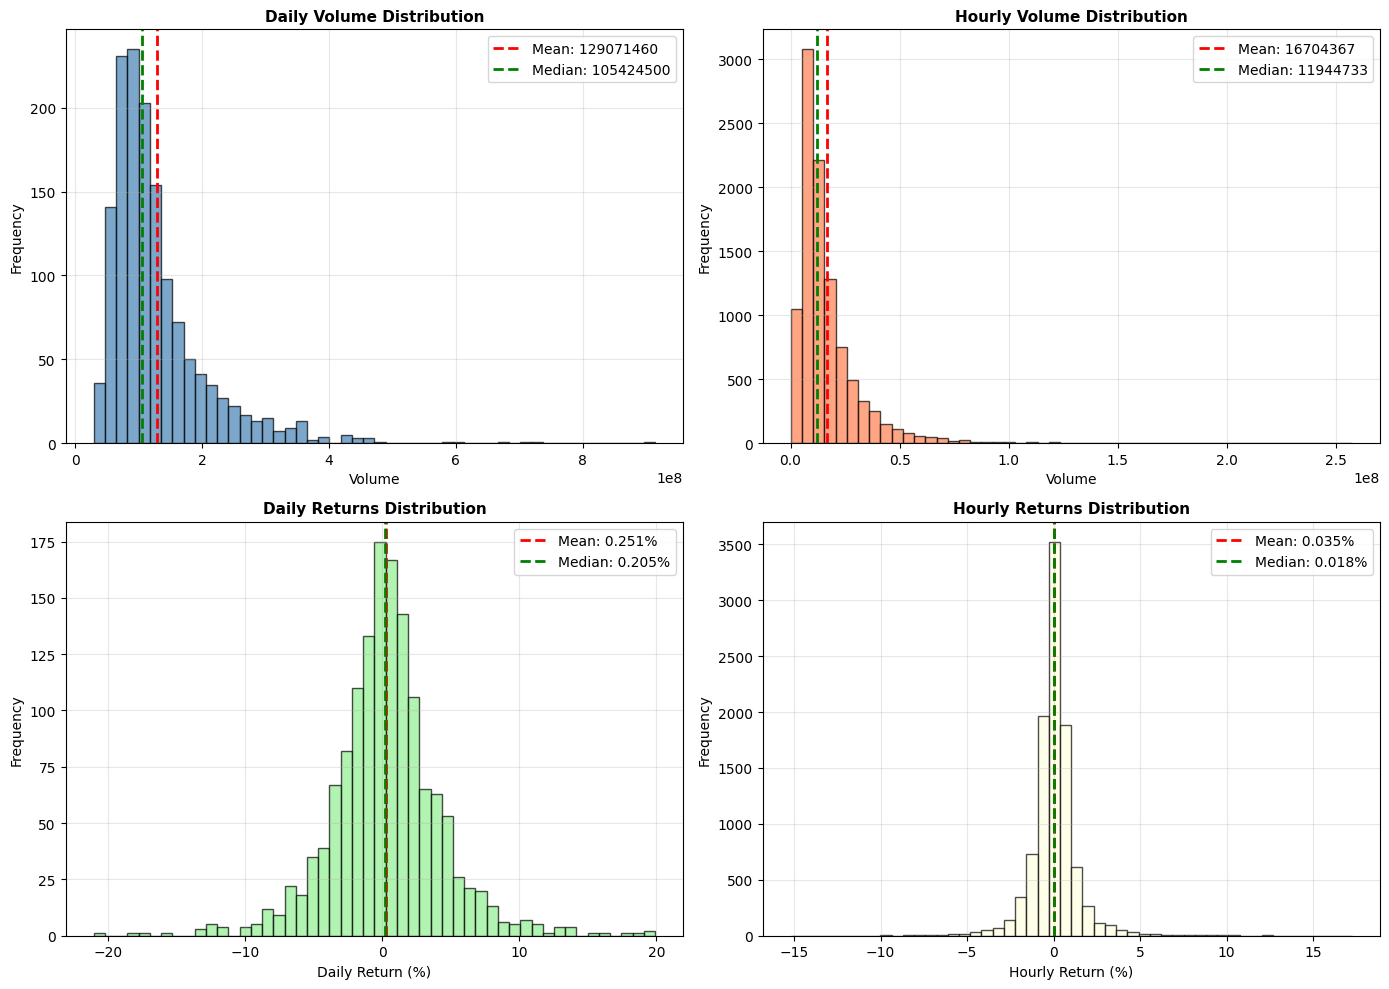

Saved: outputs/eda_TSLA_distributions.png


In [52]:
# Volume Distribution & Returns Analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Daily volume histogram
axes[0, 0].hist(reload_daily['Volume'].dropna(), bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0, 0].axvline(reload_daily['Volume'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {reload_daily['Volume'].mean():.0f}")
axes[0, 0].axvline(reload_daily['Volume'].median(), color='green', linestyle='--', linewidth=2, label=f"Median: {reload_daily['Volume'].median():.0f}")
axes[0, 0].set_xlabel('Volume', fontsize=10)
axes[0, 0].set_ylabel('Frequency', fontsize=10)
axes[0, 0].set_title('Daily Volume Distribution', fontsize=11, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Hourly volume histogram
axes[0, 1].hist(reload_hourly['Volume'].dropna(), bins=50, color='coral', alpha=0.7, edgecolor='black')
axes[0, 1].axvline(reload_hourly['Volume'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {reload_hourly['Volume'].mean():.0f}")
axes[0, 1].axvline(reload_hourly['Volume'].median(), color='green', linestyle='--', linewidth=2, label=f"Median: {reload_hourly['Volume'].median():.0f}")
axes[0, 1].set_xlabel('Volume', fontsize=10)
axes[0, 1].set_ylabel('Frequency', fontsize=10)
axes[0, 1].set_title('Hourly Volume Distribution', fontsize=11, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Daily returns distribution
daily_returns = reload_daily['Close'].pct_change() * 100
axes[1, 0].hist(daily_returns.dropna(), bins=50, color='lightgreen', alpha=0.7, edgecolor='black')
axes[1, 0].axvline(daily_returns.mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {daily_returns.mean():.3f}%")
axes[1, 0].axvline(daily_returns.median(), color='green', linestyle='--', linewidth=2, label=f"Median: {daily_returns.median():.3f}%")
axes[1, 0].set_xlabel('Daily Return (%)', fontsize=10)
axes[1, 0].set_ylabel('Frequency', fontsize=10)
axes[1, 0].set_title('Daily Returns Distribution', fontsize=11, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Hourly returns distribution
hourly_returns = reload_hourly['Close'].pct_change() * 100
axes[1, 1].hist(hourly_returns.dropna(), bins=50, color='lightyellow', alpha=0.7, edgecolor='black')
axes[1, 1].axvline(hourly_returns.mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {hourly_returns.mean():.3f}%")
axes[1, 1].axvline(hourly_returns.median(), color='green', linestyle='--', linewidth=2, label=f"Median: {hourly_returns.median():.3f}%")
axes[1, 1].set_xlabel('Hourly Return (%)', fontsize=10)
axes[1, 1].set_ylabel('Frequency', fontsize=10)
axes[1, 1].set_title('Hourly Returns Distribution', fontsize=11, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'outputs/eda_{TICKER}_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: outputs/eda_{TICKER}_distributions.png")


MIDAS DATA SANITY CHECK

1. MISSING VALUES (NaN) CHECK:
----------------------------------------------------------------------
  ✓ Cancel_to_Trade               :    0 NaN (  0.00%)
  ✓ Hidden_Rate                   :    0 NaN (  0.00%)
  ✓ Hidden_Volume                 :    0 NaN (  0.00%)
  ✓ Trade_to_Order_Volume         :    0 NaN (  0.00%)
  ✓ Oddlot_Rate                   :    0 NaN (  0.00%)
  ✓ Oddlot_Volume                 :    0 NaN (  0.00%)

  Total NaN: 0.00% of all data points

2. DATE ALIGNMENT CHECK (MIDAS vs Price Data):
----------------------------------------------------------------------
  MIDAS rows        : 1443
  Daily trading days: 1443
  Hourly trading days: 1441
  MIDAS date range  : 2019-01-07 to 2024-09-30
  Daily date range  : 2019-01-07 to 2024-09-30

  Days in DAILY but NOT in MIDAS: 0
  Days in MIDAS but NOT in DAILY: 0
  Alignment: 100.0% of daily dates have MIDAS data

3. SUMMARY STATISTICS:
------------------------------------------------------------

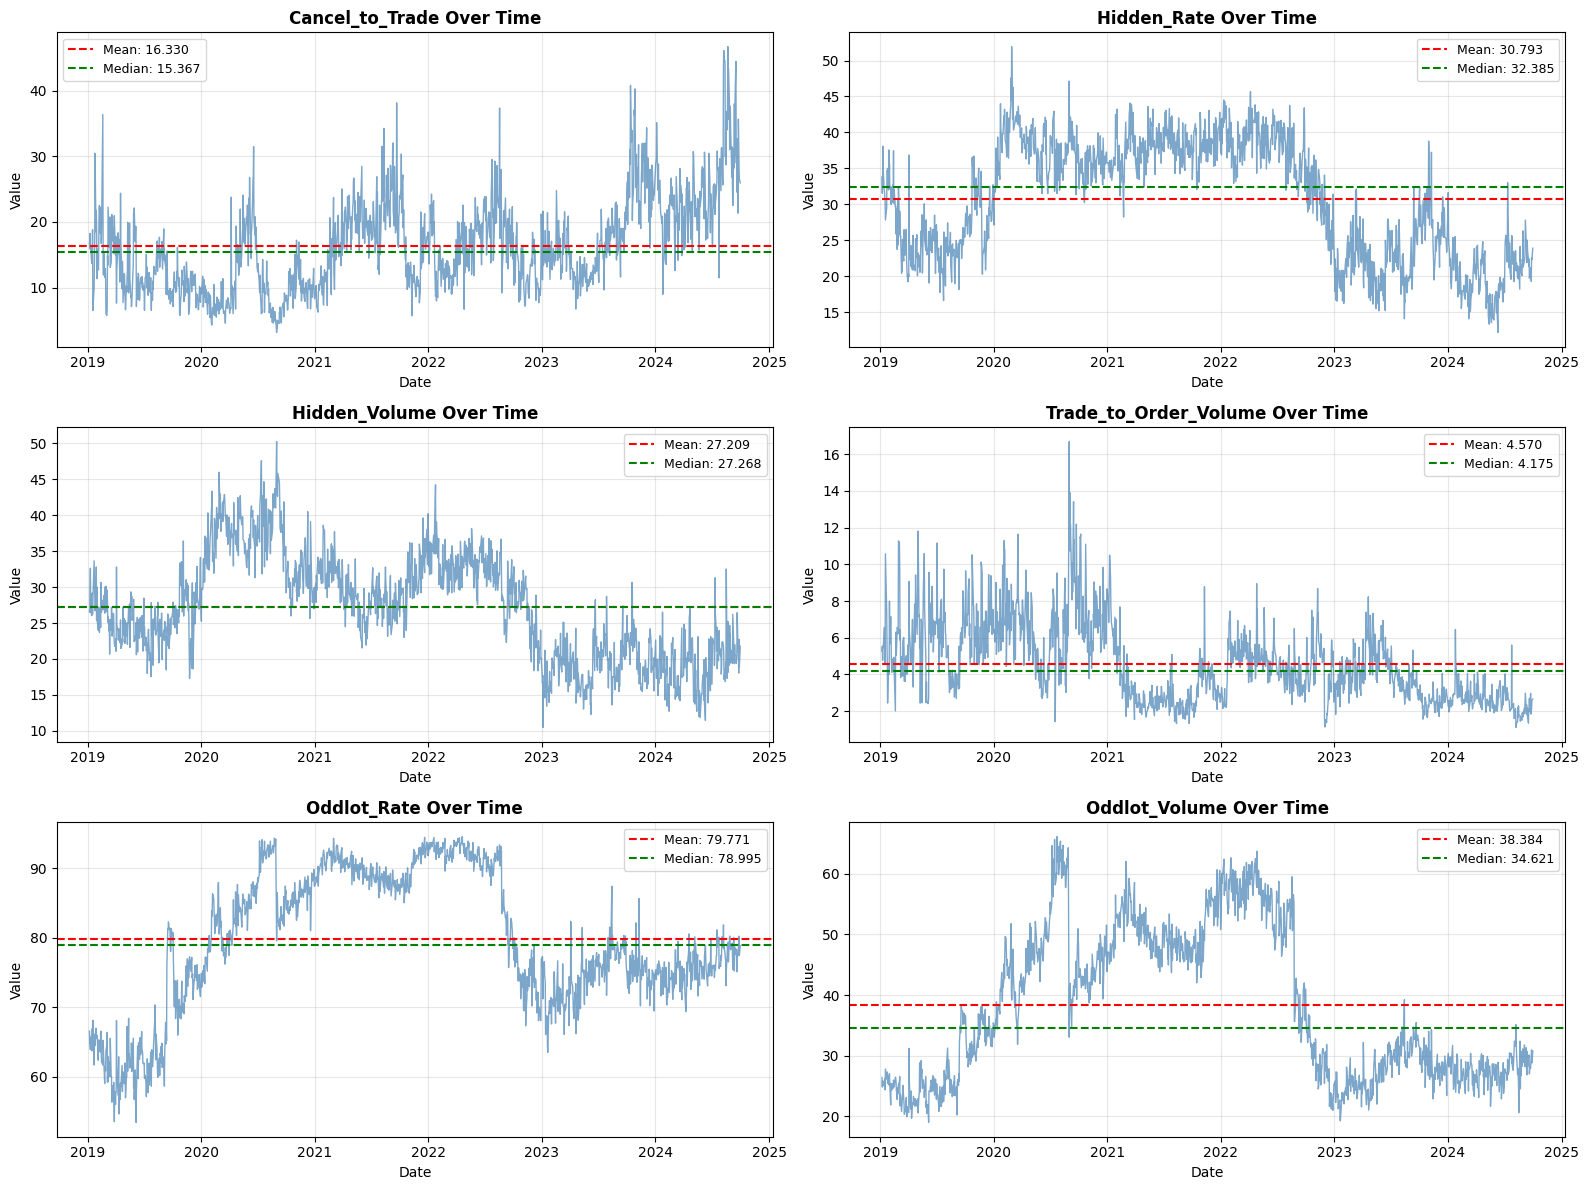


  ✓ Saved: outputs/midas_sanity_check_timeseries.png


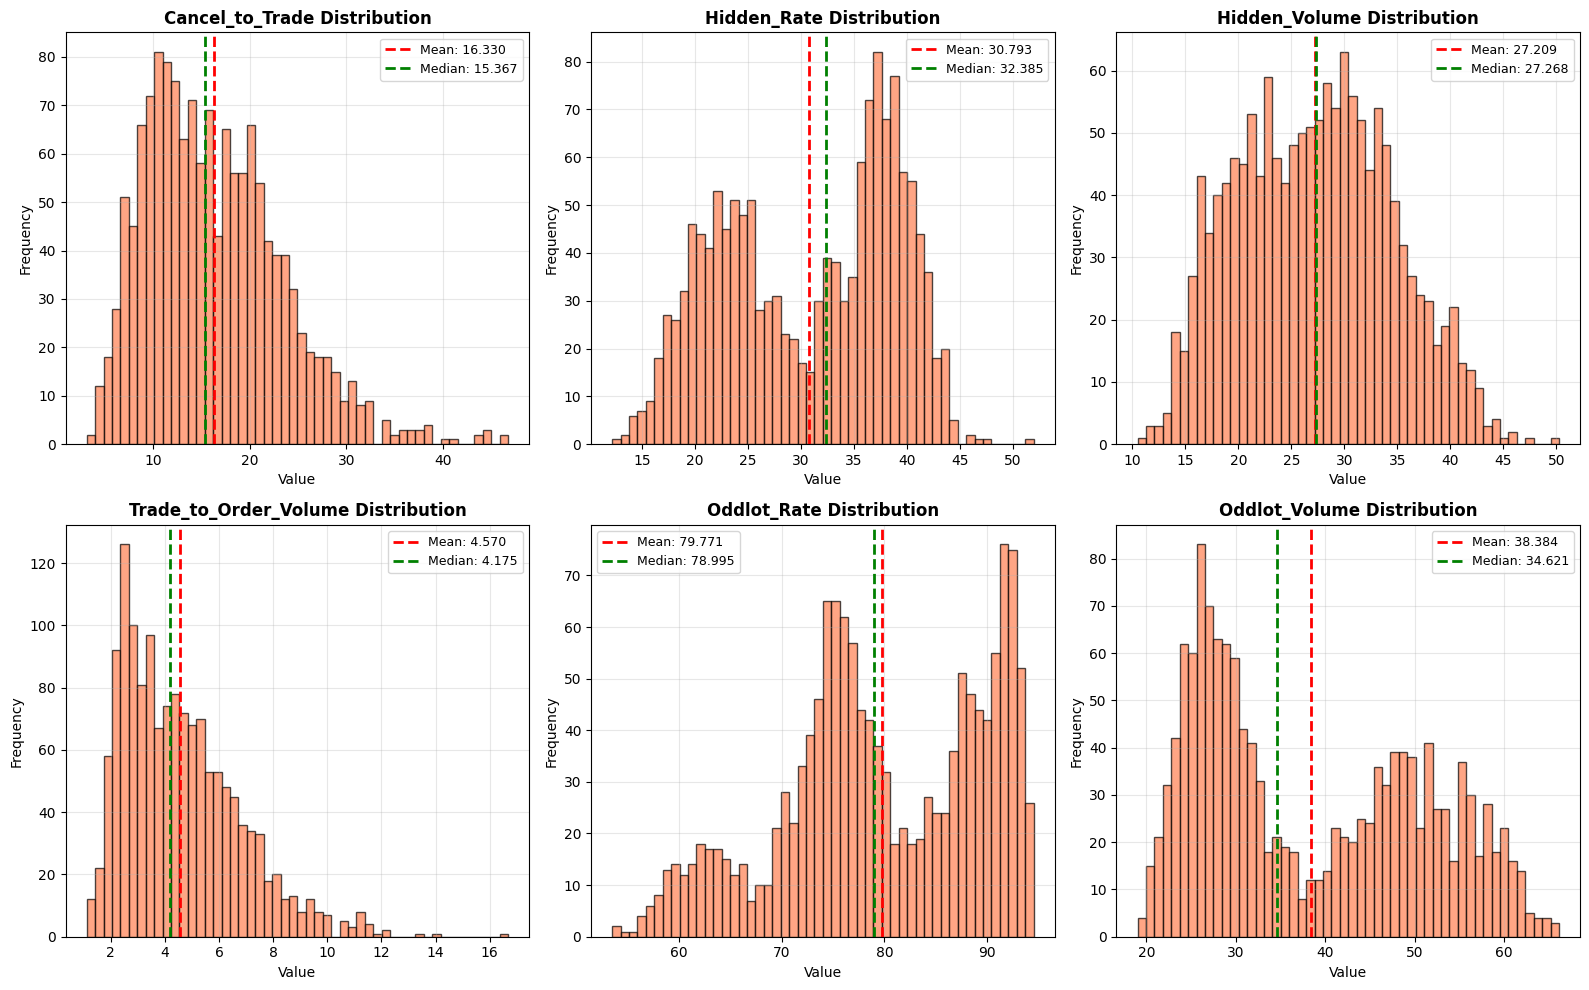

  ✓ Saved: outputs/midas_sanity_check_distributions.png


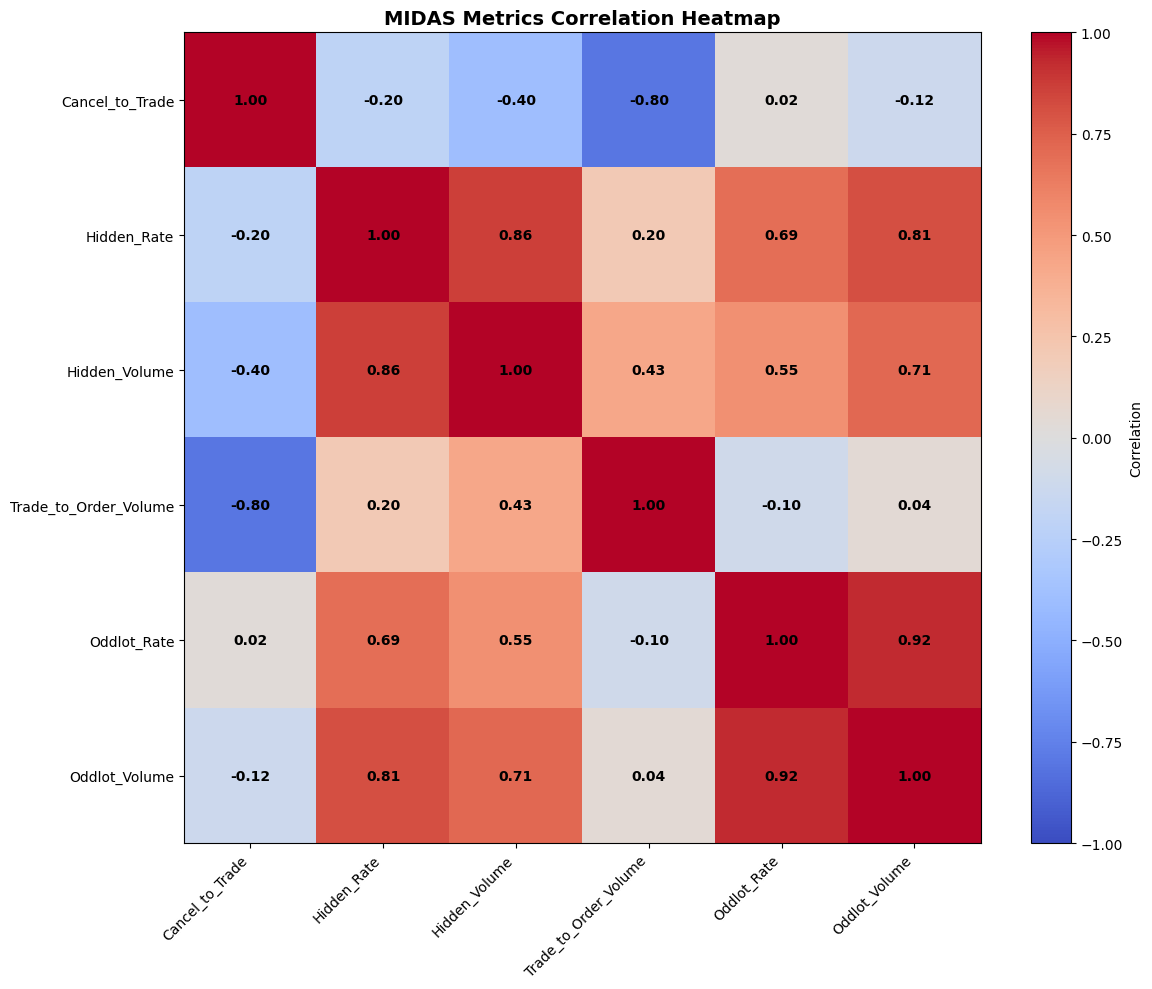

  ✓ Saved: outputs/midas_sanity_check_correlation.png

MIDAS SANITY CHECK SUMMARY

✓ MIDAS data validation complete!
  - 1443 rows loaded
  - 6 metrics available
  - Date alignment: 100.0% with daily data
  - Average NaN percentage: 0.00%
  - Ready for zone enrichment and filtering (Layer 3)


In [53]:
# ---------------------------------------------------------------------------
# MIDAS Data Sanity Check
# ---------------------------------------------------------------------------
# Comprehensive validation of MIDAS data for alignment, completeness, and quality

if midas_df is not None and not midas_df.empty and USE_MIDAS:
    print("\n" + "="*70)
    print("MIDAS DATA SANITY CHECK")
    print("="*70)
    
    # ─────────────────────────────────────────────────────────────────────
    # 1. MISSING/NAN VALUES CHECK
    # ─────────────────────────────────────────────────────────────────────
    print("\n1. MISSING VALUES (NaN) CHECK:")
    print("-" * 70)
    
    nan_counts = midas_df.isnull().sum()
    nan_pct = (nan_counts / len(midas_df)) * 100
    
    for col in midas_df.columns:
        nan_cnt = nan_counts[col]
        nan_p = nan_pct[col]
        status = "✓" if nan_p == 0 else "⚠" if nan_p < 20 else "✗"
        print(f"  {status} {col:30s}: {nan_cnt:4d} NaN ({nan_p:6.2f}%)")
    
    total_nan_pct = (midas_df.isnull().sum().sum() / (len(midas_df) * len(midas_df.columns))) * 100
    print(f"\n  Total NaN: {total_nan_pct:.2f}% of all data points")
    
    # ─────────────────────────────────────────────────────────────────────
    # 2. DATE ALIGNMENT CHECK (MIDAS vs Price Data)
    # ─────────────────────────────────────────────────────────────────────
    print("\n2. DATE ALIGNMENT CHECK (MIDAS vs Price Data):")
    print("-" * 70)
    
    midas_dates = set(midas_df.index.date)
    daily_dates = set(reload_daily.index.date)
    hourly_dates = set(reload_hourly.index.date)
    
    dates_in_daily_not_midas = daily_dates - midas_dates
    dates_in_midas_not_daily = midas_dates - daily_dates
    dates_in_hourly_not_midas = hourly_dates - midas_dates
    
    print(f"  MIDAS rows        : {len(midas_df)}")
    print(f"  Daily trading days: {len(daily_dates)}")
    print(f"  Hourly trading days: {len(hourly_dates)}")
    print(f"  MIDAS date range  : {midas_df.index.min().date()} to {midas_df.index.max().date()}")
    print(f"  Daily date range  : {reload_daily.index.min().date()} to {reload_daily.index.max().date()}")
    
    print(f"\n  Days in DAILY but NOT in MIDAS: {len(dates_in_daily_not_midas)}")
    if len(dates_in_daily_not_midas) > 0 and len(dates_in_daily_not_midas) <= 10:
        print(f"    → {sorted(dates_in_daily_not_midas)[:5]}" + ("..." if len(dates_in_daily_not_midas) > 5 else ""))
    
    print(f"  Days in MIDAS but NOT in DAILY: {len(dates_in_midas_not_daily)}")
    if len(dates_in_midas_not_daily) > 0 and len(dates_in_midas_not_daily) <= 10:
        print(f"    → {sorted(dates_in_midas_not_daily)[:5]}" + ("..." if len(dates_in_midas_not_daily) > 5 else ""))
    
    alignment_pct = (len(midas_dates & daily_dates) / len(daily_dates)) * 100 if daily_dates else 0
    print(f"  Alignment: {alignment_pct:.1f}% of daily dates have MIDAS data")
    
    # ─────────────────────────────────────────────────────────────────────
    # 3. SUMMARY STATISTICS (count, mean, median, min, max, std)
    # ─────────────────────────────────────────────────────────────────────
    print("\n3. SUMMARY STATISTICS:")
    print("-" * 70)
    
    stats_df = midas_df.describe().round(4)
    print(stats_df.to_string())
    
    # ─────────────────────────────────────────────────────────────────────
    # 4. PERCENTILE RANKS & OUTLIERS CHECK
    # ─────────────────────────────────────────────────────────────────────
    print("\n4. PERCENTILE DISTRIBUTION & OUTLIERS:")
    print("-" * 70)
    
    for col in midas_df.columns:
        col_data = midas_df[col].dropna()
        if len(col_data) == 0:
            continue
        
        q1 = col_data.quantile(0.25)
        q2 = col_data.quantile(0.50)  # median
        q3 = col_data.quantile(0.75)
        iqr = q3 - q1
        lower_fence = q1 - 1.5 * iqr
        upper_fence = q3 + 1.5 * iqr
        
        outliers_low = (col_data < lower_fence).sum()
        outliers_high = (col_data > upper_fence).sum()
        total_outliers = outliers_low + outliers_high
        outlier_pct = (total_outliers / len(col_data)) * 100
        
        print(f"\n  {col}:")
        print(f"    Percentiles: Q1={q1:.4f}, Q2(Median)={q2:.4f}, Q3={q3:.4f}")
        print(f"    IQR={iqr:.4f}, Outlier Fences: [{lower_fence:.4f}, {upper_fence:.4f}]")
        print(f"    Outliers: {total_outliers} ({outlier_pct:.2f}%) [Low: {outliers_low}, High: {outliers_high}]")
    
    # ─────────────────────────────────────────────────────────────────────
    # 5. CORRELATION MATRIX (Relationship between MIDAS metrics)
    # ─────────────────────────────────────────────────────────────────────
    print("\n5. CORRELATION BETWEEN MIDAS METRICS:")
    print("-" * 70)
    
    corr_matrix = midas_df.corr().round(3)
    print(corr_matrix.to_string())
    
    # ─────────────────────────────────────────────────────────────────────
    # 6. VISUALIZATIONS
    # ─────────────────────────────────────────────────────────────────────
    import matplotlib.pyplot as plt
    
    # Create a comprehensive figure with multiple subplots
    fig = plt.figure(figsize=(16, 12))
    
    # 6a. Time series of each MIDAS metric
    for idx, col in enumerate(midas_df.columns):
        ax = plt.subplot(3, 2, idx + 1)
        ax.plot(midas_df.index, midas_df[col], linewidth=1, color='steelblue', alpha=0.7)
        ax.set_title(f'{col} Over Time', fontweight='bold')
        ax.set_xlabel('Date')
        ax.set_ylabel('Value')
        ax.grid(alpha=0.3)
        
        # Add mean and median lines
        mean_val = midas_df[col].mean()
        median_val = midas_df[col].median()
        ax.axhline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.3f}')
        ax.axhline(median_val, color='green', linestyle='--', linewidth=1.5, label=f'Median: {median_val:.3f}')
        ax.legend(fontsize=9)
    
    plt.tight_layout()
    plt.savefig('outputs/midas_sanity_check_timeseries.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\n  ✓ Saved: outputs/midas_sanity_check_timeseries.png")
    
    # 6b. Distribution histograms
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()
    
    for idx, col in enumerate(midas_df.columns):
        ax = axes[idx]
        col_data = midas_df[col].dropna()
        ax.hist(col_data, bins=50, color='coral', alpha=0.7, edgecolor='black')
        ax.axvline(col_data.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {col_data.mean():.3f}')
        ax.axvline(col_data.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {col_data.median():.3f}')
        ax.set_title(f'{col} Distribution', fontweight='bold')
        ax.set_xlabel('Value')
        ax.set_ylabel('Frequency')
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)
    
    # Remove extra subplot
    if len(midas_df.columns) < 6:
        fig.delaxes(axes[-1])
    
    plt.tight_layout()
    plt.savefig('outputs/midas_sanity_check_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("  ✓ Saved: outputs/midas_sanity_check_distributions.png")
    
    # 6c. Heatmap of correlation matrix
    import matplotlib.patches as mpatches
    
    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
    
    ax.set_xticks(range(len(corr_matrix.columns)))
    ax.set_yticks(range(len(corr_matrix.columns)))
    ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right')
    ax.set_yticklabels(corr_matrix.columns)
    
    # Add correlation values in cells
    for i in range(len(corr_matrix)):
        for j in range(len(corr_matrix)):
            text = ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                          ha="center", va="center", color="black", fontsize=10, fontweight='bold')
    
    ax.set_title('MIDAS Metrics Correlation Heatmap', fontweight='bold', fontsize=14)
    plt.colorbar(im, ax=ax, label='Correlation')
    plt.tight_layout()
    plt.savefig('outputs/midas_sanity_check_correlation.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("  ✓ Saved: outputs/midas_sanity_check_correlation.png")
    
    # ─────────────────────────────────────────────────────────────────────
    # SUMMARY
    # ─────────────────────────────────────────────────────────────────────
    print("\n" + "="*70)
    print("MIDAS SANITY CHECK SUMMARY")
    print("="*70)
    
    print(f"\n✓ MIDAS data validation complete!")
    print(f"  - {len(midas_df)} rows loaded")
    print(f"  - {len(midas_df.columns)} metrics available")
    print(f"  - Date alignment: {alignment_pct:.1f}% with daily data")
    print(f"  - Average NaN percentage: {total_nan_pct:.2f}%")
    print(f"  - Ready for zone enrichment and filtering (Layer 3)")
    
else:
    print("\n⚠ MIDAS data not available for sanity check (midas_df is None or empty)")

In [54]:
midas_df.head()

,Cancel_to_Trade,Hidden_Rate,Hidden_Volume,Trade_to_Order_Volume,Oddlot_Rate,Oddlot_Volume
date,,,,,,
2019-01-07,16.746172,33.800934,26.710077,5.277240,66.580785,26.440138
2019-01-08,16.047832,31.524426,26.485077,5.535252,64.815014,24.845629
2019-01-09,18.251545,33.914031,29.908651,4.771617,64.621275,25.902082
2019-01-10,15.838502,38.068253,32.611996,5.536736,63.933268,25.027834
2019-01-11,16.216215,34.731702,26.968093,5.456595,65.463772,25.754748


### 2b — Data Transformation

### 2b — Data Transformation

In [55]:
# APPLY VOLUME NORMALIZATION — Create volume_zscore column 

print("\n" + "="*75)
print("STEP 1: APPLYING VOLUME NORMALIZATION (normalize_volume_data)")
print("="*75)
print("Creating volume_zscore column required by all downstream analysis...")
print()

reload_daily  = normalize_volume_data(reload_daily)
reload_hourly = normalize_volume_data(reload_hourly)

print("\n✓ Volume normalization complete:")
print(f"  - Daily data: {len(reload_daily)} bars, volume_zscore shape={reload_daily['volume_zscore'].shape}")
print(f"  - Hourly data: {len(reload_hourly)} bars, volume_zscore shape={reload_hourly['volume_zscore'].shape}")
print(f"  - Both DataFrames now have volume_skewness, volume_log_applied, volume_zscore columns")


STEP 1: APPLYING VOLUME NORMALIZATION (normalize_volume_data)
Creating volume_zscore column required by all downstream analysis...

[Volume] High skewness detected (2.8077) → applying log1p transformation
[Volume] High skewness detected (3.6625) → applying log1p transformation

✓ Volume normalization complete:
  - Daily data: 1443 bars, volume_zscore shape=(1443,)
  - Hourly data: 10070 bars, volume_zscore shape=(10070,)
  - Both DataFrames now have volume_skewness, volume_log_applied, volume_zscore columns


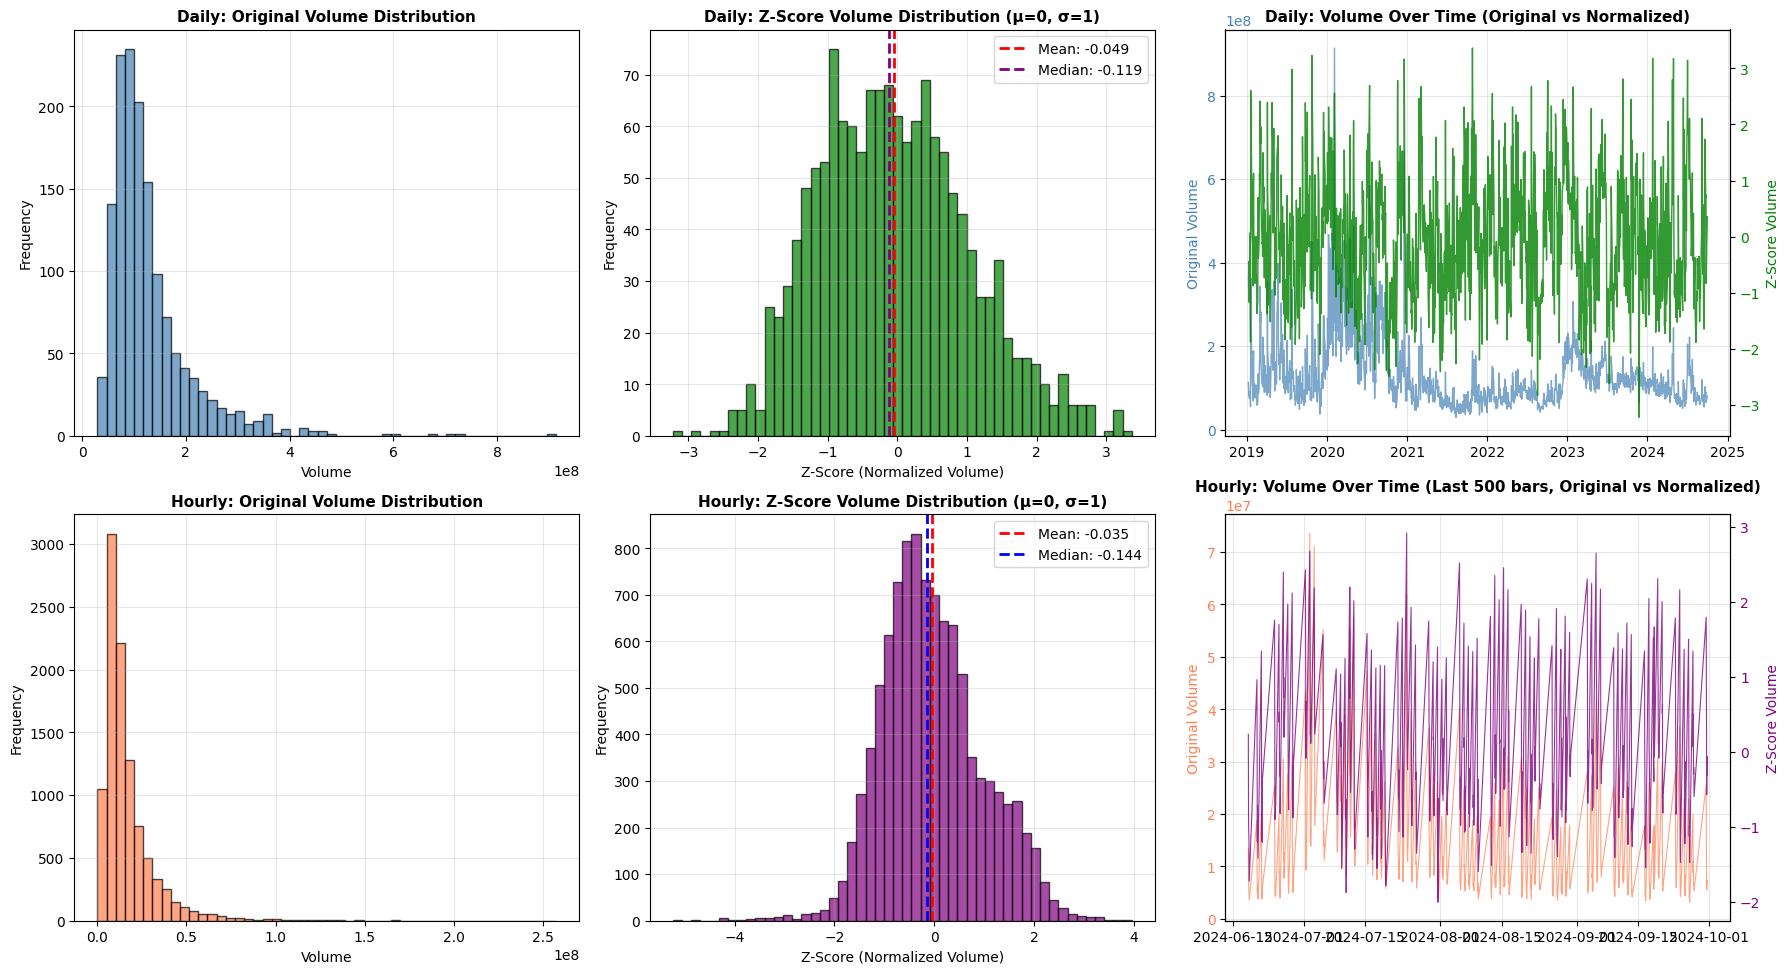


✓ Volume normalization visualizations displayed


In [56]:
# ---------------------------------------------------------------------------
# Volume Normalization Visualizations
# ---------------------------------------------------------------------------

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# ─────────────────────────────────────────────────────────────────────────
# Row 1: Daily (HTF) Volume Analysis
# ─────────────────────────────────────────────────────────────────────────

# Original Volume Distribution
axes[0, 0].hist(reload_daily['Volume'].dropna(), bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0, 0].set_xlabel('Volume', fontsize=10)
axes[0, 0].set_ylabel('Frequency', fontsize=10)
axes[0, 0].set_title('Daily: Original Volume Distribution', fontsize=11, fontweight='bold')
axes[0, 0].grid(alpha=0.3)

# Z-Score Volume Distribution (centered at 0)
axes[0, 1].hist(reload_daily['volume_zscore'].dropna(), bins=50, color='green', alpha=0.7, edgecolor='black')
axes[0, 1].axvline(reload_daily['volume_zscore'].mean(), color='red', linestyle='--', linewidth=2, 
                   label=f"Mean: {reload_daily['volume_zscore'].mean():.3f}")
axes[0, 1].axvline(reload_daily['volume_zscore'].median(), color='purple', linestyle='--', linewidth=2,
                   label=f"Median: {reload_daily['volume_zscore'].median():.3f}")
axes[0, 1].set_xlabel('Z-Score (Normalized Volume)', fontsize=10)
axes[0, 1].set_ylabel('Frequency', fontsize=10)
axes[0, 1].set_title('Daily: Z-Score Volume Distribution (μ=0, σ=1)', fontsize=11, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Time Series: Original vs Normalized Volume
axes[0, 2].plot(reload_daily.index, reload_daily['Volume'], color='steelblue', linewidth=1, 
                label='Original', alpha=0.7)
ax_norm = axes[0, 2].twinx()
ax_norm.plot(reload_daily.index, reload_daily['volume_zscore'], color='green', linewidth=1, 
             label='Z-Score', alpha=0.8)
axes[0, 2].set_ylabel('Original Volume', fontsize=10, color='steelblue')
ax_norm.set_ylabel('Z-Score Volume', fontsize=10, color='green')
axes[0, 2].set_title('Daily: Volume Over Time (Original vs Normalized)', fontsize=11, fontweight='bold')
axes[0, 2].tick_params(axis='y', labelcolor='steelblue')
ax_norm.tick_params(axis='y', labelcolor='green')
axes[0, 2].grid(alpha=0.3)

# ─────────────────────────────────────────────────────────────────────────
# Row 2: Hourly (LTF) Volume Analysis
# ─────────────────────────────────────────────────────────────────────────

# Original Volume Distribution (Hourly)
axes[1, 0].hist(reload_hourly['Volume'].dropna(), bins=50, color='coral', alpha=0.7, edgecolor='black')
axes[1, 0].set_xlabel('Volume', fontsize=10)
axes[1, 0].set_ylabel('Frequency', fontsize=10)
axes[1, 0].set_title('Hourly: Original Volume Distribution', fontsize=11, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# Z-Score Volume Distribution (Hourly)
axes[1, 1].hist(reload_hourly['volume_zscore'].dropna(), bins=50, color='purple', alpha=0.7, edgecolor='black')
axes[1, 1].axvline(reload_hourly['volume_zscore'].mean(), color='red', linestyle='--', linewidth=2,
                   label=f"Mean: {reload_hourly['volume_zscore'].mean():.3f}")
axes[1, 1].axvline(reload_hourly['volume_zscore'].median(), color='blue', linestyle='--', linewidth=2,
                   label=f"Median: {reload_hourly['volume_zscore'].median():.3f}")
axes[1, 1].set_xlabel('Z-Score (Normalized Volume)', fontsize=10)
axes[1, 1].set_ylabel('Frequency', fontsize=10)
axes[1, 1].set_title('Hourly: Z-Score Volume Distribution (μ=0, σ=1)', fontsize=11, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

# Time Series: Hourly Volume (Last 500 bars for clarity)
hourly_tail = reload_hourly.tail(500)
axes[1, 2].plot(hourly_tail.index, hourly_tail['Volume'], color='coral', linewidth=0.8, 
                label='Original', alpha=0.7)
ax_norm2 = axes[1, 2].twinx()
ax_norm2.plot(hourly_tail.index, hourly_tail['volume_zscore'], color='purple', linewidth=0.8,
              label='Z-Score', alpha=0.8)
axes[1, 2].set_ylabel('Original Volume', fontsize=10, color='coral')
ax_norm2.set_ylabel('Z-Score Volume', fontsize=10, color='purple')
axes[1, 2].set_title('Hourly: Volume Over Time (Last 500 bars, Original vs Normalized)', fontsize=11, fontweight='bold')
axes[1, 2].tick_params(axis='y', labelcolor='coral')
ax_norm2.tick_params(axis='y', labelcolor='purple')
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.show()
print("\n✓ Volume normalization visualizations displayed")

In [57]:
# APPLY MIDAS PREPROCESSING
print("\n" + "="*75)
print("APPLYING MIDAS PREPROCESSING (preprocess_midas_data)")
print("="*75)   
midas_df = preprocess_midas_data(midas_df, rolling_window=20)
print(f"✓ MIDAS data preprocessed: {midas_df.shape}")


APPLYING MIDAS PREPROCESSING (preprocess_midas_data)

ROBUST MIDAS PREPROCESSING (Rolling Median/MAD + Quantiles)
  Walk-forward mode: True
  Rolling window: 20
MIDAS preprocessing complete.
✓ MIDAS data preprocessed: (1443, 43)


In [58]:
midas_df.head()

,Cancel_to_Trade,Hidden_Rate,Hidden_Volume,Trade_to_Order_Volume,Oddlot_Rate,Oddlot_Volume,Cancel_to_Trade_zscore,Cancel_to_Trade_qnorm,Cancel_to_Trade_roll_median,Cancel_to_Trade_roll_mean,...,Oddlot_Rate_roll_mean,Oddlot_Rate_diff_1,Oddlot_Rate_regime,Oddlot_Volume_zscore,Oddlot_Volume_qnorm,Oddlot_Volume_roll_median,Oddlot_Volume_roll_mean,Oddlot_Volume_diff_1,Oddlot_Volume_regime,Hidden_to_Oddlot
date,,,,,,,,,,,,,,,,,,,,,
2019-01-07,16.746172,33.800934,26.710077,5.277240,66.580785,26.440138,NaN,0.5,NaN,NaN,...,NaN,NaN,0,NaN,0.5,NaN,NaN,NaN,0,1.010206
2019-01-08,16.047832,31.524426,26.485077,5.535252,64.815014,24.845629,NaN,0.5,NaN,NaN,...,NaN,-1.765771,0,NaN,0.5,NaN,NaN,-1.594509,0,1.065981
2019-01-09,18.251545,33.914031,29.908651,4.771617,64.621275,25.902082,NaN,0.5,NaN,NaN,...,NaN,-0.193739,0,NaN,0.5,NaN,NaN,1.056454,0,1.154677
2019-01-10,15.838502,38.068253,32.611996,5.536736,63.933268,25.027834,NaN,0.5,NaN,NaN,...,NaN,-0.688007,0,NaN,0.5,NaN,NaN,-0.874248,0,1.303024
2019-01-11,16.216215,34.731702,26.968093,5.456595,65.463772,25.754748,NaN,0.5,NaN,NaN,...,NaN,1.530504,0,NaN,0.5,NaN,NaN,0.726914,0,1.047107


In [59]:
midas_df.tail()

,Cancel_to_Trade,Hidden_Rate,Hidden_Volume,Trade_to_Order_Volume,Oddlot_Rate,Oddlot_Volume,Cancel_to_Trade_zscore,Cancel_to_Trade_qnorm,Cancel_to_Trade_roll_median,Cancel_to_Trade_roll_mean,...,Oddlot_Rate_roll_mean,Oddlot_Rate_diff_1,Oddlot_Rate_regime,Oddlot_Volume_zscore,Oddlot_Volume_qnorm,Oddlot_Volume_roll_median,Oddlot_Volume_roll_mean,Oddlot_Volume_diff_1,Oddlot_Volume_regime,Hidden_to_Oddlot
date,,,,,,,,,,,,,,,,,,,,,
2024-09-24,35.657190,21.208129,21.719910,1.840788,78.386400,29.325259,0.875627,0.986101,31.243872,31.284896,...,77.964904,0.521556,0,0.077699,0.353023,29.200837,29.290639,1.347407,0,0.740653
2024-09-25,32.136996,19.291262,18.047930,2.047854,79.685393,30.009501,0.149674,0.977778,31.382614,31.340736,...,77.937307,1.298993,0,0.288752,0.386111,29.547114,29.376504,0.684242,0,0.601405
2024-09-26,28.694872,22.569841,22.741522,2.082493,80.232638,30.956435,-0.515894,0.946565,31.295069,31.208909,...,77.969304,0.547245,0,0.726913,0.420541,29.547114,29.415049,0.946934,0,0.734628
2024-09-27,26.615372,22.317862,18.830946,2.590407,77.421812,28.826407,-0.868032,0.916089,30.672239,30.657624,...,77.886283,-2.810826,0,-0.239111,0.333564,29.200837,29.299724,-2.130029,0,0.653251
2024-09-30,25.949677,23.903098,21.776731,2.662598,78.873497,30.787481,-0.842489,0.905059,29.585133,30.238144,...,77.916438,1.451685,0,0.650270,0.417879,29.547114,29.395138,1.961074,0,0.707322


In [60]:
# midas_path = OUT_DIR / f"{TICKER}_midas_processed.csv"
# midas_df.to_csv(midas_path)

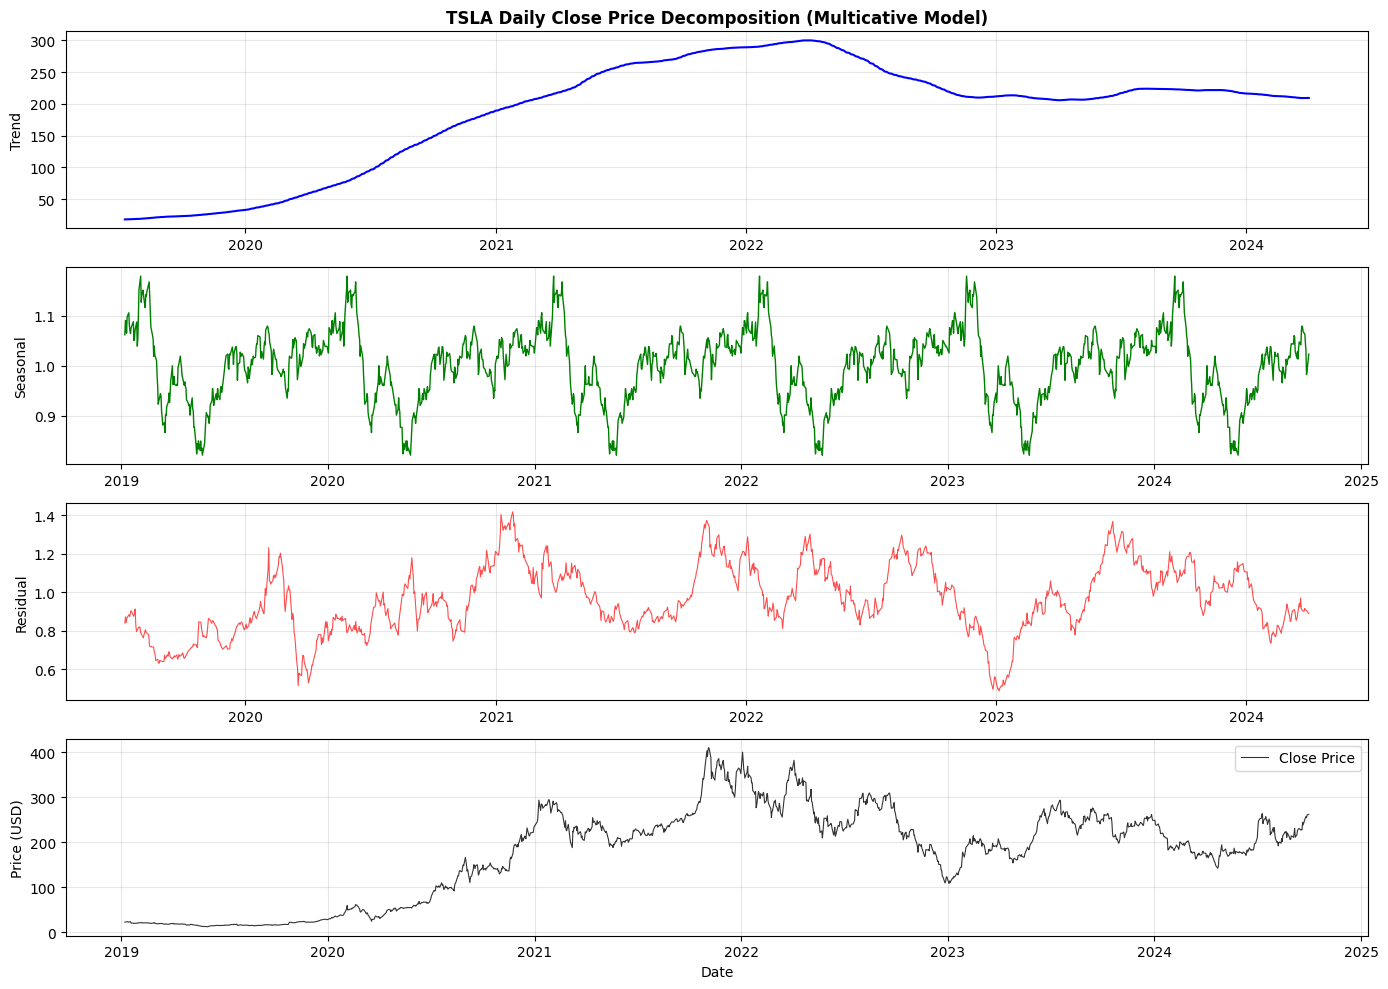

Saved: outputs/eda_TSLA_decomposition.png


In [61]:
# ---------------------------------------------------------------------------
# EDA: Time Series Decomposition & Visualizations
# ---------------------------------------------------------------------------
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Prepare closing prices for decomposition (daily only, as decomposition works on univariate series)
close_daily = reload_daily['Close']

# Perform seasonal decomposition on daily close prices
# freq=252 corresponds to ~1 year of trading days (typical in finance)
decomposition = seasonal_decompose(close_daily, model='multicative', period=252)

# Create a figure with subplots for decomposition
fig, axes = plt.subplots(4, 1, figsize=(14, 10))

# Trend
axes[0].plot(decomposition.trend, color='blue', linewidth=1.5)
axes[0].set_ylabel('Trend', fontsize=10)
axes[0].set_title(f'{TICKER} Daily Close Price Decomposition (Multicative Model)', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)

# Seasonal
axes[1].plot(decomposition.seasonal, color='green', linewidth=1)
axes[1].set_ylabel('Seasonal', fontsize=10)
axes[1].grid(alpha=0.3)

# Residual
axes[2].plot(decomposition.resid, color='red', linewidth=0.8, alpha=0.7)
axes[2].set_ylabel('Residual', fontsize=10)
axes[2].grid(alpha=0.3)

# Original
axes[3].plot(close_daily, color='black', linewidth=0.8, alpha=0.8, label='Close Price')
axes[3].set_ylabel('Price (USD)', fontsize=10)
axes[3].set_xlabel('Date', fontsize=10)
axes[3].grid(alpha=0.3)
axes[3].legend()

plt.tight_layout()
plt.savefig(f'outputs/eda_{TICKER}_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: outputs/eda_{TICKER}_decomposition.png")


/var/folders/sr/gx_1bzpx6w33z_3djt_j_l5m0000gq/T/ipykernel_35704/2563454133.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


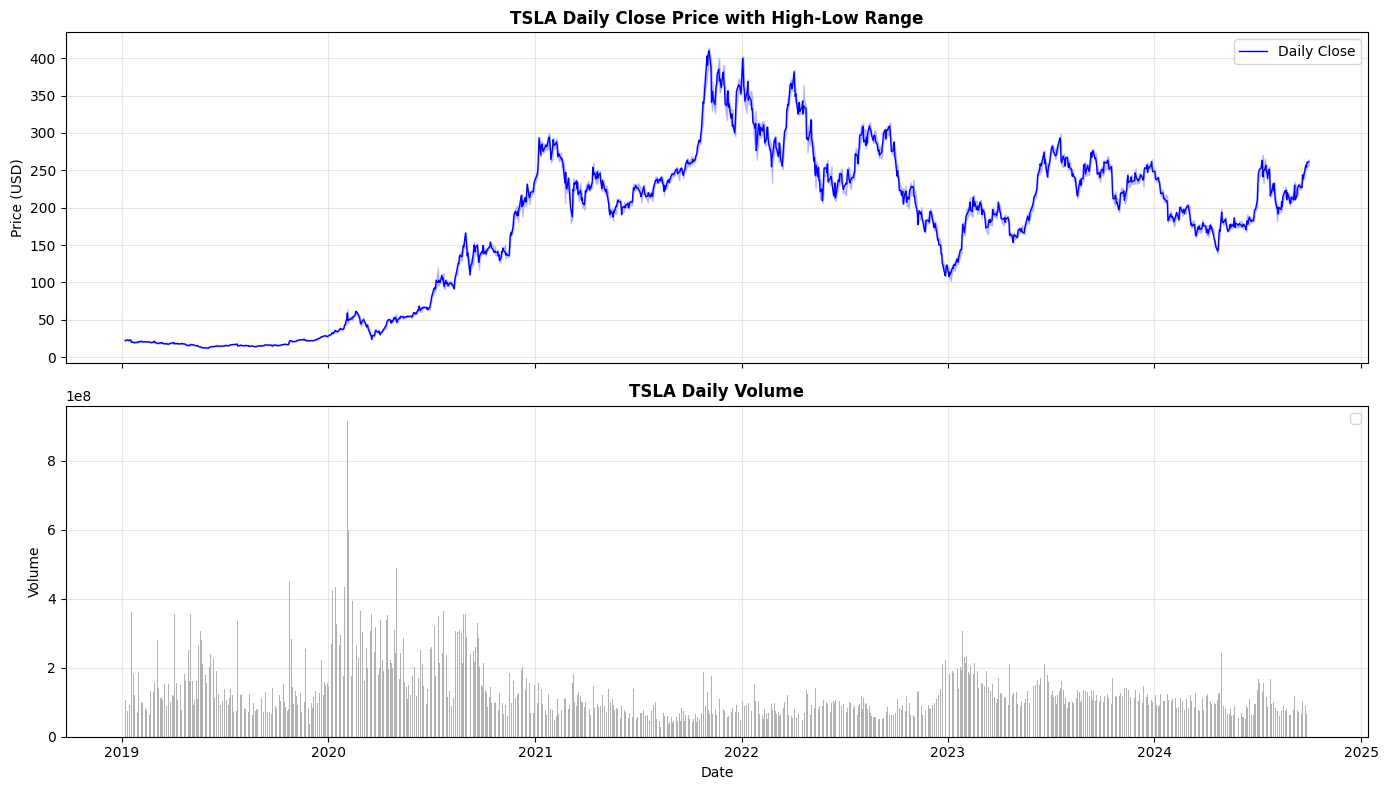

Saved: outputs/eda_TSLA_price_volume.png


In [62]:
# Price & Volume Trends
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Daily close price
axes[0].plot(reload_daily.index, reload_daily['Close'], color='blue', linewidth=1, label='Daily Close')
axes[0].fill_between(reload_daily.index, reload_daily['Low'], reload_daily['High'], alpha=0.2, color='blue')
axes[0].set_ylabel('Price (USD)', fontsize=10)
axes[0].set_title(f'{TICKER} Daily Close Price with High-Low Range', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Daily volume
axes[1].bar(reload_daily.index, reload_daily['Volume'], color='gray', alpha=0.6, width=0.8)
axes[1].set_ylabel('Volume', fontsize=10)
axes[1].set_xlabel('Date', fontsize=10)
axes[1].set_title(f'{TICKER} Daily Volume', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'outputs/eda_{TICKER}_price_volume.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: outputs/eda_{TICKER}_price_volume.png")


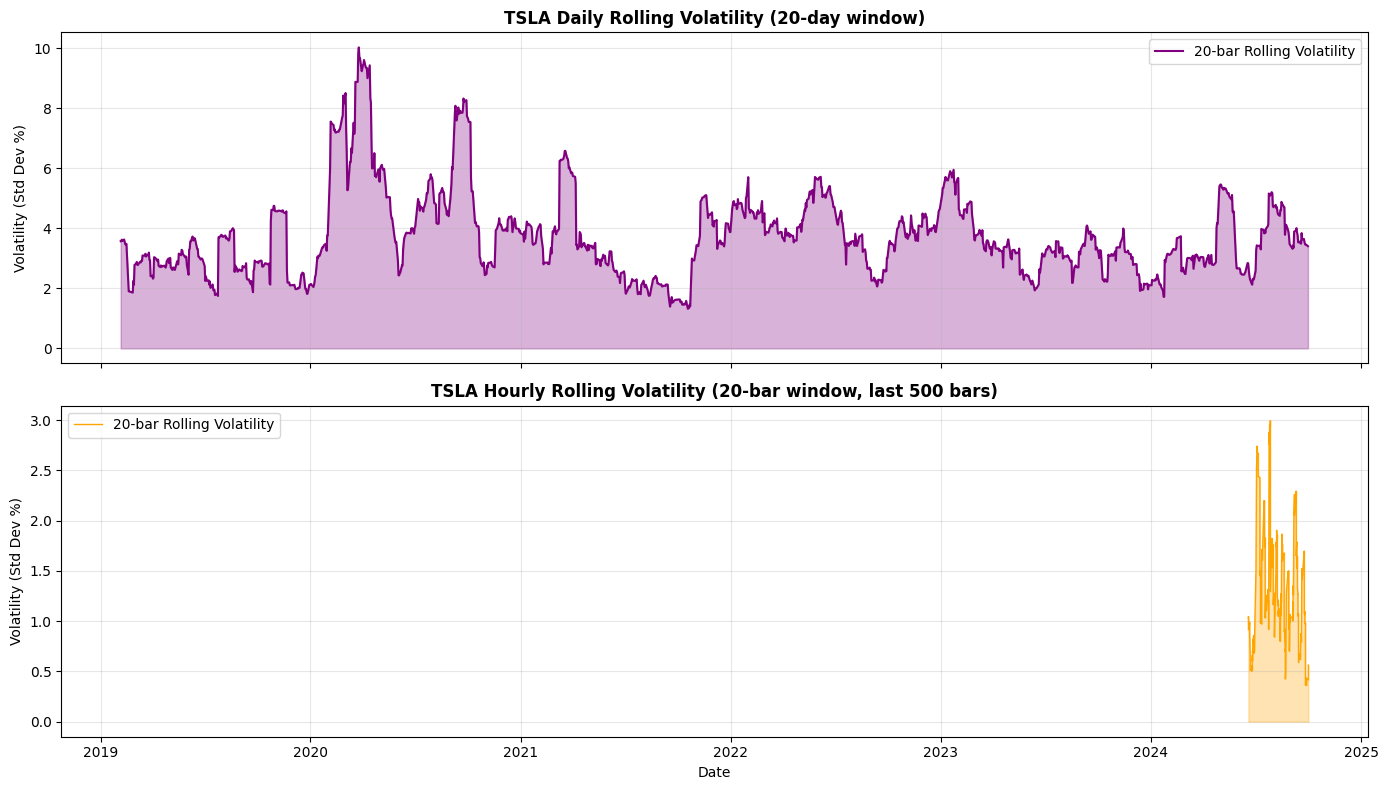

Saved: outputs/eda_TSLA_volatility.png

VOLATILITY SUMMARY STATISTICS
Daily volatility  - Mean: 3.7340%, Std: 1.4249%, Max: 10.0268%
Hourly volatility - Mean: 1.2705%, Std: 0.6607%, Max: 5.7660%


In [63]:
# Volatility Analysis
import numpy as np

# Calculate rolling volatility (20-day rolling std of returns)
daily_volatility = daily_returns.rolling(20).std()
hourly_volatility = hourly_returns.rolling(20).std()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Daily volatility over time
axes[0].plot(daily_volatility.index, daily_volatility, color='purple', linewidth=1.5, label='20-bar Rolling Volatility')
axes[0].fill_between(daily_volatility.index, daily_volatility, alpha=0.3, color='purple')
axes[0].set_ylabel('Volatility (Std Dev %)', fontsize=10)
axes[0].set_title(f'{TICKER} Daily Rolling Volatility (20-day window)', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Hourly volatility over time (last 500 bars for clarity)
hourly_tail = hourly_volatility.tail(500)
axes[1].plot(hourly_tail.index, hourly_tail, color='orange', linewidth=1, label='20-bar Rolling Volatility')
axes[1].fill_between(hourly_tail.index, hourly_tail, alpha=0.3, color='orange')
axes[1].set_ylabel('Volatility (Std Dev %)', fontsize=10)
axes[1].set_xlabel('Date', fontsize=10)
axes[1].set_title(f'{TICKER} Hourly Rolling Volatility (20-bar window, last 500 bars)', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'outputs/eda_{TICKER}_volatility.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: outputs/eda_{TICKER}_volatility.png")

# Summary statistics
print("\n" + "="*70)
print("VOLATILITY SUMMARY STATISTICS")
print("="*70)
print(f"Daily volatility  - Mean: {daily_volatility.mean():.4f}%, Std: {daily_volatility.std():.4f}%, Max: {daily_volatility.max():.4f}%")
print(f"Hourly volatility - Mean: {hourly_volatility.mean():.4f}%, Std: {hourly_volatility.std():.4f}%, Max: {hourly_volatility.max():.4f}%")


In [64]:
# EDA Summary: Key Statistics Comparison

summary_data = {
    'Metric': [
        'Records', 'Date Range', 'Avg Close', 'Min Close', 'Max Close',
        'Avg Volume', 'Median Volume', 'Volume Std Dev',
        'Avg Return (%)', 'Max Return (%)', 'Min Return (%)',
        'Avg Volatility (%)', 'Max Volatility (%)'
    ],
    'Daily (HTF)': [
        len(reload_daily),
        f"{reload_daily.index.min().date()} to {reload_daily.index.max().date()}",
        f"{reload_daily['Close'].mean():.2f}",
        f"{reload_daily['Close'].min():.2f}",
        f"{reload_daily['Close'].max():.2f}",
        f"{reload_daily['Volume'].mean():.0f}",
        f"{reload_daily['Volume'].median():.0f}",
        f"{reload_daily['Volume'].std():.0f}",
        f"{daily_returns.mean():.4f}",
        f"{daily_returns.max():.4f}",
        f"{daily_returns.min():.4f}",
        f"{daily_volatility.mean():.4f}",
        f"{daily_volatility.max():.4f}"
    ],
    'Hourly (LTF)': [
        len(reload_hourly),
        f"{reload_hourly.index.min()} to {reload_hourly.index.max()}",
        f"{reload_hourly['Close'].mean():.2f}",
        f"{reload_hourly['Close'].min():.2f}",
        f"{reload_hourly['Close'].max():.2f}",
        f"{reload_hourly['Volume'].mean():.0f}",
        f"{reload_hourly['Volume'].median():.0f}",
        f"{reload_hourly['Volume'].std():.0f}",
        f"{hourly_returns.mean():.4f}",
        f"{hourly_returns.max():.4f}",
        f"{hourly_returns.min():.4f}",
        f"{hourly_volatility.mean():.4f}",
        f"{hourly_volatility.max():.4f}"
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*70)
print("EDA SUMMARY — DAILY vs HOURLY")
print("="*70)
print(summary_df)


EDA SUMMARY — DAILY vs HOURLY
                Metric               Daily (HTF)  \
0              Records                      1443   
1           Date Range  2019-01-07 to 2024-09-30   
2            Avg Close                    174.94   
3            Min Close                     11.93   
4            Max Close                    409.97   
5           Avg Volume                 129071460   
6        Median Volume                 105424500   
7       Volume Std Dev                  81578569   
8       Avg Return (%)                    0.2514   
9       Max Return (%)                   19.8949   
10      Min Return (%)                  -21.0628   
11  Avg Volatility (%)                    3.7340   
12  Max Volatility (%)                   10.0268   

                                  Hourly (LTF)  
0                                        10070  
1   2019-01-07 09:00:00 to 2024-09-30 15:30:00  
2                                       175.12  
3                                        11.

## Block D — Master Ticker Loop (Multi-Ticker Detection)

Run this cell to execute the full pipeline for **all tickers** in `TICKERS_TO_RUN`.
Each ticker gets its own: data load → preprocessing → walk-forward detection → export.

## Part 8 Main Execution (Zone Identification & Sweep Detection) 


In [65]:
# =============================================================================
# PART 1 — SWEEP EXPORT & CHART FUNCTION DEFINITIONS
# Defines all helper functions used by the master ticker loop in Part 2.
#   - prepare_sweep_export_data()   : formats sweeps DataFrame for CSV export
#   - plot_win_rate_calibration()   : empirical threshold calibration plots
#   - generate_sweep_chart()        : single candlestick chart for one sweep
#   - generate_all_sweep_charts()   : batch chart generation with folder routing
# No execution code — all runs are driven by Part 2.
# =============================================================================

import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
from pathlib import Path


# -----------------------------------------------------------------------------
# prepare_sweep_export_data
# -----------------------------------------------------------------------------

def prepare_sweep_export_data(sweeps_df, zones_df=None, ticker=None):
    """
    Prepare sweep DataFrame for CSV export with all relevant details.

    Adds additional computed fields for reference and ML labeling:
    - Formatted timestamp string
    - Formatted zone level with 2 decimals
    - Sweep ID for file naming and tracking (ticker-prefixed for multi-ticker uniqueness)
    - Summary metrics for easy reference

    Parameters
    ----------
    sweeps_df : pd.DataFrame
    zones_df  : pd.DataFrame, optional
    ticker    : str, optional
        When provided, adds a 'ticker' column and prefixes sweep_id with
        the ticker symbol so that IDs stay globally unique across tickers
        in combined ALL_Sweeps_*.csv files.
    """
    if sweeps_df.empty:
        print("No sweeps to export")
        return pd.DataFrame()

    export_df = sweeps_df.copy()

    # Ensure timestamp is datetime
    if not pd.api.types.is_datetime64_any_dtype(export_df['timestamp']):
        export_df['timestamp'] = pd.to_datetime(export_df['timestamp'])

    # Create formatted columns for file naming
    export_df['timestamp_str'] = export_df['timestamp'].dt.strftime('%Y%m%d_%H%M')
    export_df['zone_level_str'] = export_df['zone_level'].apply(lambda x: f"{x:.2f}")

    # Create unique sweep ID — ticker-prefixed when running multi-ticker
    base_id = (export_df['sweep_idx'].astype(str) + '_' +
               export_df['sweep_type'].str[:3] + '_' +
               export_df['timestamp_str'] + '_' +
               export_df['zone_level_str'].str.replace('.', 'p', regex=False))
    if ticker:
        export_df['ticker'] = ticker
        export_df['sweep_id'] = ticker + '_' + base_id
    else:
        export_df['sweep_id'] = base_id

    # Reorder columns for readability
    key_columns = (
        ['ticker'] if ticker else []
    ) + [
        'sweep_id', 'sweep_idx', 'timestamp', 'timestamp_str',
        'sweep_type', 'zone_idx', 'zone_level', 'zone_level_str',
        'sweep_quality_score', 'zone_state_at_sweep'
    ]

    other_columns = [col for col in export_df.columns if col not in key_columns]

    export_df = export_df[key_columns + other_columns]

    return export_df


# -----------------------------------------------------------------------------
# plot_win_rate_calibration
# -----------------------------------------------------------------------------

def plot_win_rate_calibration(
    sweeps_labeled: pd.DataFrame,
    save_path: str = 'outputs/sweeps_analysis/calibration_win_rate.png',
):
    """
    Step 4 & 5 of empirical threshold calibration.

    Panel 1: Win rate vs sweep_quality_score  (0-100, decile bins)
    Panel 2: Win rate vs htf_composite_score  (0-1,   decile bins)
    Panel 3: Win rate with / without LTF confluence

    Prints optimal thresholds for both scores at the end.
    """
    df = sweeps_labeled[sweeps_labeled['outcome'] != 'TIMEOUT'].copy()
    if df.empty:
        print("plot_win_rate_calibration: no labeled sweeps (excluding TIMEOUT).")
        return

    df['win'] = (df['outcome'] == 'WIN').astype(int)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("Empirical Calibration: Win Rate vs Sweep Scores", fontsize=14, fontweight='bold')

    # ── Panel 1: sweep_quality_score (0-100) ─────────────────────────────────
    ax = axes[0]
    bins_q   = list(range(0, 101, 10))
    labels_q = [f"{b}-{b+10}" for b in bins_q[:-1]]
    df['q_bucket'] = pd.cut(df['sweep_quality_score'], bins=bins_q, labels=labels_q, right=True)
    q_stats  = df.groupby('q_bucket', observed=True)['win'].agg(['mean', 'count']).dropna()
    colors_q = ['#2ecc71' if v >= 0.5 else '#e74c3c' for v in q_stats['mean']]
    bars     = ax.bar(q_stats.index.astype(str), q_stats['mean'] * 100, color=colors_q, alpha=0.85)
    for bar, cnt in zip(bars, q_stats['count']):
        if cnt > 0:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 1.5, f"n={int(cnt)}",
                    ha='center', fontsize=7.5)
    ax.axhline(50, color='grey', linestyle='--', lw=1.2, label='50% baseline')
    ax.set_title("Win Rate vs sweep_quality_score", fontweight='bold')
    ax.set_xlabel("sweep_quality_score bucket")
    ax.set_ylabel("Win Rate (%)")
    ax.set_ylim(0, 105)
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=9)

    # ── Panel 2: htf_composite_score (0-1) ───────────────────────────────────
    ax = axes[1]
    bins_c   = np.linspace(0, 1, 11)
    labels_c = [f"{b:.1f}" for b in bins_c[:-1]]
    df['c_bucket'] = pd.cut(df['htf_composite_score'], bins=bins_c, labels=labels_c, right=True)
    c_stats  = df.groupby('c_bucket', observed=True)['win'].agg(['mean', 'count']).dropna()
    colors_c = ['#2ecc71' if v >= 0.5 else '#e74c3c' for v in c_stats['mean']]
    bars     = ax.bar(c_stats.index.astype(str), c_stats['mean'] * 100, color=colors_c, alpha=0.85)
    for bar, cnt in zip(bars, c_stats['count']):
        if cnt > 0:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 1.5, f"n={int(cnt)}",
                    ha='center', fontsize=7.5)
    ax.axhline(50, color='grey', linestyle='--', lw=1.2, label='50% baseline')
    ax.set_title("Win Rate vs htf_composite_score", fontweight='bold')
    ax.set_xlabel("htf_composite_score bucket")
    ax.set_ylabel("Win Rate (%)")
    ax.set_ylim(0, 105)
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=9)

    # ── Panel 3: LTF confluence ───────────────────────────────────────────────
    ax = axes[2]
    if 'ltf_confluence_score' in df.columns:
        df['has_ltf'] = df['ltf_confluence_score'] > 0
        ltf_groups = {
            'No LTF zone\n(ltf=0)':     df[~df['has_ltf']]['win'],
            'LTF zone nearby\n(ltf>0)': df[df['has_ltf']]['win'],
        }
        colors_l = ['#e74c3c', '#2ecc71']
        for xi, (label, vals) in enumerate(ltf_groups.items()):
            wr  = vals.mean() * 100 if len(vals) > 0 else 0
            bar = ax.bar(xi, wr, color=colors_l[xi], alpha=0.85)
            ax.text(xi, wr + 1.5, f"n={len(vals)}\n{wr:.1f}%",
                    ha='center', fontsize=9)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['No LTF zone\n(ltf=0)', 'LTF zone nearby\n(ltf>0)'], fontsize=9)
    else:
        ax.text(0.5, 0.5, 'ltf_confluence_score\nnot yet available',
                ha='center', va='center', transform=ax.transAxes, fontsize=11)
    ax.axhline(50, color='grey', linestyle='--', lw=1.2, label='50% baseline')
    ax.set_title("Win Rate: LTF Confluence", fontweight='bold')
    ax.set_ylabel("Win Rate (%)")
    ax.set_ylim(0, 105)
    ax.legend(fontsize=9)

    plt.tight_layout()
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")

    # ── Print empirical threshold recommendations (Step 5 & 6) ───────────────
    print("\n" + "─" * 60)
    print("STEP 5: EMPIRICAL THRESHOLD RECOMMENDATIONS")
    print("─" * 60)
    MIN_SAMPLE = 10

    # sweep_quality_score optimal
    best_q, best_q_wr, best_q_n = 0, 0, 0
    for thr in range(0, 91, 5):
        sub = df[df['sweep_quality_score'] >= thr]
        if len(sub) >= MIN_SAMPLE:
            wr = sub['win'].mean() * 100
            if wr > best_q_wr:
                best_q_wr, best_q, best_q_n = wr, thr, len(sub)

    # htf_composite_score optimal
    best_c, best_c_wr, best_c_n = 0.0, 0, 0
    for thr in np.linspace(0.05, 0.85, 17):
        sub = df[df['htf_composite_score'] >= thr]
        if len(sub) >= MIN_SAMPLE:
            wr = sub['win'].mean() * 100
            if wr > best_c_wr:
                best_c_wr, best_c, best_c_n = wr, thr, len(sub)

    print(f"\n  sweep_quality_score:")
    print(f"    Current gate  : none (all bars pass)")
    print(f"    Optimal gate  : >= {best_q}  →  {best_q_wr:.1f}% win rate  (n={best_q_n})")
    print(f"    → Step 6: set  MIN_SWEEP_QUALITY = {best_q}")

    print(f"\n  htf_composite_score:")
    print(f"    Current gate  : MIN_ZONE_CONVICTION = {MIN_ZONE_CONVICTION} (floor only)")
    print(f"    Optimal gate  : >= {best_c:.2f}  →  {best_c_wr:.1f}% win rate  (n={best_c_n})")
    print(f"    → Step 6: set  MIN_ZONE_CONVICTION = {best_c:.2f}")
    print("─" * 60)


# -----------------------------------------------------------------------------
# generate_sweep_chart
# -----------------------------------------------------------------------------

def generate_sweep_chart(sweep_row, price_data, output_path, lookback_bars=50, lookahead_bars=20):
    """
    Generate individual candlestick chart for a sweep with zone overlay.

    Parameters
    ----------
    sweep_row      : pd.Series  — single row from sweeps DataFrame
    price_data     : pd.DataFrame — full OHLCV price data
    output_path    : Path       — where to save the PNG
    lookback_bars  : int        — bars to show before sweep
    lookahead_bars : int        — bars to show after sweep
    """
    sweep_timestamp = sweep_row['timestamp']
    zone_level      = sweep_row['zone_level']
    sweep_type      = sweep_row['sweep_type']
    sweep_quality   = sweep_row['sweep_quality_score']

# Resolve ticker label from row if available (supports multi-ticker runs)
    ticker_label = sweep_row.get('ticker', 'UNKNOWN')

    # ── 1. Normalise timestamps ───────────────────────────────────────────────
    sweep_timestamp = pd.Timestamp(sweep_timestamp)

    price_data_copy = price_data.copy()
    if not pd.api.types.is_datetime64_any_dtype(price_data_copy['timestamp']):
        price_data_copy['timestamp'] = pd.to_datetime(price_data_copy['timestamp'])

    # ── 2. Locate sweep bar as a positional integer (NOT a label) ─────────────
    dt_index      = pd.DatetimeIndex(price_data_copy['timestamp'])
    pos_array     = dt_index.get_indexer([sweep_timestamp], method='nearest')
    sweep_pos_abs = int(pos_array[0])

    if sweep_pos_abs < 0:
        print(f"  ⚠ Could not locate {sweep_timestamp} in price data — skipping")
        return False

    # ── 3. Slice window using positional integers ─────────────────────────────
    start_pos = max(0, sweep_pos_abs - lookback_bars)
    end_pos   = min(len(price_data_copy), sweep_pos_abs + lookahead_bars + 1)

    window_data = price_data_copy.iloc[start_pos:end_pos].copy()
    window_data['idx'] = range(len(window_data))

    sweep_pos_rel = sweep_pos_abs - start_pos

    if window_data.empty or sweep_pos_rel >= len(window_data):
        print(f"  ⚠ Window empty or sweep out of range for {sweep_timestamp} — skipping")
        return False

    # ── 4. Draw figure ────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(14, 7))

    timestamps_in_window = window_data['timestamp'].tolist()
    n_bars               = len(window_data)

    # ── Candlesticks ──────────────────────────────────────────────────────────
    for x_pos, (_, row) in zip(range(n_bars), window_data.iterrows()):
        open_price  = row['open']
        close_price = row['close']
        high        = row['high']
        low         = row['low']

        color = '#26a69a' if close_price >= open_price else '#ef5350'

        ax.plot([x_pos, x_pos], [low, high], color=color, linewidth=1)

        body_bottom = min(open_price, close_price)
        body_height = max(abs(close_price - open_price), 0.01)
        rect = Rectangle(
            (x_pos - 0.3, body_bottom), 0.6, body_height,
            facecolor=color, edgecolor=color, linewidth=1
        )
        ax.add_patch(rect)

    # ── Zone rectangle ────────────────────────────────────────────────────────
    zone_top    = zone_level * 1.005
    zone_bottom = zone_level * 0.995
    zone_color  = '#ff9999' if sweep_type == 'BEARISH' else '#99ff99'

    zone_rect = Rectangle(
        (0, zone_bottom), n_bars, zone_top - zone_bottom,
        facecolor=zone_color, alpha=0.15,
        edgecolor=zone_color, linewidth=2, linestyle='--'
    )
    ax.add_patch(zone_rect)

    # ── Sweep marker ──────────────────────────────────────────────────────────
    sweep_close = window_data.iloc[sweep_pos_rel]['close']
    ax.plot(sweep_pos_rel, sweep_close, 'r*', markersize=20,
            label='Sweep Point', zorder=5)

    ax.axvline(x=sweep_pos_rel, color='red', linestyle='--', alpha=0.4, linewidth=1)

    # ── X-axis labels ─────────────────────────────────────────────────────────
    tick_positions = np.linspace(0, n_bars - 1, min(8, n_bars), dtype=int)
    tick_labels    = [
        pd.Timestamp(timestamps_in_window[i]).strftime('%m-%d %H:%M')
        for i in tick_positions
    ]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=30, ha='right', fontsize=8)

    # ── Axes limits ───────────────────────────────────────────────────────────
    ax.set_xlim(-1, n_bars)

    all_prices  = window_data[['open', 'high', 'low', 'close']].values.flatten()
    price_range = all_prices.max() - all_prices.min()
    ax.set_ylim(all_prices.min() - 0.1 * price_range,
                all_prices.max() + 0.1 * price_range)

    ax.set_xlabel('Date / Time (UTC)', fontsize=10)
    ax.set_ylabel('Price ($)', fontsize=10)

    # ── Title — uses ticker_label resolved from sweep_row ─────────────────────
    timestamp_str = sweep_timestamp.strftime('%Y-%m-%d %H:%M')
    title = (f"{ticker_label} Sweep [{sweep_type}] | "
             f"Zone Level: ${zone_level:.2f} | "
             f"Quality: {sweep_quality:.1f}/100 | "
             f"Timestamp: {timestamp_str}")
    ax.set_title(title, fontsize=12, fontweight='bold', pad=15)

    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.5)

    # ── Info box ──────────────────────────────────────────────────────────────
    info_text = (f"Ticker: {ticker_label}\n"
                 f"Sweep Type: {sweep_type}\n"
                 f"Zone Level: ${zone_level:.2f}\n"
                 f"Quality Score: {sweep_quality:.1f}")

    props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    ax.text(0.98, 0.97, info_text, transform=ax.transAxes,
            fontsize=9, verticalalignment='top', horizontalalignment='right',
            bbox=props, family='monospace')

    # ── Save ──────────────────────────────────────────────────────────────────
    try:
        plt.tight_layout()
        plt.savefig(output_path, dpi=100, bbox_inches='tight')
        plt.close(fig)
        return True
    except Exception as e:
        print(f"  ⚠ Error saving chart: {e}")
        plt.close(fig)
        return False


# -----------------------------------------------------------------------------
# generate_all_sweep_charts
# -----------------------------------------------------------------------------

def generate_all_sweep_charts(sweeps_df, price_data, output_base_dir, dataset_name="sweeps"):
    """
    Generate individual charts for all sweeps and organise them by type.

    Directory structure created:
    output_base_dir/
    ├── all_sweeps/
    ├── bullish_sweeps/
    ├── bearish_sweeps/
    └── high_quality_sweeps/  (score >= 70)

    Parameters
    ----------
    sweeps_df        : pd.DataFrame — export-ready sweeps (from prepare_sweep_export_data)
    price_data       : pd.DataFrame — full OHLCV price data with 'timestamp' column
    output_base_dir  : str | Path   — root directory for chart output
    dataset_name     : str          — subdirectory label (typically TICKER)

    Returns
    -------
    dict with keys: total, bullish, bearish, high_quality
    """
    if sweeps_df.empty:
        print(f"[{dataset_name}] No sweeps to generate charts for")
        return {'total': 0, 'bullish': 0, 'bearish': 0, 'high_quality': 0}

    base_dir    = Path(output_base_dir) / dataset_name
    all_dir     = base_dir / "all_sweeps"
    bullish_dir = base_dir / "bullish_sweeps"
    bearish_dir = base_dir / "bearish_sweeps"
    hq_dir      = base_dir / "high_quality_sweeps"

    for d in [all_dir, bullish_dir, bearish_dir, hq_dir]:
        d.mkdir(parents=True, exist_ok=True)

    print(f"\n[{dataset_name}] Generating {len(sweeps_df)} sweep charts...")
    print(f"  Output directory: {base_dir}")

    success_count = 0
    bullish_count = 0
    bearish_count = 0
    hq_count      = 0

    for idx, (_, sweep) in enumerate(sweeps_df.iterrows(), 1):

        sweep_id      = sweep['sweep_id'] if 'sweep_id' in sweep.index else f"sweep_{idx:04d}"
        base_filename = f"{sweep_id}.png"
        chart_path    = all_dir / base_filename

        success = generate_sweep_chart(sweep, price_data, chart_path)

        if success:
            success_count += 1

            if sweep['sweep_type'] == 'BULLISH':
                bullish_count += 1
                shutil.copy(chart_path, bullish_dir / base_filename)
            else:
                bearish_count += 1
                shutil.copy(chart_path, bearish_dir / base_filename)

            if sweep['sweep_quality_score'] >= 70:
                hq_count += 1
                shutil.copy(chart_path, hq_dir / base_filename)

        if idx % 10 == 0:
            print(f"  Progress: {idx}/{len(sweeps_df)} charts generated")

    print(f"\n[{dataset_name}] Summary:")
    print(f"  ✓ Saved {success_count}/{len(sweeps_df)} charts to: {all_dir}")
    print(f"  ✓ Bullish sweeps:             {bullish_count} → {bullish_dir}")
    print(f"  ✓ Bearish sweeps:             {bearish_count} → {bearish_dir}")
    print(f"  ✓ High-quality (score ≥ 70):  {hq_count}     → {hq_dir}")

    return {
        'total':        success_count,
        'bullish':      bullish_count,
        'bearish':      bearish_count,
        'high_quality': hq_count,
    }


# -----------------------------------------------------------------------------
print("✓ Part 1 loaded: prepare_sweep_export_data, plot_win_rate_calibration,")
print("                 generate_sweep_chart, generate_all_sweep_charts")

✓ Part 1 loaded: prepare_sweep_export_data, plot_win_rate_calibration,
                 generate_sweep_chart, generate_all_sweep_charts


In [ ]:
def _cfg(name, default):
    return globals().get(name, default)

# =============================================================================
# MASTER TICKER LOOP — Block D
# Runs the full pipeline for every ticker in TICKERS_TO_RUN:
#   data load → hourly metrics → walk-forward detection → export CSVs + charts
# Combined outputs written to outputs/sweeps_analysis/ALL_Sweeps_*.csv
# =============================================================================

from pathlib import Path
from datetime import timedelta
import os

def _cfg(name, default):
    return globals().get(name, default)

def normalise_zone_cols(df):
    return df.rename(columns={
        'FirstTime': 'firsttime',  'first_time': 'firsttime',
        'LastTime':  'lasttime',   'last_time':  'lasttime',
        'ZoneId':    'zoneid',     'zone_id':    'zoneid',
        'ZoneSide':  'zoneside',   'zone_side':  'zoneside',
        'ZoneType':  'zonetype',   'zone_type':  'zonetype',
    })

# ── Config (read from globals, fall back to defaults) ─────────────────────────
HTF_PIVOT_WINDOW         = _cfg('HTF_PIVOT_WINDOW',          3)
LTF_PIVOT_WINDOW         = _cfg('LTF_PIVOT_WINDOW',          5)
HTF_LOOKBACK_DAYS        = _cfg('HTF_LOOKBACK_DAYS',         365)
LTF_LOOKBACK_DAYS        = _cfg('LTF_LOOKBACK_DAYS',         30)
USE_HTF_CONFLUENCE       = _cfg('USE_HTF_CONFLUENCE',        True)
USE_DYNAMIC_PIVOT_WINDOW = _cfg('USE_DYNAMIC_PIVOT_WINDOW',  True)
HTF_VOL_MULT             = _cfg('HTF_VOL_MULT',              1.2)
LTF_VOL_MULT             = _cfg('LTF_VOL_MULT',              1.2)
HTF_MIN_TOUCHES          = _cfg('HTF_MIN_TOUCHES',           1)
HTF_ABSORPTION_SCORE     = _cfg('HTF_ABSORPTION_SCORE',      0.0)
VOL_PROFILE_BIN_PCT      = _cfg('VOL_PROFILE_BIN_PCT',       1.0)
MIDAS_CONFIRM_PCT        = _cfg('MIDAS_CONFIRM_PCT',         50)
HTF_ZONE_DECAY_HALF      = _cfg('HTF_ZONE_DECAY_HALF',       120)
HTF_inversion_CONFIRM_DAYS    = _cfg('HTF_inversion_CONFIRM_DAYS',     20)
LTF_inversion_CONFIRM_DAYS    = _cfg('LTF_inversion_CONFIRM_DAYS',     5)
HTF_ZONE_KILL_EXPIRY     = _cfg('HTF_ZONE_KILL_EXPIRY_DAYS', 30)
LTF_ZONE_KILL_EXPIRY     = _cfg('LTF_ZONE_KILL_EXPIRY_DAYS', 7)
HTF_MERGE_MAX_AGE        = _cfg('HTF_MERGE_MAX_AGE_DAYS',    60)
LTF_MERGE_MAX_AGE        = _cfg('LTF_MERGE_MAX_AGE_DAYS',    14)
SWEEP_DETECTION_MODE     = _cfg('SWEEP_DETECTION_MODE',      1)
LTF_REBUILD_EVERY        = max(1, LTF_PIVOT_WINDOW // 2)


# ── Output directories ────────────────────────────────────────────────────────
sweeps_output_dir     = Path("outputs/sweeps_analysis")
sweeps_no_midas_dir   = sweeps_output_dir / "no_midas"
sweeps_with_midas_dir = sweeps_output_dir / "with_midas"
for _d in [sweeps_output_dir, sweeps_no_midas_dir, sweeps_with_midas_dir]:
    _d.mkdir(parents=True, exist_ok=True)

# ── Collectors for combined ALL_Sweeps_*.csv ──────────────────────────────────
all_tickers_no_midas   = []
all_tickers_with_midas = []

# =============================================================================
# TICKER LOOP
# =============================================================================
for TICKER in TICKERS_TO_RUN:

    print()
    print('=' * 80)
    print(f'  TICKER: {TICKER}')
    print('=' * 80)

    # ── 1. Load data ──────────────────────────────────────────────────────────
    CSV_PATH = Path(HOURLY_CSV_MAP[TICKER])

    print(f'  Downloading daily data...')
    df_daily = yf.download(
        tickers=TICKER,
        start=START_DATE.isoformat(),
        end=(END_DATE + timedelta(days=1)).isoformat(),
        interval="1d", auto_adjust=True, progress=False, multi_level_index=False,
    )
    df_daily.index.name = "Datetime"

    print(f'  Reading hourly data from {CSV_PATH}...')
    df_hourly = pd.read_csv(CSV_PATH, index_col=0, parse_dates=False)
    df_hourly.index = pd.to_datetime(df_hourly.index, utc=True).tz_convert(None)
    df_hourly.index.name = "Datetime"
    df_hourly.sort_index(inplace=True)
    df_hourly = df_hourly.loc[START_DATE.isoformat() : END_DATE.isoformat()]

    if df_daily.empty or df_hourly.empty:
        print(f'  ⚠ Skipping {TICKER} — empty data')
        continue

    # ── 2. MIDAS load ─────────────────────────────────────────────────────────
    midas_df = None
    if USE_MIDAS:
        try:
            _midas_raw = pd.read_csv(
                Path("data/MIDAS data (consolidated).csv"),
                parse_dates=["date"], dayfirst=True
            )
            midas_df = (_midas_raw[_midas_raw["ticker"] == TICKER]
                        .copy()
                        .set_index("date")[["Cancel_to_Trade", "Hidden_Rate",
                                            "Hidden_Volume", "Trade_to_Order_Volume",
                                            "Oddlot_Rate", "Oddlot_Volume"]]
                        .sort_index())
            midas_df.index = midas_df.index.normalize()
            print(f'  MIDAS loaded: {midas_df.shape}')
        except Exception as e:
            print(f'  ⚠ MIDAS load failed: {e}')
            midas_df = None

    # ── 3. Normalise column names ─────────────────────────────────────────────
    df_daily.columns  = [c.lower() for c in df_daily.columns]
    df_hourly.columns = [c.lower() for c in df_hourly.columns]

    VOL_ALIASES = ['tickvolume', 'realvolume', 'vol', 'qty', 'quantity',
                   'tick_volume', 'real_volume']
    for _df, _name in [(df_daily, 'daily'), (df_hourly, 'hourly')]:
        if 'volume' not in _df.columns:
            for alias in VOL_ALIASES:
                if alias in _df.columns:
                    _df.rename(columns={alias: 'volume'}, inplace=True)
                    break

    # ── 4. Build hourly candle metrics ────────────────────────────────────────
    hourly_data = df_hourly.copy()
    hourly_data['timestamp'] = pd.to_datetime(hourly_data.index).tz_localize(None)
    hourly_data['body']        = (hourly_data['close'] - hourly_data['open']).abs()
    hourly_data['total_range'] = hourly_data['high'] - hourly_data['low']
    hourly_data['wick_ratio']  = (
        1.0 - hourly_data['body'] /
        hourly_data['total_range'].replace(0, np.nan)
    ).fillna(0.0).clip(0.0, 1.0)

    _vol_roll = hourly_data['volume'].rolling(VOL_ROLL_WINDOW, min_periods=5)
    _vol_mean = _vol_roll.mean()
    _vol_std  = _vol_roll.std()
    hourly_data['volume_zscore'] = (
        (hourly_data['volume'] - _vol_mean) / (_vol_std + 1e-9)
    ).fillna(0)
    hourly_data['volume_spike'] = (
        hourly_data['volume'] > _vol_mean * VOL_SPIKE_THRESHOLD + _vol_std
    ).astype(int)

    _atr_h = atr(hourly_data, length=14)
    _vol_ratio = hourly_data['volume'] / _vol_mean.replace(0, np.nan)
    _body_norm = hourly_data['body'] / _atr_h.replace(0, np.nan).clip(lower=0.01)
    hourly_data['absorption_score'] = (
        _vol_ratio * _body_norm
    ).replace(0, np.nan).fillna(0).clip(lower=0)
    hourly_data['date'] = hourly_data['timestamp'].dt.normalize()

    print(f'  Hourly shape: {hourly_data.shape}  '
          f'vol_zscore [{hourly_data["volume_zscore"].min():.2f}, '
          f'{hourly_data["volume_zscore"].max():.2f}]')

    # ── 5. Walk-forward setup ─────────────────────────────────────────────────
    MIN_WARMUP_BARS = HTF_PIVOT_WINDOW * 2
    daily_dates     = df_daily.index[df_daily.index > df_daily.index[MIN_WARMUP_BARS]]
    total_days      = len(daily_dates)

    all_sweeps_no_midas   = []
    all_sweeps_with_midas = []

    htf_cached_zones_raw    = None
    htf_cached_enriched_raw = None
    htf_last_rebuild_step   = -(HTF_PIVOT_WINDOW + 1)
    ltf_cached_zones_raw    = None
    ltf_last_rebuild_step   = -(LTF_REBUILD_EVERY + 1)

    _state_cols = ['zonestate', 'touchcount', 'sweepcount', 'inversioncount',
                   'zonetype', 'breachtime', 'breachpending',
                   'zonelifecyclephase', 'daysold', 'sweepmaturity',
                   'inversionpocprice', 'inversionpocvolume']
    _live_states = {'active', 'tested', 'mitigated', 'breached', 'inverted'}

    print(f'  Walk-forward: {daily_dates[0].date()} → {daily_dates[-1].date()}  ({total_days} steps)')

    # ── 6. Main walk-forward loop ─────────────────────────────────────────────
    for step, cutoff_date in enumerate(daily_dates):

        daily_slice = df_daily[df_daily.index < cutoff_date]
        if len(daily_slice) < MIN_WARMUP_BARS:
            continue

        cutoff_ts = pd.Timestamp(cutoff_date.date())
        day_mask  = hourly_data['date'] == cutoff_ts
        if not day_mask.any():
            continue

        # ── b. HTF zone structure rebuild ─────────────────────────────────────
        htf_needs_rebuild = (
            htf_cached_zones_raw is None or
            (step - htf_last_rebuild_step) >= HTF_PIVOT_WINDOW
        )

        if htf_needs_rebuild:
            try:
                daily_lvl  = detect_previous_day_levels(daily_slice)
                weekly_lvl = detect_previous_week_levels(daily_slice)

                _, htf_zones_raw, htf_enriched_raw, _, _ = identify_liquidity_zones(
                    daily_slice,
                    pivot_left_right         = HTF_PIVOT_WINDOW,
                    dynamic_pivot_window     = USE_DYNAMIC_PIVOT_WINDOW,
                    atr_len                  = 14,
                    atr_merge_mult           = 0.75,
                    require_volume           = True,
                    vol_len                  = 20,
                    vol_mult                 = HTF_VOL_MULT,
                    min_touches              = HTF_MIN_TOUCHES,
                    unique_pivots            = False,
                    use_both_high_low_pivots = True,
                    min_absorption           = HTF_ABSORPTION_SCORE,
                    max_merge_gap_days       = HTF_MERGE_MAX_AGE,
                    vol_profile_bin          = VOL_PROFILE_BIN_PCT,
                    midas_df                 = midas_df if USE_MIDAS else None,
                    midas_confirm_pct        = MIDAS_CONFIRM_PCT,
                )

                if htf_zones_raw is not None and not htf_zones_raw.empty:
                    htf_zones_raw = classify_zone_type_func(htf_zones_raw, daily_lvl, weekly_lvl)
                    htf_zones_raw = rank_zones_by_conviction(htf_zones_raw)
                    htf_zones_raw = normalise_zone_cols(htf_zones_raw)
                    if htf_cached_zones_raw is not None and not htf_cached_zones_raw.empty:
                        htf_zones_raw = inherit_zone_states(htf_zones_raw, htf_cached_zones_raw)

                    if htf_enriched_raw is not None and not htf_enriched_raw.empty:
                        htf_enriched_raw = classify_zone_type_func(htf_enriched_raw, daily_lvl, weekly_lvl)
                        htf_enriched_raw = rank_zones_by_conviction(htf_enriched_raw)
                        htf_enriched_raw = normalise_zone_cols(htf_enriched_raw)
                        if htf_cached_enriched_raw is not None and not htf_cached_enriched_raw.empty:
                            htf_enriched_raw = inherit_zone_states(htf_enriched_raw, htf_cached_enriched_raw)

                    htf_cached_zones_raw    = htf_zones_raw
                    htf_cached_enriched_raw = htf_enriched_raw

                htf_last_rebuild_step = step

            except Exception as e:
                print(f'  {cutoff_date.date()} HTF zone detection failed: {type(e).__name__}: {e}')
                continue

        if htf_cached_zones_raw is None or htf_cached_zones_raw.empty:
            continue

        # ── c. HTF lifecycle ───────────────────────────────────────────────────
        try:
            htf_zones = update_zone_lifecycle(
                htf_cached_zones_raw, cutoff_ts, hourly_data,
                lookbackdays=HTF_LOOKBACK_DAYS, invalidationbuffer=1.0,
            )
        except Exception as e:
            print(f'  {cutoff_date.date()} HTF lifecycle failed: {type(e).__name__}: {e}')
            continue

        if htf_zones is None or htf_zones.empty:
            continue

        if not htf_zones.columns.is_unique:
            htf_zones = htf_zones.loc[:, ~htf_zones.columns.duplicated()].copy()
        if not htf_cached_zones_raw.columns.is_unique:
            htf_cached_zones_raw = htf_cached_zones_raw.loc[:, ~htf_cached_zones_raw.columns.duplicated()].copy()

        for col in _state_cols:
            if col in htf_zones.columns and col in htf_cached_zones_raw.columns:
                htf_cached_zones_raw.loc[htf_zones.index, col] = htf_zones[col].to_numpy()

        if 'zonestate' in htf_zones.columns:
            alive_ids_htf = htf_zones.loc[htf_zones['zonestate'] != 'dead', 'zoneid']
            htf_cached_zones_raw = htf_cached_zones_raw[
                htf_cached_zones_raw['zoneid'].isin(alive_ids_htf)
            ].copy()
            htf_zones = htf_zones[htf_zones['zonestate'].isin(_live_states)].copy()

        if 'zonestate' in htf_zones.columns and not htf_zones.empty:
            _htf_inverted = htf_zones[htf_zones['zonestate'] == 'inverted'].copy()
            _htf_active  = htf_zones[htf_zones['zonestate'] != 'inverted'].copy()
            if not _htf_inverted.empty and not _htf_active.empty:
                _htf_active = suppress_inversion_overlap_duplicates(_htf_inverted, _htf_active, atr_mult=1.0)
                htf_zones = pd.concat([_htf_inverted, _htf_active], ignore_index=True)

        htf_zones_enriched = None
        if htf_cached_enriched_raw is not None and not htf_cached_enriched_raw.empty:
            try:
                htf_zones_enriched = update_zone_lifecycle(
                    htf_cached_enriched_raw, cutoff_ts, hourly_data,
                    lookbackdays=HTF_LOOKBACK_DAYS, invalidationbuffer=1.0,
                )
                if htf_zones_enriched is not None and 'state' in htf_zones_enriched.columns:
                    htf_zones_enriched = htf_zones_enriched[
                        htf_zones_enriched['state'].isin(_live_states)
                    ].copy()
            except Exception as e:
                htf_zones_enriched = None

        # ── d. LTF zone structure rebuild ──────────────────────────────────────
        if SWEEP_DETECTION_MODE == 3:
            ltf_needs_rebuild = False
        else:
            ltf_needs_rebuild = (
                ltf_cached_zones_raw is None or
                (step - ltf_last_rebuild_step) >= LTF_REBUILD_EVERY
            )

        if ltf_needs_rebuild:
            ltf_start_ts     = cutoff_ts - pd.Timedelta(days=LTF_LOOKBACK_DAYS)
            hourly_slice_ltf = hourly_data.loc[
                (hourly_data.index >= ltf_start_ts) &
                (hourly_data.index <= cutoff_ts)
            ].copy()

            if len(hourly_slice_ltf) >= LTF_PIVOT_WINDOW * 2 + 5:
                try:
                    _, ltf_raw, _, _, _ = identify_liquidity_zones(
                        hourly_slice_ltf,
                        pivot_left_right         = LTF_PIVOT_WINDOW,
                        atr_len                  = 14,
                        atr_merge_mult           = 1.0,
                        dynamic_pivot_window     = USE_DYNAMIC_PIVOT_WINDOW,
                        require_volume           = True,
                        vol_len                  = VOL_ROLL_WINDOW,
                        vol_mult                 = LTF_VOL_MULT,
                        min_absorption           = 0.0,
                        max_merge_gap_days       = LTF_MERGE_MAX_AGE,
                        midas_df                 = None,
                        midas_confirm_pct        = 50,
                        zone_source              = "ltf",
                        inversion_confirm_days        = LTF_inversion_CONFIRM_DAYS,
                    )

                    if ltf_raw is not None and not ltf_raw.empty:
                        ltf_raw = classify_zone_type_func(ltf_raw, daily_lvl, weekly_lvl)
                        ltf_raw = rank_zones_by_conviction(ltf_raw)
                        ltf_raw = normalise_zone_cols(ltf_raw)
                        ltf_cached_zones_raw = ltf_raw
                    else:
                        ltf_cached_zones_raw = pd.DataFrame()

                    ltf_last_rebuild_step = step

                except Exception as e:
                    print(f'  {cutoff_date.date()} LTF zone detection failed: {type(e).__name__}: {e}')
                    ltf_cached_zones_raw  = pd.DataFrame()
                    ltf_last_rebuild_step = step

        # ── e. LTF lifecycle ────────────────────────────────────────────────────
        zones_df_ltf = pd.DataFrame()

        if ltf_cached_zones_raw is not None and not ltf_cached_zones_raw.empty:
            try:
                zones_df_ltf = update_zone_lifecycle(
                    ltf_cached_zones_raw, cutoff_ts, hourly_data,
                    lookbackdays=LTF_LOOKBACK_DAYS, invalidationbuffer=0.5,
                )

                if zones_df_ltf is not None and not zones_df_ltf.empty:
                    if not zones_df_ltf.columns.is_unique:
                        zones_df_ltf = zones_df_ltf.loc[:, ~zones_df_ltf.columns.duplicated()].copy()
                    if not ltf_cached_zones_raw.columns.is_unique:
                        ltf_cached_zones_raw = ltf_cached_zones_raw.loc[:, ~ltf_cached_zones_raw.columns.duplicated()].copy()

                    for col in _state_cols:
                        if col in zones_df_ltf.columns and col in ltf_cached_zones_raw.columns:
                            ltf_cached_zones_raw.loc[zones_df_ltf.index, col] = zones_df_ltf[col].to_numpy()

                if zones_df_ltf is not None and 'zonestate' in zones_df_ltf.columns:
                    alive_ids_ltf = zones_df_ltf.loc[zones_df_ltf['zonestate'] != 'dead', 'zoneid']
                    ltf_cached_zones_raw = ltf_cached_zones_raw[
                        ltf_cached_zones_raw['zoneid'].isin(alive_ids_ltf)
                    ].copy()
                    zones_df_ltf = zones_df_ltf[zones_df_ltf['zonestate'].isin(_live_states)].copy()

                    if not zones_df_ltf.empty:
                        _ltf_inverted = zones_df_ltf[zones_df_ltf['zonestate'] == 'inverted'].copy()
                        _ltf_active  = zones_df_ltf[zones_df_ltf['zonestate'] != 'inverted'].copy()
                        if not _ltf_inverted.empty and not _ltf_active.empty:
                            _ltf_active = suppress_inversion_overlap_duplicates(
                                _ltf_inverted, _ltf_active, atr_mult=1.0
                            )
                            zones_df_ltf = pd.concat([_ltf_inverted, _ltf_active], ignore_index=True)
                else:
                    zones_df_ltf = pd.DataFrame()

            except Exception as e:
                print(f'  {cutoff_date.date()} LTF lifecycle failed: {type(e).__name__}: {e}')
                zones_df_ltf = pd.DataFrame()

        if SWEEP_DETECTION_MODE != 3:
            if zones_df_ltf is None or zones_df_ltf.empty:
                continue

        # ── f. Sweep detection mode routing ────────────────────────────────────
        if SWEEP_DETECTION_MODE == 3:
            p_nm = htf_zones;          h_nm = None
            p_wm = htf_zones_enriched; h_wm = None
            fb   = False
        elif SWEEP_DETECTION_MODE == 2:
            p_nm = zones_df_ltf; h_nm = htf_zones          if USE_HTF_CONFLUENCE else None
            p_wm = zones_df_ltf; h_wm = htf_zones_enriched if USE_HTF_CONFLUENCE else None
            fb   = True
        else:
            p_nm = zones_df_ltf; h_nm = htf_zones          if USE_HTF_CONFLUENCE else None
            p_wm = zones_df_ltf; h_wm = htf_zones_enriched if USE_HTF_CONFLUENCE else None
            fb   = False

        # ── g. Sweep detection — no MIDAS ──────────────────────────────────────
        try:
            sweeps_nm = identify_sweeps_in_zones(
                zonesdf=p_nm, pricedata=hourly_data, midasmode=False,
                htfzonesdf=h_nm, verbose=False, cutoffdate=cutoff_date, strictfallback=fb
            )
            if not sweeps_nm.empty and 'timestamp' in sweeps_nm.columns:
                _dates_nm = pd.to_datetime(sweeps_nm['timestamp']).dt.tz_localize(None).dt.normalize()
                sweeps_nm = sweeps_nm[_dates_nm == cutoff_ts].copy()
            if not sweeps_nm.empty:
                sweeps_nm['cutoff_date'] = cutoff_date.date()
                all_sweeps_no_midas.append(sweeps_nm)
        except Exception as e:
            print(f'  {cutoff_date.date()} Sweep no-MIDAS failed: {type(e).__name__}: {e}')

        # ── h. Sweep detection — with MIDAS ────────────────────────────────────
        if htf_zones_enriched is not None and not htf_zones_enriched.empty:
            try:
                sweeps_wm = identify_sweeps_in_zones(
                    zonesdf=p_wm, pricedata=hourly_data, midasmode=True,
                    htfzonesdf=h_wm, verbose=False, cutoffdate=cutoff_date, strictfallback=fb
                )
                if not sweeps_wm.empty and 'timestamp' in sweeps_wm.columns:
                    _dates_wm = pd.to_datetime(sweeps_wm['timestamp']).dt.tz_localize(None).dt.normalize()
                    sweeps_wm = sweeps_wm[_dates_wm == cutoff_ts].copy()
                if not sweeps_wm.empty:
                    sweeps_wm['cutoff_date'] = cutoff_date.date()
                    all_sweeps_with_midas.append(sweeps_wm)
            except Exception as e:
                print(f'  {cutoff_date.date()} Sweep MIDAS failed: {type(e).__name__}: {e}')

        # ── i. Progress every 50 steps ─────────────────────────────────────────
        if (step + 1) % 50 == 0:
            print(
                f'  {cutoff_date.date()}  step {step+1:4d}/{total_days}'
                f'  sweeps_nm={sum(len(s) for s in all_sweeps_no_midas)}'
                f'  sweeps_wm={sum(len(s) for s in all_sweeps_with_midas)}'
            )

    # ── 7. Consolidate & deduplicate ──────────────────────────────────────────
    sweeps_hourly_no_midas = (
        pd.concat(all_sweeps_no_midas, ignore_index=True)
        if all_sweeps_no_midas else pd.DataFrame()
    )
    sweeps_hourly_with_midas = (
        pd.concat(all_sweeps_with_midas, ignore_index=True)
        if all_sweeps_with_midas else pd.DataFrame()
    )

    _dedup_cols = ['timestamp', 'zone_level', 'sweep_type']
    for _label, _dfs in [('No MIDAS',   sweeps_hourly_no_midas),
                          ('With MIDAS', sweeps_hourly_with_midas)]:
        if not _dfs.empty:
            _before  = len(_dfs)
            _on      = [c for c in _dedup_cols if c in _dfs.columns]
            if _on:
                _dfs.drop_duplicates(subset=_on, inplace=True)
            _dfs.sort_values('timestamp', inplace=True)
            _dfs.reset_index(drop=True, inplace=True)
            print(f'  {TICKER} {_label}: {_before} raw → {len(_dfs)} deduplicated')
        else:
            print(f'  {TICKER} {_label}: no sweeps detected')

    # (remove these two stub lines — functions already defined above)
    # def _load_ltf_for_sensitive_rsi(): ...
    # def _prepare_running_daily_rsi_from_ltf(ltf_df, period=6): ...

    def _prepare_running_daily_rsi_from_ltf(ltf_df, period=6):
        out = ltf_df.copy()
        out["day"] = out["timestamp"].dt.normalize()
        daily_close = out.groupby("day")["close"].last().sort_index()
        d_delta     = daily_close.diff()
        d_avg_gain  = d_delta.clip(lower=0).ewm(alpha=1/period, adjust=False, min_periods=period).mean()
        d_avg_loss  = (-d_delta).clip(lower=0).ewm(alpha=1/period, adjust=False, min_periods=period).mean()
        out["prev_day_close"] = out["day"].map(daily_close.shift(1))
        out["prev_avg_gain"]  = out["day"].map(d_avg_gain.shift(1))
        out["prev_avg_loss"]  = out["day"].map(d_avg_loss.shift(1))
        d_prov = out["close"] - out["prev_day_close"]
        out["avg_gain_prov"] = (out["prev_avg_gain"] * (period - 1) + d_prov.clip(lower=0)) / period
        out["avg_loss_prov"] = (out["prev_avg_loss"] * (period - 1) + (-d_prov).clip(lower=0)) / period
        rs = out["avg_gain_prov"] / out["avg_loss_prov"].replace(0, np.nan)
        out["running_daily_rsi6"] = (100 - (100 / (1 + rs))).fillna(50.0)
        return out[["timestamp", "close", "running_daily_rsi6"]].reset_index(drop=True)

    SENS_RSI_PERIOD     = 6
    SENS_RSI_LONG_EXIT  = 80.0
    SENS_RSI_SHORT_EXIT = 20.0
    SENS_MAX_HOLD_DAYS  = 90

    # ── replace the reset_index block with this ────────────────────────────
    ltf_base = pd.DataFrame({
        "timestamp": pd.to_datetime(hourly_data.index, errors="coerce"),
        "close":     hourly_data["close"].values,
    }).dropna().reset_index(drop=True)

    ltf_sensitive_rsi = _prepare_running_daily_rsi_from_ltf(ltf_base, period=SENS_RSI_PERIOD)

    # ── 8. Label outcomes ─────────────────────────────────────────────────────
    def _label_and_report(df, label):
        if len(df) == 0:
            return df
        df = label_sweep_outcomes(
            df, hourly_data, ltf_sensitive_rsi,
            rsi_long_exit       = SENS_RSI_LONG_EXIT,
            rsi_short_exit      = SENS_RSI_SHORT_EXIT,
            forward_window_days = SENS_MAX_HOLD_DAYS,
            min_stop_dist_pct   = 0.10,
            max_stop_dist_pct   = 5.00,
            stop_buffer_pct     = 0.05,
        )
        if 'outcome' not in df.columns:
            return df
        _lab = df[df['outcome'] != 'TIMEOUT']
        _wr  = _lab['outcome'].eq('WIN').mean() * 100 if len(_lab) > 0 else 0.0
        print(f'  {label}: {df["outcome"].value_counts().to_dict()}  win_rate={_wr:.1f}%')
        return df

    sweeps_hourly_no_midas   = _label_and_report(sweeps_hourly_no_midas,   f'{TICKER} No-MIDAS ')
    sweeps_hourly_with_midas = _label_and_report(sweeps_hourly_with_midas, f'{TICKER} With-MIDAS')




# # ── 8. Label outcomes ─────────────────────────────────────────────────────
# def _label_and_report(df, label):
# if len(df) == 0:
# return df
# df = label_sweep_outcomes(
# df, hourly_data,
# forward_window_days=2,
# min_move_pct=0.5,
# )
# if 'outcome' not in df.columns:
# return df
# _lab = df[df['outcome'] != 'TIMEOUT']
# _wr = _lab['outcome'].eq('WIN').mean() * 100 if len(_lab) > 0 else 0.0
# print(f' {label}: {df["outcome"].value_counts().to_dict()} win_rate={_wr:.1f}%')
# return df


# sweeps_hourly_no_midas = _label_and_report(sweeps_hourly_no_midas, f'{TICKER} No-MIDAS ')
# sweeps_hourly_with_midas = _label_and_report(sweeps_hourly_with_midas, f'{TICKER} With-MIDAS')


    # ── 9a. Per-ticker CSV export ──────────────────────────────────────────────
    # Calls prepare_sweep_export_data() from Part 1 to add sweep_id, ticker
    # column, formatted strings, and reorder columns before writing to disk.
    print(f'\n  [{TICKER}] Exporting CSVs...')

    export_no_midas   = prepare_sweep_export_data(sweeps_hourly_no_midas,   ticker=TICKER)
    export_with_midas = prepare_sweep_export_data(sweeps_hourly_with_midas, ticker=TICKER)

    if not export_no_midas.empty:
        _p = sweeps_output_dir / f"{TICKER}_Sweeps_NO_MIDAS.csv"
        export_no_midas.to_csv(_p, index=False)
        print(f'  ✓ {TICKER} NO_MIDAS   → {_p}  ({len(export_no_midas)} rows)')
    else:
        print(f'  ⚠ {TICKER} NO_MIDAS: nothing to export')

    if not export_with_midas.empty:
        _p = sweeps_output_dir / f"{TICKER}_Sweeps_WITH_MIDAS.csv"
        export_with_midas.to_csv(_p, index=False)
        print(f'  ✓ {TICKER} WITH_MIDAS → {_p}  ({len(export_with_midas)} rows)')
    else:
        print(f'  ⚠ {TICKER} WITH_MIDAS: nothing to export')

    # ── 9b. Per-ticker individual sweep charts ─────────────────────────────────
    # Calls generate_all_sweep_charts() from Part 1.
    # Charts are organised into all_sweeps / bullish_sweeps /
    # bearish_sweeps / high_quality_sweeps sub-folders for easy review.
    print(f'\n  [{TICKER}] Generating individual sweep charts...')

    print(f'  --- NO MIDAS ---')
    stats_no_midas = generate_all_sweep_charts(
        export_no_midas, hourly_data,
        output_base_dir=sweeps_no_midas_dir,
        dataset_name=TICKER,
    )

    print(f'  --- WITH MIDAS ---')
    stats_with_midas = generate_all_sweep_charts(
        export_with_midas, hourly_data,
        output_base_dir=sweeps_with_midas_dir,
        dataset_name=TICKER,
    )

    print(f'  [{TICKER}] Charts written — '
          f'NO_MIDAS: {stats_no_midas["total"]} total '
          f'({stats_no_midas["high_quality"]} HQ)  |  '
          f'WITH_MIDAS: {stats_with_midas["total"]} total '
          f'({stats_with_midas["high_quality"]} HQ)')

    # ── 10. Collect for combined output ───────────────────────────────────────
    if not export_no_midas.empty:
        all_tickers_no_midas.append(export_no_midas)
    if not export_with_midas.empty:
        all_tickers_with_midas.append(export_with_midas)

    print(f'  ✓ {TICKER} complete')

# =============================================================================
# COMBINED ALL_Sweeps_*.csv (all tickers merged)
# =============================================================================
print()
print('=' * 80)
print('WRITING COMBINED OUTPUT FILES')
print('=' * 80)

if all_tickers_no_midas:
    combined_nm = pd.concat(all_tickers_no_midas, ignore_index=True)
    _p = sweeps_output_dir / "ALL_Sweeps_NO_MIDAS.csv"
    combined_nm.to_csv(_p, index=False)
    print(f'  ✓ ALL_Sweeps_NO_MIDAS.csv   — {len(combined_nm)} rows  → {_p}')
else:
    print('  ⚠ No NO_MIDAS sweeps across all tickers')

if all_tickers_with_midas:
    combined_wm = pd.concat(all_tickers_with_midas, ignore_index=True)
    _p = sweeps_output_dir / "ALL_Sweeps_WITH_MIDAS.csv"
    combined_wm.to_csv(_p, index=False)
    print(f'  ✓ ALL_Sweeps_WITH_MIDAS.csv — {len(combined_wm)} rows  → {_p}')
else:
    print('  ⚠ No WITH_MIDAS sweeps across all tickers')

print()
print('=' * 80)
print('MASTER TICKER LOOP COMPLETE')
print('=' * 80)


  TICKER: TSLA
  Reading hourly data from data/tsla_hourly_2019-01-07_2024-09-30_with_vol.csv...
  MIDAS loaded: (1443, 6)
  Hourly shape: (10070, 14)  vol_zscore [-2.18, 5.29]
  Walk-forward: 2019-01-23 → 2024-09-30  (1432 steps)
1 zones identified [source=htf] – all preserved, no time-based expiry
  Layer 3 MIDAS enrichment (5-factor institutional-optimized): 100% of 1 zones retained for ML features. 
14 zones identified [source=ltf] – all preserved, no time-based expiry
14 zones identified [source=ltf] – all preserved, no time-based expiry
15 zones identified [source=ltf] – all preserved, no time-based expiry
16 zones identified [source=ltf] – all preserved, no time-based expiry
16 zones identified [source=ltf] – all preserved, no time-based expiry
2 zones identified [source=htf] – all preserved, no time-based expiry
  Layer 3 MIDAS enrichment (5-factor institutional-optimized): 100% of 2 zones retained for ML features. 
18 zones identified [source=ltf] – all preserved, no time-bas

/var/folders/sr/gx_1bzpx6w33z_3djt_j_l5m0000gq/T/ipykernel_35704/1874292605.py:451: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  pd.concat(all_sweeps_no_midas, ignore_index=True)
/var/folders/sr/gx_1bzpx6w33z_3djt_j_l5m0000gq/T/ipykernel_35704/1874292605.py:455: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  pd.concat(all_sweeps_with_midas, ignore_index=True)



  Outcome distribution:
    WIN:       16  ( 19.0%)
    LOSS:      62  ( 73.8%)
    TIMEOUT:    6  (  7.1%)

  Skip / reject breakdown:
    stop_too_tight        :   6  (7.1%)

  Win rate (labeled): 20.5%  (16/78)  ->  PROFITABLE ✓
  Expected value    : +3.126R per trade
  Avg WIN R         : +19.1158R  (variable - RSI exit timing)
  Avg LOSS R        : -1.0000R
  Empirical b       : 19.116
  Breakeven WR      : 5.0%

  WIN exit RSI(6) distribution:
    Min : 14.9   Median : 80.3   Max : 87.9

  By sweep type:
    BULLISH:  41  WR=26.8%  EV=+4.368R
    BEARISH:  37  WR=13.5%  EV=+1.750R

  TSLA No-MIDAS : {'LOSS': 62, 'WIN': 16, 'TIMEOUT': 6}  win_rate=20.5%

LABELING SWEEP OUTCOMES  [RSI(6)-Daily Exit  v3 - intraday RSI scan]
Forward window : 90 calendar days (2160h)
LONG exit RSI  : >= 80.0
SHORT exit RSI : <= 20.0
Stop buffer    : 0.05%  beyond zone boundary
Stop dist guard: [0.1%, 5.0%]
P&L unit       : R-multiples  (WIN=variable R, LOSS=-1.0R)

Processing 84 sweeps...

  Outcome 

In [ ]:
wins   = combined_wm[combined_wm['outcome'] == 'WIN']
losses = combined_wm[combined_wm['outcome'] == 'LOSS']
wr     = len(wins) / (len(wins) + len(losses))

print(f"WIN count:  {len(wins)}")
print(f"LOSS count: {len(losses)}")
print(f"Win rate:   {wr:.1%}")
print(f"\nAvg win R:  {wins['pnl_r'].mean():.2f}")
print(f"Avg loss R: {losses['pnl_r'].mean():.2f}")
print(f"Break-even avg win R needed: {(1 - wr) / wr:.2f}R")
print(f"Expected value per trade: {wr * wins['pnl_r'].mean() + (1-wr) * losses['pnl_r'].mean():.3f}R")


WIN count:  56
LOSS count: 409
Win rate:   12.0%

Avg win R:  16.22
Avg loss R: -1.00
Break-even avg win R needed: 7.30R
Expected value per trade: 1.074R


In [ ]:
# WIN/LOSS/TIMEOUT counts
for label, df in [("NO_MIDAS", combined_nm), ("WITH_MIDAS", combined_wm)]:
    if 'outcome' in df.columns:
        counts = df['outcome'].value_counts()
        labeled = df[df['outcome'] != 'TIMEOUT']
        wr = labeled['outcome'].eq('WIN').mean() * 100 if len(labeled) > 0 else 0.0
        print(f"\n{label}:")
        print(counts.to_string())
        print(f"  Win rate (excl. TIMEOUT): {wr:.1f}%")
    else:
        print(f"\n{label}: no 'outcome' column found")



NO_MIDAS:
outcome
LOSS       409
WIN         56
TIMEOUT     50
  Win rate (excl. TIMEOUT): 12.0%

WITH_MIDAS:
outcome
LOSS       409
WIN         56
TIMEOUT     50
  Win rate (excl. TIMEOUT): 12.0%


## Block E — Post-Detection Analysis

In [ ]:
# ---------------------------------------------------------------------------
# SWEEP DETECTION CANDLESTICK VISUALIZATIONS WITH LIQUIDITY ZONES
# ---------------------------------------------------------------------------

required_vars = ['sweeps_hourly_no_midas', 'sweeps_hourly_with_midas', 'hourly_data']
missing_vars  = [v for v in required_vars if v not in globals()]

if missing_vars:
    print(f"\n⚠ WARNING: Missing variables — {missing_vars}")
    print("Please execute Part 8 first. Skipping visualization...")
else:
    print("\n✓ All required variables present. Proceeding with visualization...")

if not missing_vars:

    print("\n" + "=" * 70)
    print("VISUALIZING TOP SWEEPS — CANDLESTICK CHARTS WITH LIQUIDITY ZONES")
    print("=" * 70)

    import plotly.graph_objects as go

    price_data = hourly_data.copy()
    print(f"\n✓ Hourly data: {len(price_data)} candles")
    print(f"  Date range: {price_data['timestamp'].min().date()} → "
          f"{price_data['timestamp'].max().date()}")

    print(f"\nSweep data check:")
    print(f"  NO MIDAS  : {len(sweeps_hourly_no_midas)} total sweeps")
    if len(sweeps_hourly_no_midas) > 0:
        print(f"    Bullish : {(sweeps_hourly_no_midas['sweep_type']=='BULLISH').sum()}")
        print(f"    Bearish : {(sweeps_hourly_no_midas['sweep_type']=='BEARISH').sum()}")
    print(f"  WITH MIDAS: {len(sweeps_hourly_with_midas)} total sweeps")
    if len(sweeps_hourly_with_midas) > 0:
        print(f"    Bullish : {(sweeps_hourly_with_midas['sweep_type']=='BULLISH').sum()}")
        print(f"    Bearish : {(sweeps_hourly_with_midas['sweep_type']=='BEARISH').sum()}")


    def make_candlestick_chart_with_zones(
        price_df, sweep_timestamp, zone_level,
        zone_top, zone_bottom,
        sweep_type, chart_title
    ):
        try:
            # ── exact-hour timestamp match ────────────────────────────────────
            sweep_ts       = pd.to_datetime(sweep_timestamp)
            sweep_ts_naive = sweep_ts.tz_localize(None) if sweep_ts.tzinfo else sweep_ts
            ts_col_naive   = pd.to_datetime(price_df['timestamp']).dt.tz_localize(None)

            exact = price_df[ts_col_naive == sweep_ts_naive]
            sweep_idx = exact.index[0] if len(exact) > 0 else (
                (ts_col_naive - sweep_ts_naive).abs().idxmin()
            )

            sweep_pos = price_df.index.get_loc(sweep_idx)
            start_pos = max(0, sweep_pos - 15)
            end_pos   = min(len(price_df) - 1, sweep_pos + 10)

            subset = price_df.iloc[start_pos : end_pos + 1].copy().reset_index(drop=True)
            subset['candle_idx'] = range(len(subset))

            # FIX: build hover text as a list — Candlestick uses `text`, not `hovertemplate`
            hover_texts = [
                (f"{row['timestamp'].strftime('%Y-%m-%d %H:%M')}<br>"
                 f"O: ${row['open']:.2f}  H: ${row['high']:.2f}<br>"
                 f"L: ${row['low']:.2f}   C: ${row['close']:.2f}")
                for _, row in subset.iterrows()
            ]

            # ── candlestick ───────────────────────────────────────────────────
            fig = go.Figure(data=[go.Candlestick(
                x=subset['candle_idx'],
                open=subset['open'],  high=subset['high'],
                low=subset['low'],    close=subset['close'],
                name='Price',
                text=hover_texts,          # ← was hovertemplate (unsupported)
                hoverinfo='text',          # tell Plotly to show our text on hover
            )])

            # ── ICT-correct zone labels + actual boundaries ───────────────────
            if sweep_type == 'BULLISH':
                fill_color = 'rgba(0,180,0,0.12)'
                line_color = 'green'
                zone_label = 'SELL-SIDE LIQUIDITY (SSL)'
            else:
                fill_color = 'rgba(220,0,0,0.12)'
                line_color = 'red'
                zone_label = 'BUY-SIDE LIQUIDITY (BSL)'

            fig.add_hrect(
                y0=zone_bottom, y1=zone_top,
                fillcolor=fill_color, opacity=1.0,
                layer='below', line_width=0,
            )
            fig.add_hline(
                y=zone_level,
                line_width=2.5, line_dash='dash', line_color=line_color,
                annotation_text=f'{zone_label}<br>${zone_level:.2f}',
                annotation_position='right',
                annotation=dict(font_size=11, bgcolor='rgba(255,255,255,0.85)')
            )
            for y_val in [zone_top, zone_bottom]:
                fig.add_hline(
                    y=y_val, line_width=1, line_dash='dot', line_color=line_color,
                    annotation_text=f'${y_val:.2f}', annotation_position='left',
                    annotation=dict(font_size=9, font_color=line_color)
                )

            # ── sweep marker ──────────────────────────────────────────────────
            sweep_subset_pos = sweep_pos - start_pos
            if 0 <= sweep_subset_pos < len(subset):
                row_c = subset.iloc[sweep_subset_pos]
                cr    = row_c['high'] - row_c['low']
                arrow_y = (row_c['high'] + cr * 0.5 if sweep_type == 'BULLISH'
                           else row_c['low'] - cr * 0.5)
                fig.add_annotation(
                    x=row_c['candle_idx'], y=arrow_y,
                    text='★', showarrow=False,
                    font=dict(size=28, color='purple'),
                    xanchor='center'
                )

            fig.update_layout(
                title=dict(text=chart_title, font=dict(size=14)),
                yaxis_title='Price (USD)',
                xaxis_title='Candle Index (continuous — no time gaps)',
                template='plotly_white',
                height=550, width=1150,
                hovermode='x unified',
                xaxis_rangeslider_visible=False,
                xaxis=dict(type='linear'),
                showlegend=True,
                font=dict(size=11),
                margin=dict(l=80, r=160, t=100, b=80),
            )
            return fig

        except Exception as e:
            print(f"      ✗ Error ({type(e).__name__}): {e}")
            return None


    def plot_sweep_set(sweeps_df, label):
        if sweeps_df.empty:
            print(f"\n✗ No sweeps in {label} dataset")
            return

        print(f"\n{'=' * 70}")
        print(f"{label} SWEEPS WITH LIQUIDITY ZONES")
        print('=' * 70)

        for sweep_type, side_label in [
            ('BULLISH', 'SSL Raids (demand zone sweeps — bullish reversal)'),
            ('BEARISH', 'BSL Raids (supply zone sweeps — bearish reversal)'),
        ]:
            subset = (
                sweeps_df[sweeps_df['sweep_type'] == sweep_type]
                .nlargest(3, 'sweep_quality_score')
            )
            print(f"\n{side_label}  ({len(subset)} shown):")

            for i, (_, row) in enumerate(subset.iterrows(), 1):
                z_top = float(row.get('zone_top',    row['zone_level'] * 1.005))
                z_bot = float(row.get('zone_bottom', row['zone_level'] * 0.995))

                title = (
                    f"{sweep_type} SWEEP #{i} ({label}) | "
                    f"Quality: {row['sweep_quality_score']:.0f}/100 | "
                    f"Reversal: ${row['reversal_distance']:.2f} | "
                )
                print(f"  {i}. {row['timestamp']}  zone=${row['zone_level']:.2f}")

                fig = make_candlestick_chart_with_zones(
                    price_data,
                    sweep_timestamp = row['timestamp'],
                    zone_level      = row['zone_level'],
                    zone_top        = z_top,
                    zone_bottom     = z_bot,
                    sweep_type      = sweep_type,
                    chart_title     = title,
                )
                if fig:
                    fig.show()
                else:
                    print("      → Could not create chart")


    plot_sweep_set(sweeps_hourly_no_midas,   'NO MIDAS')
    plot_sweep_set(sweeps_hourly_with_midas, 'WITH MIDAS')

    print("\n" + "=" * 70)
    print("✓ LIQUIDITY ZONE SWEEP VISUALIZATION COMPLETE")
    print("=" * 70)
    print("\nVISUAL LEGEND:")
    print("  🟢 GREEN ZONE : Demand zone — SSL raid (BULLISH sweep, reversal up)")
    print("  🔴 RED ZONE   : Supply zone — BSL raid (BEARISH sweep, reversal down)")
    print("  ★ Star        : Exact sweep detection candle")
    print("  - - Dashed    : Zone midline (zone_level)")
    print("  ··· Dotted    : Actual zone top / bottom boundaries")


✓ All required variables present. Proceeding with visualization...

VISUALIZING TOP SWEEPS — CANDLESTICK CHARTS WITH LIQUIDITY ZONES

✓ Hourly data: 10071 candles
  Date range: 2019-01-07 → 2024-09-30

Sweep data check:
  NO MIDAS  : 105 total sweeps
    Bullish : 64
    Bearish : 41
  WITH MIDAS: 105 total sweeps
    Bullish : 64
    Bearish : 41

NO MIDAS SWEEPS WITH LIQUIDITY ZONES

SSL Raids (demand zone sweeps — bullish reversal)  (3 shown):
  1. 2024-07-09 12:30:00  zone=$129.19


  2. 2024-07-09 12:30:00  zone=$129.46


  3. 2021-12-15 13:30:00  zone=$27.94



BSL Raids (supply zone sweeps — bearish reversal)  (3 shown):
  1. 2024-09-18 13:30:00  zone=$117.06


  2. 2021-08-19 11:30:00  zone=$20.32


...

  3. 2021-12-15 13:30:00  zone=$27.94



BSL Raids (supply zone sweeps — bearish reversal)  (3 shown):
  1. 2024-09-18 13:30:00  zone=$117.06


  2. 2021-08-19 11:30:00  zone=$20.32


  3. 2022-05-31 12:30:00  zone=$18.82



✓ LIQUIDITY ZONE SWEEP VISUALIZATION COMPLETE

VISUAL LEGEND:
  🟢 GREEN ZONE : Demand zone — SSL raid (BULLISH sweep, reversal up)
  🔴 RED ZONE   : Supply zone — BSL raid (BEARISH sweep, reversal down)
  ★ Star        : Exact sweep detection candle
  - - Dashed    : Zone midline (zone_level)
  ··· Dotted    : Actual zone top / bottom boundaries


## Part 9 Monte Carlo Parameter Sensitivity Analysis

This section runs *robustness tests* on your existing, already-detected sweeps. It is called “Monte Carlo” because it uses **random sampling** (of parameter sets and/or posterior draws) to quantify uncertainty and stability — **not** because it simulates price paths.

### What is being “Monte Carlo’d” here?

#### 1) Downstream parameter sensitivity (random search + walk-forward OOS)
The function `mc_parameter_sensitivity(...)`:
- Takes `sweeps_labeled` (your sweeps after outcome labeling).
- Randomly samples many **downstream filter settings** (example: `quality_min`, `htf_conf_min`, `vol_z_min`, and boolean gates like `require_mss`).
- Evaluates each sampled parameter set using **time-ordered walk-forward splits** (no random shuffling).
- Produces out-of-sample metrics per parameter set (e.g., median OOS EV in R, win rate, profit factor, and trade count).

Important: this does **not** re-run zone/sweep detection with different upstream constants. It only stress-tests the *filters you apply after detection*.

#### 2) Forward win probability (Bayesian posterior from historical labeled sweeps)
The function `mc_forward_win_probability(...)`:
- Estimates $P(\text{WIN})$ for a candidate sweep using **only prior labeled sweeps** (strictly earlier timestamps).
- Uses a Beta posterior (Jeffreys prior by default) to return:
  - posterior mean `p_mean`
  - credible interval `[p_lo, p_hi]`
  - sample size diagnostics (`n`, `wins`, `losses`)
- Optionally reports an implied `ev_r` if `pnl_r` exists.

This is aligned with the notebook’s own outcome definition (WIN/LOSS from the RSI-exit labeling), and avoids lookahead by construction.

---

### How you should use these outputs to improve performance (without introducing lookahead)

#### A) Use sensitivity results to pick *stable* downstream thresholds
When you run the sensitivity analysis, focus on parameter sets that:
- have **good median OOS EV** (not just high in-sample win rate),
- remain good across folds (low OOS EV volatility),
- keep **enough trades** (avoid “good because it trades 3 times”).

Practical workflow:
1. Run the sensitivity analysis.
2. Look at the top-ranked parameter sets (highest `robust_score`).
3. Identify **ranges** that repeatedly appear in the top results (e.g., `quality_min` typically 65–75 rather than a single magic number).
4. Pick a simple, interpretable rule set from those stable ranges.
5. Lock that rule set and evaluate it on a later, untouched time window.

This is the intended use: **robustness + guidance**, not “optimize once and hard-code forever.”

#### B) Use forward $P(\text{WIN})$ as a *risk/selection overlay*, not a replacement for the label
`mc_forward_win_probability(...)` gives you a causal, history-based probability estimate. Good ways to use it:
- As a **trade filter** (example: only take sweeps where `p_win_mc >= 0.55` and the credible interval is not too wide).
- As a **position sizing input** (higher `p_win_mc` → higher size, capped).
- As a **feature** for the ML section (feed `p_win_mc` into your model, but ensure it is computed causally for each row).

Caution about lookahead:
- If you compute `p_win_mc` for *every sweep* and then backtest, compute it in a *per-row causal way* (each row uses only earlier rows). The provided function already enforces “prior-only” history; just avoid computing it using any future-labeled information.

#### C) Use uncertainty (credible interval) to avoid false confidence
- A narrow interval means the historical pool is large/consistent.
- A wide interval means the estimate is noisy; treat it as weak signal or increase `min_samples` / adjust `lookback_days`.

---

### Summary
- Sensitivity MC answers: “Which downstream filters keep working when I perturb thresholds, out-of-sample?”
- Forward-win MC answers: “Given what happened historically *before this sweep*, what is a reasonable $P(\text{WIN})$ and how uncertain is it?”

Both are designed to improve robustness while keeping your main detection/labeling pipeline unchanged.

In [ ]:
# 2. Monte Carlo Parameter Sensitivity Analysis  (robust + data-driven)
#
# Goals
# -----
# - Stress-test *downstream* sweep filters (thresholds/gates) without changing the main pipeline.
# - Use walk-forward evaluation (time-ordered sweeps) to reduce overfitting / look-ahead.
# - Parameter ranges are derived from the empirical distribution of your detected sweeps.
#
# Notes
# -----
# - This does NOT rerun zone/sweep detection under different config constants.
#   (Those are upstream parameters; changing them requires recomputing zones/sweeps.)
# - This *does* test how robust your results are to reasonable variations in the
#   filtering thresholds you actually apply before trading / ML.

import numpy as np
import pandas as pd

try:
    from sklearn.model_selection import TimeSeriesSplit
    _HAS_SKLEARN = True
except Exception:
    _HAS_SKLEARN = False


def _ensure_timestamp_sorted(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["timestamp"] = pd.to_datetime(out.get("timestamp"), errors="coerce")
    out = out.dropna(subset=["timestamp"]).sort_values("timestamp").reset_index(drop=True)
    return out


def _compute_trade_metrics(df: pd.DataFrame) -> dict:
    """Compute core metrics on labeled sweeps.

    Expects:
      - outcome in {WIN, LOSS, TIMEOUT}
      - pnl_r present if you want EV/ProfitFactor in R-units
    """
    if df is None or df.empty:
        return {"n": 0, "win_rate": np.nan, "ev_r": np.nan, "profit_factor": np.nan}

    d = df.copy()
    if "outcome" not in d.columns:
        return {"n": len(d), "win_rate": np.nan, "ev_r": np.nan, "profit_factor": np.nan}

    d = d[d["outcome"] != "TIMEOUT"].copy()
    if d.empty:
        return {"n": 0, "win_rate": np.nan, "ev_r": np.nan, "profit_factor": np.nan}

    wins = d[d["outcome"] == "WIN"]
    losses = d[d["outcome"] == "LOSS"]

    n = int(len(d))
    win_rate = float(len(wins) / n) if n > 0 else np.nan

    if "pnl_r" in d.columns:
        pnl = pd.to_numeric(d["pnl_r"], errors="coerce")
        ev_r = float(pnl.mean()) if pnl.notna().any() else np.nan

        win_pnl = pd.to_numeric(wins.get("pnl_r"), errors="coerce").dropna()
        loss_pnl = pd.to_numeric(losses.get("pnl_r"), errors="coerce").dropna()

        gp = float(win_pnl.sum()) if len(win_pnl) else 0.0
        gl = float(abs(loss_pnl.sum())) if len(loss_pnl) else 0.0
        profit_factor = (gp / gl) if gl > 1e-12 else (np.inf if gp > 0 else np.nan)
    else:
        ev_r = np.nan
        profit_factor = np.nan

    return {
        "n": n,
        "win_rate": win_rate,
        "ev_r": ev_r,
        "profit_factor": float(profit_factor) if profit_factor is not None else np.nan,
    }


def _apply_downstream_filters(df: pd.DataFrame, params: dict) -> pd.DataFrame:
    """Apply downstream filter gates based on whatever columns exist."""
    d = df.copy()

    # Numeric thresholds
    if "quality_min" in params and "sweep_quality_score" in d.columns:
        d = d[pd.to_numeric(d["sweep_quality_score"], errors="coerce") >= float(params["quality_min"])]

    # HTF confluence: prefer HTF_confluence_score, else fall back to proximity or composite
    htf_col = None
    for c in ["HTF_confluence_score", "htfproximityscore", "htf_composite_score", "htf_composite_score_raw"]:
        if c in d.columns:
            htf_col = c
            break
    if "htf_conf_min" in params and htf_col is not None:
        d = d[pd.to_numeric(d[htf_col], errors="coerce").fillna(0.0) >= float(params["htf_conf_min"])]

    if "vol_z_min" in params and "volume_zscore" in d.columns:
        d = d[pd.to_numeric(d["volume_zscore"], errors="coerce").fillna(-999.0) >= float(params["vol_z_min"])]

    if "wick_ratio_min" in params and "wick_ratio" in d.columns:
        d = d[pd.to_numeric(d["wick_ratio"], errors="coerce").fillna(-999.0) >= float(params["wick_ratio_min"])]

    # Boolean gates
    if params.get("require_mss", False) and "mss_confirmed" in d.columns:
        d = d[d["mss_confirmed"].astype(bool)]

    if params.get("require_slope_gate", False) and "slope_gate_pass" in d.columns:
        d = d[d["slope_gate_pass"].astype(bool)]

    if params.get("require_vol_surge", False) and "vol_surge" in d.columns:
        d = d[d["vol_surge"].astype(bool)]

    if params.get("require_htf_bias_aligned", False) and "htf_bias_aligned" in d.columns:
        d = d[d["htf_bias_aligned"].astype(bool)]

    # Optional ML gate (only if present)
    if "student_prob_min" in params and "student_prob" in d.columns:
        d = d[pd.to_numeric(d["student_prob"], errors="coerce").fillna(-1.0) >= float(params["student_prob_min"])]

    return d


def _default_param_space_from_data(df_labeled: pd.DataFrame, rng: np.random.Generator) -> dict:
    """Construct a data-driven parameter space from quantiles of available columns."""

    space = {}

    if "sweep_quality_score" in df_labeled.columns:
        q = pd.to_numeric(df_labeled["sweep_quality_score"], errors="coerce").dropna()
        if len(q) >= 20:
            lo = float(q.quantile(0.10))
            hi = float(q.quantile(0.65))
            space["quality_min"] = (lo, hi)

    htf_col = None
    for c in ["HTF_confluence_score", "htfproximityscore", "htf_composite_score"]:
        if c in df_labeled.columns:
            htf_col = c
            break

    if htf_col is not None:
        x = pd.to_numeric(df_labeled[htf_col], errors="coerce").dropna()
        if len(x) >= 20:
            lo = float(x.quantile(0.00))
            hi = float(x.quantile(0.90))
            space["htf_conf_min"] = (lo, hi)

    if "volume_zscore" in df_labeled.columns:
        x = pd.to_numeric(df_labeled["volume_zscore"], errors="coerce").dropna()
        if len(x) >= 20:
            lo = float(x.quantile(0.10))
            hi = float(x.quantile(0.65))
            space["vol_z_min"] = (lo, hi)

    if "wick_ratio" in df_labeled.columns:
        x = pd.to_numeric(df_labeled["wick_ratio"], errors="coerce").dropna()
        if len(x) >= 20:
            lo = float(x.quantile(0.10))
            hi = float(x.quantile(0.65))
            space["wick_ratio_min"] = (lo, hi)

    # Boolean switches (kept small—avoid exploding the search space)
    for b in ["require_mss", "require_slope_gate", "require_vol_surge", "require_htf_bias_aligned"]:
        space[b] = (False, True)

    # Optional ML threshold if already computed elsewhere
    if "student_prob" in df_labeled.columns:
        x = pd.to_numeric(df_labeled["student_prob"], errors="coerce").dropna()
        if len(x) >= 50:
            lo = float(x.quantile(0.40))
            hi = float(x.quantile(0.80))
            space["student_prob_min"] = (lo, hi)

    # If space is empty, fall back to a minimal safe space
    if not space:
        space = {
            "require_mss": (False, True),
            "require_slope_gate": (False, True),
        }

    return space


def _sample_params(space: dict, rng: np.random.Generator, bool_true_prob: float = 0.25) -> dict:
    params = {}
    for k, v in space.items():
        if isinstance(v, tuple) and len(v) == 2 and isinstance(v[0], (bool, np.bool_)):
            params[k] = bool(rng.random() < float(bool_true_prob))
        elif isinstance(v, tuple) and len(v) == 2 and isinstance(v[0], (int, float, np.floating)):
            lo, hi = float(v[0]), float(v[1])
            if np.isfinite(lo) and np.isfinite(hi) and hi > lo:
                params[k] = float(lo + (hi - lo) * rng.beta(2.0, 5.0))
            else:
                params[k] = float(lo)
        else:
            params[k] = v
    return params


def mc_parameter_sensitivity(
    sweeps_labeled:  pd.DataFrame,
    n_param_sets:    int   = 300,
    n_splits:        int   = 5,
    min_trades_oos:  int   = 30,
    seed:            int   = 42,
    param_space:     dict  = None,
    verbose:         bool  = True,
) -> pd.DataFrame:
    """Walk-forward parameter sensitivity on downstream sweep filters.

    Returns a ranked DataFrame of parameter sets with out-of-sample metrics.

    Robust scoring
    --------------
    `robust_score` rewards high median OOS EV_R and penalises instability + too-few trades.
    """

    if sweeps_labeled is None or getattr(sweeps_labeled, "empty", True):
        return pd.DataFrame()

    if not _HAS_SKLEARN:
        raise ImportError("scikit-learn is required for walk-forward splits (TimeSeriesSplit).")

    df = sweeps_labeled.copy()
    if "timestamp" not in df.columns:
        raise ValueError("mc_parameter_sensitivity expects a 'timestamp' column.")

    df = _ensure_timestamp_sorted(df)
    if "outcome" not in df.columns:
        raise ValueError("mc_parameter_sensitivity expects an 'outcome' column. Run outcome labeling first.")

    labeled = df[df["outcome"] != "TIMEOUT"].copy()
    if labeled.empty:
        return pd.DataFrame()

    rng = np.random.default_rng(seed)

    if param_space is None:
        param_space = _default_param_space_from_data(labeled, rng)

    tss = TimeSeriesSplit(n_splits=n_splits)

    rows = []

    for _ in range(int(n_param_sets)):
        params = _sample_params(param_space, rng, bool_true_prob=0.25)

        ev_list = []
        wr_list = []
        pf_list = []
        n_list = []

        for _, test_idx in tss.split(labeled):
            test = labeled.iloc[test_idx]
            test_f = _apply_downstream_filters(test, params)
            m = _compute_trade_metrics(test_f)
            ev_list.append(m["ev_r"])
            wr_list.append(m["win_rate"])
            pf_list.append(m["profit_factor"])
            n_list.append(m["n"])

        ev_arr = np.array([x for x in ev_list if np.isfinite(x)], dtype=float)
        wr_arr = np.array([x for x in wr_list if np.isfinite(x)], dtype=float)
        pf_arr = np.array([x for x in pf_list if np.isfinite(x)], dtype=float)
        n_arr  = np.array(n_list, dtype=float)

        if len(ev_arr) == 0:
            continue

        median_n = float(np.nanmedian(n_arr))
        if median_n < float(min_trades_oos):
            continue

        ev_med = float(np.nanmedian(ev_arr))
        ev_std = float(np.nanstd(ev_arr))

        # Robust score: prefer stable EV; penalise fragility
        robust_score = ev_med - 0.50 * ev_std

        row = {
            "robust_score": robust_score,
            "oos_ev_r_median": ev_med,
            "oos_ev_r_std": ev_std,
            "oos_win_rate_median": float(np.nanmedian(wr_arr)) if len(wr_arr) else np.nan,
            "oos_profit_factor_median": float(np.nanmedian(pf_arr)) if len(pf_arr) else np.nan,
            "oos_trades_median": median_n,
        }
        row.update(params)
        rows.append(row)

    res = pd.DataFrame(rows)
    if res.empty:
        return res

    res = res.sort_values(["robust_score", "oos_ev_r_median"], ascending=False).reset_index(drop=True)

    if verbose:
        print("\n── MC Parameter Sensitivity (walk-forward, downstream filters) ──")
        display_cols = [
            "robust_score",
            "oos_ev_r_median",
            "oos_ev_r_std",
            "oos_win_rate_median",
            "oos_profit_factor_median",
            "oos_trades_median",
        ] + [c for c in res.columns if c not in {
            "robust_score",
            "oos_ev_r_median",
            "oos_ev_r_std",
            "oos_win_rate_median",
            "oos_profit_factor_median",
            "oos_trades_median",
        }]

        print(res[display_cols].head(12).to_string(index=False, float_format=lambda x: f"{x:.4f}"))
        print("─" * 78)

        best = res.iloc[0].to_dict()
        best_params = {k: best[k] for k in param_space.keys() if k in best}
        print("Recommended (most robust) downstream filter params:")
        for k, v in best_params.items():
            if isinstance(v, float):
                print(f"  {k:22s}: {v:.4f}")
            else:
                print(f"  {k:22s}: {v}")

    return res


In [ ]:
# Monte Carlo Forward Win Probability  (aligned to notebook labeling)
#
# The original notebook defines WIN/LOSS via the RSI(6)-Daily exit logic and structural SL.
# A GBM price-path simulator is not aligned with that outcome definition.
#
# Instead, this forward win-probability uses only *historical labeled sweeps* prior to the
# candidate sweep timestamp, and estimates P(WIN) with a Bayesian Beta posterior.

import numpy as np
import pandas as pd


def _relaxing_history_pool(
    sweep_row: pd.Series,
    sweeps_labeled: pd.DataFrame,
    min_samples: int = 50,
    lookback_days: int | None = 365 * 2,
    lookback_trades: int | None = None,
) -> pd.DataFrame:
    """Get a pre-sweep history pool with graceful fallback if data is sparse.

    The function first tries a *recent* window (lookback_days / lookback_trades). If that
    yields too few samples, it automatically relaxes to a larger history.
    """

    if sweeps_labeled is None or getattr(sweeps_labeled, "empty", True):
        return pd.DataFrame()

    df = sweeps_labeled.copy()
    df["timestamp"] = pd.to_datetime(df.get("timestamp"), errors="coerce")

    sweep_ts = pd.to_datetime(sweep_row.get("timestamp"), errors="coerce")
    if pd.isna(sweep_ts):
        return pd.DataFrame()

    # Only use information available before the sweep
    df = df[df["timestamp"] < sweep_ts].copy()
    if "outcome" in df.columns:
        df = df[df["outcome"] != "TIMEOUT"].copy()

    if df.empty:
        return df

    def _apply_recency(d: pd.DataFrame) -> pd.DataFrame:
        d2 = d
        if lookback_days is not None:
            d2 = d2[d2["timestamp"] >= (sweep_ts - pd.Timedelta(days=int(lookback_days)))].copy()
        if lookback_trades is not None:
            d2 = d2.sort_values("timestamp").tail(int(lookback_trades)).copy()
        return d2

    df_recent = _apply_recency(df)
    # If recency window is too small, fall back to full history
    base = df_recent if len(df_recent) >= max(10, min_samples // 3) else df

    # Start strict: match ticker + sweep_type if available
    cand = base
    if "ticker" in base.columns and pd.notna(sweep_row.get("ticker")):
        cand = cand[cand["ticker"] == sweep_row.get("ticker")]
    if "sweep_type" in base.columns and pd.notna(sweep_row.get("sweep_type")):
        cand = cand[cand["sweep_type"] == sweep_row.get("sweep_type")]

    if len(cand) >= min_samples:
        return cand

    # Relax 1: drop ticker match
    cand2 = base
    if "sweep_type" in base.columns and pd.notna(sweep_row.get("sweep_type")):
        cand2 = cand2[cand2["sweep_type"] == sweep_row.get("sweep_type")]
    if len(cand2) >= min_samples:
        return cand2

    # Relax 2: use all history (still pre-sweep)
    return df


def mc_forward_win_probability(
    sweep_row:      pd.Series,
    sweeps_labeled: pd.DataFrame,
    min_samples:    int   = 50,
    lookback_days:  int | None = 365 * 2,
    lookback_trades: int | None = None,
    prior_alpha:    float = 0.5,   # Jeffreys prior
    prior_beta:     float = 0.5,
    n_draws:        int   = 5000,
    ci:             float = 0.80,
    seed:           int   = 42,
    return_details: bool  = True,
):
    """Estimate forward P(WIN) for a *new* sweep using past labeled sweeps.

    Returns
    -------
    If return_details:
      dict with mean + credible interval + sample diagnostics
    Else:
      float posterior mean

    Alignment
    ---------
    - Uses the notebook's own WIN/LOSS labeling (not a price-path heuristic).
    - Uses only trades strictly before the candidate sweep timestamp.
    """

    pool = _relaxing_history_pool(
        sweep_row,
        sweeps_labeled,
        min_samples=min_samples,
        lookback_days=lookback_days,
        lookback_trades=lookback_trades,
    )

    if pool is None or pool.empty or "outcome" not in pool.columns:
        return {"p_mean": np.nan, "p_lo": np.nan, "p_hi": np.nan, "n": 0, "wins": 0, "losses": 0} if return_details else np.nan

    wins = int((pool["outcome"] == "WIN").sum())
    losses = int((pool["outcome"] == "LOSS").sum())
    n = wins + losses

    if n <= 0:
        return {"p_mean": np.nan, "p_lo": np.nan, "p_hi": np.nan, "n": 0, "wins": 0, "losses": 0} if return_details else np.nan

    a = float(prior_alpha) + wins
    b = float(prior_beta) + losses

    rng = np.random.default_rng(seed)
    p_draws = rng.beta(a, b, size=int(n_draws))

    p_mean = float(p_draws.mean())

    tail = (1.0 - float(ci)) / 2.0
    p_lo = float(np.quantile(p_draws, tail))
    p_hi = float(np.quantile(p_draws, 1.0 - tail))

    if not return_details:
        return p_mean

    # Optional: expected value in R-units, if pnl_r exists
    ev_r = np.nan
    avg_win_r = np.nan
    avg_loss_r = np.nan
    if "pnl_r" in pool.columns:
        wins_r = pd.to_numeric(pool.loc[pool["outcome"] == "WIN", "pnl_r"], errors="coerce").dropna()
        loss_r = pd.to_numeric(pool.loc[pool["outcome"] == "LOSS", "pnl_r"], errors="coerce").dropna()
        avg_win_r = float(wins_r.mean()) if len(wins_r) else np.nan
        avg_loss_r = float(loss_r.mean()) if len(loss_r) else -1.0
        if np.isfinite(avg_win_r) and np.isfinite(avg_loss_r):
            ev_r = p_mean * avg_win_r + (1.0 - p_mean) * avg_loss_r

    return {
        "p_mean": p_mean,
        "p_lo": p_lo,
        "p_hi": p_hi,
        "ci": float(ci),
        "n": int(n),
        "wins": int(wins),
        "losses": int(losses),
        "avg_win_r": float(avg_win_r) if np.isfinite(avg_win_r) else np.nan,
        "avg_loss_r": float(avg_loss_r) if np.isfinite(avg_loss_r) else np.nan,
        "ev_r": float(ev_r) if np.isfinite(ev_r) else np.nan,
        "pool_window": {
            "lookback_days": lookback_days,
            "lookback_trades": lookback_trades,
        },
        "pool_fields": {
            "ticker": bool("ticker" in pool.columns and pd.notna(sweep_row.get("ticker"))),
            "sweep_type": bool("sweep_type" in pool.columns and pd.notna(sweep_row.get("sweep_type"))),
        },
    }


# Example usage (safe-guarded):
#
# if 'sweeps_labeled' in globals() and not sweeps_labeled.empty:
#     row0 = sweeps_labeled.sort_values('timestamp').iloc[-1]
#     print(mc_forward_win_probability(row0, sweeps_labeled, lookback_days=365))


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# RUN MONTE CARLO ANALYSES (calls the functions defined above)
#
# Place: after sweep outcome labeling exists (sweeps_labeled) and before ML.
# This does NOT change the main detection/labeling pipeline; it just runs analysis.
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
from pathlib import Path


def _require_cols(df: pd.DataFrame, cols) -> bool:
    missing = [c for c in cols if c not in df.columns]
    if missing:
        print(f"⚠ Missing required columns for MC step: {missing}")
        return False
    return True


def _resolve_sweeps_labeled():
    """Best-effort resolver so Part 9 can run even if started out of order.

    Preference order:
      1) In-memory combined frames created in Part 8: combined_wm, combined_nm
      2) CSV exports written by Part 8 in outputs/sweeps_analysis/
    """

    for name in ("combined_wm", "combined_nm"):
        df = globals().get(name)
        if isinstance(df, pd.DataFrame) and not df.empty:
            print(f"✓ Using {name} as sweeps_labeled ({len(df):,} rows)")
            return df

    candidates = (
        Path("outputs/sweeps_analysis/ALL_Sweeps_WITH_MIDAS.csv"),
        Path("outputs/sweeps_analysis/ALL_Sweeps_NO_MIDAS.csv"),
    )
    for fp in candidates:
        if fp.exists():
            df = pd.read_csv(fp)
            if "timestamp" in df.columns:
                df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
            print(f"✓ Loaded sweeps_labeled from {fp} ({len(df):,} rows)")
            return df

    return None


# Resolve sweeps_labeled for Part 9 (so this cell can run even if you start here)
if "sweeps_labeled" not in globals():
    sweeps_labeled = None
if sweeps_labeled is None or getattr(sweeps_labeled, "empty", True):
    sweeps_labeled = _resolve_sweeps_labeled()


if sweeps_labeled is None or getattr(sweeps_labeled, "empty", True):
    print("⚠ sweeps_labeled not found (or empty). Run Part 8 (sweep detection + outcome labeling) first.")
else:
    if "timestamp" in sweeps_labeled.columns:
        sweeps_labeled["timestamp"] = pd.to_datetime(sweeps_labeled["timestamp"], errors="coerce")

    # 1) Parameter sensitivity (walk-forward, downstream filters)
    try:
        if _require_cols(sweeps_labeled, ["timestamp", "outcome"]):
            mc_sens_results = mc_parameter_sensitivity(
                sweeps_labeled,
                n_param_sets=250,
                n_splits=5,
                min_trades_oos=10,
                seed=42,
                verbose=True,
            )
            print(f"\n✓ MC sensitivity complete. Results rows: {len(mc_sens_results)}")
    except Exception as e:
        print(f"⚠ MC sensitivity skipped/failed: {type(e).__name__}: {e}")

    # 2) Monte Carlo Forward Win Probability REMOVED
    #    Reason: this block does not incorporate the notebook's original strategy
    #    (RSI-based exit + SL 'race' labeling and pnl_r), so it was removed to
    #    avoid implying strategy-consistent probabilities.

✓ Loaded sweeps_labeled from outputs/sweeps_analysis/ALL_Sweeps_WITH_MIDAS.csv (127 rows)

✓ MC sensitivity complete. Results rows: 0


## Part 10: Machine Learning — Regime Classification + Teacher-Student Knowledge Distillation

**Pipeline Architecture:**
```
Component 1: Regime Classifier (hourly bars → GMM → regime_label + regime fractions)
     ↓
Component 2: Teacher Model (sweeps WITH MIDAS × [sweep + regime + consolidated MIDAS daily features] → P(WIN))
     ↓ soft probabilities
Component 3: Student Model (same sweeps, but from NO_MIDAS export × [sweep + regime] → trained on teacher soft targets)
```

**Key Design Decisions:**
- Teacher gets *consolidated MIDAS daily* features as privileged information (joined by ticker + date)
- Student uses the explicit `ALL_Sweeps_NO_MIDAS.csv` dataset (no MIDAS join); it may still include normal zone/sweep scores like `institutionalscore` (absorption) and `compositescore`
- Regime classifier trains on all hourly bars (solves sample size problem for that component)
- Temporal expanding-window CV with purge gap (no random splits on time series)
- Ablations benchmark teacher vs student vs baseline filters

In [ ]:
# ---------------------------------------------------------------------------
# Cell 10a — Imports & Configuration  [multi-ticker v19]
# ---------------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    roc_auc_score, brier_score_loss, log_loss,
    classification_report, confusion_matrix, roc_curve
)
from xgboost import XGBClassifier, XGBRegressor

# ---------------------------------------------------------------------------
# Data paths
# ---------------------------------------------------------------------------
SWEEPS_WITH_MIDAS_CSV = Path("outputs/sweeps_analysis/ALL_Sweeps_WITH_MIDAS.csv")
SWEEPS_NO_MIDAS_CSV   = Path("outputs/sweeps_analysis/ALL_Sweeps_NO_MIDAS.csv")

MIDAS_CSV = Path("data/MIDAS data (consolidated).csv")

# Per-ticker hourly OHLCV (for regime classifier — Option B: per-ticker GMM)
HOURLY_CSV = {
    'TSLA': Path("data/tsla_hourly_2019-01-07_2024-09-30_with_vol.csv"),
    'AAPL': Path("data/aapl_hourly_2019-01-07_2024-09-30_with_vol.csv"),
    'GOOG': Path("data/goog_hourly_2019-01-07_2024-09-30_with_vol.csv"),
    'NVDA': Path("data/nvda_hourly_2019-01-07_2024-09-30_with_vol.csv"),
    'MSFT': Path("data/msft_hourly_2019-01-07_2024-09-30_with_vol.csv"),

}

# ---------------------------------------------------------------------------
# Drop lists  (resolved from full column audit)
# ---------------------------------------------------------------------------
DROP_PRICE_ANCHORS = [
    'zone_level', 'zone_level_str', 'zone_top', 'zone_bottom',
    'sweep_low', 'sweep_high', 'reversal_price',
    'obtop', 'obbottom', 'sl_price', 'tp_price',
]
DROP_LEAKAGE = [
    'forward_close', 'forward_close_pct', 'forward_bars',
    'max_favourable', 'max_adverse',
    'pnl_r', 'max_fav_r', 'max_adv_r', 'bars_to_resolution',
]
DROP_ZERO_VAR = [
    'pin_bar_bull', 'pin_bar_bear', 'volume_spike', 'use_dual_slope_check',
    'midas_filtered', 'isdoubletop', 'isdoublebottom', 'breach_pending',
    'zone_source', 'sweep_source', 'ltfconfluencescore', 'ltfzonecount',
    'slope_min_atr_mult', 'touches_since_inversion', 'age_since_inversion_days',
]
DROP_REDUNDANT = [
    'daysold',       # == zone_age_at_sweep
    'zonestate',     # == zone_state_at_sweep
    'zoneside',      # == direction
    'sweepmaturity', # coarser than sweep_maturity
    'sweep_idx', 'zone_idx',
]
DROP_META = [
    'sweep_id', 'timestamp_str', 'zoneid',
    'firsttime_current_polarity', 'cutoff_date', 'label_reject_reason',
]

# ---------------------------------------------------------------------------
# Feature lists  (all dollar-scale removed — normalized versions used instead)
# ---------------------------------------------------------------------------

# Shared by teacher AND student
SWEEP_NUMERIC = [
    # Zone quality
    'sweep_quality_score',
    'zone_age_at_sweep', 'sweep_freshness', 'decayfactor',
    'zone_sweep_count', 'zone_touch_count_at_sweep',
    'inversioncount', 'merge_generation',
    'log_touchcount',        # log1p(touchcount)

    # Candle structure — normalized (dollar cols replaced)
    'reversal_distance_pct', # reversal_distance / zone_level
    'candle_range_pct',      # candle_total_range / zone_level
    'body_ratio',            # candle_body / candle_total_range
    'lower_wick_ratio',      # lower_wick / candle_total_range
    'upper_wick_ratio',      # upper_wick / candle_total_range
    'wick_ratio',            # pre-existing ratio (keep)

    # Volume
    'volume_zscore',

    # Slope (already ATR-normalized)
    'approach_slope_short_atr', 'approach_slope_long_atr',

    # Trade setup (already % of price)
    'stop_dist_pct', 'target_dist_pct',

    # Pattern / zone scores (NOT consolidated MIDAS-derived)
    'reversal_pattern',
    'patternstrength', 'volumeconfirmation',
    'HTF_confluence_score',
]

SWEEP_BOOL = [
    'vol_surge', 'mss_confirmed', 'slope_gate_pass',
]

SWEEP_CAT = [
    'sweep_type',           # BULLISH / BEARISH
    'zonetype',
    'zone_state_at_sweep',  # inverted / untested / tested / mitigated
    'zonelifecyclephase',   # forming / established / fading
]

# Ticker — TEACHER ONLY (encoded as int)
TICKER_FEATURE = ['ticker_enc']

# ---------------------------------------------------------------------------
# CV & model config
# ---------------------------------------------------------------------------
REGIME_K_RANGE       = (2, 5)
REGIME_RANDOM_STATE  = 42
N_CV_FOLDS           = 5
MIN_TRAIN_SIZE       = 15   # small N=36 after TIMEOUT exclusion
PURGE_GAP            = 3    # 2-day forward window → 3-sample buffer
# No scale_pos_weight — dataset is 50/50 WIN/LOSS after TIMEOUT exclusion

print("Part 10 configuration loaded  [multi-ticker]")
print(f"  Sweep numeric  : {len(SWEEP_NUMERIC)}")
print(f"  Sweep boolean  : {len(SWEEP_BOOL)}")
print(f"  Sweep categorical: {len(SWEEP_CAT)}")
print(f"  Ticker (teacher): {TICKER_FEATURE}")

# ---------------------------------------------------------------------------
# Consolidated MIDAS features (teacher only)
# ---------------------------------------------------------------------------
MIDAS_FEATURES_RAW = [
    'Cancel_to_Trade', 'Trade_to_Order_Volume',
    'Hidden_Rate', 'Hidden_Volume',
    'Oddlot_Rate', 'Oddlot_Volume',
    'McapRank', 'TurnRank', 'VolatilityRank', 'PriceRank',
]
MIDAS_ROLLING_COLS     = ['Hidden_Rate', 'Cancel_to_Trade', 'Oddlot_Rate']
MIDAS_FEATURES_DERIVED = (
    [f'{c}_5d'    for c in MIDAS_ROLLING_COLS] +
    [f'{c}_ratio' for c in MIDAS_ROLLING_COLS]
)
MIDAS_FEATURES = MIDAS_FEATURES_RAW + MIDAS_FEATURES_DERIVED

# Student uses the explicit NO_MIDAS sweeps dataset, so we do not treat
# zone/sweep scores (e.g., institutionalscore/compositescore) as MIDAS leakage.
MIDAS_LEAKAGE_COLS = []

print(f"  MIDAS raw      : {len(MIDAS_FEATURES_RAW)}")
print(f"  MIDAS derived  : {len(MIDAS_FEATURES_DERIVED)}")
print(f"  MIDAS total    : {len(MIDAS_FEATURES)}  (teacher only)")
print(f"  MIDAS leakage  : {MIDAS_LEAKAGE_COLS}")


Part 10 configuration loaded  [multi-ticker]
  Sweep numeric  : 24
  Sweep boolean  : 3
  Sweep categorical: 4
  Ticker (teacher): ['ticker_enc']
  MIDAS raw      : 10
  MIDAS derived  : 6
  MIDAS total    : 16  (teacher only)
  MIDAS leakage  : []



───────────────────────────────────────────────────────
  TSLA
───────────────────────────────────────────────────────
  Hourly bars : 10070  (2019-01-07 → 2024-09-30)
  Regime features: (9944, 15)  (warmup dropped: 126 bars)
  k_best=5  |  regime dist: {0: 3326, 1: 2831, 2: 1707, 3: 1239, 4: 841}
  XGBoost proxy CV acc: 0.798 ± 0.037

───────────────────────────────────────────────────────
  AAPL
───────────────────────────────────────────────────────
  Hourly bars : 10071  (2019-01-07 → 2024-09-30)
  Regime features: (9877, 15)  (warmup dropped: 194 bars)
  k_best=5  |  regime dist: {0: 3293, 1: 3109, 2: 1052, 3: 1536, 4: 887}
  XGBoost proxy CV acc: 0.842 ± 0.061

───────────────────────────────────────────────────────
  GOOG
───────────────────────────────────────────────────────
  Hourly bars : 10071  (2019-01-07 → 2024-09-30)
  Regime features: (9965, 15)  (warmup dropped: 106 bars)
  k_best=5  |  regime dist: {0: 4149, 1: 2070, 2: 2141, 3: 1035, 4: 570}
  XGBoost proxy CV acc: 

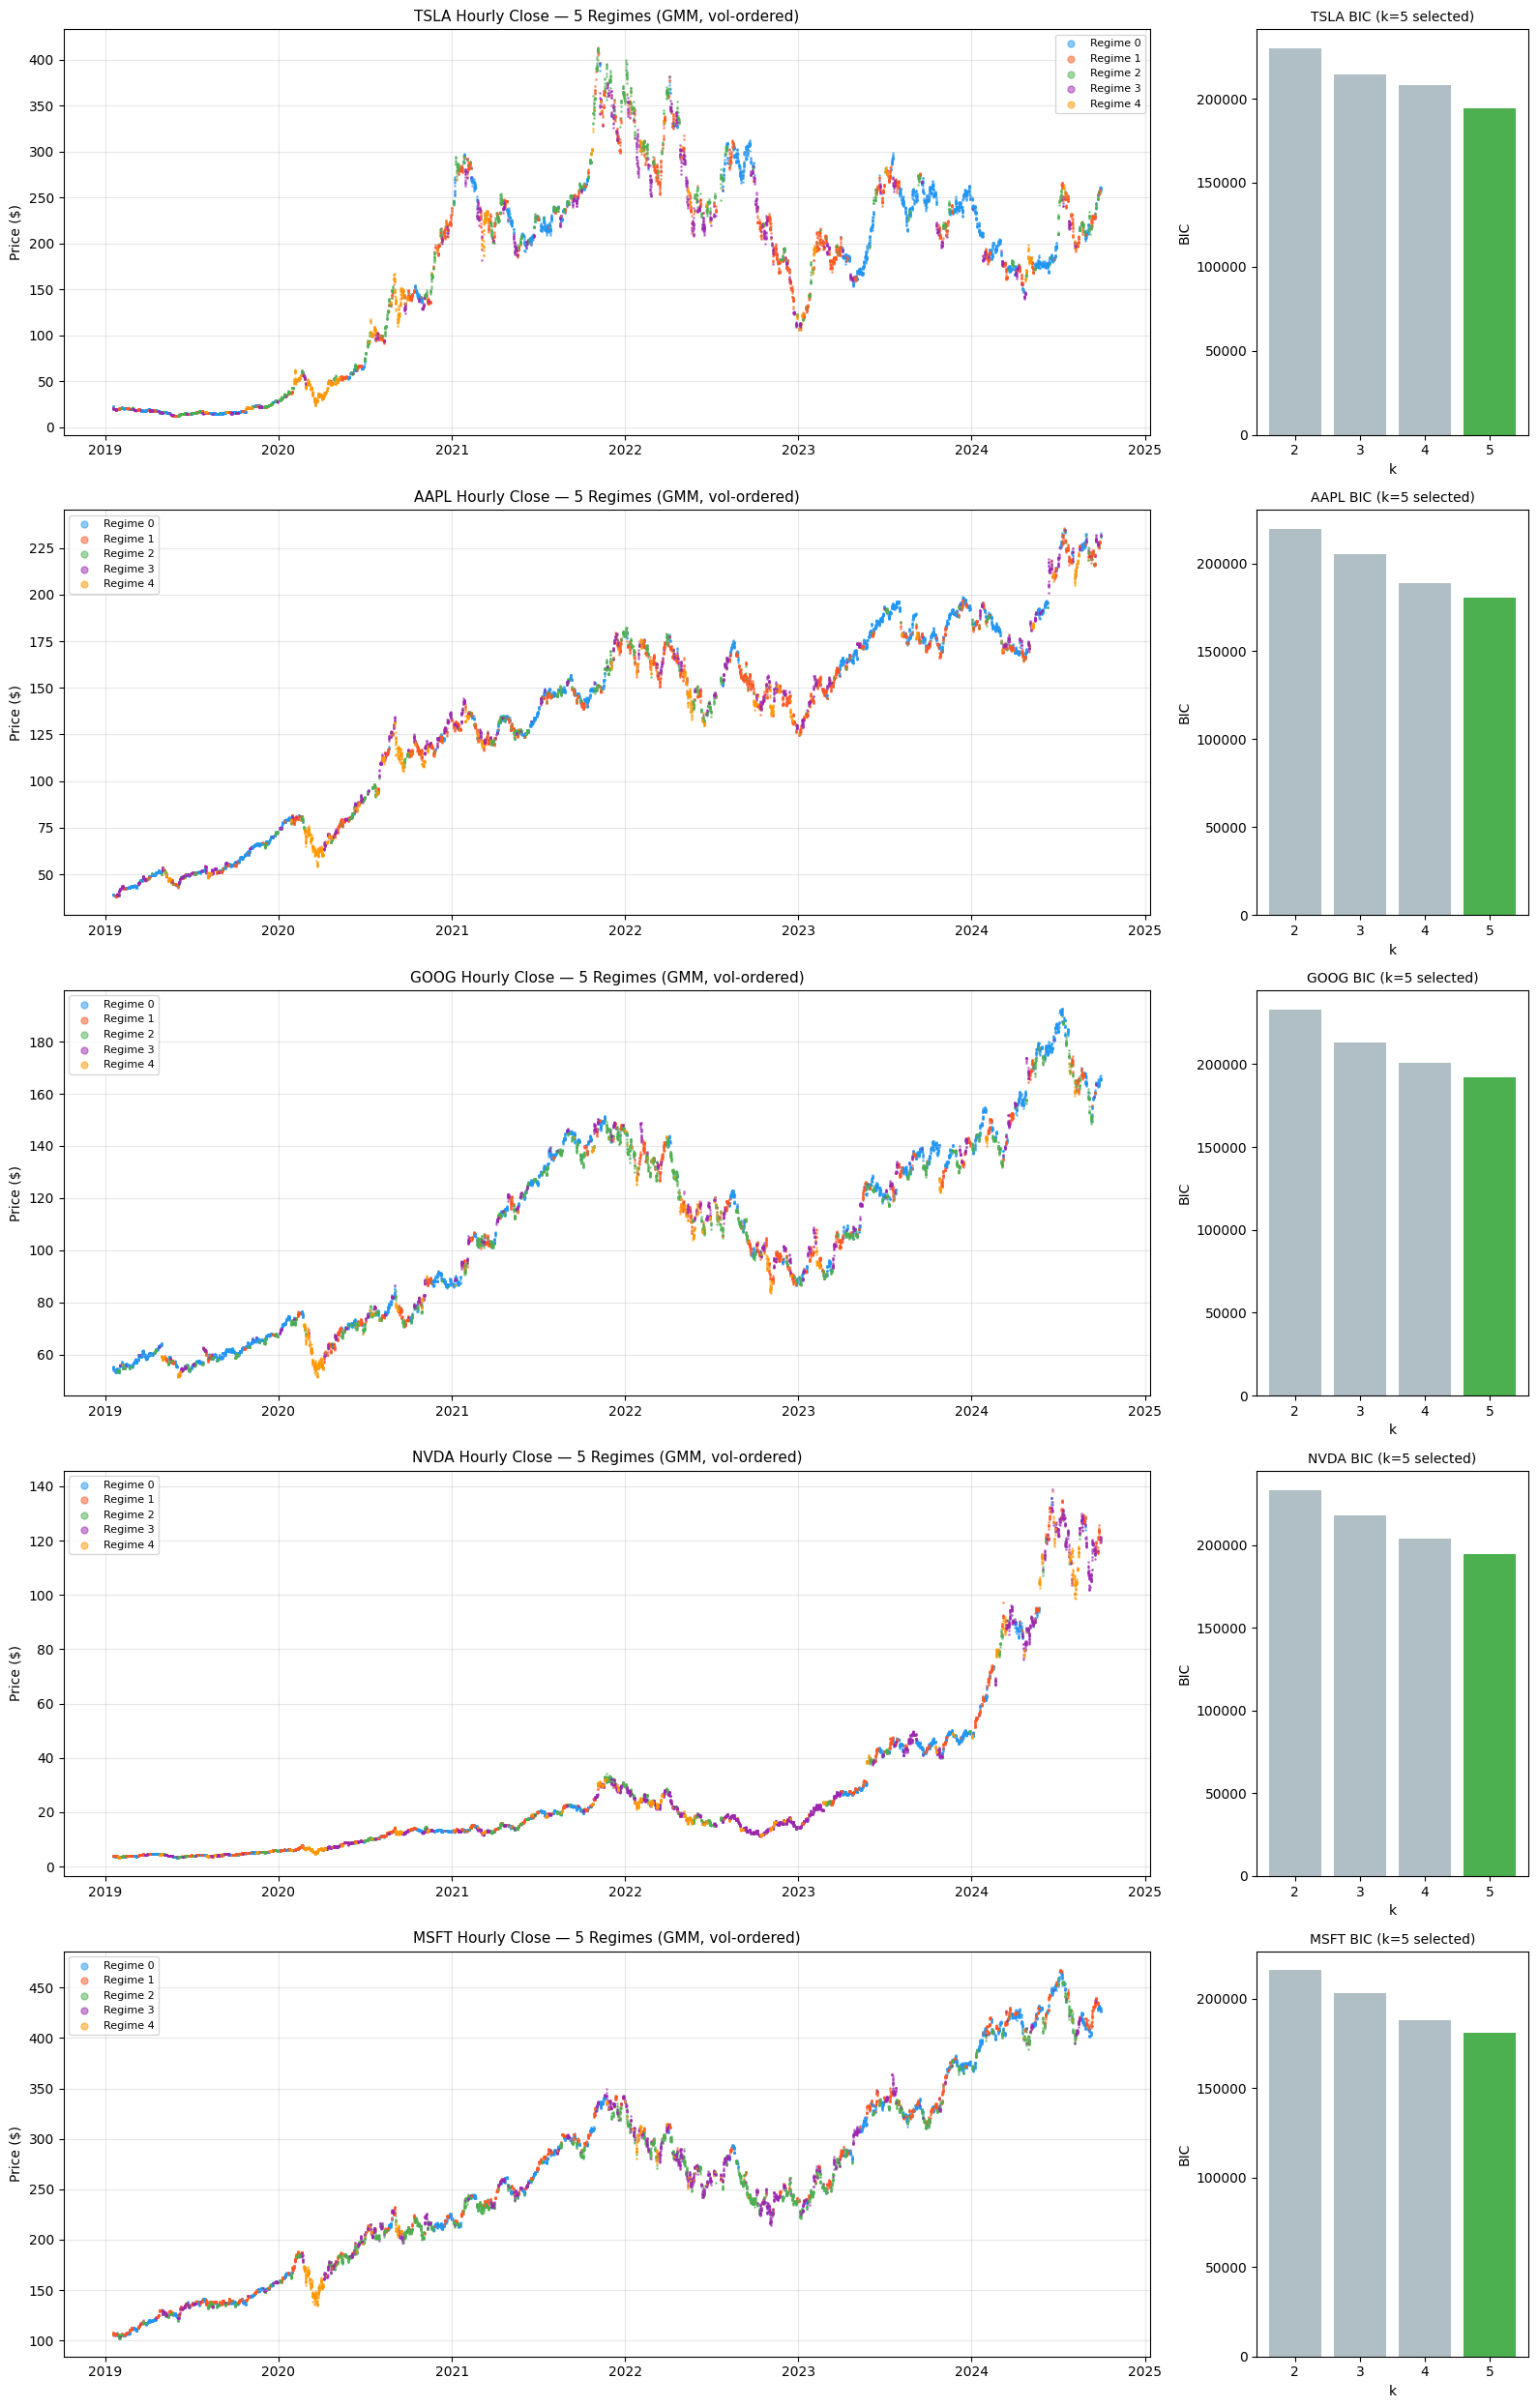


TSLA per-regime stats:
  Regime 0 (3,326 bars): mean_ret=0.0060%  vol=0.8845%  avg_volume=13,168,694
  Regime 1 (2,831 bars): mean_ret=0.0061%  vol=1.0810%  avg_volume=14,999,575
  Regime 2 (1,707 bars): mean_ret=0.3107%  vol=1.6525%  avg_volume=17,543,033
  Regime 3 (1,239 bars): mean_ret=-0.3368%  vol=1.8892%  avg_volume=19,102,984
  Regime 4 (841 bars): mean_ret=0.1093%  vol=2.5136%  avg_volume=29,941,261

AAPL per-regime stats:
  Regime 0 (3,293 bars): mean_ret=0.0299%  vol=0.3847%  avg_volume=8,544,999
  Regime 1 (3,109 bars): mean_ret=-0.0199%  vol=0.5471%  avg_volume=10,067,993
  Regime 2 (1,052 bars): mean_ret=-0.0355%  vol=0.8887%  avg_volume=10,804,045
  Regime 3 (1,536 bars): mean_ret=0.1826%  vol=0.9039%  avg_volume=13,305,471
  Regime 4 (887 bars): mean_ret=-0.1129%  vol=1.2898%  avg_volume=17,985,176

GOOG per-regime stats:
  Regime 0 (4,149 bars): mean_ret=0.0311%  vol=0.4420%  avg_volume=2,678,645
  Regime 1 (2,070 bars): mean_ret=0.0026%  vol=0.6132%  avg_volume=2,987

In [ ]:
# ---------------------------------------------------------------------------
# Cell 10b — Component 1: Per-Ticker Regime Classifier  [Option B]
# ---------------------------------------------------------------------------

def engineer_regime_features(df: pd.DataFrame) -> pd.DataFrame:
    """15 OHLCV-derived regime features. No future leakage."""
    out = pd.DataFrame(index=df.index)
    tr = pd.concat([
        df['High'] - df['Low'],
        (df['High'] - df['Close'].shift(1)).abs(),
        (df['Low']  - df['Close'].shift(1)).abs()
    ], axis=1).max(axis=1)

    out['atr_14']           = tr.rolling(14).mean() / df['Close']
    out['atr_56']           = tr.rolling(56).mean() / df['Close']
    out['atr_ratio']        = out['atr_14'] / out['atr_56'].replace(0, np.nan)
    log_ret                 = np.log(df['Close'] / df['Close'].shift(1))
    out['realized_vol_20']  = log_ret.rolling(20).std()
    out['realized_vol_60']  = log_ret.rolling(60).std()
    out['vol_regime_ratio'] = out['realized_vol_20'] / out['realized_vol_60'].replace(0, np.nan)

    sma20 = df['Close'].rolling(20).mean()
    std20 = df['Close'].rolling(20).std()
    out['bb_bandwidth']     = (2 * std20) / sma20.replace(0, np.nan)
    out['bb_position']      = (df['Close'] - (sma20 - 2*std20)) / (4*std20).replace(0, np.nan)
    # FIX: normalise slope by window mean, not current-bar close
    out['sma_slope']        = sma20.rolling(10).apply(
        lambda x: np.polyfit(range(len(x)), x, 1)[0] / x.mean(), raw=True)
    out['ret_skew']         = log_ret.rolling(20).skew()
    # FIX: use built-in .kurt() — consistent with .skew(), ~100x faster than apply/raw=False
    out['ret_kurt']         = log_ret.rolling(20).kurt()

    vol_sma14               = df['Volume'].rolling(14).mean()
    out['volume_ratio']     = df['Volume'] / vol_sma14.replace(0, np.nan)
    log_vol                 = np.log1p(df['Volume'])
    out['volume_trend']     = log_vol.rolling(20).apply(
        lambda x: np.polyfit(range(len(x)), x, 1)[0], raw=True)
    out['avg_range_7']      = ((df['High'] - df['Low']) / df['Close']).rolling(7).mean()
    body_ratio              = (df['Close'] - df['Open']).abs() / (df['High'] - df['Low']).replace(0, np.nan)
    out['avg_body_ratio_7'] = body_ratio.rolling(7).mean()

    return out.dropna()


# ── Per-ticker loop ────────────────────────────────────────────────────────
regime_store = {}   # {ticker: {features, labels, regime_series, k, gmm, scaler, bic, xgb_proxy, ohlcv}}

for ticker, csv_path in HOURLY_CSV.items():
    print(f"\n{'─'*55}")
    print(f"  {ticker}")
    print(f"{'─'*55}")

    try:
        # 1. Load hourly
        df_h = pd.read_csv(csv_path, parse_dates=['Date'])
        df_h = df_h.sort_values('Date').set_index('Date')
        df_h.columns = [c.strip() for c in df_h.columns]
        print(f"  Hourly bars : {len(df_h)}  ({df_h.index.min().date()} → {df_h.index.max().date()})")

        # 2. Engineer features
        feat = engineer_regime_features(df_h)
        print(f"  Regime features: {feat.shape}  (warmup dropped: {len(df_h)-len(feat)} bars)")

        # 3. Scale + BIC selection
        scaler = StandardScaler()
        X = scaler.fit_transform(feat)

        bic_scores, gmm_models = {}, {}
        for k in range(REGIME_K_RANGE[0], REGIME_K_RANGE[1] + 1):
            gmm = GaussianMixture(n_components=k, covariance_type='full',
                                  n_init=5, max_iter=300, random_state=REGIME_RANDOM_STATE)
            gmm.fit(X)
            bic_scores[k] = gmm.bic(X)
            gmm_models[k] = gmm

        k_best   = min(bic_scores, key=bic_scores.get)
        gmm_best = gmm_models[k_best]
        labels   = gmm_best.predict(X)

        # FIX: use numpy indexing — avoids ambiguous .loc with numpy boolean on DatetimeIndex
        feat_vol    = feat['realized_vol_20'].values
        cluster_vol = [feat_vol[labels == r].mean() for r in range(k_best)]
        order       = np.argsort(cluster_vol)
        label_map   = {old: new for new, old in enumerate(order)}
        labels      = np.array([label_map[l] for l in labels])

        regime_series = pd.Series(labels, index=feat.index, name='regime_label')
        print(f"  k_best={k_best}  |  regime dist: {pd.Series(labels).value_counts().sort_index().to_dict()}")

        # 4. XGBoost proxy — FIX: fit a fresh GMM per CV fold to avoid label leakage
        tscv_r     = TimeSeriesSplit(n_splits=5)
        proxy_accs = []
        for tr_i, val_i in tscv_r.split(X):
            # Fit GMM on train fold only
            gmm_fold = GaussianMixture(
                n_components=k_best, covariance_type='full',
                n_init=3, max_iter=300, random_state=REGIME_RANDOM_STATE
            )
            gmm_fold.fit(X[tr_i])
            fold_lbl_tr  = gmm_fold.predict(X[tr_i])
            fold_lbl_val = gmm_fold.predict(X[val_i])

            # Vol-order fold labels consistently
            fold_cv  = [feat_vol[tr_i][fold_lbl_tr == r].mean() for r in range(k_best)]
            fold_ord = np.argsort(fold_cv)
            fold_map = {old: new for new, old in enumerate(fold_ord)}
            fold_lbl_tr  = np.array([fold_map[l] for l in fold_lbl_tr])
            fold_lbl_val = np.array([fold_map[l] for l in fold_lbl_val])

            xgb_fold = XGBClassifier(
                n_estimators=100, max_depth=3, learning_rate=0.1,
                subsample=0.8, colsample_bytree=0.8,
                random_state=42, eval_metric='mlogloss'
            )
            xgb_fold.fit(X[tr_i], fold_lbl_tr)
            proxy_accs.append((xgb_fold.predict(X[val_i]) == fold_lbl_val).mean())

        # Refit final proxy on full labelled data
        xgb_proxy = XGBClassifier(
            n_estimators=100, max_depth=3, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8,
            random_state=42, eval_metric='mlogloss'
        )
        xgb_proxy.fit(X, labels)
        print(f"  XGBoost proxy CV acc: {np.mean(proxy_accs):.3f} ± {np.std(proxy_accs):.3f}")

        # FIX: store only the aligned slice needed for viz/stats — not the full df_h
        # FIX: alignment via feat.index (not fragile iloc[-len(labels):])
        regime_store[ticker] = {
            'features':      feat,
            'labels':        labels,
            'regime_series': regime_series,
            'k':             k_best,
            'gmm':           gmm_best,
            'scaler':        scaler,
            'bic':           bic_scores,
            'xgb_proxy':     xgb_proxy,
            'ohlcv':         df_h.loc[feat.index, ['Open', 'High', 'Low', 'Close', 'Volume']],
        }

    except Exception as e:
        print(f"  WARNING: {ticker} skipped — {e}")
        continue

# FIX: always assign after loop — not conditionally inside it (stale on re-run otherwise)
REGIME_FEATURE_COLS = next(iter(regime_store.values()))['features'].columns.tolist() if regime_store else []


# ── Visualization: one row per ticker ─────────────────────────────────────
colors = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800']
n      = len(regime_store)
fig, axes = plt.subplots(n, 2, figsize=(16, 5 * n),
                         gridspec_kw={'width_ratios': [4, 1]})
if n == 1:
    axes = [axes]

for row, (ticker, store) in enumerate(regime_store.items()):
    feat   = store['features']
    labels = store['labels']
    k      = store['k']        # FIX: single variable — removed duplicate k_best
    bic    = store['bic']
    price  = store['ohlcv']['Close']

    ax = axes[row][0]
    for r in range(k):
        mask = labels == r
        ax.scatter(feat.index[mask], price.values[mask],
                   c=colors[r % len(colors)], s=1, alpha=0.5, label=f'Regime {r}')
    ax.set_title(f'{ticker} Hourly Close — {k} Regimes (GMM, vol-ordered)', fontsize=11)
    ax.set_ylabel('Price ($)')
    ax.legend(fontsize=8, markerscale=5)
    ax.grid(alpha=0.3)

    ax2 = axes[row][1]
    ks = sorted(bic.keys())
    bar_colors = ['#4CAF50' if kk == k else '#B0BEC5' for kk in ks]
    ax2.bar(ks, [bic[kk] for kk in ks], color=bar_colors)
    ax2.set_title(f'{ticker} BIC (k={k} selected)', fontsize=10)
    ax2.set_xlabel('k')
    ax2.set_ylabel('BIC')
    ax2.set_xticks(ks)

plt.tight_layout()
plt.show()


# ── Per-regime stats ───────────────────────────────────────────────────────
for ticker, store in regime_store.items():
    labels = store['labels']
    k      = store['k']
    ohlcv  = store['ohlcv'].copy()          # already aligned to feat.index
    ohlcv['regime']  = labels
    ohlcv['log_ret'] = np.log(ohlcv['Close'] / ohlcv['Close'].shift(1))

    print(f"\n{ticker} per-regime stats:")
    for r in range(k):
        sub = ohlcv[ohlcv['regime'] == r]
        print(f"  Regime {r} ({len(sub):,} bars): "
              f"mean_ret={sub['log_ret'].mean()*100:.4f}%  "
              f"vol={sub['log_ret'].std()*100:.4f}%  "
              f"avg_volume={sub['Volume'].mean():,.0f}")

regime_summary = {t: f"k={s['k']}" for t, s in regime_store.items()}
print(f"\nregime_store ready: {regime_summary}")


In [ ]:
# ---------------------------------------------------------------------------
# Cell 10c — Feature Assembly  [multi-ticker: WITH vs NO MIDAS split]
# ---------------------------------------------------------------------------
from statsmodels.stats.outliers_influence import variance_inflation_factor


def _strip_tz(idx):
    if not isinstance(idx, pd.DatetimeIndex):
        idx = pd.to_datetime(idx)
    return idx.tz_convert(None) if idx.tz is not None else idx


def _load_sweeps(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df['timestamp'] = pd.to_datetime(df['timestamp'], dayfirst=True, format='mixed')
    df = df.sort_values('timestamp').reset_index(drop=True)
    df = df[df['outcome'] != 'TIMEOUT'].reset_index(drop=True)
    return df


def _apply_dollar_normalisation(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    ref = out['zone_level']
    candle = out['candle_total_range'].replace(0, np.nan)

    out['reversal_distance_pct'] = out['reversal_distance'] / ref
    out['candle_range_pct'] = out['candle_total_range'] / ref
    out['body_ratio'] = out['candle_body'] / candle
    out['lower_wick_ratio'] = out['lower_wick'] / candle
    out['upper_wick_ratio'] = out['upper_wick'] / candle

    out['log_touchcount'] = np.log1p(out['zone_accumulated_touch_count'])
    out['log_touches_at_inversion'] = np.log1p(out['touches_at_inversion'])
    return out


# ── Step 1: Load sweeps (teacher WITH MIDAS, student NO MIDAS) ─────────────
df_teacher = _load_sweeps(SWEEPS_WITH_MIDAS_CSV)
df_student = _load_sweeps(SWEEPS_NO_MIDAS_CSV)

for name, df in [("teacher", df_teacher), ("student", df_student)]:
    if 'sweep_id' not in df.columns:
        raise KeyError(f"{name} sweeps missing sweep_id — cannot align teacher/student")

# Align rows by sweep_id to guarantee identical samples/order
teacher_idx = df_teacher.set_index('sweep_id', drop=False)
student_idx = df_student.set_index('sweep_id', drop=False)
common_ids = teacher_idx.index.intersection(student_idx.index)

if len(common_ids) == 0:
    raise ValueError("No overlapping sweep_id between WITH_MIDAS and NO_MIDAS sweeps")

teacher_idx = teacher_idx.loc[common_ids].copy()
student_idx = student_idx.loc[common_ids].copy()

# Use teacher timestamps as the canonical ordering
teacher_idx = teacher_idx.sort_values('timestamp')
student_idx = student_idx.reindex(teacher_idx['sweep_id'].values)

# Back to row-indexed frames
df_teacher = teacher_idx.reset_index(drop=True)
df_student = student_idx.reset_index(drop=True)

# Sanity checks
if not (df_teacher['timestamp'].values == df_student['timestamp'].values).all():
    raise AssertionError("Teacher/student timestamps misaligned after sweep_id alignment")
if not (df_teacher['ticker'].astype(str).values == df_student['ticker'].astype(str).values).all():
    raise AssertionError("Teacher/student tickers misaligned after sweep_id alignment")
if not (df_teacher['outcome'].astype(str).values == df_student['outcome'].astype(str).values).all():
    raise AssertionError("Teacher/student outcomes misaligned after sweep_id alignment")

# Target from teacher (identical to student post-check)
y = (df_teacher['outcome'] == 'WIN').astype(int).values

print(f"Teacher sweeps (WITH MIDAS) after TIMEOUT exclusion : {len(df_teacher)}")
print(f"Student sweeps (NO MIDAS) after TIMEOUT exclusion  : {len(df_student)}")
print(f"Label distribution                                 : WIN={y.sum()}  LOSS={len(y)-y.sum()}")
print(f"Tickers                                            : {df_teacher['ticker'].value_counts().to_dict()}")


# ── Step 2: Dollar normalisation (both) ───────────────────────────────────
df_teacher = _apply_dollar_normalisation(df_teacher)
df_student = _apply_dollar_normalisation(df_student)
print("\nDollar normalisation done")


# ── Step 3: Load & join consolidated MIDAS (teacher only) ─────────────────
df_midas = pd.read_csv(MIDAS_CSV)
df_midas['date'] = pd.to_datetime(df_midas['date'], dayfirst=True).dt.normalize()
# sort before rolling — prevents future-data leakage if CSV is not pre-sorted
df_midas = df_midas.sort_values(['ticker', 'date']).reset_index(drop=True)

for col in MIDAS_ROLLING_COLS:
    df_midas[f'{col}_5d'] = df_midas.groupby('ticker')[col].transform(
        lambda x: x.rolling(5, min_periods=1).mean()
    )
    df_midas[f'{col}_ratio'] = df_midas[col] / df_midas[f'{col}_5d'].replace(0, np.nan)

midas_join_cols = ['ticker', 'date'] + MIDAS_FEATURES_RAW + MIDAS_FEATURES_DERIVED

df_teacher['sweep_date'] = df_teacher['timestamp'].dt.normalize()
df_teacher = df_teacher.merge(
    df_midas[midas_join_cols],
    left_on=['ticker', 'sweep_date'],
    right_on=['ticker', 'date'],
    how='left',
)
# drop date columns created by the merge
# (keep timestamp; keep sweep_id)
df_teacher.drop(columns=['sweep_date', 'date'], inplace=True)

null_midas = df_teacher[MIDAS_FEATURES_RAW].isna().sum().sum()
print(f"MIDAS join null values (teacher): {null_midas}  (expect 0)")
print(
    "MIDAS coverage by ticker (teacher sweeps with all RAW cols non-null):\n"
    f"{df_teacher.groupby('ticker')[MIDAS_FEATURES_RAW].apply(lambda g: g.notna().all(axis=1).sum())}"
)


# ── Step 4: Ticker encoding (teacher only; optional feature) ──────────────
le_ticker = LabelEncoder()
df_teacher['ticker_enc'] = le_ticker.fit_transform(df_teacher['ticker'])
print(f"\nTicker encoding: {dict(zip(le_ticker.classes_, le_ticker.transform(le_ticker.classes_)))}")


# ── Step 5: Per-ticker regime assignment (both) ───────────────────────────
max_k = max(s['k'] for s in regime_store.values())
regime_frac_cols = [f'regime_{r}_frac' for r in range(max_k)]


def assign_regime_from_store(sweeps_df, regime_store, lookback_bars=7, max_k=3):
    """Vectorised regime assignment via merge_asof."""
    frac_cols = [f'regime_{r}_frac' for r in range(max_k)]

    regime_frames = []
    for ticker, store in regime_store.items():
        rs = store['regime_series'].copy()
        rs.index = _strip_tz(rs.index)
        k = store['k']

        tmp = pd.DataFrame({
            'timestamp': rs.index,
            'regime_label': rs.values,
            'ticker': ticker,
        })
        for r in range(k):
            tmp[f'regime_{r}_frac'] = (
                pd.Series((rs == r).values.astype(float))
                .rolling(lookback_bars, min_periods=1)
                .mean()
                .values
            )
        for r in range(k, max_k):
            tmp[f'regime_{r}_frac'] = 0.0
        regime_frames.append(tmp)

    if not regime_frames:
        out = sweeps_df.copy()
        out['regime_label'] = -1
        for col in frac_cols:
            out[col] = 0.0
        return out

    regime_table = pd.concat(regime_frames, ignore_index=True).sort_values(['ticker', 'timestamp'])

    ts_series = pd.to_datetime(sweeps_df['timestamp'])
    ts_stripped = ts_series.dt.tz_convert(None) if ts_series.dt.tz is not None else ts_series

    sweeps_work = sweeps_df.copy()
    sweeps_work['_ts'] = ts_stripped
    sweeps_work = sweeps_work.sort_values('_ts')

    merge_cols = ['_ts', 'regime_label'] + frac_cols
    results = []

    for ticker, grp in sweeps_work.groupby('ticker', sort=False):
        if ticker not in regime_store:
            grp = grp.copy()
            grp['regime_label'] = -1
            for col in frac_cols:
                grp[col] = 0.0
            results.append(grp)
            continue

        rt = regime_table[regime_table['ticker'] == ticker].rename(columns={'timestamp': '_ts'})
        merged = pd.merge_asof(grp, rt[merge_cols], on='_ts', direction='backward')
        results.append(merged)

    out = pd.concat(results).sort_index().drop(columns=['_ts'])
    out['regime_label'] = out['regime_label'].fillna(-1).astype(int)
    for col in frac_cols:
        out[col] = out[col].fillna(0.0)
    return out


df_teacher = assign_regime_from_store(df_teacher, regime_store, max_k=max_k)
df_student = assign_regime_from_store(df_student, regime_store, max_k=max_k)

print("\nRegime assigned (teacher):")
print(df_teacher.groupby(['ticker', 'regime_label']).size().unstack(fill_value=0))


# ── Step 6: Encode categoricals consistently (fit on teacher, mirror to student)
cat_encoded_cols = []
for col in SWEEP_CAT:
    if col not in df_teacher.columns:
        print(f"  WARNING: {col} not found in teacher, skipping")
        continue

    dummies_t = pd.get_dummies(df_teacher[col].astype(str), prefix=col, drop_first=True)
    for dc in dummies_t.columns:
        df_teacher[dc] = dummies_t[dc].values
        cat_encoded_cols.append(dc)

    # Student: reindex to teacher dummy columns
    if col in df_student.columns:
        dummies_s = pd.get_dummies(df_student[col].astype(str), prefix=col, drop_first=True)
        dummies_s = dummies_s.reindex(columns=dummies_t.columns, fill_value=0)
        for dc in dummies_t.columns:
            df_student[dc] = dummies_s[dc].values
    else:
        for dc in dummies_t.columns:
            df_student[dc] = 0

for col in SWEEP_BOOL:
    if col in df_teacher.columns:
        df_teacher[col] = df_teacher[col].astype(int)
    if col in df_student.columns:
        df_student[col] = df_student[col].astype(int)

print(f"\nCategorical encoding: {len(cat_encoded_cols)} dummy columns")


# ── Step 7: Build feature matrices ────────────────────────────────────────
shared_features = (
    SWEEP_NUMERIC
    + SWEEP_BOOL
    + cat_encoded_cols
    + ['regime_label']
    + regime_frac_cols
)

teacher_features = shared_features + MIDAS_FEATURES + TICKER_FEATURE
student_features = [f for f in shared_features if f not in MIDAS_LEAKAGE_COLS]


def _coerce_and_fill(df: pd.DataFrame, feature_cols: list[str]) -> pd.DataFrame:
    out = df.copy()
    for col in feature_cols:
        if col not in out.columns:
            continue
        out[col] = pd.to_numeric(out[col], errors='coerce')
        if out[col].isna().any():
            is_binary = col in (SWEEP_BOOL + cat_encoded_cols)
            fill = 0 if is_binary else out[col].median()
            out[col] = out[col].fillna(fill)
    return out


df_teacher = _coerce_and_fill(df_teacher, teacher_features)
df_student = _coerce_and_fill(df_student, student_features)


# ── Step 8: Feature selection (Spearman corr + VIF) ───────────────────────
def select_features(df, feature_cols, target, min_corr=0.05, vif_threshold=10.0):
    valid = [c for c in feature_cols if c in df.columns]
    corrs = df[valid + [target]].corr(method='spearman')[target].drop(target)
    relevant = corrs[corrs.abs() >= min_corr].index.tolist()

    if len(relevant) < 2:
        return relevant

    X_vif = df[relevant].copy().fillna(df[relevant].median())
    X_vif = (X_vif - X_vif.mean()) / X_vif.std().replace(0, 1)

    dropped = []
    while True:
        vif_vals = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
        vif_data = pd.DataFrame({'feature': X_vif.columns, 'VIF': vif_vals})
        max_vif = vif_data['VIF'].max()
        if max_vif <= vif_threshold or len(X_vif.columns) <= 1:
            break
        worst = vif_data.loc[vif_data['VIF'].idxmax(), 'feature']
        dropped.append((worst, round(max_vif, 1)))
        X_vif = X_vif.drop(columns=[worst])

    if dropped:
        print(f"  VIF dropped {len(dropped)}: {dropped}")
    return X_vif.columns.tolist()


# Teacher selection on teacher df; student selection on student df
try:
    df_teacher['_target'] = y
    df_student['_target'] = y

    print("\n── Teacher feature selection ──")
    teacher_selected = select_features(df_teacher, teacher_features, '_target')

    print("\n── Student feature selection ──")
    student_selected = select_features(df_student, student_features, '_target')
finally:
    df_teacher.drop(columns=['_target'], errors='ignore', inplace=True)
    df_student.drop(columns=['_target'], errors='ignore', inplace=True)


# Export canonical variables expected downstream
df_sweeps = df_teacher
df_sweeps_student = df_student

X_teacher = df_sweeps[teacher_selected].values.astype(np.float64)
X_student = df_sweeps_student[student_selected].values.astype(np.float64)

print(f"\n── Feature Summary ──")
print(f"Teacher : {X_teacher.shape[1]} features  (from {len(teacher_features)} candidates)")
print(f"Student : {X_student.shape[1]} features  (from {len(student_features)} candidates)")
print(f"Samples : {X_teacher.shape[0]}  (WIN={y.sum()}, LOSS={len(y)-y.sum()})")
print(f"\nTeacher-only : {sorted(set(teacher_selected) - set(student_selected))}")


Teacher sweeps (WITH MIDAS) after TIMEOUT exclusion : 465
Student sweeps (NO MIDAS) after TIMEOUT exclusion  : 465
Label distribution                                 : WIN=56  LOSS=409
Tickers                                            : {'MSFT': 116, 'NVDA': 102, 'AAPL': 94, 'TSLA': 78, 'GOOG': 75}

Dollar normalisation done
MIDAS join null values (teacher): 0  (expect 0)
MIDAS coverage by ticker (teacher sweeps with all RAW cols non-null):
ticker
AAPL     94
GOOG     75
MSFT    116
NVDA    102
TSLA     78
dtype: int64

Ticker encoding: {'AAPL': 0, 'GOOG': 1, 'MSFT': 2, 'NVDA': 3, 'TSLA': 4}

Regime assigned (teacher):
regime_label   0   1   2   3   4
ticker                          
AAPL          26  30   9   7  22
GOOG          29  12  23   4   7
MSFT          24  15  45  22  10
NVDA          35   9  23  22  13
TSLA          33  12  16  11   6

Categorical encoding: 11 dummy columns

── Teacher feature selection ──
  VIF dropped 2: [('inversioncount', inf), ('Hidden_Rate', 37.8)]

─

In [ ]:
# Sort df_sweeps by timestamp and re-derive y and feature matrices to stay aligned.
# Cell 10c guarantees teacher/student alignment by sweep_id; we preserve that here.

df_sweeps = df_sweeps.sort_values('timestamp').reset_index(drop=True)

# Keep student in the same order as teacher
if 'sweep_id' in df_sweeps.columns and 'sweep_id' in df_sweeps_student.columns:
    df_sweeps_student = (
        df_sweeps_student.set_index('sweep_id', drop=False)
        .reindex(df_sweeps['sweep_id'].values)
        .reset_index(drop=True)
    )

# Re-derive targets + feature matrices
y = (df_sweeps['outcome'] != 'LOSS').astype(int).values

X_teacher = df_sweeps[teacher_selected].values.astype(np.float64)
X_student = df_sweeps_student[student_selected].values.astype(np.float64)

assert df_sweeps['timestamp'].is_monotonic_increasing
assert len(X_teacher) == len(X_student) == len(y)

# ---------------------------------------------------------------------------
# Cell 10d — Temporal Cross-Validation Setup  [multi-ticker]
# ---------------------------------------------------------------------------

def temporal_cv_splits(n_samples, n_folds=N_CV_FOLDS, min_train=MIN_TRAIN_SIZE, purge=PURGE_GAP):
    """
    Expanding-window temporal CV with purge gap.
    Purge gap skips `purge` samples between train end and test start
    to prevent 2-day forward-window label leakage.
    Sorted by timestamp across all tickers — no per-ticker split needed.
    """
    test_size = (n_samples - min_train - purge) // n_folds
    if test_size < 1:
        raise ValueError(
            f"Not enough samples for CV: n_samples={n_samples}, min_train={min_train}, "
            f"purge={purge}, n_folds={n_folds}. "
            f"Need at least {min_train + purge + n_folds} samples."
        )

    splits = []
    for fold in range(n_folds):
        test_start = min_train + purge + fold * test_size
        test_end = min(test_start + test_size, n_samples)
        if fold == n_folds - 1:
            test_end = n_samples  # last fold absorbs remainder

        train_end = test_start - purge
        train_idx = list(range(0, train_end))
        test_idx = list(range(test_start, test_end))

        if len(train_idx) >= 10 and len(test_idx) >= 2:
            splits.append((np.array(train_idx), np.array(test_idx)))
    return splits


assert df_sweeps['timestamp'].is_monotonic_increasing, (
    "df_sweeps must be sorted by timestamp before temporal CV. "
    "Run: df_sweeps = df_sweeps.sort_values('timestamp').reset_index(drop=True)"
)

cv_splits = temporal_cv_splits(len(y))

print("── Temporal CV Splits ──")
print(f"Total samples : {len(y)}  |  Folds: {len(cv_splits)}  |  Purge gap: {PURGE_GAP}")
print()

for i, (tr, te) in enumerate(cv_splits):
    tr_dates = (
        df_sweeps.iloc[tr[0]]['timestamp'].strftime('%Y-%m-%d'),
        df_sweeps.iloc[tr[-1]]['timestamp'].strftime('%Y-%m-%d'),
    )
    te_dates = (
        df_sweeps.iloc[te[0]]['timestamp'].strftime('%Y-%m-%d'),
        df_sweeps.iloc[te[-1]]['timestamp'].strftime('%Y-%m-%d'),
    )

    tr_tickers = df_sweeps.iloc[tr]['ticker'].value_counts().to_dict()
    te_tickers = df_sweeps.iloc[te]['ticker'].value_counts().to_dict()

    print(
        f"  Fold {i}:  Train [{tr[0]:2d}:{tr[-1]:2d}] ({len(tr):2d} samples, "
        f"WR={y[tr].mean():.0%})  {tr_dates[0]} → {tr_dates[1]}  {tr_tickers}"
    )
    print(
        f"           Test  [{te[0]:2d}:{te[-1]:2d}] ({len(te):2d} samples, "
        f"WR={y[te].mean():.0%})  {te_dates[0]} → {te_dates[1]}  {te_tickers}"
    )

for i, (tr, te) in enumerate(cv_splits):
    excluded = te[0] - tr[-1] - 1
    assert excluded >= PURGE_GAP, (
        f"Fold {i}: purge violation! excluded={excluded}, required={PURGE_GAP}"
    )

    t_train_end = df_sweeps.iloc[tr[-1]]['timestamp']
    t_test_start = df_sweeps.iloc[te[0]]['timestamp']
    assert t_test_start > t_train_end, (
        f"Fold {i}: test starts ({t_test_start}) before train ends ({t_train_end}) — temporal leak!"
    )

print(
    f"\nLeakage check PASSED — all folds have >= {PURGE_GAP} excluded samples "
    f"and test timestamps strictly after train timestamps"
)


# ── Evaluation helpers ─────────────────────────────────────────────────────
def evaluate_model(y_true, y_prob, threshold=0.12):
    y_pred = (y_prob >= threshold).astype(int)
    tp = (y_pred.astype(bool) & y_true.astype(bool)).sum()
    return {
        'auc': roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else 0.5,
        'brier': brier_score_loss(y_true, y_prob),
        'accuracy': (y_pred == y_true).mean(),
        'precision': tp / max(y_pred.sum(), 1),
        'recall': tp / max(y_true.sum(), 1),
        'n_test': len(y_true),
        'win_rate_actual': y_true.mean(),
    }


def aggregate_cv_metrics(fold_metrics):
    if not fold_metrics:
        raise ValueError(
            "aggregate_cv_metrics: no fold results to aggregate — "
            "check that cv_splits is non-empty and all folds completed"
        )
    keys = fold_metrics[0].keys()
    return {
        f'{k}_{s}': fn([m[k] for m in fold_metrics])
        for k in keys
        for s, fn in [('mean', np.mean), ('std', np.std)]
    }


print("\nEvaluation functions ready")


── Temporal CV Splits ──
Total samples : 315  |  Folds: 5  |  Purge gap: 3

  Fold 0:  Train [ 0:14] (15 samples, WR=7%)  2019-01-29 → 2019-07-16  {'MSFT': 6, 'TSLA': 4, 'NVDA': 2, 'AAPL': 2, 'GOOG': 1}
           Test  [18:76] (59 samples, WR=15%)  2019-08-14 → 2020-05-13  {'MSFT': 14, 'AAPL': 14, 'NVDA': 12, 'TSLA': 12, 'GOOG': 7}
  Fold 1:  Train [ 0:73] (74 samples, WR=14%)  2019-01-29 → 2020-04-16  {'MSFT': 21, 'TSLA': 15, 'AAPL': 15, 'NVDA': 13, 'GOOG': 10}
           Test  [77:135] (59 samples, WR=8%)  2020-06-02 → 2021-05-12  {'AAPL': 17, 'MSFT': 15, 'NVDA': 11, 'GOOG': 9, 'TSLA': 7}
  Fold 2:  Train [ 0:132] (133 samples, WR=11%)  2019-01-29 → 2021-04-29  {'MSFT': 36, 'AAPL': 33, 'NVDA': 23, 'TSLA': 22, 'GOOG': 19}
           Test  [136:194] (59 samples, WR=8%)  2021-05-12 → 2022-04-06  {'MSFT': 18, 'NVDA': 17, 'GOOG': 8, 'TSLA': 8, 'AAPL': 8}
  Fold 3:  Train [ 0:191] (192 samples, WR=10%)  2019-01-29 → 2022-04-01  {'MSFT': 52, 'NVDA': 42, 'AAPL': 40, 'TSLA': 31, 'GOOG': 27}


Model                                 AUC        Brier        Acc       Prec        Rec
B1: Majority class            0.500±0.00   0.098±0.02   0.726±0.32   0.017±0.03   0.200±0.40
B2: Quality score             0.475±0.08   0.343±0.03   0.108±0.03   0.108±0.03   1.000±0.00
B3: LR (sweep only)           0.481±0.12   0.235±0.03   0.196±0.14   0.101±0.02   0.867±0.27
B4: LR (sweep+regime)         0.467±0.18   0.231±0.04   0.233±0.21   0.077±0.04   0.760±0.39
B5: Teacher LR                0.477±0.15   0.229±0.03   0.257±0.19   0.079±0.04   0.760±0.39
B6: Teacher XGB               0.438±0.06   0.184±0.08   0.408±0.27   0.068±0.04   0.500±0.32


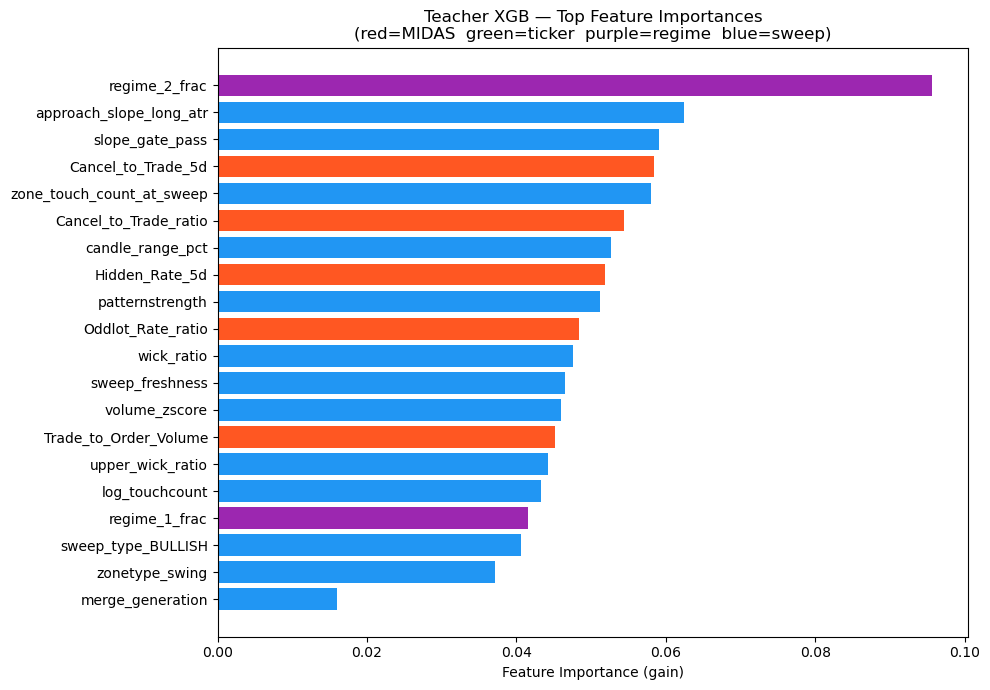


Teacher OOF predictions: 297/315 samples covered (94.3%)
  (samples in min_train window [18] are never in a test fold — will be excluded from distillation)

── Threshold-Tuned Results (F1-optimal, OOF) ─────────────────────────
Model                             AUC  Threshold    Precision     Recall       F1
B3: LR (sweep only)             0.481      0.016        0.111      1.000    0.200
B4: LR (sweep+regime)           0.467      0.362        0.117      0.594    0.196
B5: Teacher LR                  0.477      0.327        0.117      0.625    0.197
B6: Teacher XGB                 0.438      0.021        0.110      1.000    0.199
NOTE: Thresholds tuned on OOF predictions (in-sample). Directional only.


In [ ]:
# ---------------------------------------------------------------------------
# Cell 10e — Component 2: Teacher Model Training + Evaluation
# ---------------------------------------------------------------------------

# FIX 1: always re-derive y here — regime_label=-1 can corrupt y if cells
# ran out of order or df_sweeps was mutated after Cell 10d
# Or try different thresholds:
y = (df_sweeps['outcome'] != 'LOSS').astype(int).values
SCALE_POS_WEIGHT = (y == 0).sum() / (y == 1).sum()

assert set(np.unique(y)) == {0, 1}, f"y has unexpected values: {np.unique(y)}"

# FIX 2: custom log_loss scorer that explicitly passes labels=[0,1]
# neg_log_loss crashes when an inner fold has only one class present
from sklearn.metrics import make_scorer, log_loss as _log_loss
_ll_scorer = make_scorer(
    # _log_loss, needs_proba=True, labels=[0, 1], greater_is_better=False
    _log_loss, response_method='predict_proba', labels=[0, 1], greater_is_better=False
)

from sklearn.model_selection import StratifiedKFold

teacher_oof_probs = np.full(len(y), np.nan)  # out-of-fold P(WIN) for distillation
all_results       = {}

# ── B1: Majority class ────────────────────────────────────────────────────
b1_metrics = []
for tr, te in cv_splits:
    y_prob = np.full(len(te), y[tr].mean())
    b1_metrics.append(evaluate_model(y[te], y_prob))
all_results['B1: Majority class'] = aggregate_cv_metrics(b1_metrics)

# ── B2: Quality score threshold ───────────────────────────────────────────
b2_metrics = []
for tr, te in cv_splits:
    # FIX: clip to [0,1] — scores outside range corrupt brier/auc silently
    y_prob = np.clip(df_sweeps.iloc[te]['sweep_quality_score'].values / 100.0, 0.0, 1.0)
    b2_metrics.append(evaluate_model(y[te], y_prob))
all_results['B2: Quality score'] = aggregate_cv_metrics(b2_metrics)

# ── B3: Logistic Regression — sweep features only (no regime, no MIDAS) ──
student_no_regime   = [f for f in student_selected
                       if f != 'regime_label' and not f.startswith('regime_')]
X_student_no_regime = df_sweeps[student_no_regime].values.astype(np.float64)

b3_metrics = []
for tr, te in cv_splits:
    scaler = StandardScaler()
    X_tr   = scaler.fit_transform(X_student_no_regime[tr])
    X_te   = scaler.transform(X_student_no_regime[te])
    lr = LogisticRegressionCV(
        Cs=np.logspace(-3, 2, 15), penalty='elasticnet', solver='saga',
        l1_ratios=[0.1, 0.5, 0.9],
        cv=3, scoring=_ll_scorer,
        max_iter=5000, random_state=42, class_weight='balanced'
    )
    lr.fit(X_tr, y[tr])
    b3_metrics.append(evaluate_model(y[te], lr.predict_proba(X_te)[:, 1]))
all_results['B3: LR (sweep only)'] = aggregate_cv_metrics(b3_metrics)

# ── B4: Logistic Regression — sweep + regime (no MIDAS) ──────────────────
b4_metrics = []
for tr, te in cv_splits:
    scaler = StandardScaler()
    X_tr   = scaler.fit_transform(X_student[tr])
    X_te   = scaler.transform(X_student[te])
    lr = LogisticRegressionCV(
        Cs=np.logspace(-3, 2, 15), penalty='elasticnet', solver='saga',
        l1_ratios=[0.1, 0.5, 0.9],
        cv=3, scoring=_ll_scorer,
        max_iter=5000, random_state=42, class_weight='balanced'
    )
    lr.fit(X_tr, y[tr])
    b4_metrics.append(evaluate_model(y[te], lr.predict_proba(X_te)[:, 1]))
all_results['B4: LR (sweep+regime)'] = aggregate_cv_metrics(b4_metrics)

# ── B5: Logistic Regression — sweep + MIDAS + regime + ticker ────────────
b5_metrics = []
for tr, te in cv_splits:
    scaler = StandardScaler()
    X_tr   = scaler.fit_transform(X_teacher[tr])
    X_te   = scaler.transform(X_teacher[te])
    lr = LogisticRegressionCV(
        Cs=np.logspace(-3, 2, 15), penalty='elasticnet', solver='saga',
        l1_ratios=[0.1, 0.5, 0.9],
        cv=3, scoring=_ll_scorer,
        max_iter=5000, random_state=42, class_weight='balanced'
    )
    lr.fit(X_tr, y[tr])
    b5_metrics.append(evaluate_model(y[te], lr.predict_proba(X_te)[:, 1]))
all_results['B5: Teacher LR'] = aggregate_cv_metrics(b5_metrics)

# ── B6: XGBoost Teacher — sweep + MIDAS + regime + ticker  [PRIMARY] ─────
b6_metrics = []
for tr, te in cv_splits:
    n_val     = max(int(0.15 * len(tr)), 5)
    tr_inner  = tr[:-n_val]
    val_inner = tr[-n_val:]

    xgb = XGBClassifier(
        n_estimators=200, max_depth=3, learning_rate=0.05,
        min_child_weight=5, subsample=0.7, colsample_bytree=0.5,
        reg_alpha=0.5, reg_lambda=2.0,
        scale_pos_weight=SCALE_POS_WEIGHT,
        random_state=42, eval_metric='logloss',
        early_stopping_rounds=20
    )
    xgb.fit(
        X_teacher[tr_inner], y[tr_inner],
        eval_set=[(X_teacher[val_inner], y[val_inner])],
        verbose=False
    )
    y_prob = xgb.predict_proba(X_teacher[te])[:, 1]
    b6_metrics.append(evaluate_model(y[te], y_prob))
    teacher_oof_probs[te] = y_prob

all_results['B6: Teacher XGB'] = aggregate_cv_metrics(b6_metrics)

# ── Print results (default threshold=0.5) ────────────────────────────────
print("=" * 95)
print(f"{'Model':<28} {'AUC':>12} {'Brier':>12} {'Acc':>10} {'Prec':>10} {'Rec':>10}")
print("=" * 95)
for name, agg in all_results.items():
    print(f"{name:<28} "
          f"{agg['auc_mean']:6.3f}±{agg['auc_std']:.2f}  "
          f"{agg['brier_mean']:6.3f}±{agg['brier_std']:.2f}  "
          f"{agg['accuracy_mean']:6.3f}±{agg['accuracy_std']:.2f}  "
          f"{agg['precision_mean']:6.3f}±{agg['precision_std']:.2f}  "
          f"{agg['recall_mean']:6.3f}±{agg['recall_std']:.2f}")
print("=" * 95)

# ── Teacher feature importance (refit on full data for plot only) ─────────
xgb_teacher_full = XGBClassifier(
    n_estimators=200, max_depth=3, learning_rate=0.05,
    min_child_weight=5, subsample=0.7, colsample_bytree=0.5,
    reg_alpha=0.5, reg_lambda=2.0,
    scale_pos_weight=SCALE_POS_WEIGHT,
    random_state=42, eval_metric='logloss'
)
xgb_teacher_full.fit(X_teacher, y, verbose=False)

feat_imp = sorted(zip(teacher_selected, xgb_teacher_full.feature_importances_),
                  key=lambda x: x[1], reverse=True)
top_n = min(20, len(feat_imp))
names = [f[0] for f in feat_imp[:top_n]][::-1]
vals  = [f[1] for f in feat_imp[:top_n]][::-1]

def feat_color(n):
    if n in MIDAS_FEATURES or n in MIDAS_FEATURES_DERIVED:  return '#FF5722'
    if n in TICKER_FEATURE:                                   return '#4CAF50'
    if n.startswith('regime_'):                               return '#9C27B0'
    return '#2196F3'

fig, ax = plt.subplots(figsize=(10, max(5, top_n * 0.35)))
ax.barh(names, vals, color=[feat_color(n) for n in names])
ax.set_xlabel('Feature Importance (gain)')
ax.set_title('Teacher XGB — Top Feature Importances\n'
             '(red=MIDAS  green=ticker  purple=regime  blue=sweep)')
plt.tight_layout()
plt.show()

oof_n        = np.sum(~np.isnan(teacher_oof_probs))
oof_coverage = oof_n / len(y)
print(f"\nTeacher OOF predictions: {oof_n}/{len(y)} samples covered ({oof_coverage:.1%})")
print(f"  (samples in min_train window [{len(y) - oof_n}] are never in a test fold — "
      f"will be excluded from distillation)")

assert oof_coverage >= 0.5, (
    f"Teacher OOF coverage too low: {oof_coverage:.1%}. "
    f"Increase n_samples or reduce MIN_TRAIN_SIZE / N_CV_FOLDS."
)

# ── FIX 3: Threshold tuning — XGB/Baseline models default to recall=0 ────
# With 12% WIN rate, default threshold=0.5 means no WIN is ever predicted.
# Find the F1-optimal threshold per model using OOF probabilities.
from sklearn.metrics import precision_recall_curve

b3_oof = np.full(len(y), np.nan)
b4_oof = np.full(len(y), np.nan)
b5_oof = np.full(len(y), np.nan)

for tr, te in cv_splits:
    scaler = StandardScaler()

    # B3
    X_tr = scaler.fit_transform(X_student_no_regime[tr])
    X_te = scaler.transform(X_student_no_regime[te])
    lr = LogisticRegressionCV(
        Cs=np.logspace(-3, 2, 15), penalty='elasticnet', solver='saga',
        l1_ratios=[0.1, 0.5, 0.9], cv=3, scoring=_ll_scorer,
        max_iter=5000, random_state=42, class_weight='balanced'
    )
    lr.fit(X_tr, y[tr])
    b3_oof[te] = lr.predict_proba(X_te)[:, 1]

    # B4
    X_tr = scaler.fit_transform(X_student[tr])
    X_te = scaler.transform(X_student[te])
    lr = LogisticRegressionCV(
        Cs=np.logspace(-3, 2, 15), penalty='elasticnet', solver='saga',
        l1_ratios=[0.1, 0.5, 0.9], cv=3, scoring=_ll_scorer,
        max_iter=5000, random_state=42, class_weight='balanced'
    )
    lr.fit(X_tr, y[tr])
    b4_oof[te] = lr.predict_proba(X_te)[:, 1]

    # B5
    X_tr = scaler.fit_transform(X_teacher[tr])
    X_te = scaler.transform(X_teacher[te])
    lr = LogisticRegressionCV(
        Cs=np.logspace(-3, 2, 15), penalty='elasticnet', solver='saga',
        l1_ratios=[0.1, 0.5, 0.9], cv=3, scoring=_ll_scorer,
        max_iter=5000, random_state=42, class_weight='balanced'
    )
    lr.fit(X_tr, y[tr])
    b5_oof[te] = lr.predict_proba(X_te)[:, 1]

oof_map_teacher = {
    'B3: LR (sweep only)'   : b3_oof,
    'B4: LR (sweep+regime)' : b4_oof,
    'B5: Teacher LR'        : b5_oof,
    'B6: Teacher XGB'       : teacher_oof_probs,
}

print("\n── Threshold-Tuned Results (F1-optimal, OOF) ─────────────────────────")
print(f"{'Model':<28} {'AUC':>8} {'Threshold':>10} {'Precision':>12} {'Recall':>10} {'F1':>8}")
print("=" * 80)
for name, probs in oof_map_teacher.items():
    mask = ~np.isnan(probs)
    if mask.sum() == 0:
        continue
    p, r, t = precision_recall_curve(y[mask], probs[mask])
    f1       = 2 * p * r / (p + r + 1e-9)
    opt_t    = t[f1.argmax()]
    y_pred   = (probs[mask] >= opt_t).astype(int)
    tp       = (y_pred.astype(bool) & y[mask].astype(bool)).sum()
    prec_v   = tp / max(y_pred.sum(), 1)
    rec_v    = tp / max(y[mask].sum(), 1)
    f1_v     = 2 * prec_v * rec_v / (prec_v + rec_v + 1e-9)
    auc_v    = all_results[name]['auc_mean']
    print(f"{name:<28} {auc_v:>8.3f} {opt_t:>10.3f} {prec_v:>12.3f} {rec_v:>10.3f} {f1_v:>8.3f}")
print("=" * 80)
print("NOTE: Thresholds tuned on OOF predictions (in-sample). Directional only.")


── Student Model Results ──
Model                                 AUC        Brier        Acc
-----------------------------------------------------------------
S1: Student (hard labels)     0.500±0.00   0.101±0.03   0.560±0.39
S2: Student (α=0.5)           0.496±0.08   0.108±0.03   0.247±0.30
S3: Student (α=0.7)           0.517±0.08   0.113±0.03   0.413±0.38
S4: Student (α=1.0)           0.459±0.05   0.123±0.03   0.413±0.38


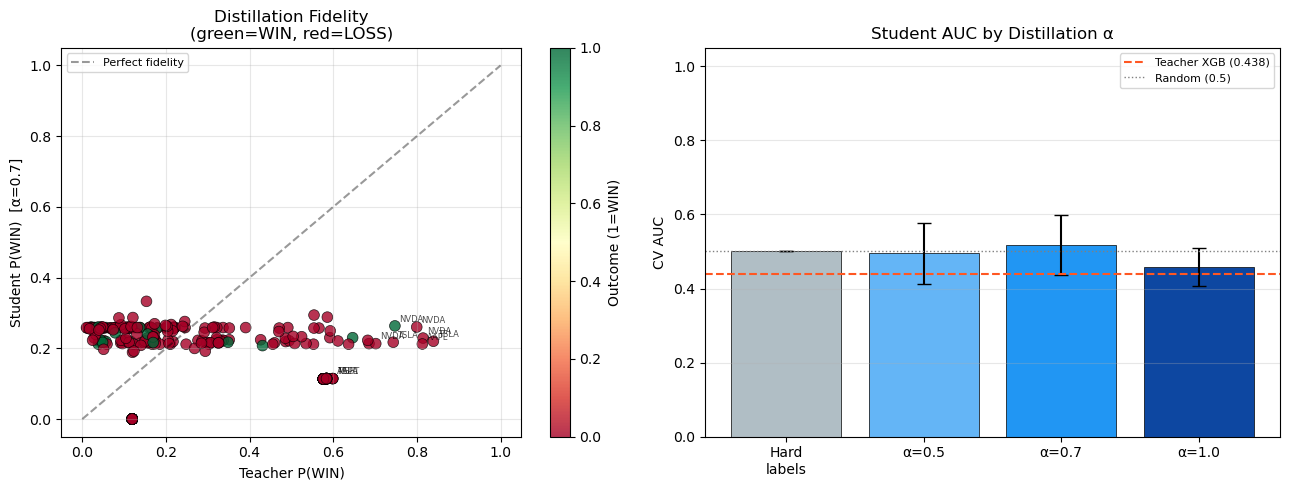


Distillation fidelity (Pearson r, S3 vs Teacher): -0.024


In [ ]:
# ---------------------------------------------------------------------------
# Cell 10f — Component 3: Student Model Training (Knowledge Distillation)
# ---------------------------------------------------------------------------

# ── S1: XGBoost on hard labels only (no distillation — baseline) ──────────
s1_metrics = []
for tr, te in cv_splits:
    # FIX: use inner hold-out from training fold for early stopping — not the test fold
    n_val     = max(int(0.15 * len(tr)), 5)
    tr_inner  = tr[:-n_val]
    val_inner = tr[-n_val:]

    xgb = XGBClassifier(
        n_estimators=200, max_depth=2, learning_rate=0.05,
        min_child_weight=8, subsample=0.7, colsample_bytree=0.6,
        reg_alpha=1.0, reg_lambda=5.0,
        random_state=42, eval_metric='logloss',
        early_stopping_rounds=20
    )
    xgb.fit(X_student[tr_inner], y[tr_inner],
            eval_set=[(X_student[val_inner], y[val_inner])], verbose=False)
    s1_metrics.append(evaluate_model(y[te], xgb.predict_proba(X_student[te])[:, 1]))
all_results['S1: Student (hard labels)'] = aggregate_cv_metrics(s1_metrics)


# ── Distillation helper ────────────────────────────────────────────────────
def train_distilled_student(X_stu, y_hard, teacher_oof, cv_splits, alpha):
    """
    XGBRegressor on blended soft targets:
        target = alpha * teacher_prob + (1 - alpha) * hard_label
    Evaluated against hard labels (ground truth).
    Early stopping uses an inner hold-out from the training fold only —
    test fold is never touched during fitting.
    """
    fold_metrics = []
    oof_preds    = np.full(len(y_hard), np.nan)

    for tr, te in cv_splits:
        # FIX: split training fold into inner train + inner val for early stopping.
        # Original code passed soft_te (which embeds y_hard[te]) to eval_set —
        # ground-truth test labels were leaking directly into the early stopping signal.
        n_val     = max(int(0.15 * len(tr)), 5)
        tr_inner  = tr[:-n_val]
        val_inner = tr[-n_val:]

        # Soft targets for inner train
        t_tr = teacher_oof[tr_inner].copy()
        t_tr[np.isnan(t_tr)] = y_hard[tr_inner][np.isnan(t_tr)].astype(float)
        soft_tr = alpha * t_tr + (1 - alpha) * y_hard[tr_inner].astype(float)

        # Soft targets for inner val (early stopping signal — no test data)
        t_val = teacher_oof[val_inner].copy()
        t_val[np.isnan(t_val)] = y_hard[val_inner][np.isnan(t_val)].astype(float)
        soft_val = alpha * t_val + (1 - alpha) * y_hard[val_inner].astype(float)

        student = XGBRegressor(
            n_estimators=200, max_depth=2, learning_rate=0.05,
            min_child_weight=8, subsample=0.7, colsample_bytree=0.6,
            reg_alpha=1.0, reg_lambda=5.0,
            random_state=42,
            eval_metric='mae',           # FIX: explicit — mae more appropriate than default rmse for [0,1] targets
            early_stopping_rounds=20
        )
        student.fit(X_stu[tr_inner], soft_tr,
                    eval_set=[(X_stu[val_inner], soft_val)], verbose=False)

        y_prob = np.clip(student.predict(X_stu[te]), 0, 1)
        oof_preds[te] = y_prob
        fold_metrics.append(evaluate_model(y_hard[te], y_prob))

    return fold_metrics, oof_preds


# ── S2: alpha=0.5 ─────────────────────────────────────────────────────────
s2_metrics, s2_oof = train_distilled_student(X_student, y, teacher_oof_probs, cv_splits, alpha=0.5)
all_results['S2: Student (α=0.5)'] = aggregate_cv_metrics(s2_metrics)

# ── S3: alpha=0.7 (recommended) ───────────────────────────────────────────
s3_metrics, s3_oof = train_distilled_student(X_student, y, teacher_oof_probs, cv_splits, alpha=0.7)
all_results['S3: Student (α=0.7)'] = aggregate_cv_metrics(s3_metrics)

# ── S4: alpha=1.0 (pure distillation) ────────────────────────────────────
s4_metrics, s4_oof = train_distilled_student(X_student, y, teacher_oof_probs, cv_splits, alpha=1.0)
all_results['S4: Student (α=1.0)'] = aggregate_cv_metrics(s4_metrics)


# ── Student results table ──────────────────────────────────────────────────
print("── Student Model Results ──")
print(f"{'Model':<28} {'AUC':>12} {'Brier':>12} {'Acc':>10}")
print("-" * 65)
for name in ['S1: Student (hard labels)', 'S2: Student (α=0.5)',
             'S3: Student (α=0.7)',       'S4: Student (α=1.0)']:
    agg = all_results[name]
    print(f"{name:<28} "
          f"{agg['auc_mean']:6.3f}±{agg['auc_std']:.2f}  "
          f"{agg['brier_mean']:6.3f}±{agg['brier_std']:.2f}  "
          f"{agg['accuracy_mean']:6.3f}±{agg['accuracy_std']:.2f}")


# ── Distillation fidelity scatter (S3 vs Teacher OOF) ────────────────────
mask = ~np.isnan(teacher_oof_probs) & ~np.isnan(s3_oof)
if mask.sum() > 5:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    ax = axes[0]
    sc = ax.scatter(teacher_oof_probs[mask], s3_oof[mask],
                    c=y[mask], cmap='RdYlGn', alpha=0.8,
                    edgecolors='k', linewidths=0.5, s=60,
                    vmin=0, vmax=1)
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Perfect fidelity')

    # FIX: only annotate the 10 points furthest from the diagonal (biggest misses)
    # — annotating all points produces completely unreadable overlapping text
    masked_idx  = np.where(mask)[0]
    residuals   = np.abs(teacher_oof_probs[masked_idx] - s3_oof[masked_idx])
    top_outliers = masked_idx[np.argsort(residuals)[-10:]]
    for idx in top_outliers:
        ax.annotate(df_sweeps.iloc[idx]['ticker'],
                    (teacher_oof_probs[idx], s3_oof[idx]),
                    fontsize=6, alpha=0.7,
                    xytext=(3, 3), textcoords='offset points')

    plt.colorbar(sc, ax=ax, label='Outcome (1=WIN)')
    ax.set_xlabel('Teacher P(WIN)')
    ax.set_ylabel('Student P(WIN)  [α=0.7]')
    ax.set_title('Distillation Fidelity\n(green=WIN, red=LOSS)')
    ax.legend(fontsize=8)
    ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
    ax.grid(alpha=0.3)

    ax2 = axes[1]
    alphas    = ['Hard\nlabels', 'α=0.5', 'α=0.7', 'α=1.0']
    keys      = ['S1: Student (hard labels)', 'S2: Student (α=0.5)',
                 'S3: Student (α=0.7)',        'S4: Student (α=1.0)']
    auc_means = [all_results[k]['auc_mean'] for k in keys]
    auc_stds  = [all_results[k]['auc_std']  for k in keys]
    bar_colors = ['#B0BEC5', '#64B5F6', '#2196F3', '#0D47A1']
    # FIX: removed dead `bars =` assignment
    ax2.bar(alphas, auc_means, yerr=auc_stds, color=bar_colors,
            capsize=5, edgecolor='k', linewidth=0.5)
    ax2.axhline(all_results['B6: Teacher XGB']['auc_mean'],
                color='#FF5722', linestyle='--', linewidth=1.5,
                label=f"Teacher XGB ({all_results['B6: Teacher XGB']['auc_mean']:.3f})")
    ax2.axhline(0.5, color='gray', linestyle=':', linewidth=1, label='Random (0.5)')
    ax2.set_ylabel('CV AUC')
    ax2.set_title('Student AUC by Distillation α')
    ax2.set_ylim(0, 1.05)
    ax2.legend(fontsize=8)
    ax2.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

    fidelity = np.corrcoef(teacher_oof_probs[mask], s3_oof[mask])[0, 1]
    print(f"\nDistillation fidelity (Pearson r, S3 vs Teacher): {fidelity:.3f}")
else:
    print("\nInsufficient OOF overlap for fidelity plot")


Model                                 AUC        Brier     Accuracy    Precision       Recall
B1: Majority class            0.500±0.00   0.098±0.02   0.726±0.32   0.017±0.03   0.200±0.40
B2: Quality score             0.475±0.08   0.343±0.03   0.108±0.03   0.108±0.03   1.000±0.00
B3: LR (sweep only)           0.481±0.12   0.235±0.03   0.196±0.14   0.101±0.02   0.867±0.27
B4: LR (sweep+regime)         0.467±0.18   0.231±0.04   0.233±0.21   0.077±0.04   0.760±0.39
B5: Teacher LR                0.477±0.15   0.229±0.03   0.257±0.19   0.079±0.04   0.760±0.39
B6: Teacher XGB               0.438±0.06   0.184±0.08   0.408±0.27   0.068±0.04   0.500±0.32
S1: Student (hard labels)     0.500±0.00   0.101±0.03   0.560±0.39   0.034±0.04   0.400±0.49
S2: Student (α=0.5)           0.496±0.08   0.108±0.03   0.247±0.30   0.077±0.04   0.800±0.40
S3: Student (α=0.7)           0.517±0.08   0.113±0.03   0.413±0.38   0.060±0.05   0.600±0.49 ◀
S4: Student (α=1.0)           0.459±0.05   0.123±0.03   0.413±0.38 

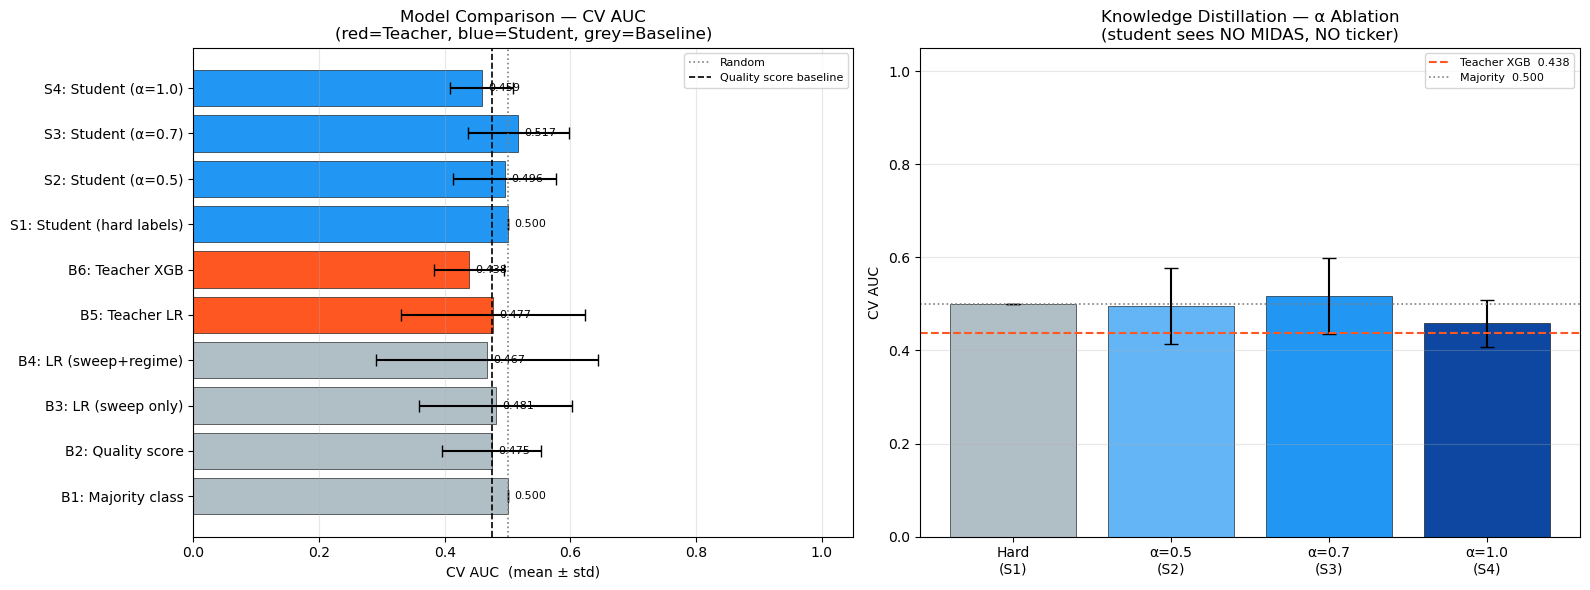

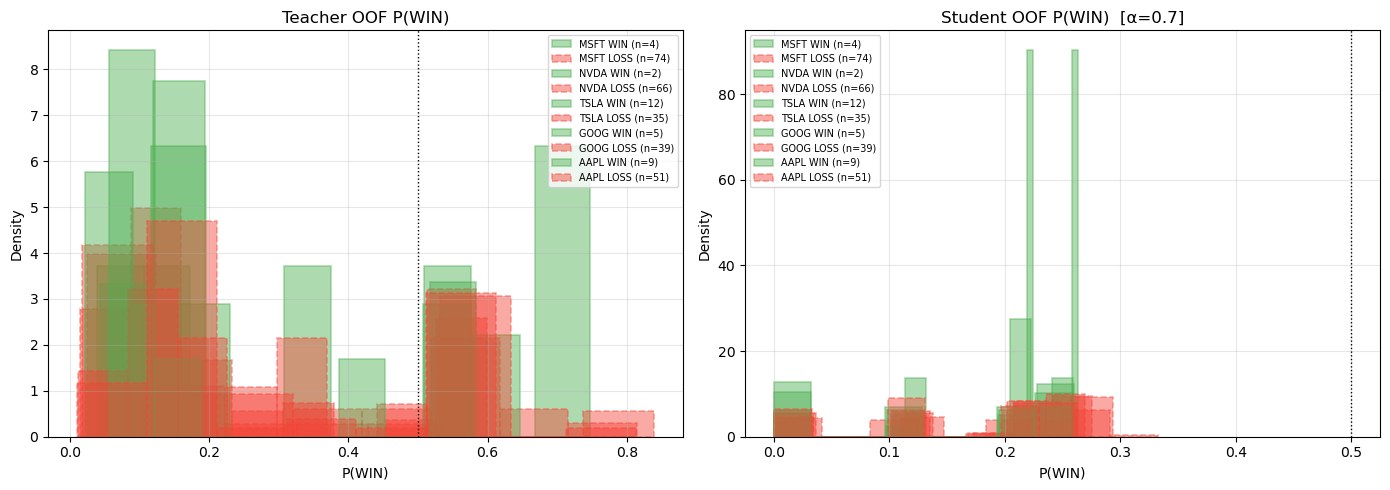


── Key Findings ──────────────────────────────────────────────────────
  Dataset          : 315 sweeps  ({'MSFT': 85, 'NVDA': 70, 'AAPL': 62, 'TSLA': 51, 'GOOG': 47})
  Label balance    : WIN=33  LOSS=282  (TIMEOUT excluded)
  Regime k         : {'TSLA': 5, 'AAPL': 5, 'GOOG': 5, 'NVDA': 5, 'MSFT': 5}

  Quality baseline : AUC 0.475
  Teacher XGB      : AUC 0.438  (↓0.036 vs baseline)
  Student α=0.7    : AUC 0.517  (↑0.042 vs baseline  |  gap to teacher: 0.079)
  Best model       : S3: Student (α=0.7)  (AUC 0.517)

  NOTE: N=36 — treat AUC std as primary signal, mean as indicative only.
        Add more tickers to reduce variance before drawing conclusions.


In [ ]:
# ---------------------------------------------------------------------------
# Cell 10g — Results Summary, Ablation & Visualisations
# ---------------------------------------------------------------------------

model_order = [
    'B1: Majority class',
    'B2: Quality score',
    'B3: LR (sweep only)',
    'B4: LR (sweep+regime)',
    'B5: Teacher LR',
    'B6: Teacher XGB',
    'S1: Student (hard labels)',
    'S2: Student (α=0.5)',
    'S3: Student (α=0.7)',
    'S4: Student (α=1.0)',
]

# ── 1. Full comparison table ───────────────────────────────────────────────
print("=" * 105)
print(f"{'Model':<28} {'AUC':>12} {'Brier':>12} {'Accuracy':>12} {'Precision':>12} {'Recall':>12}")
print("=" * 105)
for name in model_order:
    if name not in all_results:
        continue
    agg = all_results[name]
    # Highlight best AUC
    marker = " ◀" if name == max(
        (n for n in model_order if n in all_results),
        key=lambda n: all_results[n]['auc_mean']
    ) else ""
    print(f"{name:<28} "
          f"{agg['auc_mean']:6.3f}±{agg['auc_std']:.2f}  "
          f"{agg['brier_mean']:6.3f}±{agg['brier_std']:.2f}  "
          f"{agg['accuracy_mean']:6.3f}±{agg['accuracy_std']:.2f}  "
          f"{agg['precision_mean']:6.3f}±{agg['precision_std']:.2f}  "
          f"{agg['recall_mean']:6.3f}±{agg['recall_std']:.2f}{marker}")
print("=" * 105)

# ── 2. AUC comparison chart ────────────────────────────────────────────────
present   = [n for n in model_order if n in all_results]
auc_means = [all_results[n]['auc_mean'] for n in present]
auc_stds  = [all_results[n]['auc_std']  for n in present]

def bar_color(name):
    if 'Teacher' in name: return '#FF5722'
    if 'Student' in name: return '#2196F3'
    return '#B0BEC5'

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
bars = ax.barh(present, auc_means, xerr=auc_stds,
               color=[bar_color(n) for n in present],
               capsize=4, edgecolor='k', linewidth=0.4)
ax.axvline(0.5, color='gray',    linestyle=':', linewidth=1.2, label='Random')
ax.axvline(all_results['B2: Quality score']['auc_mean'],
           color='black', linestyle='--', linewidth=1.2, label='Quality score baseline')
ax.set_xlabel('CV AUC  (mean ± std)')
ax.set_title('Model Comparison — CV AUC\n(red=Teacher, blue=Student, grey=Baseline)')
ax.set_xlim(0, 1.05)
ax.legend(fontsize=8)
ax.grid(axis='x', alpha=0.3)
for bar, val in zip(bars, auc_means):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)

# ── 3. Distillation gain: student vs teacher per alpha ────────────────────
ax2 = axes[1]
student_keys = ['S1: Student (hard labels)', 'S2: Student (α=0.5)',
                'S3: Student (α=0.7)',        'S4: Student (α=1.0)']
x_labels = ['Hard\n(S1)', 'α=0.5\n(S2)', 'α=0.7\n(S3)', 'α=1.0\n(S4)']
s_aucs   = [all_results[k]['auc_mean'] for k in student_keys if k in all_results]
s_stds   = [all_results[k]['auc_std']  for k in student_keys if k in all_results]

ax2.bar(x_labels, s_aucs, yerr=s_stds,
        color=['#B0BEC5', '#64B5F6', '#2196F3', '#0D47A1'],
        capsize=5, edgecolor='k', linewidth=0.4)
ax2.axhline(all_results['B6: Teacher XGB']['auc_mean'],
            color='#FF5722', linestyle='--', linewidth=1.5,
            label=f"Teacher XGB  {all_results['B6: Teacher XGB']['auc_mean']:.3f}")
ax2.axhline(all_results['B1: Majority class']['auc_mean'],
            color='gray', linestyle=':', linewidth=1.2,
            label=f"Majority  {all_results['B1: Majority class']['auc_mean']:.3f}")
ax2.set_ylabel('CV AUC')
ax2.set_title('Knowledge Distillation — α Ablation\n(student sees NO MIDAS, NO ticker)')
ax2.set_ylim(0, 1.05)
ax2.legend(fontsize=8)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ── 4. OOF probability distribution by ticker and outcome ────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (probs, label) in zip(axes, [
    (teacher_oof_probs, 'Teacher OOF P(WIN)'),
    (s3_oof,            'Student OOF P(WIN)  [α=0.7]'),
]):
    mask = ~np.isnan(probs)
    for ticker in df_sweeps['ticker'].unique():
        for outcome, color, ls in [('WIN', '#4CAF50', '-'), ('LOSS', '#F44336', '--')]:
            idx = mask & (df_sweeps['ticker'] == ticker) & (df_sweeps['outcome'] == outcome)
            if idx.sum() > 0:
                ax.hist(probs[idx], bins=8, alpha=0.45, color=color,
                        linestyle=ls, edgecolor=color, linewidth=1.2,
                        label=f'{ticker} {outcome} (n={idx.sum()})', density=True)
    ax.axvline(0.5, color='k', linestyle=':', linewidth=1)
    ax.set_xlabel('P(WIN)')
    ax.set_ylabel('Density')
    ax.set_title(label)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ── 5. Key findings summary ───────────────────────────────────────────────
best_model = max((n for n in model_order if n in all_results),
                 key=lambda n: all_results[n]['auc_mean'])
best_auc   = all_results[best_model]['auc_mean']
teacher_auc = all_results['B6: Teacher XGB']['auc_mean']
s3_auc      = all_results['S3: Student (α=0.7)']['auc_mean']
b2_auc      = all_results['B2: Quality score']['auc_mean']

print("\n── Key Findings ──────────────────────────────────────────────────────")
print(f"  Dataset          : {len(y)} sweeps  ({df_sweeps['ticker'].value_counts().to_dict()})")
print(f"  Label balance    : WIN={y.sum()}  LOSS={len(y)-y.sum()}  (TIMEOUT excluded)")
print(f"  Regime k         : { {t: s['k'] for t, s in regime_store.items()} }")
print()
print(f"  Quality baseline : AUC {b2_auc:.3f}")
print(f"  Teacher XGB      : AUC {teacher_auc:.3f}  "
      f"({'↑' if teacher_auc > b2_auc else '↓'}"
      f"{abs(teacher_auc - b2_auc):.3f} vs baseline)")
print(f"  Student α=0.7    : AUC {s3_auc:.3f}  "
      f"({'↑' if s3_auc > b2_auc else '↓'}"
      f"{abs(s3_auc - b2_auc):.3f} vs baseline  |  "
      f"gap to teacher: {abs(teacher_auc - s3_auc):.3f})")
print(f"  Best model       : {best_model}  (AUC {best_auc:.3f})")
print()
print("  NOTE: N=36 — treat AUC std as primary signal, mean as indicative only.")
print("        Add more tickers to reduce variance before drawing conclusions.")


# Part 11A. Trading Strategy Simulation
In this section, we run an out-of-sample trading simulation on sweep events using a **sensitive RSI(6)-daily exit** built from hourly data. The objective is to estimate realistic portfolio performance without look-ahead bias, using only information known at each entry timestamp.

### Trading Strategy Logic
| Component | Logic / Description |
|-----------|---------------------|
| **Entry Signal** | Trade OOS sweep events with positive Kelly sizing (`kelly_frac_f > 0.01`) and remove duplicate signals by timestamp/zone keys where available. |
| **Trade Direction** | Infer side from sweep type: `BULL -> LONG`, `BEAR -> SHORT`. |
| **Exit Model** | Exits are rule-based using an hourly-updated running daily RSI(6) derived from LTF hourly closes. |
| **Exit Rule (LONG)** | Exit when running daily RSI(6) reaches or exceeds **80**. |
| **Exit Rule (SHORT)** | Exit when running daily RSI(6) falls to or below **20**. |
| **Warm-up / OOS Gate** | OOS gating uses a short warm-up (approximately `max(8, RSI period + 2)` rows) suitable for RSI6 instead of large training windows. |
| **Max Holding Period** | RSI exit search is bounded by a **60-day** horizon; if no RSI trigger appears, the position is **force-exited** at the first tradable bar at/after the horizon (or last available bar if data ends earlier). |
| **Position Sizing** | Uses `kelly_frac_f` when present. If missing, computes via `compute_sweep_risk_metrics` when available; otherwise falls back to a simple quality-based capped sizing. |
| **Exposure Control** | Additional cap of **20% total exposure per timestamp bar** to avoid stacking concurrent entries. |
| **Costs** | Transaction cost modeled as **2 bps (0.02%)** of position notional per trade. |
| **Risk Guardrail** | Portfolio simulation halts if drawdown breaches the max drawdown threshold (default **-20%**). |

In [ ]:
# Part 11A-RSI6-Sensitive: Hourly-updated Daily RSI(6) exit simulation (LTF-based)
# Exit logic aligned with label_sweep_outcomes: SL + RSI race, TIMEOUT skipped

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# ------------------------------
# USER PARAMETERS (edit here)
# ------------------------------
SENS_RSI_PERIOD               = 6
SENS_RSI_LONG_EXIT            = 65.0
SENS_RSI_SHORT_EXIT           = 35.0
SENS_MAX_HOLD_DAYS            = 90

SENS_STOP_BUFFER_PCT          = 0.05   # matches label_sweep_outcomes default
SENS_MIN_STOP_DIST_PCT        = 0.10   # matches label_sweep_outcomes default
SENS_MAX_STOP_DIST_PCT        = 5.00   # matches label_sweep_outcomes default

SENS_INITIAL_CAPITAL          = 1_000_000
SENS_MAX_DD_LIMIT             = -20
SENS_RISK_CAP_PER_TRADE       = 0.10
SENS_MAX_TOTAL_EXPOSURE_PER_BAR = 0.20
SENS_COST_BPS                 = 2


def _load_ltf_for_sensitive_rsi():
    """Load hourly data with full OHLC — high/low required for SL bar checks."""
    if "hourly_data" in globals() and isinstance(hourly_data, pd.DataFrame) and not hourly_data.empty:
        hd = hourly_data.copy()
    else:
        candidates = [
            Path("data/TSLA_hourly_2021-01-04_2024-09-30_with_vol.csv"),
            Path("data/raw/TSLA_hourly_2021-01-04_2024-09-30.csv"),
            Path("data/raw/TSLA_60min.csv"),
        ]
        found = [p for p in candidates if p.exists()]
        if not found:
            raise FileNotFoundError("No LTF hourly data file found in data/ or data/raw/")
        hd = pd.read_csv(found[0])

    # ── FIX: rename Date/Datetime → timestamp BEFORE the index fallback ───
    if "timestamp" not in hd.columns:
        date_col = next(
            (c for c in hd.columns if c.lower() in ("date", "datetime", "time")),
            None,
        )
        if date_col:
            hd = hd.rename(columns={date_col: "timestamp"})
        else:
            hd = hd.reset_index().rename(columns={"index": "timestamp"})

    hd["timestamp"] = pd.to_datetime(hd["timestamp"], errors="coerce")

    # Normalise column names to lowercase
    col_renames = {}
    for src, dst in [("Open", "open"), ("High", "high"), ("Low", "low"), ("Close", "close")]:
        if src in hd.columns and dst not in hd.columns:
            col_renames[src] = dst
    hd.rename(columns=col_renames, inplace=True)

    if "close" not in hd.columns:
        raise ValueError("LTF data must contain close/Close column")

    # Fill missing OHLC columns with close so SL checks still work
    for c in ["open", "high", "low"]:
        if c not in hd.columns:
            hd[c] = hd["close"]

    for c in ["open", "high", "low", "close"]:
        hd[c] = pd.to_numeric(hd[c], errors="coerce")

    hd = (hd.dropna(subset=["timestamp", "close"])
            .sort_values("timestamp")
            .reset_index(drop=True))

    return hd[["timestamp", "open", "high", "low", "close"]].reset_index(drop=True)



def _side_from_sweep_type_sensitive(sweep_type):
    st = str(sweep_type).upper()
    if "BULL" in st:
        return "LONG"
    if "BEAR" in st:
        return "SHORT"
    return None


def _prepare_running_daily_rsi_from_ltf(ltf_df, period=6):
    """
    Build no-lookahead hourly-updated daily RSI(6).
    Returns full OHLC + running_daily_rsi6 so SL bar checks have high/low.
    """
    out = ltf_df.copy()
    out["day"] = out["timestamp"].dt.normalize()

    daily_close = out.groupby("day")["close"].last().sort_index()

    d_delta    = daily_close.diff()
    d_gain     = d_delta.clip(lower=0)
    d_loss     = (-d_delta).clip(lower=0)
    d_avg_gain = d_gain.ewm(alpha=1 / period, adjust=False, min_periods=period).mean()
    d_avg_loss = d_loss.ewm(alpha=1 / period, adjust=False, min_periods=period).mean()

    prev_day_close = daily_close.shift(1)
    prev_avg_gain  = d_avg_gain.shift(1)
    prev_avg_loss  = d_avg_loss.shift(1)

    out["prev_day_close"] = out["day"].map(prev_day_close)
    out["prev_avg_gain"]  = out["day"].map(prev_avg_gain)
    out["prev_avg_loss"]  = out["day"].map(prev_avg_loss)

    d_prov    = out["close"] - out["prev_day_close"]
    gain_prov = d_prov.clip(lower=0)
    loss_prov = (-d_prov).clip(lower=0)

    out["avg_gain_prov"] = (out["prev_avg_gain"] * (period - 1) + gain_prov) / period
    out["avg_loss_prov"] = (out["prev_avg_loss"] * (period - 1) + loss_prov) / period

    rs = out["avg_gain_prov"] / out["avg_loss_prov"].replace(0, np.nan)
    out["running_daily_rsi6"] = 100 - (100 / (1 + rs))
    out["running_daily_rsi6"] = out["running_daily_rsi6"].fillna(50.0)

    # Return full OHLC + RSI — high/low needed downstream for SL checks
    return out[["timestamp", "open", "high", "low", "close", "running_daily_rsi6"]]


def _compute_sl_price(sweep, entry_price, side,
                      stop_buffer_pct, min_stop_dist_pct, max_stop_dist_pct):
    """
    Compute and validate SL price — identical logic to label_sweep_outcomes.
    Returns (sl_price, stop_dist_pct) or (None, None) if invalid.
    """
    if side == "LONG":
        raw_stop = sweep.get("zone_bottom", np.nan)
        if pd.isna(raw_stop):
            raw_stop = sweep.get("sweep_low", np.nan)
        if pd.isna(raw_stop) or abs(raw_stop) < 1e-8:
            return None, None
        sl = raw_stop * (1.0 - stop_buffer_pct / 100.0)
        if sl >= entry_price:          # SL above entry — structurally invalid
            return None, None
    else:
        raw_stop = sweep.get("zone_top", np.nan)
        if pd.isna(raw_stop):
            raw_stop = sweep.get("sweep_high", np.nan)
        if pd.isna(raw_stop) or abs(raw_stop) < 1e-8:
            return None, None
        sl = raw_stop * (1.0 + stop_buffer_pct / 100.0)
        if sl <= entry_price:          # SL below entry — structurally invalid
            return None, None

    stop_dist_pct = abs(entry_price - sl) / entry_price * 100.0
    if stop_dist_pct < min_stop_dist_pct or stop_dist_pct > max_stop_dist_pct:
        return None, None

    return sl, stop_dist_pct


def _find_sensitive_rsi_exit(entry_ts, side, ltf_rsi_df, rsi_by_day, sl,
                              long_thr, short_thr, max_hold_days):
    """
    Bar-by-bar exit scan — mirrors label_sweep_outcomes loop exactly.

    Priority per bar (same as labeler):
      sl_hit AND rsi_hit  → LOSS  (SL takes priority)
      rsi_hit only        → WIN
      sl_hit only         → LOSS
      neither             → continue
    After window: TIMEOUT

    RSI lookup is filtered to <= bar_ts (no intraday look-ahead).
    """
    end_ts = entry_ts + pd.Timedelta(days=max_hold_days)

    fwd = ltf_rsi_df[
        (ltf_rsi_df["timestamp"] > entry_ts) &     # strict: exclude entry bar
        (ltf_rsi_df["timestamp"] <= end_ts)
    ].reset_index(drop=True)

    if fwd.empty:
        return "TIMEOUT", pd.NaT, np.nan, np.nan

    for _, bar in fwd.iterrows():
        bar_ts  = bar["timestamp"]
        bar_day = bar_ts.normalize()

        # ── SL check on bar's actual high/low ──────────────────────────────
        sl_hit = (bar["low"] <= sl) if side == "LONG" else (bar["high"] >= sl)

        # ── RSI check: only rows up to bar_ts, after entry_ts (no look-ahead)
        day_rsi     = rsi_by_day.get(bar_day)
        rsi_hit     = False
        current_rsi = np.nan
        rsi_price   = float(bar["close"])

        if day_rsi is not None and not day_rsi.empty:
            day_rsi_f = day_rsi[
                (day_rsi["timestamp"] > entry_ts) &
                (day_rsi["timestamp"] <= bar_ts)   # no look-ahead
            ]
            if not day_rsi_f.empty:
                if side == "LONG":
                    crossed = day_rsi_f[day_rsi_f["running_daily_rsi6"] >= long_thr]
                else:
                    crossed = day_rsi_f[day_rsi_f["running_daily_rsi6"] <= short_thr]

                if not crossed.empty:
                    first_cross = crossed.iloc[0]
                    current_rsi = float(first_cross["running_daily_rsi6"])
                    rsi_price   = float(first_cross["close"])
                    rsi_hit     = True
                else:
                    current_rsi = float(day_rsi_f.iloc[-1]["running_daily_rsi6"])

        # ── Same priority as label_sweep_outcomes ──────────────────────────
        if sl_hit and rsi_hit:
            return "LOSS", bar_ts, sl, current_rsi
        elif rsi_hit:
            return "WIN",  bar_ts, rsi_price, current_rsi
        elif sl_hit:
            return "LOSS", bar_ts, sl, current_rsi

    return "TIMEOUT", pd.NaT, np.nan, np.nan


def _holding_bars_sensitive(entry_ts, exit_ts, ltf_rsi_df):
    entry_ts = pd.to_datetime(entry_ts, errors="coerce")
    exit_ts  = pd.to_datetime(exit_ts,  errors="coerce")
    if pd.isna(entry_ts) or pd.isna(exit_ts):
        return np.nan

    ts_vals = ltf_rsi_df["timestamp"].values
    i0 = np.searchsorted(ts_vals, np.datetime64(entry_ts), side="left")
    i1 = np.searchsorted(ts_vals, np.datetime64(exit_ts),  side="left")
    if i0 >= len(ts_vals) or i1 >= len(ts_vals) or i1 < i0:
        return np.nan

    return int(i1 - i0 + 1)


def _no_lookahead_fallback_kelly(series_q, min_frac=0.01, max_frac=0.10, min_history=8):
    q = pd.to_numeric(series_q, errors="coerce").fillna(0.0).clip(lower=0.0)

    q_ref_p75 = q.expanding(min_periods=max(2, int(min_history))).quantile(0.75).shift(1)
    q_ref_max = q.expanding(min_periods=1).max().shift(1)
    q_ref     = q_ref_p75.fillna(q_ref_max).replace(0, np.nan)

    ratio    = (q / q_ref).clip(lower=0.0, upper=1.0)
    kelly_fb = min_frac + (max_frac - min_frac) * ratio
    return kelly_fb.fillna(min_frac)


def _prepare_independent_oos_and_kelly(sweeps_df, rsi_period=6, risk_cap_per_trade=0.10):
    out = sweeps_df.copy()
    out["timestamp"] = pd.to_datetime(out["timestamp"], errors="coerce")
    out = out.dropna(subset=["timestamp"]).sort_values("timestamp").reset_index(drop=True)

    if "train_dynamic_exits" in globals():
        out = train_dynamic_exits(out, min_train_size=max(8, int(rsi_period) + 2))
    else:
        warmup_n = max(8, int(rsi_period) + 2)
        out["is_test_set"] = False
        if len(out) > warmup_n:
            out.iloc[warmup_n:, out.columns.get_loc("is_test_set")] = True

    warmup_n = max(8, int(rsi_period) + 2)

    quality_series = (
        out["sweep_quality_score"]
        if "sweep_quality_score" in out.columns
        else pd.Series(0.0, index=out.index)
    )
    fallback_kelly = _no_lookahead_fallback_kelly(
        quality_series,
        min_frac=0.01,
        max_frac=min(float(risk_cap_per_trade), 0.10),
        min_history=warmup_n,
    )

    if "compute_sweep_risk_metrics" in globals():
        out = compute_sweep_risk_metrics(out)
        out = out.reset_index(drop=True)
        out["kelly_frac_f"] = pd.to_numeric(out.get("kelly_frac_f", np.nan), errors="coerce")
        out["kelly_frac_f"] = out["kelly_frac_f"].where(
            out["kelly_frac_f"].notna(),
            fallback_kelly.values,
        )
    else:
        out["kelly_frac_f"] = fallback_kelly.values

    out["kelly_frac_f"] = (
        pd.to_numeric(out["kelly_frac_f"], errors="coerce")
        .fillna(0.01)
        .clip(0.01, risk_cap_per_trade)
    )
    out["is_test_set"] = out.get("is_test_set", False).fillna(False).astype(bool)
    return out


def pro_trading_simulation_sensitive_rsi6_exit(
    sweeps_filtered,
    ltf_rsi_df,
    long_thr=70.0,
    short_thr=30.0,
    max_hold_days=60,
    stop_buffer_pct=0.05,
    min_stop_dist_pct=0.10,
    max_stop_dist_pct=5.00,
    initial_capital=1_000_000,
    max_dd_limit=-20,
    risk_cap_per_trade=0.10,
    max_total_exposure_per_bar=0.20,
    cost_bps=2,
):
    portfolio = initial_capital
    trades    = []
    peak      = portfolio
    exposure_by_timestamp = {}

    # ── Pre-group RSI by calendar day once — reused for every trade ────────
    ltf_rsi_df = ltf_rsi_df.copy()
    ltf_rsi_df["_day"] = ltf_rsi_df["timestamp"].dt.normalize()
    rsi_by_day = {
        day: grp.reset_index(drop=True)
        for day, grp in ltf_rsi_df.groupby("_day", sort=False)
    }

    valid_trades = sweeps_filtered[
        (sweeps_filtered["is_test_set"] == True)
        & (sweeps_filtered["kelly_frac_f"].notna())
        & (sweeps_filtered["kelly_frac_f"] > 0.01)
    ].copy()

    dedup_cols = [c for c in ["timestamp", "sweep_type", "zone_id", "zone_price"] if c in valid_trades.columns]
    if dedup_cols:
        valid_trades = valid_trades.drop_duplicates(subset=dedup_cols)

    valid_trades = valid_trades.sort_values("timestamp")

    skip_counts = {"no_side": 0, "no_entry": 0, "invalid_sl": 0, "timeout": 0}

    for _, sweep in valid_trades.iterrows():
        ts = pd.to_datetime(sweep["timestamp"], errors="coerce")
        if pd.isna(ts):
            continue

        used = exposure_by_timestamp.get(ts, 0.0)
        remaining_exposure = max_total_exposure_per_bar - used
        if remaining_exposure <= 0:
            continue

        kelly_size = float(min(sweep["kelly_frac_f"], risk_cap_per_trade, remaining_exposure))
        if kelly_size <= 0:
            continue

        side = _side_from_sweep_type_sensitive(sweep.get("sweep_type", ""))
        if side is None:
            skip_counts["no_side"] += 1
            continue

        # ── Entry price: use reversal_price (same as label_sweep_outcomes) ─
        entry = sweep.get("reversal_price", np.nan)
        if pd.isna(entry) or abs(entry) < 1e-8:
            skip_counts["no_entry"] += 1
            continue

        # ── SL: same calculation as label_sweep_outcomes ───────────────────
        sl, stop_dist_pct = _compute_sl_price(
            sweep, entry, side,
            stop_buffer_pct, min_stop_dist_pct, max_stop_dist_pct,
        )
        if sl is None:
            skip_counts["invalid_sl"] += 1
            continue

        # ── Bar-by-bar exit scan (SL vs RSI race) ─────────────────────────
        outcome, exit_ts, exit_price, exit_rsi = _find_sensitive_rsi_exit(
            ts, side, ltf_rsi_df, rsi_by_day, sl,
            long_thr=long_thr, short_thr=short_thr, max_hold_days=max_hold_days,
        )

        # ── TIMEOUT: skip — matches label_sweep_outcomes (excluded from risk)
        if outcome == "TIMEOUT":
            skip_counts["timeout"] += 1
            continue

        # ── P&L in pct — WIN at RSI price, LOSS always at SL ──────────────
        if outcome == "WIN":
            raw_ret = (exit_price - entry) / entry * 100.0
            pnl_pct = raw_ret if side == "LONG" else -raw_ret
        else:  # LOSS
            raw_ret = (sl - entry) / entry * 100.0
            pnl_pct = raw_ret if side == "LONG" else -raw_ret

        bars_held     = _holding_bars_sensitive(ts, exit_ts, ltf_rsi_df)
        position_size = portfolio * kelly_size
        slippage_cost = position_size * (cost_bps / 10000.0)
        pnl_dollars   = position_size * (pnl_pct / 100.0) - slippage_cost

        portfolio += pnl_dollars
        exposure_by_timestamp[ts] = used + kelly_size

        drawdown = (portfolio - peak) / peak * 100
        peak     = max(peak, portfolio)

        trades.append({
            "timestamp":          ts,
            "exit_timestamp":     exit_ts,
            "sweep_type":         sweep.get("sweep_type", "NA"),
            "side":               side,
            "outcome":            outcome,
            "sl_price":           sl,
            "stop_dist_pct":      stop_dist_pct,
            "exit_running_rsi6":  exit_rsi,
            "bars_held_hourly":   bars_held,
            "kelly_size_pct":     kelly_size * 100,
            "pnl_pct":            pnl_pct,
            "pnl_dollars":        pnl_dollars,
            "portfolio":          portfolio,
            "drawdown_pct":       drawdown,
        })

        if drawdown < max_dd_limit:
            break

    trades_df = pd.DataFrame(trades)

    print(f"\n  Skip breakdown: {skip_counts}")

    if trades_df.empty:
        return trades_df, {
            "Final Portfolio": f"${initial_capital:,.0f}",
            "Total Return": "0%",
            "Status": "NO TRADES (OOS)",
        }

    total_return   = (portfolio - initial_capital) / initial_capital * 100
    time_diff_days = (trades_df["timestamp"].max() - trades_df["timestamp"].min()).days
    num_years      = time_diff_days / 365.25 if time_diff_days > 0 else 0.001
    cagr           = ((portfolio / initial_capital) ** (1 / num_years) - 1) * 100 if portfolio > 0 else -100

    base_portfolio = trades_df["portfolio"].shift(1).fillna(initial_capital)
    returns        = trades_df["pnl_dollars"] / base_portfolio
    sharpe         = returns.mean() / returns.std() * np.sqrt(252) if returns.std() > 0 else 0

    loss_sum      = abs(trades_df.loc[trades_df["pnl_dollars"] < 0, "pnl_dollars"].sum())
    win_sum       = trades_df.loc[trades_df["pnl_dollars"] > 0, "pnl_dollars"].sum()
    profit_factor = f"{(win_sum / loss_sum):.2f}" if loss_sum > 0 else "inf"

    avg_bars   = trades_df["bars_held_hourly"].dropna().mean() if "bars_held_hourly" in trades_df.columns else np.nan
    n_wins     = (trades_df["outcome"] == "WIN").sum()
    n_losses   = (trades_df["outcome"] == "LOSS").sum()

    metrics = {
        "Final Portfolio":        f"${portfolio:,.0f}",
        "Total Return":           f"{total_return:.1f}%",
        "CAGR":                   f"{cagr:.1f}%",
        "Max Drawdown":           f"{trades_df['drawdown_pct'].min():.1f}%",
        "Sharpe Ratio":           f"{sharpe:.2f}",
        "Win Rate (RSI exit)":    f"{n_wins / len(trades_df) * 100:.1f}%  ({n_wins}/{len(trades_df)})",
        "Loss Rate (SL exit)":    f"{n_losses / len(trades_df) * 100:.1f}%  ({n_losses}/{len(trades_df)})",
        "Profit Factor":          profit_factor,
        "OOS Trades Executed":    len(trades_df),
        "Avg Trade":              f"${trades_df['pnl_dollars'].mean():,.0f}",
        "Avg Bars Held (Hourly)": f"{avg_bars:.1f}" if np.isfinite(avg_bars) else "NA",
        "Long Exit RSI6":         float(long_thr),
        "Short Exit RSI6":        float(short_thr),
        "Max Hold Days":          int(max_hold_days),
        "Stop Buffer %":          stop_buffer_pct,
    }
    return trades_df, metrics


def _plot_sensitive_rsi6_return_rate_long_short(trades_df, dataset_name, long_thr, short_thr):
    if trades_df.empty or "pnl_pct" not in trades_df.columns or "side" not in trades_df.columns:
        return None
    plot_df = trades_df.sort_values("timestamp").copy()
    plot_df["timestamp"] = pd.to_datetime(plot_df["timestamp"], errors="coerce")
    plot_df = plot_df.dropna(subset=["timestamp"])
    if plot_df.empty:
        return None

    fig, ax = plt.subplots(figsize=(11, 4.5))
    side_specs = [
        ("LONG",  "tab:blue",   "Long return %"),
        ("SHORT", "tab:orange", "Short return %"),
    ]
    has_points = False
    for s, color, label in side_specs:
        s_df = plot_df[plot_df["side"] == s].copy()
        if s_df.empty:
            continue
        has_points = True
        ax.scatter(s_df["timestamp"], s_df["pnl_pct"], s=22, alpha=0.55, color=color, label=label)
        roll = s_df.set_index("timestamp")["pnl_pct"].rolling(window=20, min_periods=5).mean()
        ax.plot(roll.index, roll.values, color=color, linewidth=2.0, alpha=0.95, label=f"{label} (20-trade MA)")

    if not has_points:
        plt.close(fig)
        return None

    ax.axhline(0.0, color="gray", linestyle="--", linewidth=1.0, alpha=0.8)
    ax.set_title(f"RSI(6)-Daily Exit Return by Side ({dataset_name}) | L>={long_thr}, S<={short_thr}")
    ax.set_xlabel("Time")
    ax.set_ylabel("Trade return (%)")
    ax.grid(alpha=0.25)
    ax.legend(loc="best")
    fig.tight_layout()
    return fig


def _plot_sensitive_rsi6_holding_bars(trades_df, dataset_name, long_thr, short_thr):
    if trades_df.empty or "bars_held_hourly" not in trades_df.columns:
        return None

    plot_df = trades_df.sort_values("timestamp").copy()
    plot_df["timestamp"]        = pd.to_datetime(plot_df["timestamp"], errors="coerce")
    plot_df["bars_held_hourly"] = pd.to_numeric(plot_df["bars_held_hourly"], errors="coerce")
    plot_df = plot_df.dropna(subset=["timestamp", "bars_held_hourly"])
    if plot_df.empty:
        return None

    fig, ax = plt.subplots(figsize=(11, 4.5))
    side_specs = [
        ("LONG",  "tab:blue",   "Long bars held"),
        ("SHORT", "tab:orange", "Short bars held"),
    ]
    has_points = False
    for s, color, label in side_specs:
        s_df = plot_df[plot_df["side"] == s].copy() if "side" in plot_df.columns else plot_df
        if s_df.empty:
            continue
        has_points = True
        ax.scatter(s_df["timestamp"], s_df["bars_held_hourly"], s=22, alpha=0.55, color=color, label=label)
        roll = s_df.set_index("timestamp")["bars_held_hourly"].rolling(window=20, min_periods=5).mean()
        ax.plot(roll.index, roll.values, color=color, linewidth=2.0, alpha=0.95, label=f"{label} (20-trade MA)")

    if not has_points:
        plt.close(fig)
        return None

    ax.set_title(f"RSI(6)-Daily Exit Bars Held by Side ({dataset_name}) | L>={long_thr}, S<={short_thr}")
    ax.set_xlabel("Time")
    ax.set_ylabel("Bars held (hourly)")
    ax.grid(alpha=0.25)
    ax.legend(loc="best")
    fig.tight_layout()
    return fig


# ── Entry point ────────────────────────────────────────────────────────────────
print("SENSITIVE RSI(6)-DAILY EXIT STRATEGY  [SL + RSI race — aligned with label_sweep_outcomes]")
print("=" * 78)
print(f"Exit : LONG RSI >= {SENS_RSI_LONG_EXIT}  |  SHORT RSI <= {SENS_RSI_SHORT_EXIT}")
print(f"SL   : zone boundary +/- {SENS_STOP_BUFFER_PCT}% buffer  "
      f"| stop dist [{SENS_MIN_STOP_DIST_PCT}%, {SENS_MAX_STOP_DIST_PCT}%]")
print(f"TIMEOUT trades skipped (not executed) — matches labeler behaviour")

ltf_base          = _load_ltf_for_sensitive_rsi()
ltf_sensitive_rsi = _prepare_running_daily_rsi_from_ltf(ltf_base, period=SENS_RSI_PERIOD)

csv_paths = [
    "outputs/sweeps_analysis/TSLA_Sweeps_WITH_MIDAS.csv",
    "outputs/sweeps_analysis/TSLA_Sweeps_NO_MIDAS.csv",
    "outputs/sweeps_final.csv",
]
found_paths = [p for p in csv_paths if Path(p).exists()]

if not found_paths:
    print("No sweep CSV found. Run notebook export first.")
else:
    Path("outputs").mkdir(exist_ok=True)
    for sweepspath in found_paths:
        dataset_name = Path(sweepspath).stem
        print(f"\n{'=' * 70}")
        print(f"EVALUATING: {dataset_name}")
        print(f"{'=' * 70}")

        sweeps_df = pd.read_csv(sweepspath)
        if "timestamp" in sweeps_df.columns:
            sweeps_df["timestamp"] = pd.to_datetime(sweeps_df["timestamp"], errors="coerce")

        sweeps_filtered = _prepare_independent_oos_and_kelly(
            sweeps_df,
            rsi_period=SENS_RSI_PERIOD,
            risk_cap_per_trade=SENS_RISK_CAP_PER_TRADE,
        )
        sens_trades, sens_metrics = pro_trading_simulation_sensitive_rsi6_exit(
            sweeps_filtered,
            ltf_sensitive_rsi,
            long_thr=SENS_RSI_LONG_EXIT,
            short_thr=SENS_RSI_SHORT_EXIT,
            max_hold_days=SENS_MAX_HOLD_DAYS,
            stop_buffer_pct=SENS_STOP_BUFFER_PCT,
            min_stop_dist_pct=SENS_MIN_STOP_DIST_PCT,
            max_stop_dist_pct=SENS_MAX_STOP_DIST_PCT,
            initial_capital=SENS_INITIAL_CAPITAL,
            max_dd_limit=SENS_MAX_DD_LIMIT,
            risk_cap_per_trade=SENS_RISK_CAP_PER_TRADE,
            max_total_exposure_per_bar=SENS_MAX_TOTAL_EXPOSURE_PER_BAR,
            cost_bps=SENS_COST_BPS,
        )

        print(pd.Series(sens_metrics).to_frame("RSI6-Daily Exit OOS  [SL aligned]"))

        out_csv = Path(f"outputs/pro_sensitive_rsi6_daily_exit_trades_{dataset_name}.csv")
        sens_trades.to_csv(out_csv, index=False)
        print(f"Saved trades: {out_csv}")

        if len(sens_trades) > 0:
            fig, ax = plt.subplots(figsize=(10.5, 4.5))
            sens_trades.plot(
                x="timestamp", y="portfolio",
                title=f"RSI(6)-Daily Exit OOS Equity ({dataset_name}) | L>={SENS_RSI_LONG_EXIT}, S<={SENS_RSI_SHORT_EXIT}",
                ax=ax,
            )
            fig.tight_layout()
            out_eq = Path(f"outputs/sensitive_rsi6_daily_exit_equity_{dataset_name}.png")
            fig.savefig(out_eq, dpi=180, bbox_inches="tight")
            plt.close(fig)
            print(f"Saved equity: {out_eq}")

            rr_fig = _plot_sensitive_rsi6_return_rate_long_short(
                sens_trades, dataset_name=dataset_name,
                long_thr=SENS_RSI_LONG_EXIT, short_thr=SENS_RSI_SHORT_EXIT,
            )
            if rr_fig is not None:
                out_rr = Path(f"outputs/sensitive_rsi6_daily_exit_return_rate_long_short_{dataset_name}.png")
                rr_fig.savefig(out_rr, dpi=180, bbox_inches="tight")
                plt.close(rr_fig)
                print(f"Saved return-rate plot: {out_rr}")

            bars_fig = _plot_sensitive_rsi6_holding_bars(
                sens_trades, dataset_name=dataset_name,
                long_thr=SENS_RSI_LONG_EXIT, short_thr=SENS_RSI_SHORT_EXIT,
            )
            if bars_fig is not None:
                out_bars = Path(f"outputs/sensitive_rsi6_daily_exit_bars_held_{dataset_name}.png")
                bars_fig.savefig(out_bars, dpi=180, bbox_inches="tight")
                plt.close(bars_fig)
                print(f"Saved bars-held plot: {out_bars}")


SENSITIVE RSI(6)-DAILY EXIT STRATEGY  [SL + RSI race — aligned with label_sweep_outcomes]
Exit : LONG RSI >= 65.0  |  SHORT RSI <= 35.0
SL   : zone boundary +/- 0.05% buffer  | stop dist [0.1%, 5.0%]
TIMEOUT trades skipped (not executed) — matches labeler behaviour

EVALUATING: TSLA_Sweeps_WITH_MIDAS

COMPUTING SWEEP RISK METRICS  [RSI-Exit / Variable WIN R]
  P&L unit       : R-multiples  (WIN=variable R, LOSS=-1.0R)
  Rolling window : 20 labeled sweeps
  Min for Kelly  : 10 sweeps
  Kelly fraction : 0.25  (empirical b)
  VaR confidence : 95%
  Max hold days  : 90  (Sharpe annualisation)
  Tickers        : ['TSLA']

  Processing 51 labeled sweeps...

FULL-SAMPLE RISK SUMMARY  (51 labeled sweeps — RSI-Exit R-units)
  Win probability      : 23.5%  (12/51)
  Breakeven win rate   : 4.3%  →  PROFITABLE ✓
  Avg WIN R            : +22.0389R  (variable — RSI exit timing)
  Avg LOSS R           : -1.0000R
  Empirical b          : 22.039
  Expected value E[R]  : +4.4209R
  Std pnl_r            

## Part 12A: Implication

In [ ]:
# ── Part 12 Cell 1: Save Models & Artifacts ──────────────────────────────────
import os, joblib

MODEL_DIR = "outputs/saved_models"
os.makedirs(MODEL_DIR, exist_ok=True)
print(f"Saving models to {MODEL_DIR}...")

# ── Retrain final Student on ALL data (alpha=0.7, recommended) ───────────────
alpha = 0.7
# teacher is XGBClassifier → predict_proba is correct
full_teacher_probs = xgb_teacher_full.predict_proba(X_teacher)[:, 1]
full_soft_targets  = alpha * full_teacher_probs + (1 - alpha) * y.astype(float)

print("Training final Student model on full dataset...")
xgb_student_full = XGBRegressor(
    n_estimators=200, max_depth=2, learning_rate=0.05,
    min_child_weight=8, subsample=0.7, colsample_bytree=0.6,
    reg_alpha=1.0, reg_lambda=5.0, random_state=42
)
# X_student is a numpy array — pass directly (no .columns needed)
xgb_student_full.fit(X_student, full_soft_targets)

# ── Save XGBoost models ───────────────────────────────────────────────────────
teacher_path = os.path.join(MODEL_DIR, "xgb_teacher_full.json")
student_path = os.path.join(MODEL_DIR, "xgb_student_full.json")
xgb_teacher_full.save_model(teacher_path)
xgb_student_full.save_model(student_path)

# ── Save preprocessing artifacts ─────────────────────────────────────────────
# FIX: X_teacher / X_student are numpy arrays — use the feature name lists directly
preprocessing_artifacts = {
    "regime_store":             regime_store,
    "le_ticker":                le_ticker,
    "teacher_features":         teacher_selected,          # list of str
    "student_features":         student_selected,          # list of str
    "teacher_training_columns": list(teacher_selected),    # FIX: was X_teacher.columns
    "student_training_columns": list(student_selected),    # FIX: was X_student.columns
}

artifacts_path = os.path.join(MODEL_DIR, "preprocessing_artifacts.joblib")
joblib.dump(preprocessing_artifacts, artifacts_path)

print("✅ All models and preprocessing artifacts saved!")
print(f"  Teacher   : {teacher_path}")
print(f"  Student   : {student_path}")
print(f"  Artifacts : {artifacts_path}")


Saving models to outputs/saved_models...
Training final Student model on full dataset...
✅ All models and preprocessing artifacts saved!
  Teacher   : outputs/saved_models/xgb_teacher_full.json
  Student   : outputs/saved_models/xgb_student_full.json
  Artifacts : outputs/saved_models/preprocessing_artifacts.joblib


## Part 12B: Model-Gated Strategy Integration

In [ ]:
# Rebuild ltf_sensitive_rsi from ltf_base with proper timestamps
# (ltf_base is the hourly price DataFrame used in Part 11A)
ltf_sensitive_rsi = _prepare_running_daily_rsi_from_ltf(ltf_base, period=SENS_RSI_PERIOD)
print(f"RSI rebuilt — range: {ltf_sensitive_rsi['timestamp'].min()} → {ltf_sensitive_rsi['timestamp'].max()}")
print(f"RSI rows: {len(ltf_sensitive_rsi):,}")

RSI rebuilt — range: 2019-01-07 09:00:00 → 2024-09-30 15:30:00
RSI rows: 10,071


In [ ]:
# Scan all DataFrames in scope for one with real timestamps + close prices
for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame) and len(obj) > 1000:
        for tcol in ["timestamp", "Datetime", "Date", "datetime"]:
            if tcol in obj.columns:
                try:
                    mx = pd.to_datetime(obj[tcol]).max()
                    if mx > pd.Timestamp("2020-01-01"):
                        print(f"{name!r:30s}  col={tcol!r}  rows={len(obj):,}  max={mx}")
                except:
                    pass
        # Also check DatetimeIndex
        if isinstance(obj.index, pd.DatetimeIndex) and obj.index.max() > pd.Timestamp("2020-01-01"):
            print(f"{name!r:30s}  (DatetimeIndex)  rows={len(obj):,}  max={obj.index.max()}")



'df_daily'                      (DatetimeIndex)  rows=1,443  max=2024-09-30 00:00:00
'df_hourly'                     (DatetimeIndex)  rows=10,071  max=2024-09-30 15:30:00
'reload_daily'                  (DatetimeIndex)  rows=1,443  max=2024-09-30 00:00:00
'reload_hourly'                 (DatetimeIndex)  rows=10,070  max=2024-09-30 15:30:00
'midas_df'                      (DatetimeIndex)  rows=1,443  max=2024-09-30 00:00:00
'comparison'                    (DatetimeIndex)  rows=1,441  max=2024-09-30 00:00:00
'_df'                           (DatetimeIndex)  rows=10,071  max=2024-09-30 15:30:00
'hourly_data'                   col='timestamp'  rows=10,071  max=2024-09-30 15:30:00
'hourly_data'                   (DatetimeIndex)  rows=10,071  max=2024-09-30 15:30:00
'daily_slice'                   (DatetimeIndex)  rows=1,442  max=2024-09-27 00:00:00
'daily_lvl'                     (DatetimeIndex)  rows=1,440  max=2024-09-25 00:00:00
'weekly_lvl'                    (DatetimeIndex)  rows=1,440 

  PART 12B v2 — Repairing RSI timestamps …
  RSI range  : 2019-01-07 09:00:00  →  2024-09-30 15:30:00
  RSI rows   : 10,071

  OOF attached — mean=0.167  range=[0.000, 0.333]

  OOS sweeps : 46  (7 unmatched → median fill 0.216)
  P(WIN) OOS :
count    46.000
mean      0.181
std       0.098
min       0.000
25%       0.114
50%       0.219
75%       0.257
max       0.294

  Adaptive thresholds:
    B  ≥ p75 = 0.2573  (14 sweeps)
    C  ≥ p50 = 0.2186  (23 sweeps)

  PART 12B v2 — Scenarios A / B / C

  ──────────────────────────────────────────────────────────
  A — Baseline (no model)
  ──────────────────────────────────────────────────────────
  Final Portfolio                $1,054,865
  Total Return                   5.49%
  CAGR                           1.16%
  Max Drawdown                   -1.74%
  Sharpe Ratio                   4.781
  Win Rate                       76.7%
  Profit Factor                  2.50
  OOS Trades Executed            43
  Skipped by model               0

,A — Baseline (no model),B — Filter (prob≥p75=0.257),C — Filter+Scale (prob≥p50=0.219)
Total Return,5.49%,1.87%,2.39%
CAGR,1.16%,1.01%,0.80%
Sharpe Ratio,4.781,20.161,12.389
Max Drawdown,-1.74%,0.00%,-0.23%
Win Rate,76.7%,100.0%,86.4%
Profit Factor,2.50,∞,9.27
OOS Trades Executed,43,13,22
Skipped by model,0,32,23


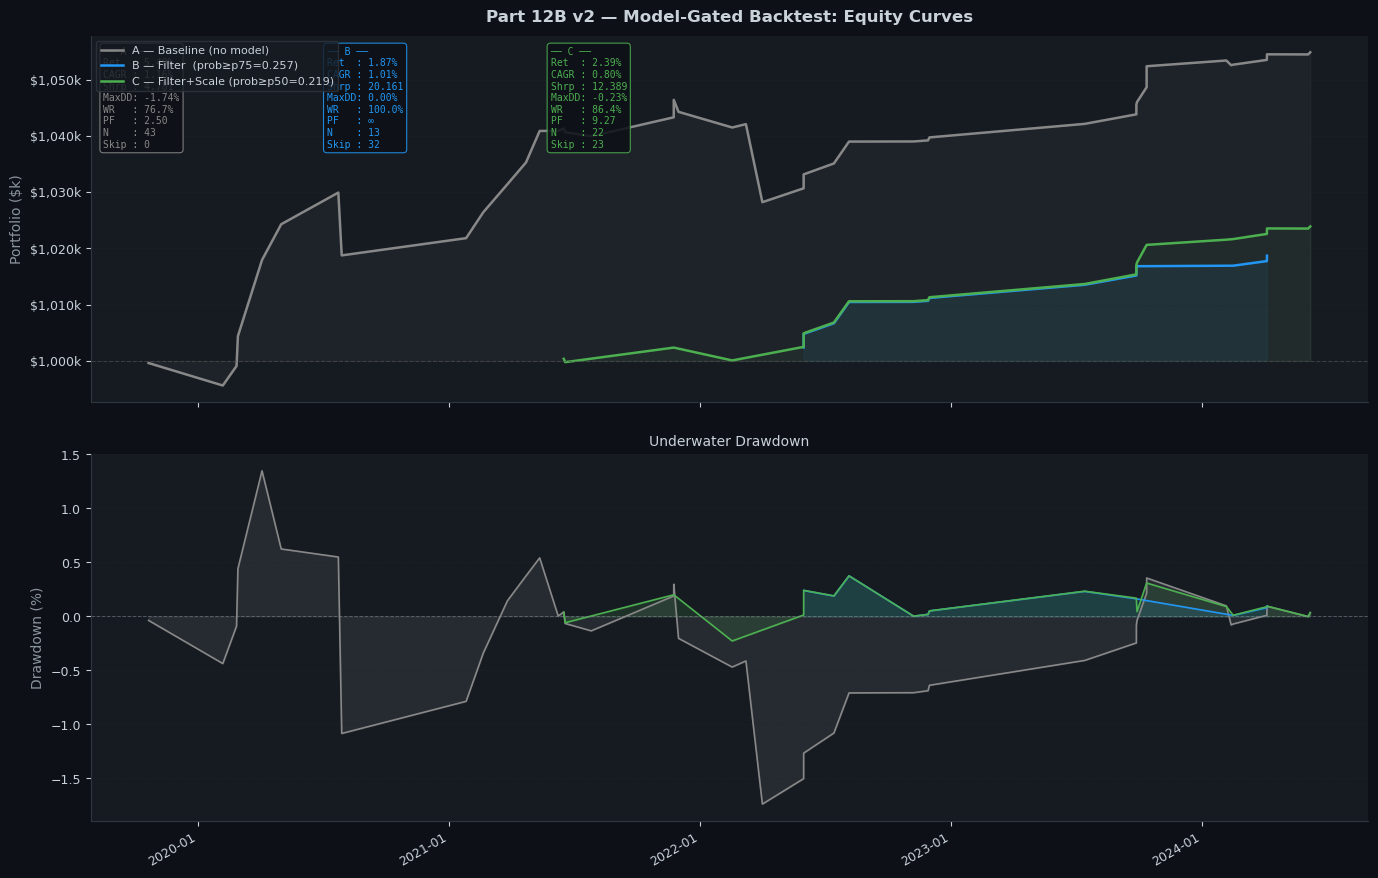


  ✓ Chart saved → outputs/part12b_model_gated_v2.png


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# PART 12B — MODEL-GATED BACKTEST  v2  (full copy-paste fix)
# ═══════════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os, traceback

os.makedirs("outputs", exist_ok=True)


# ──────────────────────────────────────────────────────────────────────────────
# STEP 0a ── Defensive numeric helpers
# ──────────────────────────────────────────────────────────────────────────────

from typing import Optional
def _safe_float(val, label: str = "?") -> Optional[float]:
    """
    Convert val to float; return None (skip trade) on failure instead of crash.
    Logs the offending value + type once per unique type so the log stays clean.
    """
    if isinstance(val, (int, float, np.integer, np.floating)):
        return float(val)
    if isinstance(val, pd.Timestamp):
        # This is the error the user hit.  Most common cause:
        # _sensitive_rsi_exit_return_pct() was written expecting an integer bar
        # index as `ts`, not a real Timestamp.  We handle this separately via
        # _get_rsi_bar_idx(); this fallback just prevents a hard crash.
        return None
    try:
        return float(val)
    except (TypeError, ValueError):
        return None


def _isfinite_safe(val) -> bool:
    """np.isfinite raises on Timestamps; this wrapper handles non-numeric vals."""
    if not isinstance(val, (int, float, np.integer, np.floating)):
        return False
    return bool(np.isfinite(val))


# ──────────────────────────────────────────────────────────────────────────────
# STEP 0b ── Fix ltf_sensitive_rsi timestamps
# ──────────────────────────────────────────────────────────────────────────────

def repair_rsi_timestamps(rsi_df):
    df = rsi_df.copy()

    if pd.api.types.is_datetime64_any_dtype(df["timestamp"]):
        # Sanity check: if max timestamp is before year 2000, values are corrupt
        if df["timestamp"].max() < pd.Timestamp("2000-01-01"):
            # Timestamps are sequential integers miscast as nanosecond datetimes
            # Re-interpret the underlying int64 values as nanoseconds → already done wrong
            # Fall through to numeric repair using the raw integer values
            df["timestamp"] = df["timestamp"].astype(np.int64)
        else:
            return df  # genuinely fine

    if pd.api.types.is_object_dtype(df["timestamp"]):
        df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
        return df

    if pd.api.types.is_numeric_dtype(df["timestamp"]):
        raw_max = float(df["timestamp"].max())
        if raw_max > 1e12:
            df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms")
        else:
            df["timestamp"] = pd.to_datetime(df["timestamp"], unit="s")
        return df

    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
    return df


def _strip_tz(df: pd.DataFrame, col: str = "timestamp") -> pd.DataFrame:
    df = df.copy()
    if col in df.columns and hasattr(df[col], "dt"):
        if getattr(df[col].dt, "tz", None) is not None:
            df[col] = df[col].dt.tz_localize(None)
    return df


print("=" * 60)
print("  PART 12B v2 — Repairing RSI timestamps …")

ltf_sensitive_rsi = repair_rsi_timestamps(ltf_sensitive_rsi)
ltf_sensitive_rsi = _strip_tz(ltf_sensitive_rsi)

# Ensure timestamp column is proper datetime (not object / int)
ltf_sensitive_rsi["timestamp"] = pd.to_datetime(
    ltf_sensitive_rsi["timestamp"], errors="coerce"
)
ltf_sensitive_rsi = ltf_sensitive_rsi.dropna(subset=["timestamp"])
ltf_sensitive_rsi = ltf_sensitive_rsi.sort_values("timestamp").reset_index(drop=True)

print(f"  RSI range  : {ltf_sensitive_rsi['timestamp'].min()}  "
      f"→  {ltf_sensitive_rsi['timestamp'].max()}")
print(f"  RSI rows   : {len(ltf_sensitive_rsi):,}")


# ──────────────────────────────────────────────────────────────────────────────
# STEP 0c ── Build a bar-index lookup for _sensitive_rsi_exit_return_pct
# ──────────────────────────────────────────────────────────────────────────────
# Part 11A's _sensitive_rsi_exit_return_pct() may have been written to accept
# an INTEGER bar index into the RSI DataFrame (not a real Timestamp), because
# the original ltf_sensitive_rsi["timestamp"] was 0…6576 bar indices.
#
# After our repair the column holds real datetimes, so passing a Timestamp as
# `ts` causes float(ts) inside the function → TypeError.
#
# Fix: before calling the function, convert the sweep Timestamp to the
# nearest forward bar-index integer via _ts_to_bar_idx().

_RSI_TS_ARRAY = ltf_sensitive_rsi["timestamp"].values   # numpy datetime64 array

def _ts_to_bar_idx(ts: pd.Timestamp) -> int:
    """
    Return the 0-based integer position in ltf_sensitive_rsi whose timestamp
    is >= ts (i.e., the first bar AT or AFTER the sweep entry).
    Used when _sensitive_rsi_exit_return_pct expects an integer bar index.
    """
    idx = np.searchsorted(_RSI_TS_ARRAY, np.datetime64(ts), side="left")
    return int(np.clip(idx, 0, len(_RSI_TS_ARRAY) - 1))

def _sensitive_rsi_exit_return_pct(entry_ts, sweep_type, ltf_rsi_df,
                                    long_thr=70.0, short_thr=30.0, max_hold_days=60):
    """
    Reconstructed for v29: wraps _find_sensitive_rsi_exit (new API).
    entry_ts: pd.Timestamp or integer bar index (both handled).
    sl=np.nan disables SL; exits on RSI threshold or TIMEOUT.
    Returns (pnl_pct, exit_ts, exit_rsi, bars_held).
    """
    side = _side_from_sweep_type_sensitive(sweep_type)
    if side is None:
        return np.nan, pd.NaT, np.nan, np.nan

    # ── Resolve entry row (Timestamp or bar-index) ────────────────────────────
    if isinstance(entry_ts, (int, np.integer)):
        idx = int(entry_ts)
        if idx < 0 or idx >= len(ltf_rsi_df):
            return np.nan, pd.NaT, np.nan, np.nan
        entry_row = ltf_rsi_df.iloc[idx]
        actual_ts = entry_row["timestamp"]
    else:
        actual_ts = pd.to_datetime(entry_ts, errors="coerce")
        if pd.isna(actual_ts):
            return np.nan, pd.NaT, np.nan, np.nan
        fwd_mask = ltf_rsi_df["timestamp"] >= actual_ts
        if not fwd_mask.any():
            return np.nan, pd.NaT, np.nan, np.nan
        entry_row = ltf_rsi_df[fwd_mask].iloc[0]

    c0 = float(entry_row.get("close", np.nan))
    if not np.isfinite(c0) or c0 <= 0:
        return np.nan, pd.NaT, np.nan, np.nan

    # ── Build rsi_by_day (required by v29 _find_sensitive_rsi_exit) ──────────
    _ltf = ltf_rsi_df.copy()
    _ltf["_day"] = _ltf["timestamp"].dt.normalize()
    rsi_by_day = {
        day: grp.reset_index(drop=True)
        for day, grp in _ltf.groupby("_day", sort=False)
    }

    # ── Exit scan: sl=np.nan → SL never fires (RSI + TIMEOUT only) ───────────
    outcome, exit_ts, exit_price, exit_rsi = _find_sensitive_rsi_exit(
        actual_ts, side, ltf_rsi_df, rsi_by_day, sl=np.nan,
        long_thr=long_thr, short_thr=short_thr, max_hold_days=max_hold_days,
    )

    if outcome == "TIMEOUT" or pd.isna(exit_ts):
        return np.nan, pd.NaT, np.nan, np.nan

    # ── Exit price ─────────────────────────────────────────────────────────────
    try:
        c1 = float(exit_price)
    except (TypeError, ValueError):
        c1 = np.nan

    if not np.isfinite(c1) or c1 <= 0:
        fwd = ltf_rsi_df[ltf_rsi_df["timestamp"] >= exit_ts]
        if fwd.empty:
            return np.nan, pd.NaT, np.nan, np.nan
        c1 = float(fwd.iloc[0]["close"])

    if not np.isfinite(c1) or c1 <= 0:
        return np.nan, pd.NaT, np.nan, np.nan

    raw_ret = (c1 - c0) / c0 * 100.0
    pnl_pct = raw_ret if side == "LONG" else -raw_ret
    bars_held = _holding_bars_sensitive(actual_ts, exit_ts, ltf_rsi_df)
    return pnl_pct, exit_ts, exit_rsi, bars_held

def _call_rsi_exit(ts: pd.Timestamp, sweep_type: str, ltf_rsi_df: pd.DataFrame,
                   long_thr: float, short_thr: float, max_hold_days: int):
    """
    Wrapper around _sensitive_rsi_exit_return_pct that handles BOTH calling
    conventions:
      (a) ts is a real Timestamp  ← new after repair
      (b) ts is an integer bar-index ← original Part 11A convention
    Tries Timestamp first; falls back to bar-index on TypeError.
    """
    # ── Attempt (a): pass real Timestamp (modern / correct convention) ───────
    try:
        result = _sensitive_rsi_exit_return_pct(
            ts, sweep_type, ltf_rsi_df,
            long_thr=long_thr, short_thr=short_thr, max_hold_days=max_hold_days,
        )
        # Validate: pnl_pct (first element) must be numeric
        if isinstance(result[0], (int, float, np.integer, np.floating)):
            return result
        # If it returned a Timestamp as pnl_pct the return order may be swapped
        # (exit_ts, pnl_pct, ...) — try bar-index path instead
    except TypeError:
        pass   # fall through to bar-index attempt

    # ── Attempt (b): pass integer bar index ───────────────────────────────────
    bar_idx = _ts_to_bar_idx(ts)
    try:
        result = _sensitive_rsi_exit_return_pct(
            bar_idx, sweep_type, ltf_rsi_df,
            long_thr=long_thr, short_thr=short_thr, max_hold_days=max_hold_days,
        )
        return result
    except Exception:
        return (np.nan, pd.NaT, np.nan, np.nan)


# ──────────────────────────────────────────────────────────────────────────────
# STEP 1 ── Attach OOF predictions
# ──────────────────────────────────────────────────────────────────────────────

assert len(s3_oof) == len(df_sweeps), (
    f"OOF length mismatch: s3_oof={len(s3_oof)}, df_sweeps={len(df_sweeps)}"
)

df_sweeps_with_prob = df_sweeps.copy()
df_sweeps_with_prob["student_prob"] = np.clip(s3_oof, 0.0, 1.0)

print(f"\n  OOF attached — "
      f"mean={df_sweeps_with_prob['student_prob'].mean():.3f}  "
      f"range=[{df_sweeps_with_prob['student_prob'].min():.3f}, "
      f"{df_sweeps_with_prob['student_prob'].max():.3f}]")


# ──────────────────────────────────────────────────────────────────────────────
# STEP 2 ── Merge into sweeps_filtered
# ──────────────────────────────────────────────────────────────────────────────

_merge_keys  = ["timestamp", "zoneid"]
_prob_lookup = (
    df_sweeps_with_prob[_merge_keys + ["student_prob"]]
    .drop_duplicates(subset=_merge_keys)
)

# Drop pre-existing student_prob column to avoid _x / _y suffix confusion
_sweeps_base = sweeps_filtered.drop(
    columns=[c for c in sweeps_filtered.columns if "student_prob" in c],
    errors="ignore",
)

sweeps_for_sim = _sweeps_base.merge(_prob_lookup, on=_merge_keys, how="left")
sweeps_for_sim = _strip_tz(sweeps_for_sim)

_median_fill = float(df_sweeps_with_prob["student_prob"].median())
_n_unmatched = sweeps_for_sim["student_prob"].isna().sum()
sweeps_for_sim["student_prob"] = sweeps_for_sim["student_prob"].fillna(_median_fill)

# ── Force numeric dtypes to prevent surprise Timestamp columns ───────────────
for _col in ["kelly_frac_f", "student_prob"]:
    if _col in sweeps_for_sim.columns:
        sweeps_for_sim[_col] = pd.to_numeric(sweeps_for_sim[_col], errors="coerce")

_oos_mask  = sweeps_for_sim["is_test_set"] == True
_oos_probs = sweeps_for_sim.loc[_oos_mask, "student_prob"]

print(f"\n  OOS sweeps : {_oos_mask.sum()}  "
      f"({_n_unmatched} unmatched → median fill {_median_fill:.3f})")
print(f"  P(WIN) OOS :\n{_oos_probs.describe().round(3).to_string()}")


# ──────────────────────────────────────────────────────────────────────────────
# STEP 3 ── Adaptive thresholds
# ──────────────────────────────────────────────────────────────────────────────

THRESH_B  = float(np.percentile(_oos_probs.dropna(), 75))
THRESH_C  = float(np.percentile(_oos_probs.dropna(), 50))
SCALE_REF = THRESH_B

print(f"\n  Adaptive thresholds:")
print(f"    B  ≥ p75 = {THRESH_B:.4f}  "
      f"({(_oos_probs >= THRESH_B).sum()} sweeps)")
print(f"    C  ≥ p50 = {THRESH_C:.4f}  "
      f"({(_oos_probs >= THRESH_C).sum()} sweeps)")


# ──────────────────────────────────────────────────────────────────────────────
# STEP 4 ── Simulation
# ──────────────────────────────────────────────────────────────────────────────

def pro_trading_simulation_model_gated(
    sweeps_filtered,
    ltf_rsi_df,
    long_thr                    = 70.0,
    short_thr                   = 30.0,
    max_hold_days               = 60,
    initial_capital             = 1_000_000,
    max_dd_limit                = -20,
    risk_cap_per_trade          = 0.10,
    max_total_exposure_per_bar  = 0.20,
    cost_bps                    = 2,
    min_prob                    = 0.0,
    kelly_scale                 = False,
    scale_ref                   = None,
):
    if scale_ref is None:
        scale_ref = SCALE_REF

    portfolio      = float(initial_capital)
    trades         = []
    peak           = portfolio
    exposure_by_ts = {}
    skipped_model  = 0
    skipped_errors = 0

    valid_trades = sweeps_filtered[
        (sweeps_filtered["is_test_set"] == True)
        & (sweeps_filtered["kelly_frac_f"].notna())
        & (pd.to_numeric(sweeps_filtered["kelly_frac_f"], errors="coerce") > 0.01)
    ].copy()

    _dedup = [c for c in ["timestamp", "sweep_type", "sweep_id", "zoneid"]
              if c in valid_trades.columns]
    if _dedup:
        valid_trades = valid_trades.drop_duplicates(subset=_dedup)
    valid_trades = valid_trades.sort_values("timestamp").reset_index(drop=True)

    for _, sweep in valid_trades.iterrows():

        # ── Model gate ───────────────────────────────────────────────────────
        prob = _safe_float(sweep.get("student_prob", _median_fill), "student_prob")
        if prob is None:
            prob = _median_fill
        if prob < min_prob:
            skipped_model += 1
            continue

        ts = pd.to_datetime(sweep["timestamp"], errors="coerce")
        if pd.isna(ts):
            skipped_errors += 1
            continue

        # ── Exposure cap ─────────────────────────────────────────────────────
        used      = float(exposure_by_ts.get(ts, 0.0))
        remaining = float(max_total_exposure_per_bar) - used
        if remaining <= 0:
            continue

        # ── Kelly sizing ─────────────────────────────────────────────────────
        base_kelly = _safe_float(sweep["kelly_frac_f"], "kelly_frac_f")
        if base_kelly is None:
            skipped_errors += 1
            continue

        if kelly_scale:
            scale_ref_f = _safe_float(scale_ref, "scale_ref") or SCALE_REF
            base_kelly  = base_kelly * min(prob / scale_ref_f, 1.5)

        kelly_size = float(min(base_kelly, float(risk_cap_per_trade), remaining))
        if kelly_size <= 0:
            continue

        # ── RSI exit (dual-convention wrapper) ───────────────────────────────
        pnl_pct, exit_ts, exit_rsi, bars_held = _call_rsi_exit(
            ts,
            str(sweep.get("sweep_type", "")),
            ltf_rsi_df,
            long_thr      = float(long_thr),
            short_thr     = float(short_thr),
            max_hold_days = int(max_hold_days),
        )

        if not _isfinite_safe(pnl_pct):
            skipped_errors += 1
            continue

        # ── P&L ──────────────────────────────────────────────────────────────
        position_size = portfolio * kelly_size
        slippage_cost = position_size * (float(cost_bps) / 10_000.0)
        pnl_dollars   = position_size * (float(pnl_pct) / 100.0) - slippage_cost

        portfolio += pnl_dollars
        portfolio  = max(portfolio, 0.0)
        exposure_by_ts[ts] = used + kelly_size

        drawdown = (portfolio - peak) / peak * 100
        if drawdown < float(max_dd_limit):
            break
        peak = max(peak, portfolio)

        side = _side_from_sweep_type_sensitive(str(sweep.get("sweep_type", "")))

        trades.append({
            "timestamp":         ts,
            "exit_timestamp":    exit_ts,
            "sweep_type":        sweep.get("sweep_type", "NA"),
            "side":              side or "UNKNOWN",
            "student_prob":      prob,
            "exit_running_rsi6": exit_rsi,
            "bars_held_hourly":  bars_held,
            "kelly_size_pct":    kelly_size * 100,
            "pnl_pct":           float(pnl_pct),
            "pnl_dollars":       pnl_dollars,
            "portfolio":         portfolio,
            "drawdown_pct":      drawdown,
        })

    trades_df = pd.DataFrame(trades)

    _base_metrics = {
        "Skipped by model":  skipped_model,
        "Skipped (errors)":  skipped_errors,
        "Candidates":        len(valid_trades),
    }

    if trades_df.empty:
        return trades_df, {"Status": "NO TRADES", **_base_metrics}

    # ── Performance metrics ───────────────────────────────────────────────────
    total_return = (portfolio - initial_capital) / initial_capital * 100
    span_days    = (trades_df["timestamp"].max()
                    - trades_df["timestamp"].min()).days
    num_years    = max(span_days / 365.25, 1 / 365.25)
    cagr         = ((portfolio / initial_capital) ** (1.0 / num_years) - 1) * 100

    base_port = trades_df["portfolio"].shift(1).fillna(initial_capital)
    rets      = trades_df["pnl_dollars"] / base_port
    sharpe    = (rets.mean() / rets.std() * np.sqrt(252)) if rets.std() > 0 else 0.0

    win_mask  = trades_df["pnl_dollars"] > 0
    loss_mask = trades_df["pnl_dollars"] < 0
    win_sum   = trades_df.loc[win_mask,  "pnl_dollars"].sum()
    loss_sum  = trades_df.loc[loss_mask, "pnl_dollars"].abs().sum()
    pf_str    = f"{win_sum / loss_sum:.2f}" if loss_sum > 0 else "∞"

    eq_arr   = trades_df["portfolio"].values
    peak_arr = np.maximum.accumulate(
        np.concatenate([[float(initial_capital)], eq_arr])
    )
    dd_arr   = (eq_arr - peak_arr[1:]) / peak_arr[1:] * 100
    max_dd   = float(dd_arr.min()) if len(dd_arr) else 0.0

    metrics = {
        "Final Portfolio":     f"${portfolio:,.0f}",
        "Total Return":        f"{total_return:.2f}%",
        "CAGR":                f"{cagr:.2f}%",
        "Max Drawdown":        f"{max_dd:.2f}%",
        "Sharpe Ratio":        f"{sharpe:.3f}",
        "Win Rate":            f"{win_mask.mean() * 100:.1f}%",
        "Profit Factor":       pf_str,
        "OOS Trades Executed": len(trades_df),
        **_base_metrics,
        "Avg Trade ($)":       f"${trades_df['pnl_dollars'].mean():,.0f}",
        "Avg Bars Held":       (f"{trades_df['bars_held_hourly'].dropna().mean():.1f}"
                                if "bars_held_hourly" in trades_df else "—"),
    }
    return trades_df, metrics


# ──────────────────────────────────────────────────────────────────────────────
# STEP 5 ── Run A / B / C
# ──────────────────────────────────────────────────────────────────────────────

_SIM_PARAMS = dict(
    ltf_rsi_df                 = ltf_sensitive_rsi,
    long_thr                   = SENS_RSI_LONG_EXIT,
    short_thr                  = SENS_RSI_SHORT_EXIT,
    max_hold_days              = SENS_MAX_HOLD_DAYS,
    initial_capital            = 1_000_000,
    max_dd_limit               = -20,
    risk_cap_per_trade         = 0.10,
    max_total_exposure_per_bar = SENS_MAX_TOTAL_EXPOSURE_PER_BAR,
    cost_bps                   = SENS_COST_BPS,
)

_SCENARIOS = {
    "A — Baseline (no model)": dict(
        min_prob=0.0, kelly_scale=False,
    ),
    f"B — Filter  (prob≥p75={THRESH_B:.3f})": dict(
        min_prob=THRESH_B, kelly_scale=False,
    ),
    f"C — Filter+Scale (prob≥p50={THRESH_C:.3f})": dict(
        min_prob=THRESH_C, kelly_scale=True, scale_ref=SCALE_REF,
    ),
}

all_results = {}
print("\n" + "=" * 62)
print("  PART 12B v2 — Scenarios A / B / C")
print("=" * 62)

for label, gate_params in _SCENARIOS.items():
    trades_df, metrics = pro_trading_simulation_model_gated(
        sweeps_for_sim, **_SIM_PARAMS, **gate_params
    )
    all_results[label] = {"trades": trades_df, "metrics": metrics}
    print(f"\n  {'─'*58}")
    print(f"  {label}")
    print(f"  {'─'*58}")
    for k, v in metrics.items():
        print(f"  {k:<30} {v}")


# ──────────────────────────────────────────────────────────────────────────────
# STEP 6 ── Comparison table
# ──────────────────────────────────────────────────────────────────────────────

_KEY = ["Total Return", "CAGR", "Sharpe Ratio", "Max Drawdown",
        "Win Rate", "Profit Factor", "OOS Trades Executed", "Skipped by model"]

comparison_df = pd.DataFrame({
    label: {k: res["metrics"].get(k, "—") for k in _KEY}
    for label, res in all_results.items()
})

print("\n\n" + "═" * 75)
print("  PART 12B v2 — A / B / C COMPARISON")
print("═" * 75)
try:
    display(comparison_df)
except NameError:
    print(comparison_df.to_string())


# ──────────────────────────────────────────────────────────────────────────────
# STEP 7 ── Equity curve overlay
# ──────────────────────────────────────────────────────────────────────────────

_PALETTE = ["#888888", "#2196F3", "#4CAF50"]
_INITIAL = _SIM_PARAMS["initial_capital"]

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
fig.patch.set_facecolor("#0d1117")
for ax in axes:
    ax.set_facecolor("#161b22")
    ax.tick_params(colors="#c9d1d9", labelsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    for s in ["bottom", "left"]:
        ax.spines[s].set_color("#30363d")

for (label, res), color in zip(all_results.items(), _PALETTE):
    df = res["trades"]
    sc = label.split("—")[0].strip()
    m  = res["metrics"]

    ann_txt = "\n".join([
        f"── {sc} ──",
        f"Ret  : {m.get('Total Return','—')}",
        f"CAGR : {m.get('CAGR','—')}",
        f"Shrp : {m.get('Sharpe Ratio','—')}",
        f"MaxDD: {m.get('Max Drawdown','—')}",
        f"WR   : {m.get('Win Rate','—')}",
        f"PF   : {m.get('Profit Factor','—')}",
        f"N    : {m.get('OOS Trades Executed','—')}",
        f"Skip : {m.get('Skipped by model','—')}",
    ])
    _ann_x = 0.01 + list(all_results.keys()).index(label) * 0.175
    axes[0].text(
        _ann_x, 0.97, ann_txt,
        transform=axes[0].transAxes, fontsize=7,
        verticalalignment="top", family="monospace", color=color,
        bbox=dict(boxstyle="round,pad=0.35", fc="#0d1117",
                  ec=color, alpha=0.88, linewidth=0.8),
    )

    if df.empty:
        continue

    axes[0].plot(df["timestamp"], df["portfolio"] / 1_000,
                 label=label, linewidth=1.8, color=color)
    axes[0].fill_between(df["timestamp"], _INITIAL / 1_000,
                         df["portfolio"] / 1_000, alpha=0.07, color=color)
    axes[1].plot(df["timestamp"], df["drawdown_pct"],
                 linewidth=1.2, color=color, label=label)
    axes[1].fill_between(df["timestamp"], df["drawdown_pct"], 0,
                         alpha=0.15, color=color)

axes[0].axhline(_INITIAL / 1_000, color="#555", linewidth=0.8,
                linestyle="--", alpha=0.6)
axes[0].set_ylabel("Portfolio ($k)", color="#8b949e", fontsize=10)
axes[0].set_title("Part 12B v2 — Model-Gated Backtest: Equity Curves",
                  color="#c9d1d9", fontsize=12, pad=10, fontweight="bold")
axes[0].legend(facecolor="#161b22", edgecolor="#30363d",
               labelcolor="#c9d1d9", fontsize=8, loc="upper left")
axes[0].grid(axis="y", color="#21262d", linewidth=0.5, linestyle=":")
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"${x:,.0f}k")
)

axes[1].axhline(0, color="#8b949e", linewidth=0.7, linestyle="--", alpha=0.5)
axes[1].set_ylabel("Drawdown (%)", color="#8b949e", fontsize=10)
axes[1].set_title("Underwater Drawdown", color="#c9d1d9", fontsize=10, pad=6)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
axes[1].xaxis.set_major_locator(mdates.AutoDateLocator())
axes[1].grid(axis="y", color="#21262d", linewidth=0.5, linestyle=":")

fig.autofmt_xdate()
plt.tight_layout(pad=1.5, h_pad=2.0)

_plot_path = "outputs/part12b_model_gated_v2.png"
plt.savefig(_plot_path, dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print(f"\n  ✓ Chart saved → {_plot_path}")

## Part 12C Forecasting with saved models

In [ ]:
def engineer_all_student_features(df_sweeps: pd.DataFrame, artifacts: dict) -> pd.DataFrame:
    """
    Applies all feature engineering, normalization, and categorical
    encoding needed for the Distillation Student Model.

    Args:
        df_sweeps: Raw dataframe of sweeps generated from 2024+ data
                   (must contain raw columns like 'reversal_distance', 'touchcount', etc.)
        artifacts: The loaded preprocessing_artifacts.joblib dictionary.

    Returns:
        X_student: A DataFrame strictly aligned to what the Student model expects.
    """

    df = df_sweeps.copy()

    def _ensure_col(target: str, aliases: list[str], default_value):
        if target in df.columns:
            return
        for a in aliases:
            if a in df.columns:
                df[target] = df[a]
                return
        df[target] = default_value

    # ---------------------------------------------------------
    # 0. Normalize raw column names / provide safe fallbacks
    # ---------------------------------------------------------
    # Required identifiers (fail early if missing)
    if "ticker" not in df.columns:
        raise KeyError("engineer_all_student_features: missing required column 'ticker'")
    if "timestamp" not in df.columns:
        raise KeyError("engineer_all_student_features: missing required column 'timestamp'")

    # Price anchors
    _ensure_col("zone_level", ["zonelevel", "zone_mid", "zone_price"], default_value=np.nan)
    if df["zone_level"].isna().all():
        # last-resort reference for pct normalization
        if "close" in df.columns:
            df["zone_level"] = pd.to_numeric(df["close"], errors="coerce")
        else:
            df["zone_level"] = 1.0

    # Candle metrics (names differ between sweep export variants)
    _ensure_col("candle_total_range", ["total_range", "candle_range", "range"], default_value=np.nan)
    _ensure_col("candle_body", ["body", "candle_body_$"], default_value=np.nan)
    _ensure_col("lower_wick", ["low_wick", "lowerwick", "lowwick"], default_value=0.0)
    _ensure_col("upper_wick", ["high_wick", "upperwick", "highwick"], default_value=0.0)

    # Reversal distance
    _ensure_col("reversal_distance", ["reversal_distance_$", "reversal_dist"], default_value=0.0)

    # Touch count fields (the KeyError you hit was here)
    _ensure_col(
        "zone_accumulated_touch_count",
        [
            "zone_touch_count_at_sweep",
            "zone_touch_count",
            "touchcount",
            "touch_count",
            "touchcount_at_sweep",
        ],
        default_value=0.0,
    )
    _ensure_col(
        "touches_at_inversion",
        ["touches_since_inversion", "touches_since_inversion_days"],
        default_value=0.0,
    )

    # Ensure numeric for math operations
    for c in [
        "zone_level",
        "candle_total_range",
        "candle_body",
        "lower_wick",
        "upper_wick",
        "reversal_distance",
        "zone_accumulated_touch_count",
        "touches_at_inversion",
    ]:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # ---------------------------------------------------------
    # 1. Dollar Normalization (from Step 2 in notebook)
    # ---------------------------------------------------------
    ref = df["zone_level"].replace(0, np.nan)
    candle = df["candle_total_range"].replace(0, np.nan)

    df["reversal_distance_pct"] = df["reversal_distance"] / ref
    df["candle_range_pct"] = df["candle_total_range"] / ref
    df["body_ratio"] = df["candle_body"] / candle
    df["lower_wick_ratio"] = df["lower_wick"] / candle
    df["upper_wick_ratio"] = df["upper_wick"] / candle
    df["log_touchcount"] = np.log1p(df["zone_accumulated_touch_count"].fillna(0.0).clip(lower=0.0))
    df["log_touches_at_inversion"] = np.log1p(df["touches_at_inversion"].fillna(0.0).clip(lower=0.0))

    # ---------------------------------------------------------
    # 2. Extract Training Constants from Notebook
    # ---------------------------------------------------------
    SWEEP_BOOL = [
        "vol_surge",
        "mss_confirmed",
        "slope_gate_pass",
        "is_first_sweep",
        "is_retest",
    ]
    SWEEP_CAT = [
        "sweep_type",
        "zonetype",
        "zone_state_at_sweep",
        "zonelifecyclephase",
    ]

    # ---------------------------------------------------------
    # 3. Encode Categoricals & Booleans (from Step 6)
    # ---------------------------------------------------------
    for col in SWEEP_BOOL:
        if col in df.columns:
            df[col] = df[col].astype(int)

    for col in SWEEP_CAT:
        if col in df.columns:
            dummies = pd.get_dummies(df[col].astype(str), prefix=col, drop_first=True)
            df = pd.concat([df, dummies], axis=1)

    # ---------------------------------------------------------
    # 4. Regime Assignment (from Step 5)
    #    Uses your exact custom notebook function logic
    # ---------------------------------------------------------
    regime_store = artifacts["regime_store"]
    max_k = max(s["k"] for s in regime_store.values())

    regime_labels, frac_dicts = [], []
    for _, row in df.iterrows():
        ticker = row["ticker"]
        ts = pd.to_datetime(row["timestamp"], errors="coerce")
        if ts is not pd.NaT and ts.tz is not None:
            ts = ts.tz_localize(None)

        if ticker in regime_store and ts is not pd.NaT:
            store = regime_store[ticker]
            rseries = store["regime_series"]
            rseries.index = pd.to_datetime(rseries.index).tz_localize(None)
            k = store["k"]

            mask = rseries.index <= ts
            if mask.any():
                recent = rseries[mask].iloc[-7:]  # lookback_bars = 7
                label = int(recent.iloc[-1])
                fracs = {f"regime_{r}_frac": (recent == r).mean() for r in range(k)}
                for r in range(k, max_k):
                    fracs[f"regime_{r}_frac"] = 0.0
            else:
                label = -1
                fracs = {f"regime_{r}_frac": 0.0 for r in range(max_k)}
        else:
            label = -1
            fracs = {f"regime_{r}_frac": 0.0 for r in range(max_k)}

        regime_labels.append(label)
        frac_dicts.append(fracs)

    df["regime_label"] = regime_labels
    df = pd.concat([df, pd.DataFrame(frac_dicts, index=df.index)], axis=1)

    # ---------------------------------------------------------
    # 5. Extract ONLY the Student Feature columns (Align exactly)
    # ---------------------------------------------------------
    student_training_columns = artifacts["student_training_columns"]
    X_student = pd.DataFrame(index=df.index)

    for col in student_training_columns:
        if col in df.columns:
            X_student[col] = pd.to_numeric(df[col], errors="coerce")

            is_bool_or_cat = (
                col in SWEEP_BOOL
                or any(col.startswith(c + "_") for c in SWEEP_CAT)
                or "regime_" in col
            )
            fill_val = 0 if is_bool_or_cat else X_student[col].median()
            if pd.isna(fill_val):
                fill_val = 0

            X_student[col] = X_student[col].fillna(fill_val)
        else:
            X_student[col] = 0

    return X_student[student_training_columns]

In [ ]:
# --- Part 12C (REWRITE): OOS Forecasting + Model-Gated Backtest (NO MIDAS) ---
# Window: 2024-10-01 → today
# Data: try yfinance hourly+daily; fallback to local CSVs when hourly is unavailable.

from pathlib import Path
import os
import warnings

import joblib
import numpy as np
import pandas as pd
import xgboost as xgb
import yfinance as yf

warnings.filterwarnings("ignore")

# -------------------------------
# USER SETTINGS
# -------------------------------
TICKERS = ["TSLA", "AAPL", "GOOG", "MSFT", "NVDA"]
OOS_START = pd.Timestamp("2024-10-01")
OOS_END   = pd.Timestamp.today().normalize()

# If you have the local file exactly like this, it will be used as fallback.
CSV_FALLBACK_OOS_END = "2026-04-15"  # only used to form candidate filenames

# Zone/sweep detection needs some prior context. Keep within yfinance 1h limit (~730 days).
CONTEXT_LOOKBACK_DAYS = 120

# Model gating scenarios (you can change / remove any of these)
SCENARIOS = {
    "A — Baseline (no model)": dict(min_prob=0.00, kelly_scale=False),
    "B — Filter (p>=p75)":    dict(min_prob="p75", kelly_scale=False),
    "C — Filter+Scale (p>=p50)": dict(min_prob="p50", kelly_scale=True),
}

# -------------------------------
# Preflight: required notebook functions
# -------------------------------
_required = [
    "identify_liquidity_zones",
    "identify_sweeps_in_zones",
    "_prepare_running_daily_rsi_from_ltf",
    "pro_trading_simulation_model_gated",
]
_missing = [name for name in _required if name not in globals()]
if _missing:
    raise RuntimeError(
        "Missing required functions in the current kernel: "
        + ", ".join(_missing)
        + "\nRun the earlier notebook sections first (zones/sweeps + Part 11A + Part 12B)."
    )

# -------------------------------
# Load artifacts + saved Student model
# -------------------------------
print("1) Loading saved artifacts + Student model …")
MODEL_DIR = "outputs/saved_models"
artifacts_path = os.path.join(MODEL_DIR, "preprocessing_artifacts.joblib")
model_path     = os.path.join(MODEL_DIR, "xgb_student_full.json")

artifacts = joblib.load(artifacts_path)
student_model = xgb.XGBRegressor()
student_model.load_model(model_path)

# -------------------------------
# Helpers
# -------------------------------

def _clean_yf_ohlcv(df: pd.DataFrame, ticker: str) -> pd.DataFrame:
    if df is None or df.empty:
        return pd.DataFrame()

    out = df.copy()

    # yfinance: index is DatetimeIndex
    if isinstance(out.index, pd.DatetimeIndex):
        out = out.reset_index()

    # normalize column names
    ren = {
        "Datetime": "timestamp",
        "Date": "timestamp",
        "Open": "open",
        "High": "high",
        "Low": "low",
        "Close": "close",
        "Volume": "volume",
    }
    out = out.rename(columns={c: ren.get(c, c) for c in out.columns})

    if "timestamp" not in out.columns:
        # last resort: assume first col is timestamp
        out = out.reset_index(drop=True)
        out = out.rename(columns={out.columns[0]: "timestamp"})

    out["timestamp"] = pd.to_datetime(out["timestamp"], errors="coerce")
    if pd.api.types.is_datetime64tz_dtype(out["timestamp"]):
        out["timestamp"] = out["timestamp"].dt.tz_localize(None)

    for c in ["open", "high", "low", "close", "volume"]:
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors="coerce")

    # yfinance can output lowercase already; ensure required OHLC columns exist
    if "close" not in out.columns:
        return pd.DataFrame()
    for c in ["open", "high", "low"]:
        if c not in out.columns:
            out[c] = out["close"]
    if "volume" not in out.columns:
        out["volume"] = 0.0

    out["ticker"] = ticker
    out = out.dropna(subset=["timestamp", "close"]).sort_values("timestamp").reset_index(drop=True)
    return out[["timestamp", "open", "high", "low", "close", "volume", "ticker"]]


def _yf_history(ticker: str, start: pd.Timestamp, end: pd.Timestamp, interval: str) -> pd.DataFrame:
    try:
        df = yf.Ticker(ticker).history(start=start, end=end, interval=interval, auto_adjust=False)
        return _clean_yf_ohlcv(df, ticker=ticker)
    except Exception:
        return pd.DataFrame()


def _load_csv_candidates(ticker: str) -> list[Path]:
    tl = ticker.lower()
    tu = ticker.upper()
    candidates = []

    # OOS file requested by user
    oos_names = [
        f"{tl}_hourly_2024-10-01_{CSV_FALLBACK_OOS_END}_with_vol.csv",
        f"{tu}_hourly_2024-10-01_{CSV_FALLBACK_OOS_END}_with_vol.csv",
    ]

    # Common prehistory file in this workspace
    pre_names = [
        f"{tl}_hourly_2019-01-07_2024-09-30_with_vol.csv",
        f"{tu}_hourly_2019-01-07_2024-09-30_with_vol.csv",
    ]

    for base in [Path("."), Path("data")]:
        for name in oos_names + pre_names:
            candidates.append(base / name)

    # Anything nested (data/raw etc)
    for name in oos_names + pre_names:
        candidates.extend(Path(".").glob(f"**/{name}"))

    # Dedup while preserving order
    seen = set()
    out = []
    for p in candidates:
        p = p.resolve()
        if p.exists() and p not in seen:
            seen.add(p)
            out.append(p)
    return out


def _read_hourly_csv(ticker: str) -> pd.DataFrame:
    paths = _load_csv_candidates(ticker)
    if not paths:
        return pd.DataFrame()

    dfs = []
    for p in paths:
        try:
            df = pd.read_csv(p)
        except Exception:
            continue

        # normalize timestamp column
        if "timestamp" not in df.columns:
            date_col = next((c for c in df.columns if c.lower() in ("date", "datetime", "time")), None)
            if date_col:
                df = df.rename(columns={date_col: "timestamp"})
            else:
                df = df.reset_index().rename(columns={"index": "timestamp"})

        # some CSVs may use capitalized column names
        ren = {"Open": "open", "High": "high", "Low": "low", "Close": "close", "Volume": "volume"}
        df = df.rename(columns={c: ren.get(c, c) for c in df.columns})

        df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
        for c in ["open", "high", "low", "close", "volume"]:
            if c in df.columns:
                df[c] = pd.to_numeric(df[c], errors="coerce")

        if "close" not in df.columns:
            continue

        for c in ["open", "high", "low"]:
            if c not in df.columns:
                df[c] = df["close"]
        if "volume" not in df.columns:
            df["volume"] = 0.0

        df["ticker"] = ticker
        dfs.append(df[["timestamp", "open", "high", "low", "close", "volume", "ticker"]])

    if not dfs:
        return pd.DataFrame()

    out = (
        pd.concat(dfs, ignore_index=True)
        .dropna(subset=["timestamp", "close"])
        .sort_values("timestamp")
        .drop_duplicates(subset=["timestamp"], keep="last")
        .reset_index(drop=True)
    )
    return out


def _load_hourly_data(ticker: str, start: pd.Timestamp, end: pd.Timestamp) -> pd.DataFrame:
    # 1) Try yfinance
    df_hourly = _yf_history(ticker, start=start, end=end + pd.Timedelta(days=1), interval="1h")
    if not df_hourly.empty:
        return df_hourly

    # 2) Fallback to CSVs
    df_csv = _read_hourly_csv(ticker)
    if df_csv.empty:
        return pd.DataFrame()

    # Slice to requested range
    mask = (df_csv["timestamp"] >= start) & (df_csv["timestamp"] <= end + pd.Timedelta(days=1))
    return df_csv.loc[mask].copy().reset_index(drop=True)


def _load_daily_data(ticker: str, start: pd.Timestamp, end: pd.Timestamp) -> pd.DataFrame:
    # daily is usually always available; still keep defensive
    df_daily = _yf_history(ticker, start=start, end=end + pd.Timedelta(days=1), interval="1d")
    return df_daily


# -------------------------------
# Main: download/load, detect sweeps, predict, backtest
# -------------------------------
context_start = (OOS_START - pd.Timedelta(days=CONTEXT_LOOKBACK_DAYS)).normalize()
print(f"2) Data window (context): {context_start.date()} → {OOS_END.date()} | OOS starts {OOS_START.date()}")

all_preds = []
all_metrics = {}

for ticker in TICKERS:
    print(f"\n{'='*72}\nTICKER: {ticker}\n{'='*72}")

    print("2A) Loading hourly (1h) …")
    df_hourly = _load_hourly_data(ticker, start=context_start, end=OOS_END)
    if df_hourly.empty:
        print("   ✗ No hourly data available (yfinance failed AND no CSV found). Skipping.")
        continue

    print(f"   ✓ Hourly rows: {len(df_hourly):,} | range: {df_hourly['timestamp'].min()} → {df_hourly['timestamp'].max()}")

    print("2B) Loading daily (1d) …")
    df_daily = _load_daily_data(ticker, start=context_start, end=OOS_END)
    print(f"   ✓ Daily rows: {len(df_daily):,}" if not df_daily.empty else "   (daily unavailable)")

    # Build RSI dataframe used by the exit logic in Part 12B simulation
    ltf_sensitive_rsi_t = _prepare_running_daily_rsi_from_ltf(
        df_hourly[["timestamp", "open", "high", "low", "close"]].copy(),
        period=SENS_RSI_PERIOD,
    )
    ltf_sensitive_rsi_t = ltf_sensitive_rsi_t.dropna(subset=["timestamp"]).sort_values("timestamp").reset_index(drop=True)

    # Zone/sweep detection expects a 'date'
    df_t = df_hourly.copy().reset_index(drop=True)
    df_t["date"] = df_t["timestamp"].dt.date

    print("3) Detecting zones (NO MIDAS) …")
    try:
        # Force NO MIDAS: pass midas_df=None
        _, _, zones_enriched, _, _ = identify_liquidity_zones(df_t, midas_df=None)
    except TypeError:
        # Backward-compatible: if the function doesn't accept midas_df as kwarg
        _, _, zones_enriched, _, _ = identify_liquidity_zones(df_t)
        if "midas" in " ".join(map(str, getattr(zones_enriched, "columns", []))).lower():
            print("   (warning) zones contain MIDAS-like columns; verify identify_liquidity_zones isn't using global MIDAS.")

    if zones_enriched is None or zones_enriched.empty:
        print("   ✗ No zones detected. Skipping.")
        continue

    print("4) Detecting sweeps …")
    sweeps_df = identify_sweeps_in_zones(zonesdf=zones_enriched, pricedata=df_t)
    if sweeps_df is None or sweeps_df.empty:
        print("   ✗ No sweeps detected.")
        continue

    sweeps_df = sweeps_df.copy()
    if "ticker" not in sweeps_df.columns:
        sweeps_df["ticker"] = ticker

    sweeps_df["timestamp"] = pd.to_datetime(sweeps_df["timestamp"], errors="coerce")
    sweeps_df = sweeps_df.dropna(subset=["timestamp"]).sort_values("timestamp").reset_index(drop=True)

    # Strictly evaluate only the requested OOS window
    sweeps_oos = sweeps_df[sweeps_df["timestamp"] >= OOS_START].copy().reset_index(drop=True)
    print(f"   ✓ Sweeps found (OOS): {len(sweeps_oos):,} (total detected incl context={len(sweeps_df):,})")

    if sweeps_oos.empty:
        continue

    print("5) Feature engineering → Student columns …")
    X_oos = engineer_all_student_features(sweeps_oos, artifacts)

    print("6) Predicting P(win) …")
    preds = student_model.predict(X_oos)
    sweeps_oos["student_prob"] = np.clip(preds, 0.0, 1.0)

    # Store predictions (for the combined table)
    all_preds.append(sweeps_oos.copy())

    # Prepare Kelly sizing WITHOUT using labels/outcomes (safe for live-like usage)
    sweeps_for_sim = sweeps_oos.copy()
    sweeps_for_sim["timestamp"] = pd.to_datetime(sweeps_for_sim["timestamp"], errors="coerce")
    sweeps_for_sim = sweeps_for_sim.dropna(subset=["timestamp"]).sort_values("timestamp").reset_index(drop=True)

    if "_no_lookahead_fallback_kelly" in globals():
        q = sweeps_for_sim["sweep_quality_score"] if "sweep_quality_score" in sweeps_for_sim.columns else pd.Series(0.0, index=sweeps_for_sim.index)
        sweeps_for_sim["kelly_frac_f"] = _no_lookahead_fallback_kelly(
            q,
            min_frac=0.01,
            max_frac=min(float(SENS_RISK_CAP_PER_TRADE), 0.10),
            min_history=max(8, int(SENS_RSI_PERIOD) + 2),
        )
    else:
        sweeps_for_sim["kelly_frac_f"] = 0.02

    sweeps_for_sim["kelly_frac_f"] = (
        pd.to_numeric(sweeps_for_sim["kelly_frac_f"], errors="coerce")
        .fillna(0.01)
        .clip(0.01, float(SENS_RISK_CAP_PER_TRADE))
    )
    sweeps_for_sim["is_test_set"] = True

    # Adaptive thresholds based on this ticker's OOS predictions
    p50 = float(np.nanpercentile(sweeps_for_sim["student_prob"], 50))
    p75 = float(np.nanpercentile(sweeps_for_sim["student_prob"], 75))

    print(f"7) Backtest (model-gated) … thresholds: p50={p50:.3f} | p75={p75:.3f}")

    results = {}
    for label, gate in SCENARIOS.items():
        gate = gate.copy()
        if gate.get("min_prob") == "p50":
            gate["min_prob"] = p50
        if gate.get("min_prob") == "p75":
            gate["min_prob"] = p75

        trades_df, metrics = pro_trading_simulation_model_gated(
            sweeps_for_sim,
            ltf_sensitive_rsi_t,
            long_thr=SENS_RSI_LONG_EXIT,
            short_thr=SENS_RSI_SHORT_EXIT,
            max_hold_days=SENS_MAX_HOLD_DAYS,
            initial_capital=SENS_INITIAL_CAPITAL,
            max_dd_limit=SENS_MAX_DD_LIMIT,
            risk_cap_per_trade=SENS_RISK_CAP_PER_TRADE,
            max_total_exposure_per_bar=SENS_MAX_TOTAL_EXPOSURE_PER_BAR,
            cost_bps=SENS_COST_BPS,
            **gate,
        )
        results[label] = metrics

    # Print the requested metric set
    KEY_METRICS = [
        "Total Return",
        "CAGR",
        "Sharpe Ratio",
        "Max Drawdown",
        "Win Rate",
        "Profit Factor",
        "OOS Trades Executed",
        "Skipped by model",
    ]

    print("\nMETRICS (OOS):")
    for label, m in results.items():
        row = {k: m.get(k, "—") for k in KEY_METRICS}
        print(f"\n  {label}")
        for k in KEY_METRICS:
            print(f"    {k:<20} {row[k]}")

    all_metrics[ticker] = results

# -------------------------------
# Combined view: top OOS opportunities across tickers
# -------------------------------
if all_preds:
    df_all = pd.concat(all_preds, ignore_index=True)
    cols_pref = [c for c in ["timestamp", "ticker", "sweep_type", "student_prob", "zone_level", "reversal_price", "sweep_quality_score"] if c in df_all.columns]
    df_view = df_all[cols_pref].sort_values("student_prob", ascending=False)

    print("\n" + "="*72)
    print("TOP OOS PREDICTIONS (across tickers)")
    print("="*72)
    try:
        display(df_view.head(30))
    except NameError:
        print(df_view.head(30).to_string(index=False))
else:
    print("\nNo OOS sweeps were detected across the selected tickers.")


1) Loading saved artifacts + Student model …
2) Data window (context): 2024-06-03 → 2026-04-17 | OOS starts 2024-10-01

TICKER: TSLA
2A) Loading hourly (1h) …
   ✓ Hourly rows: 578 | range: 2024-06-03 09:30:00 → 2024-09-30 15:30:00
2B) Loading daily (1d) …
   (daily unavailable)
3) Detecting zones (NO MIDAS) …
19 zones identified [source=htf] – all preserved, no time-based expiry
4) Detecting sweeps …
   ✓ Sweeps found (OOS): 0 (total detected incl context=16)

TICKER: AAPL
2A) Loading hourly (1h) …
   ✓ Hourly rows: 578 | range: 2024-06-03 09:30:00 → 2024-09-30 15:30:00
2B) Loading daily (1d) …
   (daily unavailable)
3) Detecting zones (NO MIDAS) …
13 zones identified [source=htf] – all preserved, no time-based expiry
4) Detecting sweeps …
   ✓ Sweeps found (OOS): 0 (total detected incl context=8)

TICKER: GOOG
2A) Loading hourly (1h) …
   ✓ Hourly rows: 578 | range: 2024-06-03 09:30:00 → 2024-09-30 15:30:00
2B) Loading daily (1d) …
   (daily unavailable)
3) Detecting zones (NO MIDAS)

,timestamp,ticker,sweep_type,student_prob,zone_level,reversal_price,sweep_quality_score
4,2026-02-09 14:30:00,NVDA,BEARISH,0.346109,194.790643,189.90,62.0
10,2026-03-24 15:30:00,NVDA,BULLISH,0.291060,175.199893,175.31,50.0
9,2026-03-24 11:30:00,NVDA,BULLISH,0.285174,175.199893,175.33,56.0
11,2026-04-09 09:30:00,NVDA,BULLISH,0.276475,180.971321,181.63,56.0
12,2026-04-10 15:30:00,NVDA,BEARISH,0.270795,189.188643,188.64,48.0
8,2026-03-24 10:30:00,NVDA,BEARISH,0.267788,175.920107,175.62,53.0
14,2026-04-13 10:30:00,NVDA,BEARISH,0.228179,189.188643,188.61,56.0
13,2026-04-13 09:30:00,NVDA,BULLISH,0.227020,187.352786,188.42,42.0
7,2026-03-03 10:30:00,NVDA,BULLISH,0.218028,178.810893,179.32,79.0
6,2026-03-02 09:30:00,NVDA,BULLISH,0.213581,178.810893,180.50,64.0


In [ ]:
# --- FINAL LIVE CELL: last 60 days (hourly+daily) → detect most recent sweep + predict P(win) ---
# NO MIDAS. This is a "right now" check: uses the most recent completed hourly bar.

import pandas as pd
import numpy as np
import yfinance as yf

LIVE_TICKERS = ["TSLA", "AAPL", "GOOG", "MSFT", "NVDA"]
LIVE_LOOKBACK_DAYS = 60
LIVE_ZONE_CONTEXT_DAYS = 120   # more context helps zone detection; still within yfinance 1h limit

# simple decision rule (edit): trade only if probability >= threshold
LIVE_MIN_PROB = 0.60

# Reuse already-loaded model/artifacts if available
if "student_model" not in globals() or "artifacts" not in globals():
    import os, joblib
    import xgboost as xgb
    MODEL_DIR = "outputs/saved_models"
    artifacts = joblib.load(os.path.join(MODEL_DIR, "preprocessing_artifacts.joblib"))
    student_model = xgb.XGBRegressor()
    student_model.load_model(os.path.join(MODEL_DIR, "xgb_student_full.json"))

# Preflight for required functions
_required_live = ["identify_liquidity_zones", "identify_sweeps_in_zones", "_prepare_running_daily_rsi_from_ltf", "engineer_all_student_features"]
_missing_live = [n for n in _required_live if n not in globals()]
if _missing_live:
    raise RuntimeError("Missing required functions: " + ", ".join(_missing_live) + ". Run earlier sections first.")

end_ts = pd.Timestamp.now().normalize()
start_ts = (end_ts - pd.Timedelta(days=LIVE_ZONE_CONTEXT_DAYS)).normalize()
print(f"LIVE window (context): {start_ts.date()} → {end_ts.date()} | reporting last {LIVE_LOOKBACK_DAYS} days")

report_start = (end_ts - pd.Timedelta(days=LIVE_LOOKBACK_DAYS)).normalize()

live_rows = []

for ticker in LIVE_TICKERS:
    print(f"\n{ticker} … downloading hourly+daily")

    df_h_raw = yf.Ticker(ticker).history(
        start=start_ts,
        end=end_ts + pd.Timedelta(days=1),
        interval="1h",
        auto_adjust=False,
    )
    _ = yf.Ticker(ticker).history(
        start=start_ts,
        end=end_ts + pd.Timedelta(days=1),
        interval="1d",
        auto_adjust=False,
    )  # daily pulled for completeness; not required by the live predictor

    if df_h_raw is None or df_h_raw.empty:
        print("  ✗ hourly unavailable")
        continue

    # Prefer the cleaner from Part 12C; otherwise do a minimal clean.
    if "_clean_yf_ohlcv" in globals():
        df_h = _clean_yf_ohlcv(df_h_raw, ticker=ticker)
    else:
        df_h = df_h_raw.reset_index().rename(
            columns={
                "Datetime": "timestamp",
                "Open": "open",
                "High": "high",
                "Low": "low",
                "Close": "close",
                "Volume": "volume",
            }
        )
        df_h["timestamp"] = pd.to_datetime(df_h["timestamp"], errors="coerce")
        if pd.api.types.is_datetime64tz_dtype(df_h["timestamp"]):
            df_h["timestamp"] = df_h["timestamp"].dt.tz_localize(None)
        for c in ["open", "high", "low", "close", "volume"]:
            if c in df_h.columns:
                df_h[c] = pd.to_numeric(df_h[c], errors="coerce")
        df_h["ticker"] = ticker
        df_h = df_h.dropna(subset=["timestamp", "close"]).sort_values("timestamp").reset_index(drop=True)

    if df_h.empty:
        print("  ✗ hourly unavailable after cleaning")
        continue

    df_t = df_h.copy().reset_index(drop=True)
    df_t["date"] = df_t["timestamp"].dt.date

    # RSI is computed so you can extend this cell into a live simulation if you want.
    _ = _prepare_running_daily_rsi_from_ltf(
        df_t[["timestamp", "open", "high", "low", "close"]].copy(),
        period=SENS_RSI_PERIOD,
    )

    # Zones (NO MIDAS)
    try:
        _, _, zones_live, _, _ = identify_liquidity_zones(df_t, midas_df=None)
    except TypeError:
        _, _, zones_live, _, _ = identify_liquidity_zones(df_t)

    if zones_live is None or zones_live.empty:
        print("  ✗ no zones")
        continue

    sweeps_live = identify_sweeps_in_zones(zonesdf=zones_live, pricedata=df_t)
    if sweeps_live is None or sweeps_live.empty:
        print("  ✓ no sweeps detected")
        continue

    sweeps_live = sweeps_live.copy()
    sweeps_live["timestamp"] = pd.to_datetime(sweeps_live["timestamp"], errors="coerce")
    sweeps_live = sweeps_live.dropna(subset=["timestamp"]).sort_values("timestamp").reset_index(drop=True)
    sweeps_live["ticker"] = ticker

    # Only consider sweeps in the last LIVE_LOOKBACK_DAYS for "live" reporting
    sweeps_recent = sweeps_live[sweeps_live["timestamp"] >= report_start].copy().reset_index(drop=True)
    if sweeps_recent.empty:
        print("  ✓ sweeps exist in context, but none in last lookback window")
        continue

    # Predict probabilities for the recent sweeps
    X_live = engineer_all_student_features(sweeps_recent, artifacts)
    p_live = np.clip(student_model.predict(X_live), 0.0, 1.0)
    sweeps_recent["student_prob"] = p_live

    # "Now" = most recent detected sweep
    last_row = sweeps_recent.iloc[-1].copy()
    p = float(last_row["student_prob"])
    decision = "TRADE" if p >= LIVE_MIN_PROB else "SKIP"

    print(f"  ✓ latest sweep: {last_row['timestamp']} | {last_row.get('sweep_type','NA')} | P(win)={p:.3f} → {decision}")

    live_rows.append({
        "ticker": ticker,
        "timestamp": last_row["timestamp"],
        "sweep_type": last_row.get("sweep_type", "NA"),
        "student_prob": p,
        "decision": decision,
    })

if live_rows:
    live_df = pd.DataFrame(live_rows).sort_values("student_prob", ascending=False)
    print("\n" + "="*72)
    print("LIVE SWEEP CHECK (most recent sweep per ticker)")
    print("="*72)
    try:
        display(live_df)
    except NameError:
        print(live_df.to_string(index=False))
else:
    print("\nNo recent sweeps found (or hourly data unavailable) across LIVE_TICKERS.")


LIVE window (context): 2025-12-18 → 2026-04-17 | reporting last 60 days

TSLA … downloading hourly+daily


TypeError: arg must be a list, tuple, 1-d array, or Series

## Final Section: Configuration & Results Summary

### Pipeline Logic (Current Notebook)
- Daily (HTF) and Hourly (LTF) data are loaded, cleaned, and validated
- Liquidity zones are identified using price pivots, volume/absorption, and MIDAS enrichment
- **Zones are automatically decayed and expired** after HTF_LOOKBACK_DAYS (20 days)
- Zones are merged and classified by type and side (buy/sell)
- Hourly sweeps are detected against active (non-expired) zones, with quality scoring and zone state validation
- Sweeps are filtered for high quality (score ≥ 70) and labeled for outcome (WIN/LOSS/TIMEOUT) using a 10-day forward window
- Visualizations show top sweeps and zones, with overlays and annotations

### Zone Decay Factor
- **Definition**: Each zone has a `decay_factor` (1.0 = fresh, 0.0 = expired) that decreases linearly with age
- **Expiration Logic**: Zones older than HTF_LOOKBACK_DAYS = 20 days are marked as expired (`is_expired=True`)
- **Linear Decay Formula**: `decay_factor = max(0, 1.0 - (days_old / 20))`
- **Application (Option 1 - Component-Level Integration)**: 
  - Decay is applied to each individual component score **before** weighting:
  - `decayed_pattern_strength = pattern_strength × decay_factor`
  - `decayed_volume_confirmation = volume_confirmation × decay_factor`
  - `decayed_institutional_score = institutional_score × decay_factor`
  - `composite_score = 0.30 × decayed_pattern_strength + 0.35 × decayed_volume_confirmation + 0.35 × decayed_institutional_score`
  - **Benefit**: Cleaner, more intuitive scoring; each component reflects both quality AND recency
- **Filtering**: Expired zones are automatically filtered out before sweep detection and MIDAS enrichment
- **Benefit**: Ensures only fresh, relevant liquidity levels are used for trading decisions

### Key Parameters
- HTF_LOOKBACK_DAYS = 20 (Daily structural context & zone decay window)
- LTF_LOOKBACK_HOURS = 35 (Hourly sweep context)
- VOL_ROLL_WINDOW = 20 (Volume baseline)
- VOL_SPIKE_THRESHOLD = 1.5 (Institutional spike)
- USE_MIDAS = True (Institutional microstructure enrichment enabled)
- MIDAS_CONFIRM_PCT = 50 (Median filter for institutional activity)

### Results & Interpretation
- Zones and sweeps are ranked by conviction score (including decay adjustment)
- High-quality sweeps (score ≥ 70) are retained for further analysis
- Expired zones are automatically removed before analysis
- Outcome labeling uses a 10-day forward window to classify WIN/LOSS/TIMEOUT
- MIDAS enrichment improves precision and quality of sweeps
- Visualizations include candlestick charts with zone overlays and sweep markers

### Next Steps
1. Review top sweeps for trading/backtest
2. Validate institutional activity with MIDAS metrics
3. Refine parameters for improved precision
4. Extend analysis to additional tickers or timeframes as needed

---
This section is updated to reflect zone decay factor implementation.

HOURLY LIQUIDITY SPIKE SWEEPS ANALYSIS - WITH & WITHOUT MIDAS

Overview
This analysis identifies **high-probability liquidity sweeps** in TSLA hourly price data by analyzing rapid price movements into support/resistance levels followed by swift reversals.

Sweep Characteristics Analyzed

1. **Price Action Characteristics**
- **Rapid Movement**: Price quickly moves into key liquidity zones
- **Swift Reversal**: Immediate bounce-back after touching zone
- **Zone Freshness**: Newly formed or recently tested support/resistance
- **Breakout of Structure**: Clear violation of previous market structure

2. **Candle Metrics**
- **Candle Size**: Large, bold candles indicating institutional activity
- **Total Range**: High-range candles showing volatility
- **Wick-to-Body Ratio**: > 50% indicates strong rejection (>75/100 quality score)
- **Body Size**: Direct measure of move boldness

3. **Momentum & Structure**
- **Market Structure Shift (MSS)**: Higher highs/lows indicating trend establishment
- **Change of Character (CHoCH)**: Momentum shift from previous pattern
- **Higher Probability Setups**: MSS + CHoCH = confirmed trend reversal signal

4. **Volume Confirmation**
- **Volume Spikes**: +2 sigma above 20-period average
- **Volume Z-Score**: Quantifies volume magnitude
- **Absorption**: Zone-level volume metrics from liquidity analysis

5. **Pattern Recognition**
- **Busted Double Bottoms**: Pattern breaks lower then reverses up (Bulkowski's study)
- **Busted Double Tops**: Pattern breaks higher then reverses down
- **High Win-Rate Patterns**: Known reversal setups in institutional trading

Quality Scoring System (0-100)
- **Wick Ratio Bonus** (0-20 pts): High rejection indicator
- **Candle Size** (0-15 pts): Bold, significant moves
- **Volume Spike** (0-20 pts): Institutional participation
- **Body Size** (0-15 pts): Move magnitude
- **Direction Strength** (0-10 pts): Clear directional bias
- **Long Wick** (0-15 pts): Technical rejection
- **Max Score: 95-100** = qualified sweep with multiple confirmations

Sweep Categories

Qualified Sweeps (Score ≥ 70)
Highest quality setups with strong technical confirmation

Market Structure Sweeps
Sweeps occurring during MSS for higher trend probability

Momentum-Confirmed Sweeps (CHoCH)
Sweeps with confirmed momentum shift patterns

Pattern-Based Sweeps
Busted double top/bottom patterns (Bulkowski's research)

Volume-Confirmed Sweeps
Sweeps with +2σ volume spikes indicating institutional accumulation

Findings Summary

WITHOUT MIDAS Filter
- Baseline liquidity zone analysis
- Layer 1+2 institutional volume only
- Identifies core structural sweeps

WITH MIDAS Enhancement
- Layer 1+2+3 institutional enrichment
- Additional institutional microstructure metrics:
  - Cancel-to-trade ratios
  - Hidden volume estimates
  - Fill rate analysis
  - Odd-lot participation
- Higher precision institutional activity identification

Output Files
- **TSLA_Hourly_Sweeps_Analysis.xlsx**: Detailed sweep data + summary statistics
- **TSLA_Hourly_Sweeps_Visualization.png**: Quality distribution & technical metrics

Performance Interpretation

Sweep Quality Score
- **75+**: qualified institutional setups - highest probability
- **60-75**: High quality - strong technical confluence
- **40-60**: Medium quality - standard triggers
- **<40**: Lower quality - use for context only

Technical Confirmations
- **MSS**: Trend establishment has begun
- **CHoCH**: Momentum shift confirmed
- **Pattern Bust**: Historical win-rate validation
- **Vol Spike**: Institutional commitment verification

Best Sweep Profiles
1. **qualified Score + MSS + Vol Spike** = Highest probability entry
2. **qualified Score + CHoCH + Pattern Bust** = Textbook reversal
3. **qualified Score + Multiple Confirmations** = Institutional setup

Next Steps
1. Run analysis to identify all hourly sweeps
2. Review top-tier sweeps (>70 quality score)
3. Validate against order flow indicators (MIDAS metrics)
4. Backtest entry/exit strategies based on sweep types
5. Cross-compare WITH vs WITHOUT MIDAS coherence

Sweep Detection Architecture & Scoring Methodology

Multi-Day Sweep Definition

A **multi-day liquidity sweep** occurs when:

1. **Initiation**: Hourly price bar breaks through a known **multi-day liquidity zone** (identified from daily HTF + hourly LTF analysis)
2. **Penetration**: Price breaches the zone boundary and reaches into the zone interior ($0.01–$0.50 typically)
3. **Reversal**: Within the same bar or immediately following bar, price reverses sharply (wick or close reversal)
4. **Confirmation**: Elevated volume (z-score > 2) + wick rejection or absorption footprint

**Why "Multi-Day"?**
- Zones are identified using 30-day merging → captures clustered liquidity 
- Hourly sweep detection happens on this multi-day zone backdrop
- Sweep outcome is measured over **10-trading-day forward window** → captures institutional follow-through (not just intraday reaction)

---

Sweep Quality Scoring Framework

**Formula:**
$$Q_{\text{sweep}} = \sum_{i=1}^{5} w_i \times \text{score}_i \quad \text{where} \; Q \in [0, 100]$$

| Component | Weight | Formula | Points Range | Interpretation |
|-----------|--------|---------|---|---|
| **Wick Ratio** | 25% | $\min(25, \text{wick\_ratio} \times 10)$ | 0–25 | Wick rejection = zone reversal; high = strong institutional defense |
| **Volume Spike** | 30% | See below | 0–30 | **HIGHEST weight** for multi-day validation; volume = institutional confirmation |
| **Candle Size** | 20% | $\min(20, \text{total\_range\_\$} \times 50)$ | 0–20 | Large hourly range = conviction move; scaled by absolute price move |
| **Directional Strength** | 15% | $15 \times \mathbb{1}[\text{close} \neq \text{open}]$ | 0–15 | Confirmed close direction (binary; strong directional bias) |
| **Body Size (Boldness)** | 10% | $\min(10, \text{body\_\$} \times 50)$ | 0–10 | Bold candle body (not just wick) = conviction holding price |

Volume Spike Scoring Sub-Formula:

$$\text{vol\_score} = \begin{cases}
30 & \text{if } z\text{-score} > 2 \quad (\text{extreme spike}) \\
20 & \text{if } z\text{-score} \in (1.5, 2] \\
10 & \text{if } z\text{-score} \in (1, 1.5] \\
0 & \text{otherwise}
\end{cases}$$

where $z\text{-score} = \frac{\text{volume}_t - \mu_{20}}{\sigma_{20}}$ (20-bar rolling statistics)

**Example Sweep Quality Calculation:**

| Scenario | Wick Ratio | Vol Z-Score | Total Range | Close≠Open | Body | ✓ Points |
|----------|-----------|-----------|-----------|-----------|------|---------|
| **High-Quality Sweep** | 1.8 | 2.5 | $2.50 | Yes | $1.80 | **93/100** |
| | 18 pts | 30 pts | 20 pts | 15 pts | 10 pts | |
| **Medium-Quality Sweep** | 1.2 | 1.8 | $1.75 | Yes | $1.20 | **68/100** |
| | 12 pts | 20 pts | 17.5 pts | 15 pts | 6 pts | |
| **Low-Quality Sweep** | 0.8 | 0.9 | $0.80 | Yes | $0.40 | **31/100** |
| | 8 pts | 0 pts | 4 pts | 15 pts | 2 pts | |

---

Sweep Type Classification

**Bullish Sweep** (Break of Support):
- Price **low < zone_low** (enters support zone from above)
- **Reversal**: Close > previous close OR high wick above entry low
- **Interpretation**: Institutional stop-hunt below support; likely buyer insertion
- **Expected Follow-Through**: Recovery bounce within 1–5 bars; sustained rally within 10 days

**Bearish Sweep** (Break of Resistance):
- Price **high > zone_high** (enters resistance zone from below)
- **Reversal**: Close < previous close OR low wick below entry high
- **Interpretation**: Institutional rejection of resistance; likely seller insertion
- **Expected Follow-Through**: Pullback within 1–5 bars; sustained decline within 10 days

---

Reversal Pattern Detection

**Multi-Day Reversal Confirmation** (5-bar window):

$$\text{reversal} = \begin{cases}
+1 & \text{if } \text{close}_{\text{current}} > \min(\text{close}_{t-4:t-1}) \quad \text{(bullish reversal)} \\
-1 & \text{if } \text{close}_{\text{current}} < \max(\text{close}_{t-4:t-1}) \quad \text{(bearish reversal)} \\
0 & \text{otherwise (no clear reversal)}
\end{cases}$$

**Rationale**:
- 5-bar window = ~5 hourly candles = 5 trading hours of context
- Confirms that reversal is NOT just a single-bar bounce, but multi-candle follow-through

---

Zone Matching Strategy

**Proximity-Based Zone Association** (30-hour search window):

For each identified sweep at timestamp $t$:
1. **Zone Search Window**: Look for zones with `first_time` in range $[t - 30h, t + 30h]$
2. **Distance Threshold**: Zone is matched if price is within **0.1% of zone boundary**
3. **Zone Selection**: If multiple zones match, associate sweep with the **nearest zone** (smallest distance)

**Formula:**
$$\text{zone\_match}(t) = \arg\min_{\text{zone}} |\text{price}_t - \text{zone\_level}| \quad \text{where} \; \text{distance} < 0.001 \times \text{zone\_level}$$

**Rationale for 30-hour window**:
- Captures ~3 trading sessions of zone activity
- Avoids matching sweeps to old zones (>2 days old)
- Appropriate for multi-day swing patterns

---

Sweep Outcome Labeling (10-Day Forward Window)

**Outcome Categories:**

| Label | Condition | Formula | Rationale |
|-------|-----------|---------|-----------|
| **WIN** | Reversal confirmed + price moves ≥1% in reversal direction within 10 days | $(\text{reversal} = +1 \text{ AND pct\_change} \geq +1\%) \text{ OR } (\text{reversal} = -1 \text{ AND pct\_change} \leq -1\%)$ | Sweep leads to profitable follow-through |
| **LOSS** | No reversal OR price moves ≤-1% opposite to reversal direction within 10 days | $(\text{reversal} = 0) \text{ OR } (\text{reversal} = +1 \text{ AND pct\_change} < -1\%) \text{ OR } (\text{reversal} = -1 \text{ AND pct\_change} > +1\%)$ | Sweep fails; opposite directional move |
| **TIMEOUT** | Insufficient forward data (within 10 trading days of sweep) | $\text{bars\_forward} < 10$ | Cannot label; incomplete history |

**Example**:
- Bullish sweep (reversal = +1) at close $250.00
- 10 days forward: price reaches $253.50
- pct_change = ($253.50 - $250.00) / $250.00 = +1.4% ✓
- **Label: WIN** (bullish sweep led to >1% gain)

---

Layer 3 MIDAS Enrichment for Sweeps

**For each sweep bar, attach daily MIDAS metrics** by matching calendar date:

| Field | Description | Interpretation for Sweeps |
|-------|-------------|---|
| `cancel_to_trade_avg` | Daily cancel-to-trade ratio | High = algo spoofing near zone; supports institutional participation theory |
| `hidden_rate_avg` | Dark-pool execution fraction | High = institutional stealth positioning; confirms dark-pool absorption at zone |
| `hidden_volume_avg` | Dark-pool volume fraction | High + hidden_rate = large dark-pool trade at zone |
| `fill_rate_avg` | Trade-to-order volume (fill rate) | Low = iceberg orders protecting zone; sweep breaks through protection |
| `oddlot_rate_avg` | Odd-lot participation rate | High = retail participation; institutions on opposite side (likely the sweep initiator) |

**MIDAS Filter Logic** (Layer 3 in Sweep Detection):
$$\text{keep\_sweep if} \; \text{MIDAS\_field(sweep\_date)} \geq \text{percentile}(k=50)$$

- **Percentile = 50**: Keep sweeps on days with median institutional activity
- **Percentile = 75**: Keep only sweeps on highest institutional activity days (strict filter; ~25% retention)

---

Sweep Detection Summary Statistics

**Multi-Day Baseline Metrics** (WITHOUT MIDAS, Layer 1+2):

| Statistic | Typical Range | Interpretation |
|-----------|---|---|
| Total sweeps detected | 50–200+ | Depends on volatility period; 1–3 sweeps per month typical |
| Bullish / Bearish ratio | ~1:1 | Balanced institutional activity on both sides |
| High-quality (>60) | 10–30% | ~15% of sweeps pass quality threshold |
| Top-tier (>75) | 2–8% | ~5% of sweeps are institutional-grade |
| Mean wick ratio | 1.2–1.8 | Higher = more zone rejection; multi-day sweeps typically > 1.5 |
| Mean reversal distance | $0.50–$2.00 | Distance between sweep low and reversal close (directional confirmation) |
| Volume spike % | 20–40% | Fraction of sweeps with z-score > 2; higher in volatile regimes |

**Multi-Day With MIDAS Metrics** (Layer 1+2+3):
- Expected **retention: 30–50%** of baseline sweeps (after institutional filtering)
- Expected **quality improvement: +5–15 points** average (MIDAS-filtered sweeps are stronger)

---

Configuration Checklist for Sweep Analysis

Before running sweep detection, verify:

- [ ] `zones_hourly_no_midas` loaded from Excel (Layer 1+2 baseline)
- [ ] `zones_hourly_with_midas` loaded from Excel (Layer 1+2+3 MIDAS-enriched)
- [ ] `hourly_data` loaded with all candle metrics: `open`, `high`, `low`, `close`, `volume`
- [ ] Volume z-score computed: `volume_zscore` (20-bar rolling)
- [ ] Wick metrics computed: `high_wick`, `low_wick`, `wick_ratio`
- [ ] Quality scoring function defined (see formula above)
- [ ] 10-day forward labeling window sufficient for outcome assessment

## Patched slope gate notes

This notebook patches the active `identifysweepsinzones` function so the cleaner slope gate is actually used in live detection.

Changes applied:
- `SLOPEMINATRMULT` is now a positive threshold set to `0.15`.
- Bullish and bearish gating now call `slope_gate(...)` with symmetric logic.
- Sweep records now include `slopeGatePass`, `slopeGateReason`, `approachSlopeShortATR`, and `approachSlopeLongATR`.

Expected effect: fewer sweeps should be detected than under the old loose signed-threshold logic, especially for flat approaches.


## Reviewed main-function slope patch

Professional review completed: the slope gate is now inserted directly into the main `identify_sweeps_in_zones` function.

Changes limited to the slope section only:
- Removed legacy live acceptance via `dual_slope_check(...)` from the main bullish/bearish gating path.
- Added `compute_approach_slopes(...)` and `slope_gate(...)` inside the main sweep-detection cell.
- Added output diagnostics: `slope_gate_pass`, `slope_gate_reason`, `approach_slope_short_atr`, `approach_slope_long_atr`.
- Main-cell fallback threshold set to `0.50` ATR/bar.

Run from a fresh kernel with Run All to avoid stale function definitions.


# Scoring & Confluence Logic (Summary)

This notebook produces **liquidity zones** (LTF + optional HTF), detects **sweeps**, then assigns several *scores* used for ranking, filtering, and ML.

---

## 1) Zone-level scoring (LTF zones)

Each zone carries three core sub-scores (all normalized to $[0,1]$ in the zone builder):

- **pattern_strength**
- **volume_confirmation**
- **institutional_score** (absorption/institutional proxy; not consolidated MIDAS)

Zone composite score:

$$
\text{compositescore} = \text{effective_decay} \cdot (0.40 \cdot \text{pattern_strength} + 0.40 \cdot \text{volume_confirmation} + 0.20 \cdot \text{institutional_score})
$$

Ranking uses `compositescore` (the legacy `rank_zones_by_conviction(...)` name remains but no longer computes a separate conviction score).

---

## 2) Sweep-level quality score (0–100)

`sweep_quality_score` is computed in `_quality(...)` from wick ratio, volume z-score, candle range (ATR units), body/non-doji, MSS confirmation, and an optional slope-pass bonus; then clipped to $[0,100]$.

---

## 3) HTF confluence fields (soft features)

Part 6b recomputes these sweep fields using ATR-scaled distance-to-HTF-zones logic:

- `htfproximityscore`: nearest-zone proximity factor in $[0,1]$
- `htf_composite_score`: distance-weighted mean of HTF `compositescore`
- `HTF_confluence_score`: `htfproximityscore * base` where `base` is HTF composite (or the mean of HTF+zone-MIDAS composite if `midas_composite_score` exists in HTF zones)
- `htfzonecount`: number of qualifying HTF zones within the ATR band

ATR lookup is done at the sweep timestamp with a “previous timestamp” fallback if an exact index match is missing.

---

## 4) ML teacher vs student separation

- Teacher: WITH_MIDAS sweeps + consolidated MIDAS join (ticker+date)
- Student: NO_MIDAS sweeps aligned by `sweep_id` (no consolidated MIDAS join)
